In [7]:
import pandas as pd, numpy as np, requests, io, urllib3
urllib3.disable_warnings()

URL = ("https://nwdp.nwic.gov.in/dataset/7bb1e7c7-bcc1-48bb-8bcd-32c19473804a/resource/"
       "1b8e3f68-4d04-49f3-8121-52bbe25f6323/download/gwq_chemical_parameter_manual_cgwb_br_1961_2025.csv")
r = requests.get(URL, headers={"User-Agent": "Mozilla/5.0"}, timeout=180, verify=False)
try:
    raw = pd.read_csv(io.BytesIO(r.content), encoding="utf-8", low_memory=False)
except UnicodeDecodeError:
    raw = pd.read_csv(io.BytesIO(r.content), encoding="latin-1", low_memory=False)
print("raw:", raw.shape)

def find(sub):
    return [c for c in raw.columns if sub.lower() in str(c).lower()][0]

df = pd.DataFrame({
    "station":  raw["Station"].astype(str).str.strip(),
    "district": raw["District"].astype(str).str.strip().str.upper(),
    "lat":  pd.to_numeric(raw["Latitude"], errors="coerce"),
    "lon":  pd.to_numeric(raw["Longitude"], errors="coerce"),
    "date": pd.to_datetime(raw["Data Acquisition Time"], dayfirst=True, errors="coerce"),
})
for new, sub in {"pH": "Hydrogen", "EC": "Conductivity", "HCO3": "Bicarbonate", "Cl": "Chloride",
                 "SO4": "Sulphate", "hardness": "Hardness", "Ca": "Calcium",
                 "Mg": "Magnesium", "Na": "Sodium"}.items():
    df[new] = pd.to_numeric(raw[find(sub)], errors="coerce")
df["year"] = df["date"].dt.year

meas = ["pH", "EC", "HCO3", "Cl", "SO4", "hardness", "Ca", "Mg", "Na"]

# 1) need EC and a plausible Bihar location
d1 = df.dropna(subset=["EC", "lat", "lon"])
d1 = d1[d1["lat"].between(24, 28) & d1["lon"].between(83, 88.5)]
# 2) exact duplicates
d2 = d1.drop_duplicates(subset=["station"] + meas)
# 3) copy-forward: a station repeating its earlier EC/HCO3/Cl/hardness
core = ["EC", "HCO3", "Cl", "hardness"]
d2 = d2.sort_values(["station", "date"])
copy = d2.duplicated(subset=["station"] + core, keep="first")
clean = d2[~copy].reset_index(drop=True)

print(f"raw {len(df)} | EC+location ok {len(d1)} | no exact dups {len(d2)} | "
      f"no copy-forward {len(clean)} | stations {clean['station'].nunique()} | "
      f"districts {clean['district'].nunique()}")
print("rows per year:", clean["year"].value_counts().sort_index().to_dict())

A = ["pH", "EC", "lat", "lon"]
B = A + ["HCO3", "Cl", "Na"]
print("complete rows, set A:", len(clean.dropna(subset=A)), "| set B:", len(clean.dropna(subset=B)))

# BIS limits below are my recollection; verify against IS 10500 before quoting
for name, thr in [("hardness", 200), ("hardness", 600), ("Cl", 250), ("SO4", 200)]:
    t = clean[name].dropna()
    print(f"{name} > {thr}: usable={len(t)} positives={int((t > thr).sum())} rate={(t > thr).mean():.2f}")

clean.to_csv("clean_bihar.csv", index=False)
# optional: keep a copy in your Drive so a Colab disconnect doesn't lose it
# from google.colab import drive; drive.mount('/content/drive'); clean.to_csv('/content/drive/MyDrive/clean_bihar.csv', index=False)

raw: (3112, 46)
raw 3112 | EC+location ok 3112 | no exact dups 3087 | no copy-forward 2998 | stations 752 | districts 37
rows per year: {2000: 32, 2001: 69, 2002: 111, 2003: 61, 2004: 45, 2005: 98, 2006: 24, 2007: 147, 2008: 168, 2009: 155, 2010: 167, 2011: 163, 2012: 191, 2013: 309, 2016: 351, 2019: 362, 2020: 362, 2021: 183}
complete rows, set A: 2693 | set B: 2467
hardness > 200: usable=2464 positives=1295 rate=0.53
hardness > 600: usable=2464 positives=32 rate=0.01
Cl > 250: usable=2802 positives=111 rate=0.04
SO4 > 200: usable=915 positives=12 rate=0.01


In [8]:
# STEP 2 — Build X/y + station-grouped split + district-held-out check

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit

seed = 42

# ---------------------------------------------------------
# 1. Load cleaned data
# ---------------------------------------------------------
if not os.path.exists("clean_bihar.csv"):
    raise FileNotFoundError(
        "clean_bihar.csv not found. Please rerun Step 1 first, "
        "then run this cell again."
    )

clean = pd.read_csv("clean_bihar.csv")

print("Loaded:", clean.shape)
print("Columns:", clean.columns.tolist())

# ---------------------------------------------------------
# 2. Define target
# ---------------------------------------------------------
TARGET_THRESHOLD = 200

clean = clean.copy()
clean["y"] = (clean["hardness"] > TARGET_THRESHOLD).astype(int)

# ---------------------------------------------------------
# 3. Feature sets
#    A = cheap/probe + location
#    B = A + additional chemistry
# ---------------------------------------------------------
features_A = ["pH", "EC", "lat", "lon"]
features_B = ["pH", "EC", "lat", "lon", "HCO3", "Cl", "Na"]

required_B = features_B + ["hardness", "station", "district"]

data = clean.dropna(subset=required_B).copy()

X_A = data[features_A].copy()
X_B = data[features_B].copy()
y = data["y"].copy()

groups_station = data["station"].astype(str)
groups_district = data["district"].astype(str)

print("\nComplete rows used for A/B comparison:", len(data))
print("Positive:", int(y.sum()))
print("Negative:", int((y == 0).sum()))
print("Positive rate:", round(y.mean(), 3))
print("Stations:", groups_station.nunique())
print("Districts:", groups_district.nunique())

# ---------------------------------------------------------
# 4. Station-grouped holdout
#    No station can appear in both train and test
# ---------------------------------------------------------
gss_station = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=seed
)

train_idx, test_idx = next(
    gss_station.split(X_B, y, groups=groups_station)
)

X_A_train = X_A.iloc[train_idx].copy()
X_A_test  = X_A.iloc[test_idx].copy()

X_B_train = X_B.iloc[train_idx].copy()
X_B_test  = X_B.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()

station_train = set(groups_station.iloc[train_idx])
station_test  = set(groups_station.iloc[test_idx])

print("\n--- STATION-GROUPED SPLIT ---")
print("Train rows:", len(train_idx))
print("Test rows :", len(test_idx))
print("Train stations:", len(station_train))
print("Test stations :", len(station_test))
print("Station overlap:", len(station_train & station_test))

print("Train positive rate:", round(y_train.mean(), 3))
print("Test positive rate :", round(y_test.mean(), 3))

# ---------------------------------------------------------
# 5. District-held-out check
#    Entire districts are unseen during testing
# ---------------------------------------------------------
gss_district = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=seed
)

district_train_idx, district_test_idx = next(
    gss_district.split(X_B, y, groups=groups_district)
)

district_train = set(groups_district.iloc[district_train_idx])
district_test = set(groups_district.iloc[district_test_idx])

print("\n--- DISTRICT-HOLDOUT CHECK ---")
print("Train rows:", len(district_train_idx))
print("Test rows :", len(district_test_idx))
print("Train districts:", len(district_train))
print("Test districts :", len(district_test))
print("District overlap:", len(district_train & district_test))

print(
    "Train positive rate:",
    round(y.iloc[district_train_idx].mean(), 3)
)
print(
    "Test positive rate :",
    round(y.iloc[district_test_idx].mean(), 3)
)

# ---------------------------------------------------------
# 6. Store split indices for later cells
# ---------------------------------------------------------
split = {
    "train_idx": train_idx,
    "test_idx": test_idx,
    "district_train_idx": district_train_idx,
    "district_test_idx": district_test_idx
}

print("\nStep 2 complete.")
print("seed =", seed)

Loaded: (2998, 15)
Columns: ['station', 'district', 'lat', 'lon', 'date', 'pH', 'EC', 'HCO3', 'Cl', 'SO4', 'hardness', 'Ca', 'Mg', 'Na', 'year']

Complete rows used for A/B comparison: 2105
Positive: 1078
Negative: 1027
Positive rate: 0.512
Stations: 735
Districts: 37

--- STATION-GROUPED SPLIT ---
Train rows: 1585
Test rows : 520
Train stations: 551
Test stations : 184
Station overlap: 0
Train positive rate: 0.52
Test positive rate : 0.488

--- DISTRICT-HOLDOUT CHECK ---
Train rows: 1612
Test rows : 493
Train districts: 29
Test districts : 8
District overlap: 0
Train positive rate: 0.524
Test positive rate : 0.473

Step 2 complete.
seed = 42


In [11]:
# =========================================================
# STEP 3 — CORRECTED MODEL TRAINING
# Fresh model objects are created for every feature set.
#
# Set A = pH + EC + location
# Set B = Set A + HCO3 + Cl + Na
#
# seed = 42
# =========================================================

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

seed = 42

# ---------------------------------------------------------
# 1. Recover Step 2 split
# ---------------------------------------------------------

train_idx = split["train_idx"]
test_idx = split["test_idx"]

features_A = ["pH", "EC", "lat", "lon"]
features_B = ["pH", "EC", "lat", "lon", "HCO3", "Cl", "Na"]

X_A_train = X_A.iloc[train_idx].copy()
X_A_test  = X_A.iloc[test_idx].copy()

X_B_train = X_B.iloc[train_idx].copy()
X_B_test  = X_B.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()


# ---------------------------------------------------------
# 2. FUNCTION: create completely fresh models
# ---------------------------------------------------------

def create_models():

    return {

        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=seed
            ))
        ]),

        "Random Forest": RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=seed
        ),

        "SVC RBF": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                probability=True,
                class_weight="balanced",
                random_state=seed
            ))
        ])
    }


# ---------------------------------------------------------
# 3. Train independently on A and B
# ---------------------------------------------------------

trained_models = {}
results = []

for feature_set_name, Xtr, Xte in [
    ("A", X_A_train, X_A_test),
    ("B", X_B_train, X_B_test)
]:

    # IMPORTANT:
    # New model objects are created here for this feature set
    current_models = create_models()

    trained_models[feature_set_name] = {}

    for model_name, model in current_models.items():

        model.fit(Xtr, y_train)

        y_pred = model.predict(Xte)
        y_prob = model.predict_proba(Xte)[:, 1]

        results.append({
            "Feature Set": feature_set_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })

        # Store the independent fitted object
        trained_models[feature_set_name][model_name] = model


# ---------------------------------------------------------
# 4. Results table
# ---------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    ["Feature Set", "ROC-AUC"],
    ascending=[True, False]
).reset_index(drop=True)

print("\n================ MODEL RESULTS ================\n")

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


# ---------------------------------------------------------
# 5. Best model in each feature set
# ---------------------------------------------------------

print("\n================ BEST MODELS ================\n")

for feature_set in ["A", "B"]:

    temp = results_df[
        results_df["Feature Set"] == feature_set
    ].sort_values("ROC-AUC", ascending=False)

    best = temp.iloc[0]

    print(
        f"Set {feature_set}: "
        f"{best['Model']} | "
        f"Accuracy={best['Accuracy']:.4f} | "
        f"F1={best['F1']:.4f} | "
        f"ROC-AUC={best['ROC-AUC']:.4f}"
    )


# ---------------------------------------------------------
# 6. Direct A vs B improvement
# ---------------------------------------------------------

print("\n================ SET A vs SET B ================\n")

for metric in ["Accuracy", "F1", "ROC-AUC"]:

    pivot = results_df.pivot(
        index="Model",
        columns="Feature Set",
        values=metric
    )

    pivot["B_minus_A"] = pivot["B"] - pivot["A"]

    print(f"\n{metric}")
    print(
        pivot.to_string(
            float_format=lambda x: f"{x:.4f}"
        )
    )


# ---------------------------------------------------------
# 7. Sanity check: feature names
# ---------------------------------------------------------

print("\n================ SANITY CHECK ================\n")

for feature_set in ["A", "B"]:
    for model_name, model in trained_models[feature_set].items():

        # Pipeline
        if hasattr(model, "feature_names_in_"):
            names = list(model.feature_names_in_)

        elif hasattr(model, "named_steps"):
            final_model = model.named_steps["model"]
            names = list(final_model.feature_names_in_)

        else:
            names = []

        print(
            f"{feature_set} | {model_name}: "
            f"{names}"
        )


results_df.to_csv(
    "classification_results_station_split.csv",
    index=False
)

print("\nStep 3 corrected and complete.")
print("seed =", seed)


================ MODEL RESULTS ================



,Feature Set,Model,Accuracy,F1,ROC-AUC
0,A,Random Forest,0.8404,0.8425,0.9263
1,A,SVC RBF,0.8519,0.8469,0.9259
2,A,Logistic Regression,0.8519,0.8419,0.9208
3,A,Gradient Boosting,0.8327,0.8349,0.9189
4,B,Logistic Regression,0.9269,0.9246,0.9768
5,B,Random Forest,0.9212,0.9210,0.9768
6,B,SVC RBF,0.9135,0.9116,0.9740
7,B,Gradient Boosting,0.9135,0.9133,0.9712



================ BEST MODELS ================

Set A: Random Forest | Accuracy=0.8404 | F1=0.8425 | ROC-AUC=0.9263
Set B: Logistic Regression | Accuracy=0.9269 | F1=0.9246 | ROC-AUC=0.9768

================ SET A vs SET B ================


Accuracy
Feature Set              A      B  B_minus_A
Model                                       
Gradient Boosting   0.8327 0.9135     0.0808
Logistic Regression 0.8519 0.9269     0.0750
Random Forest       0.8404 0.9212     0.0808
SVC RBF             0.8519 0.9135     0.0615

F1
Feature Set              A      B  B_minus_A
Model                                       
Gradient Boosting   0.8349 0.9133     0.0784
Logistic Regression 0.8419 0.9246     0.0827
Random Forest       0.8425 0.9210     0.0785
SVC RBF             0.8469 0.9116     0.0647

ROC-AUC
Feature Set              A      B  B_minus_A
Model                                       
Gradient Boosting   0.9189 0.9712     0.0523
Logistic Regression 0.9208 0.9768     0.0561
Random Forest   

In [12]:
# =========================================================
# STEP 4 — McNemar's Test
#
# Family 1:
#   6 model-vs-model comparisons on Set B
#
# Family 2:
#   4 Set A vs Set B comparisons
#
# Holm correction is applied within each family.
#
# seed = 42
# =========================================================

import numpy as np
import pandas as pd

from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

seed = 42

# ---------------------------------------------------------
# 1. Generate predictions from the correctly trained models
# ---------------------------------------------------------

predictions = {
    "A": {},
    "B": {}
}

for model_name, model in trained_models["A"].items():
    predictions["A"][model_name] = model.predict(X_A_test)

for model_name, model in trained_models["B"].items():
    predictions["B"][model_name] = model.predict(X_B_test)

y_true = np.asarray(y_test)


# ---------------------------------------------------------
# 2. McNemar helper
# ---------------------------------------------------------

def mcnemar_result(pred1, pred2, y_true):

    correct1 = pred1 == y_true
    correct2 = pred2 == y_true

    table = np.array([
        [
            np.sum(correct1 & correct2),
            np.sum(correct1 & ~correct2)
        ],
        [
            np.sum(~correct1 & correct2),
            np.sum(~correct1 & ~correct2)
        ]
    ])

    discordant = int(table[0, 1] + table[1, 0])

    # Exact test for small number of discordant pairs.
    # Otherwise use chi-square approximation with continuity correction.
    exact = discordant < 25

    result = mcnemar(
        table,
        exact=exact,
        correction=not exact
    )

    return table, discordant, exact, result.pvalue


# ---------------------------------------------------------
# FAMILY 1
# Algorithm vs Algorithm on Set B
# ---------------------------------------------------------

model_names = list(trained_models["B"].keys())

family1_rows = []

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):

        m1 = model_names[i]
        m2 = model_names[j]

        table, discordant, exact, p = mcnemar_result(
            predictions["B"][m1],
            predictions["B"][m2],
            y_true
        )

        family1_rows.append({
            "Comparison": f"{m1} vs {m2}",
            "Both Correct": table[0, 0],
            "M1 Correct / M2 Wrong": table[0, 1],
            "M1 Wrong / M2 Correct": table[1, 0],
            "Both Wrong": table[1, 1],
            "Discordant": discordant,
            "Exact Test": exact,
            "p_raw": p
        })

family1_df = pd.DataFrame(family1_rows)

family1_df["p_Holm"] = multipletests(
    family1_df["p_raw"],
    method="holm"
)[1]

family1_df["Significant_0.05"] = (
    family1_df["p_Holm"] < 0.05
)


# ---------------------------------------------------------
# FAMILY 2
# Set A vs Set B for each algorithm
# ---------------------------------------------------------

family2_rows = []

for model_name in model_names:

    table, discordant, exact, p = mcnemar_result(
        predictions["A"][model_name],
        predictions["B"][model_name],
        y_true
    )

    family2_rows.append({
        "Model": model_name,
        "A Correct / B Wrong": table[0, 1],
        "A Wrong / B Correct": table[1, 0],
        "Both Correct": table[0, 0],
        "Both Wrong": table[1, 1],
        "Discordant": discordant,
        "Exact Test": exact,
        "p_raw": p
    })

family2_df = pd.DataFrame(family2_rows)

family2_df["p_Holm"] = multipletests(
    family2_df["p_raw"],
    method="holm"
)[1]

family2_df["Significant_0.05"] = (
    family2_df["p_Holm"] < 0.05
)


# ---------------------------------------------------------
# 3. Display Family 1
# ---------------------------------------------------------

print("\n====================================================")
print("FAMILY 1 — ALGORITHM vs ALGORITHM (SET B)")
print("====================================================\n")

display(
    family1_df[
        [
            "Comparison",
            "Both Correct",
            "M1 Correct / M2 Wrong",
            "M1 Wrong / M2 Correct",
            "Both Wrong",
            "Discordant",
            "Exact Test",
            "p_raw",
            "p_Holm",
            "Significant_0.05"
        ]
    ].round(6)
)


# ---------------------------------------------------------
# 4. Display Family 2
# ---------------------------------------------------------

print("\n====================================================")
print("FAMILY 2 — SET A vs SET B")
print("====================================================\n")

display(
    family2_df[
        [
            "Model",
            "A Correct / B Wrong",
            "A Wrong / B Correct",
            "Both Correct",
            "Both Wrong",
            "Discordant",
            "Exact Test",
            "p_raw",
            "p_Holm",
            "Significant_0.05"
        ]
    ].round(6)
)


# ---------------------------------------------------------
# 5. Direction of improvement
# ---------------------------------------------------------

print("\n====================================================")
print("DIRECTION OF SET B IMPROVEMENT")
print("====================================================\n")

for _, row in family2_df.iterrows():

    a_wins = int(row["A Correct / B Wrong"])
    b_wins = int(row["A Wrong / B Correct"])
    net = b_wins - a_wins

    print(
        f"{row['Model']}: "
        f"B correct while A wrong = {b_wins}; "
        f"A correct while B wrong = {a_wins}; "
        f"net B advantage = {net}"
    )


# ---------------------------------------------------------
# 6. Save
# ---------------------------------------------------------

family1_df.to_csv(
    "mcnemar_algorithm_comparisons.csv",
    index=False
)

family2_df.to_csv(
    "mcnemar_feature_set_comparisons.csv",
    index=False
)

print("\nStep 4 complete.")
print("seed =", seed)


FAMILY 1 — ALGORITHM vs ALGORITHM (SET B)



,Comparison,Both Correct,M1 Correct / M2 Wrong,M1 Wrong / M2 Correct,Both Wrong,Discordant,Exact Test,p_raw,p_Holm,Significant_0.05
0,Logistic Regression vs Random Forest,467,15,12,26,27,False,0.700311,1.0,False
1,Logistic Regression vs Gradient Boosting,464,18,11,27,29,False,0.265205,1.0,False
2,Logistic Regression vs SVC RBF,469,13,6,32,19,True,0.167068,1.0,False
3,Random Forest vs Gradient Boosting,467,12,8,33,20,True,0.503445,1.0,False
4,Random Forest vs SVC RBF,464,15,11,30,26,False,0.556298,1.0,False
5,Gradient Boosting vs SVC RBF,461,14,14,31,28,False,0.850107,1.0,False



FAMILY 2 — SET A vs SET B



,Model,A Correct / B Wrong,A Wrong / B Correct,Both Correct,Both Wrong,Discordant,Exact Test,p_raw,p_Holm,Significant_0.05
0,Logistic Regression,12,51,431,26,63,False,0.000002,0.000004,True
1,Random Forest,10,52,427,31,62,False,0.000000,0.000001,True
2,Gradient Boosting,15,57,418,30,72,False,0.000001,0.000004,True
3,SVC RBF,15,47,428,30,62,False,0.000083,0.000083,True



DIRECTION OF SET B IMPROVEMENT

Logistic Regression: B correct while A wrong = 51; A correct while B wrong = 12; net B advantage = 39
Random Forest: B correct while A wrong = 52; A correct while B wrong = 10; net B advantage = 42
Gradient Boosting: B correct while A wrong = 57; A correct while B wrong = 15; net B advantage = 42
SVC RBF: B correct while A wrong = 47; A correct while B wrong = 15; net B advantage = 32

Step 4 complete.
seed = 42


In [13]:
# =========================================================
# STEP 4 — PAIRED McNEMAR ANALYSIS
#
# Compares models on the EXACT SAME 520 held-out rows.
#
# Family 1:
#   Algorithm-vs-algorithm within the same feature set
#
# Family 2:
#   Set A vs Set B using the same algorithm
#
# Exact McNemar test = exact two-sided binomial test
# Holm correction = controls multiple comparisons
#
# seed = 42
# =========================================================

import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import binomtest

seed = 42


# ---------------------------------------------------------
# 1. Sanity checks
# ---------------------------------------------------------

required = [
    "trained_models",
    "X_A_test",
    "X_B_test",
    "y_test"
]

missing = [x for x in required if x not in globals()]

if missing:
    raise RuntimeError(
        f"Missing variables from Step 3: {missing}. "
        "Run the corrected Step 3 cell first."
    )

if len(X_A_test) != len(X_B_test) or len(X_A_test) != len(y_test):
    raise ValueError(
        f"Test-set lengths do not match: "
        f"A={len(X_A_test)}, B={len(X_B_test)}, y={len(y_test)}"
    )

if not X_A_test.index.equals(X_B_test.index):
    raise ValueError(
        "X_A_test and X_B_test do not contain the same rows/index. "
        "McNemar requires paired predictions."
    )

print("McNemar test set:", len(y_test), "observations")
print("A/B test indices aligned:", X_A_test.index.equals(X_B_test.index))
print("seed =", seed)


# ---------------------------------------------------------
# 2. Generate predictions from every independently trained
#    model
# ---------------------------------------------------------

predictions = {
    "A": {},
    "B": {}
}

for feature_set, X_test_current in [
    ("A", X_A_test),
    ("B", X_B_test)
]:

    for model_name, model in trained_models[feature_set].items():

        predictions[feature_set][model_name] = model.predict(
            X_test_current
        )


# ---------------------------------------------------------
# 3. McNemar helper
# ---------------------------------------------------------

def mcnemar_exact(y_true, pred1, pred2):

    y_true = np.asarray(y_true)
    pred1 = np.asarray(pred1)
    pred2 = np.asarray(pred2)

    correct1 = pred1 == y_true
    correct2 = pred2 == y_true

    # Discordant pairs
    # b = model 1 correct, model 2 wrong
    # c = model 1 wrong, model 2 correct
    b = int(np.sum(correct1 & ~correct2))
    c = int(np.sum(~correct1 & correct2))

    both_correct = int(np.sum(correct1 & correct2))
    both_wrong = int(np.sum(~correct1 & ~correct2))

    discordant = b + c

    if discordant == 0:
        p_value = 1.0
    else:
        p_value = binomtest(
            k=min(b, c),
            n=discordant,
            p=0.5,
            alternative="two-sided"
        ).pvalue

    return {
        "Model 1 Correct / Model 2 Wrong": b,
        "Model 1 Wrong / Model 2 Correct": c,
        "Both Correct": both_correct,
        "Both Wrong": both_wrong,
        "Discordant": discordant,
        "p_raw": p_value
    }


# ---------------------------------------------------------
# 4. Holm correction
# ---------------------------------------------------------

def holm_adjust(p_values):

    p_values = np.asarray(p_values, dtype=float)

    n = len(p_values)

    order = np.argsort(p_values)

    adjusted = np.empty(n)

    running_max = 0.0

    for rank, idx in enumerate(order):

        value = (n - rank) * p_values[idx]

        running_max = max(running_max, value)

        adjusted[idx] = min(running_max, 1.0)

    return adjusted


# =========================================================
# FAMILY 1
# Algorithm comparisons WITHIN each feature set
# =========================================================

family1_rows = []

model_names = list(trained_models["A"].keys())

for feature_set in ["A", "B"]:

    for model1, model2 in combinations(model_names, 2):

        result = mcnemar_exact(
            y_test,
            predictions[feature_set][model1],
            predictions[feature_set][model2]
        )

        family1_rows.append({
            "Feature Set": feature_set,
            "Model 1": model1,
            "Model 2": model2,
            **result
        })

family1_df = pd.DataFrame(family1_rows)

family1_df["p_Holm"] = holm_adjust(
    family1_df["p_raw"].values
)

family1_df["Significant_0.05"] = (
    family1_df["p_Holm"] < 0.05
)


print("\n")
print("====================================================")
print("FAMILY 1 — ALGORITHM COMPARISONS")
print("====================================================\n")

display(
    family1_df[
        [
            "Feature Set",
            "Model 1",
            "Model 2",
            "Model 1 Correct / Model 2 Wrong",
            "Model 1 Wrong / Model 2 Correct",
            "Both Correct",
            "Both Wrong",
            "Discordant",
            "p_raw",
            "p_Holm",
            "Significant_0.05"
        ]
    ].sort_values(
        ["Feature Set", "p_Holm"]
    ).round(6)
)


# =========================================================
# FAMILY 2
# Set A vs Set B USING THE SAME MODEL
# =========================================================

family2_rows = []

for model_name in model_names:

    result = mcnemar_exact(
        y_test,
        predictions["A"][model_name],
        predictions["B"][model_name]
    )

    family2_rows.append({
        "Model": model_name,
        **result
    })

family2_df = pd.DataFrame(family2_rows)

family2_df.rename(
    columns={
        "Model 1 Correct / Model 2 Wrong":
            "A Correct / B Wrong",

        "Model 1 Wrong / Model 2 Correct":
            "A Wrong / B Correct"
    },
    inplace=True
)

family2_df["p_Holm"] = holm_adjust(
    family2_df["p_raw"].values
)

family2_df["Significant_0.05"] = (
    family2_df["p_Holm"] < 0.05
)


print("\n")
print("====================================================")
print("FAMILY 2 — SET A vs SET B")
print("====================================================\n")

display(
    family2_df[
        [
            "Model",
            "A Correct / B Wrong",
            "A Wrong / B Correct",
            "Both Correct",
            "Both Wrong",
            "Discordant",
            "p_raw",
            "p_Holm",
            "Significant_0.05"
        ]
    ].sort_values(
        "p_Holm"
    ).round(6)
)


# =========================================================
# 5. Direction of improvement
# =========================================================

print("\n")
print("====================================================")
print("DIRECTION OF SET B IMPROVEMENT")
print("====================================================\n")

for _, row in family2_df.iterrows():

    a_wins = int(row["A Correct / B Wrong"])
    b_wins = int(row["A Wrong / B Correct"])

    net = b_wins - a_wins

    print(
        f"{row['Model']}: "
        f"B correct while A wrong = {b_wins}; "
        f"A correct while B wrong = {a_wins}; "
        f"net B advantage = {net}; "
        f"Holm p = {row['p_Holm']:.6f}"
    )


# =========================================================
# 6. Save results
# =========================================================

family1_df.to_csv(
    "mcnemar_algorithm_comparisons.csv",
    index=False
)

family2_df.to_csv(
    "mcnemar_feature_set_comparisons.csv",
    index=False
)

print("\nStep 4 complete.")
print("Saved:")
print(" - mcnemar_algorithm_comparisons.csv")
print(" - mcnemar_feature_set_comparisons.csv")
print("seed =", seed)

McNemar test set: 520 observations
A/B test indices aligned: True
seed = 42


FAMILY 1 — ALGORITHM COMPARISONS



,Feature Set,Model 1,Model 2,Model 1 Correct / Model 2 Wrong,Model 1 Wrong / Model 2 Correct,Both Correct,Both Wrong,Discordant,p_raw,p_Holm,Significant_0.05
0,A,Logistic Regression,Random Forest,41,35,402,42,76,0.566573,1.0,False
1,A,Logistic Regression,Gradient Boosting,33,23,410,54,56,0.228806,1.0,False
2,A,Logistic Regression,SVC RBF,20,20,423,57,40,1.000000,1.0,False
3,A,Random Forest,Gradient Boosting,24,20,413,63,44,0.651588,1.0,False
4,A,Random Forest,SVC RBF,25,31,412,52,56,0.504404,1.0,False
5,A,Gradient Boosting,SVC RBF,13,23,420,64,36,0.132498,1.0,False
6,B,Logistic Regression,Random Forest,15,12,467,26,27,0.701108,1.0,False
7,B,Logistic Regression,Gradient Boosting,18,11,464,27,29,0.264931,1.0,False
8,B,Logistic Regression,SVC RBF,13,6,469,32,19,0.167068,1.0,False
9,B,Random Forest,Gradient Boosting,12,8,467,33,20,0.503445,1.0,False




FAMILY 2 — SET A vs SET B



,Model,A Correct / B Wrong,A Wrong / B Correct,Both Correct,Both Wrong,Discordant,p_raw,p_Holm,Significant_0.05
1,Random Forest,10,52,427,31,62,0.000000,0.000000,True
0,Logistic Regression,12,51,431,26,63,0.000001,0.000002,True
2,Gradient Boosting,15,57,418,30,72,0.000001,0.000002,True
3,SVC RBF,15,47,428,30,62,0.000058,0.000058,True




DIRECTION OF SET B IMPROVEMENT

Logistic Regression: B correct while A wrong = 51; A correct while B wrong = 12; net B advantage = 39; Holm p = 0.000002
Random Forest: B correct while A wrong = 52; A correct while B wrong = 10; net B advantage = 42; Holm p = 0.000000
Gradient Boosting: B correct while A wrong = 57; A correct while B wrong = 15; net B advantage = 42; Holm p = 0.000002
SVC RBF: B correct while A wrong = 47; A correct while B wrong = 15; net B advantage = 32; Holm p = 0.000058

Step 4 complete.
Saved:
 - mcnemar_algorithm_comparisons.csv
 - mcnemar_feature_set_comparisons.csv
seed = 42


In [16]:
# =========================================================
# STEP 5 — STATION-CLUSTER BOOTSTRAP
#
# seed = 42
# 3000 bootstrap replicates
# Resampling unit = station
# 95% percentile confidence intervals
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

seed = 42
rng = np.random.default_rng(seed)
N_BOOT = 3000


# =========================================================
# 1. Required variables
# =========================================================

required_vars = [
    "trained_models",
    "X_A_test",
    "X_B_test",
    "y_test",
    "split"
]

missing = [
    x for x in required_vars
    if x not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing variables: {missing}. "
        "Run the corrected Step 3 first."
    )


# =========================================================
# 2. Load clean dataset
# =========================================================

if not os.path.exists("clean_bihar.csv"):
    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean = pd.read_csv(
    "clean_bihar.csv"
)

features_A = [
    "pH", "EC", "lat", "lon"
]

features_B = [
    "pH", "EC", "lat", "lon",
    "HCO3", "Cl", "Na"
]

modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)

modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)


# =========================================================
# 3. Recover exact test rows
# =========================================================

test_idx = np.asarray(
    split["test_idx"],
    dtype=int
)

station_test = (
    modeling_df
    .iloc[test_idx]["station"]
    .astype(str)
    .reset_index(drop=True)
)

y_true = np.asarray(
    y_test,
    dtype=int
)

# Exact target verification
reconstructed_y = (
    modeling_df
    .iloc[test_idx]["y"]
    .to_numpy()
)

if not np.array_equal(
    reconstructed_y,
    y_true
):
    raise ValueError(
        "Target alignment failed."
    )


# =========================================================
# 4. Station IDs
# =========================================================

station_codes, station_uniques = pd.factorize(
    station_test,
    sort=True
)

n_stations = len(
    station_uniques
)

print("====================================================")
print("BOOTSTRAP SETUP")
print("====================================================")
print("Test observations :", len(y_true))
print("Test stations     :", n_stations)
print("Bootstrap samples  :", N_BOOT)
print("Resampling unit    : station")
print("Target alignment   : PASS")
print("seed               :", seed)


# =========================================================
# 5. Predictions and continuous scores
# =========================================================

prediction_arrays = {
    "A": {},
    "B": {}
}

score_arrays = {
    "A": {},
    "B": {}
}

for feature_set, X_current in [
    ("A", X_A_test),
    ("B", X_B_test)
]:

    for model_name, model in trained_models[feature_set].items():

        prediction_arrays[
            feature_set
        ][model_name] = np.asarray(
            model.predict(X_current)
        )

        if hasattr(model, "predict_proba"):

            score = model.predict_proba(
                X_current
            )[:, 1]

        elif hasattr(model, "decision_function"):

            score = model.decision_function(
                X_current
            )

        else:

            raise RuntimeError(
                f"No probability/decision score for "
                f"{feature_set} / {model_name}"
            )

        score_arrays[
            feature_set
        ][model_name] = np.asarray(score)


# =========================================================
# 6. Store bootstrap results
# =========================================================

model_names = list(
    trained_models["A"].keys()
)

bootstrap_results = {
    model_name: {

        "A_accuracy": np.empty(N_BOOT),
        "B_accuracy": np.empty(N_BOOT),
        "delta_accuracy": np.empty(N_BOOT),

        "A_f1": np.empty(N_BOOT),
        "B_f1": np.empty(N_BOOT),
        "delta_f1": np.empty(N_BOOT),

        "A_auc": np.empty(N_BOOT),
        "B_auc": np.empty(N_BOOT),
        "delta_auc": np.empty(N_BOOT)

    }

    for model_name in model_names
}


# =========================================================
# 7. FAST CLUSTER BOOTSTRAP
# =========================================================

for b in range(N_BOOT):

    # -----------------------------------------------------
    # Sample stations WITH replacement
    # -----------------------------------------------------

    sampled_station_ids = rng.integers(
        0,
        n_stations,
        size=n_stations
    )

    # Multiplicity of each station
    station_counts = np.bincount(
        sampled_station_ids,
        minlength=n_stations
    )

    # Every row belonging to a sampled station receives
    # that station's bootstrap multiplicity.
    weights = station_counts[
        station_codes
    ].astype(float)

    # -----------------------------------------------------
    # Evaluate models
    # -----------------------------------------------------

    for model_name in model_names:

        A_pred = prediction_arrays[
            "A"
        ][model_name]

        B_pred = prediction_arrays[
            "B"
        ][model_name]

        A_score = score_arrays[
            "A"
        ][model_name]

        B_score = score_arrays[
            "B"
        ][model_name]

        # =========================
        # Accuracy
        # =========================

        A_acc = accuracy_score(
            y_true,
            A_pred,
            sample_weight=weights
        )

        B_acc = accuracy_score(
            y_true,
            B_pred,
            sample_weight=weights
        )

        bootstrap_results[
            model_name
        ]["A_accuracy"][b] = A_acc

        bootstrap_results[
            model_name
        ]["B_accuracy"][b] = B_acc

        bootstrap_results[
            model_name
        ]["delta_accuracy"][b] = (
            B_acc - A_acc
        )


        # =========================
        # F1
        # =========================

        A_f1 = f1_score(
            y_true,
            A_pred,
            sample_weight=weights,
            zero_division=0
        )

        B_f1 = f1_score(
            y_true,
            B_pred,
            sample_weight=weights,
            zero_division=0
        )

        bootstrap_results[
            model_name
        ]["A_f1"][b] = A_f1

        bootstrap_results[
            model_name
        ]["B_f1"][b] = B_f1

        bootstrap_results[
            model_name
        ]["delta_f1"][b] = (
            B_f1 - A_f1
        )


        # =========================
        # ROC-AUC
        # =========================

        # Check that both classes remain represented
        positive_weight = np.sum(
            weights[y_true == 1]
        )

        negative_weight = np.sum(
            weights[y_true == 0]
        )

        if (
            positive_weight > 0
            and negative_weight > 0
        ):

            A_auc = roc_auc_score(
                y_true,
                A_score,
                sample_weight=weights
            )

            B_auc = roc_auc_score(
                y_true,
                B_score,
                sample_weight=weights
            )

        else:

            A_auc = np.nan
            B_auc = np.nan

        bootstrap_results[
            model_name
        ]["A_auc"][b] = A_auc

        bootstrap_results[
            model_name
        ]["B_auc"][b] = B_auc

        bootstrap_results[
            model_name
        ]["delta_auc"][b] = (
            B_auc - A_auc
            if np.isfinite(A_auc)
            and np.isfinite(B_auc)
            else np.nan
        )


    # Progress
    if (b + 1) % 500 == 0:

        print(
            f"Completed {b + 1:,}/{N_BOOT:,} "
            f"bootstrap samples..."
        )


# =========================================================
# 8. CI function
# =========================================================

def percentile_ci(values):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    return (
        np.percentile(values, 2.5),
        np.percentile(values, 97.5),
        len(values)
    )


# =========================================================
# 9. Point estimates + CIs
# =========================================================

rows = []

for model_name in model_names:

    metric_map = {

        "Accuracy": (
            "A_accuracy",
            "B_accuracy",
            "delta_accuracy"
        ),

        "F1": (
            "A_f1",
            "B_f1",
            "delta_f1"
        ),

        "ROC-AUC": (
            "A_auc",
            "B_auc",
            "delta_auc"
        )

    }

    for metric, (
        A_key,
        B_key,
        D_key
    ) in metric_map.items():

        A_values = bootstrap_results[
            model_name
        ][A_key]

        B_values = bootstrap_results[
            model_name
        ][B_key]

        D_values = bootstrap_results[
            model_name
        ][D_key]

        A_low, A_high, _ = (
            percentile_ci(A_values)
        )

        B_low, B_high, _ = (
            percentile_ci(B_values)
        )

        D_low, D_high, D_n = (
            percentile_ci(D_values)
        )


        # Point estimate from original test set
        if metric == "Accuracy":

            A_point = accuracy_score(
                y_true,
                prediction_arrays[
                    "A"
                ][model_name]
            )

            B_point = accuracy_score(
                y_true,
                prediction_arrays[
                    "B"
                ][model_name]
            )

        elif metric == "F1":

            A_point = f1_score(
                y_true,
                prediction_arrays[
                    "A"
                ][model_name],
                zero_division=0
            )

            B_point = f1_score(
                y_true,
                prediction_arrays[
                    "B"
                ][model_name],
                zero_division=0
            )

        else:

            A_point = roc_auc_score(
                y_true,
                score_arrays[
                    "A"
                ][model_name]
            )

            B_point = roc_auc_score(
                y_true,
                score_arrays[
                    "B"
                ][model_name]
            )

        rows.append({

            "Model": model_name,
            "Metric": metric,

            "A": A_point,
            "A_95CI_Low": A_low,
            "A_95CI_High": A_high,

            "B": B_point,
            "B_95CI_Low": B_low,
            "B_95CI_High": B_high,

            "B_minus_A": B_point - A_point,

            "Delta_95CI_Low": D_low,
            "Delta_95CI_High": D_high,

            "Bootstrap_n": D_n,

            "CI_excludes_zero": (
                D_low > 0
                or D_high < 0
            )
        })


bootstrap_df = pd.DataFrame(
    rows
)


# =========================================================
# 10. Main table
# =========================================================

print("\n")
print("====================================================")
print("STATION-CLUSTER BOOTSTRAP — 95% CI")
print("====================================================\n")

display(
    bootstrap_df[
        [
            "Model",
            "Metric",
            "A",
            "A_95CI_Low",
            "A_95CI_High",
            "B",
            "B_95CI_Low",
            "B_95CI_High",
            "B_minus_A",
            "Delta_95CI_Low",
            "Delta_95CI_High",
            "CI_excludes_zero"
        ]
    ].round(4)
)


# =========================================================
# 11. Focused A → B summary
# =========================================================

print("\n")
print("====================================================")
print("A → B IMPROVEMENT")
print("====================================================\n")

for _, row in bootstrap_df.iterrows():

    print(
        f"{row['Model']} | "
        f"{row['Metric']} | "
        f"Gain = {row['B_minus_A']:.4f} | "
        f"95% CI = "
        f"[{row['Delta_95CI_Low']:.4f}, "
        f"{row['Delta_95CI_High']:.4f}] | "
        f"Excludes zero = "
        f"{row['CI_excludes_zero']}"
    )


# =========================================================
# 12. Save
# =========================================================

bootstrap_df.to_csv(
    "station_cluster_bootstrap_results.csv",
    index=False
)

print("\nStep 5 complete.")
print(
    "Saved: station_cluster_bootstrap_results.csv"
)
print("seed =", seed)

BOOTSTRAP SETUP
Test observations : 520
Test stations     : 184
Bootstrap samples  : 3000
Resampling unit    : station
Target alignment   : PASS
seed               : 42
Completed 500/3,000 bootstrap samples...
Completed 1,000/3,000 bootstrap samples...
Completed 1,500/3,000 bootstrap samples...
Completed 2,000/3,000 bootstrap samples...
Completed 2,500/3,000 bootstrap samples...
Completed 3,000/3,000 bootstrap samples...


STATION-CLUSTER BOOTSTRAP — 95% CI



,Model,Metric,A,A_95CI_Low,A_95CI_High,B,B_95CI_Low,B_95CI_High,B_minus_A,Delta_95CI_Low,Delta_95CI_High,CI_excludes_zero
0,Logistic Regression,Accuracy,0.8519,0.8147,0.8849,0.9269,0.9051,0.9480,0.0750,0.0423,0.1098,True
1,Logistic Regression,F1,0.8419,0.7973,0.8800,0.9246,0.8996,0.9474,0.0827,0.0468,0.1203,True
2,Logistic Regression,ROC-AUC,0.9208,0.8886,0.9482,0.9768,0.9636,0.9875,0.0561,0.0305,0.0859,True
3,Random Forest,Accuracy,0.8404,0.8064,0.8738,0.9212,0.8977,0.9425,0.0808,0.0514,0.1111,True
4,Random Forest,F1,0.8425,0.8008,0.8793,0.9210,0.8938,0.9441,0.0785,0.0482,0.1117,True
5,Random Forest,ROC-AUC,0.9263,0.9002,0.9488,0.9768,0.9663,0.9855,0.0505,0.0329,0.0712,True
6,Gradient Boosting,Accuracy,0.8327,0.7934,0.8683,0.9135,0.8867,0.9380,0.0808,0.0475,0.1152,True
7,Gradient Boosting,F1,0.8349,0.7899,0.8741,0.9133,0.8815,0.9389,0.0784,0.0446,0.1155,True
8,Gradient Boosting,ROC-AUC,0.9189,0.8915,0.9423,0.9712,0.9584,0.9824,0.0523,0.0324,0.0754,True
9,SVC RBF,Accuracy,0.8519,0.8156,0.8863,0.9135,0.8884,0.9364,0.0615,0.0291,0.0927,True




A → B IMPROVEMENT

Logistic Regression | Accuracy | Gain = 0.0750 | 95% CI = [0.0423, 0.1098] | Excludes zero = True
Logistic Regression | F1 | Gain = 0.0827 | 95% CI = [0.0468, 0.1203] | Excludes zero = True
Logistic Regression | ROC-AUC | Gain = 0.0561 | 95% CI = [0.0305, 0.0859] | Excludes zero = True
Random Forest | Accuracy | Gain = 0.0808 | 95% CI = [0.0514, 0.1111] | Excludes zero = True
Random Forest | F1 | Gain = 0.0785 | 95% CI = [0.0482, 0.1117] | Excludes zero = True
Random Forest | ROC-AUC | Gain = 0.0505 | 95% CI = [0.0329, 0.0712] | Excludes zero = True
Gradient Boosting | Accuracy | Gain = 0.0808 | 95% CI = [0.0475, 0.1152] | Excludes zero = True
Gradient Boosting | F1 | Gain = 0.0784 | 95% CI = [0.0446, 0.1155] | Excludes zero = True
Gradient Boosting | ROC-AUC | Gain = 0.0523 | 95% CI = [0.0324, 0.0754] | Excludes zero = True
SVC RBF | Accuracy | Gain = 0.0615 | 95% CI = [0.0291, 0.0927] | Excludes zero = True
SVC RBF | F1 | Gain = 0.0647 | 95% CI = [0.0316, 0.0997]

In [18]:
# =========================================================
# STEP 6A FINAL — EXACT MODEL-CONFIGURATION ABLATION
#
# Uses the exact hyperparameter configurations from the
# corrected Step 3 models.
#
# Configurations:
#   1. Location only
#   2. pH + EC
#   3. Set A = pH + EC + lat + lon
#   4. Set B = pH + EC + lat + lon + HCO3 + Cl + Na
#
# Models:
#   Logistic Regression
#   Random Forest
#   Gradient Boosting
#   SVC RBF
#
# Same station-held-out split.
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

seed = 42

print("seed =", seed)


# =========================================================
# 1. Check required variables
# =========================================================

required = [
    "trained_models",
    "split",
    "y_train",
    "y_test"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing variables: {missing}. "
        "Run corrected Step 3 first."
    )


# =========================================================
# 2. Load cleaned data
# =========================================================

if not os.path.exists(
    "clean_bihar.csv"
):

    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean = pd.read_csv(
    "clean_bihar.csv"
)


# =========================================================
# 3. Reconstruct exact 2,105-row modeling dataset
# =========================================================

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)

modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)


# =========================================================
# 4. Recover exact Step 2 split
# =========================================================

train_idx = np.asarray(
    split["train_idx"],
    dtype=int
)

test_idx = np.asarray(
    split["test_idx"],
    dtype=int
)

y_train_local = (
    modeling_df
    .iloc[train_idx]["y"]
    .to_numpy()
)

y_test_local = (
    modeling_df
    .iloc[test_idx]["y"]
    .to_numpy()
)


# =========================================================
# 5. Verify targets
# =========================================================

if not np.array_equal(
    y_train_local,
    np.asarray(y_train)
):

    raise ValueError(
        "Training target mismatch."
    )

if not np.array_equal(
    y_test_local,
    np.asarray(y_test)
):

    raise ValueError(
        "Test target mismatch."
    )

print("Target alignment: PASS")


# =========================================================
# 6. Feature configurations
# =========================================================

feature_configs = {

    "Location only": [
        "lat",
        "lon"
    ],

    "pH + EC": [
        "pH",
        "EC"
    ],

    "Set A": [
        "pH",
        "EC",
        "lat",
        "lon"
    ],

    "Set B": [
        "pH",
        "EC",
        "lat",
        "lon",
        "HCO3",
        "Cl",
        "Na"
    ]

}


# =========================================================
# 7. Use exact Step 3 model templates
# =========================================================

model_names = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "SVC RBF"
]


# =========================================================
# 8. Train + evaluate
# =========================================================

results = []


for config_name, features in feature_configs.items():

    X_train_current = (
        modeling_df
        .iloc[train_idx][features]
        .copy()
    )

    X_test_current = (
        modeling_df
        .iloc[test_idx][features]
        .copy()
    )

    for model_name in model_names:

        # Exact same configuration as Step 3
        template = trained_models[
            "A"
        ][model_name]

        model = clone(
            template
        )

        model.fit(
            X_train_current,
            y_train_local
        )

        pred = model.predict(
            X_test_current
        )

        if hasattr(
            model,
            "predict_proba"
        ):

            score = model.predict_proba(
                X_test_current
            )[:, 1]

        else:

            score = model.decision_function(
                X_test_current
            )

        accuracy = accuracy_score(
            y_test_local,
            pred
        )

        f1 = f1_score(
            y_test_local,
            pred,
            zero_division=0
        )

        auc = roc_auc_score(
            y_test_local,
            score
        )

        results.append({

            "Feature Configuration":
                config_name,

            "Model":
                model_name,

            "Accuracy":
                accuracy,

            "F1":
                f1,

            "ROC-AUC":
                auc

        })


# =========================================================
# 9. Results
# =========================================================

ablation_df = pd.DataFrame(
    results
)

print("\n")
print("====================================================")
print("FINAL REPRODUCIBLE FEATURE ABLATION")
print("====================================================\n")

display(
    ablation_df[
        [
            "Feature Configuration",
            "Model",
            "Accuracy",
            "F1",
            "ROC-AUC"
        ]
    ]
    .sort_values(
        ["Model", "ROC-AUC"],
        ascending=[True, False]
    )
    .round(4)
)


# =========================================================
# 10. Information gain
# =========================================================

print("\n")
print("====================================================")
print("INFORMATION GAIN")
print("====================================================\n")


for model_name in model_names:

    temp = (
        ablation_df[
            ablation_df["Model"] == model_name
        ]
        .set_index(
            "Feature Configuration"
        )
    )

    print(
        f"\n--- {model_name} ---"
    )

    if (
        "Location only" in temp.index
        and "pH + EC" in temp.index
    ):

        gain_chemistry = (
            temp.loc[
                "pH + EC",
                "ROC-AUC"
            ]
            -
            temp.loc[
                "Location only",
                "ROC-AUC"
            ]
        )

        print(
            f"Location → pH + EC: "
            f"{gain_chemistry:+.4f} ROC-AUC"
        )

    if (
        "pH + EC" in temp.index
        and "Set A" in temp.index
    ):

        gain_location = (
            temp.loc[
                "Set A",
                "ROC-AUC"
            ]
            -
            temp.loc[
                "pH + EC",
                "ROC-AUC"
            ]
        )

        print(
            f"pH + EC → Set A: "
            f"{gain_location:+.4f} ROC-AUC"
        )

    if (
        "Set A" in temp.index
        and "Set B" in temp.index
    ):

        gain_extra = (
            temp.loc[
                "Set B",
                "ROC-AUC"
            ]
            -
            temp.loc[
                "Set A",
                "ROC-AUC"
            ]
        )

        print(
            f"Set A → Set B: "
            f"{gain_extra:+.4f} ROC-AUC"
        )


# =========================================================
# 11. Save
# =========================================================

ablation_df.to_csv(
    "feature_ablation_results_final.csv",
    index=False
)

print("\nStep 6A final complete.")
print(
    "Saved: feature_ablation_results_final.csv"
)
print("seed =", seed)

seed = 42
Target alignment: PASS


FINAL REPRODUCIBLE FEATURE ABLATION



,Feature Configuration,Model,Accuracy,F1,ROC-AUC
14,Set B,Gradient Boosting,0.9135,0.9133,0.9712
10,Set A,Gradient Boosting,0.8327,0.8349,0.9189
6,pH + EC,Gradient Boosting,0.8192,0.8272,0.9128
2,Location only,Gradient Boosting,0.5904,0.6048,0.6193
12,Set B,Logistic Regression,0.9269,0.9246,0.9768
8,Set A,Logistic Regression,0.8519,0.8419,0.9208
4,pH + EC,Logistic Regression,0.8365,0.8247,0.9175
0,Location only,Logistic Regression,0.5558,0.5371,0.5986
13,Set B,Random Forest,0.9212,0.9210,0.9768
9,Set A,Random Forest,0.8404,0.8425,0.9263




INFORMATION GAIN


--- Logistic Regression ---
Location → pH + EC: +0.3189 ROC-AUC
pH + EC → Set A: +0.0033 ROC-AUC
Set A → Set B: +0.0561 ROC-AUC

--- Random Forest ---
Location → pH + EC: +0.2982 ROC-AUC
pH + EC → Set A: +0.0312 ROC-AUC
Set A → Set B: +0.0505 ROC-AUC

--- Gradient Boosting ---
Location → pH + EC: +0.2934 ROC-AUC
pH + EC → Set A: +0.0061 ROC-AUC
Set A → Set B: +0.0523 ROC-AUC

--- SVC RBF ---
Location → pH + EC: +0.2571 ROC-AUC
pH + EC → Set A: +0.0141 ROC-AUC
Set A → Set B: +0.0481 ROC-AUC

Step 6A final complete.
Saved: feature_ablation_results_final.csv
seed = 42


seed = 42
SHAP version: 0.52.0
Test rows: 520
Target alignment: PASS


HELD-OUT PERMUTATION IMPORTANCE



,Feature Set,Model,Feature,Importance_Mean,Importance_SD,Importance_Low,Importance_High
0,A,Logistic Regression,EC,0.39229,0.02810,0.33609,0.44850
1,A,Logistic Regression,pH,0.01058,0.00309,0.00440,0.01677
2,A,Logistic Regression,lon,0.00383,0.00119,0.00144,0.00622
3,A,Logistic Regression,lat,0.00309,0.00157,-0.00006,0.00624
4,A,Random Forest,EC,0.38420,0.02376,0.33667,0.43172
5,A,Random Forest,lon,0.02713,0.00604,0.01505,0.03921
6,A,Random Forest,pH,0.02356,0.00478,0.01400,0.03313
7,A,Random Forest,lat,0.01764,0.00361,0.01042,0.02486
8,A,Gradient Boosting,EC,0.38332,0.02555,0.33222,0.43441
9,A,Gradient Boosting,lon,0.01496,0.00472,0.00552,0.02441


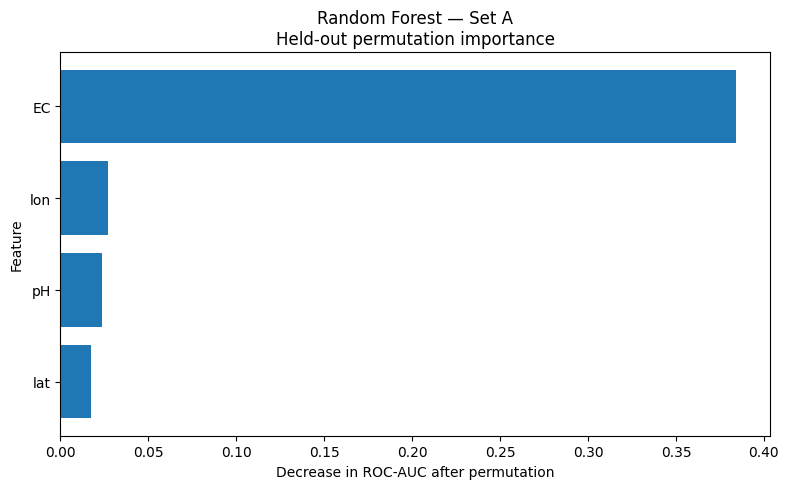

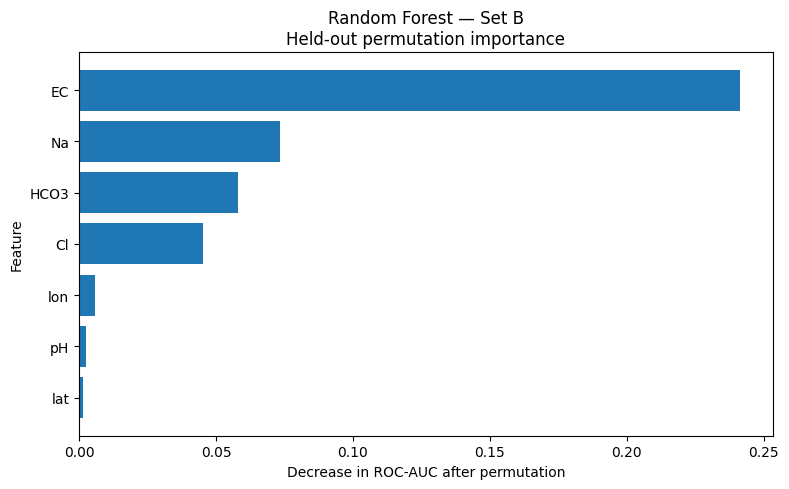



SHAP — RANDOM FOREST / SET A



,Feature,Mean_Abs_SHAP
0,EC,0.29888
1,lon,0.04960
2,pH,0.04615
3,lat,0.03331


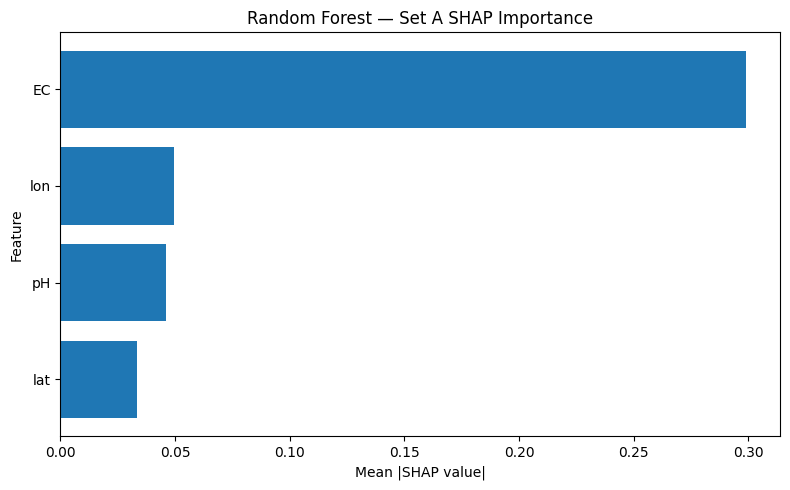

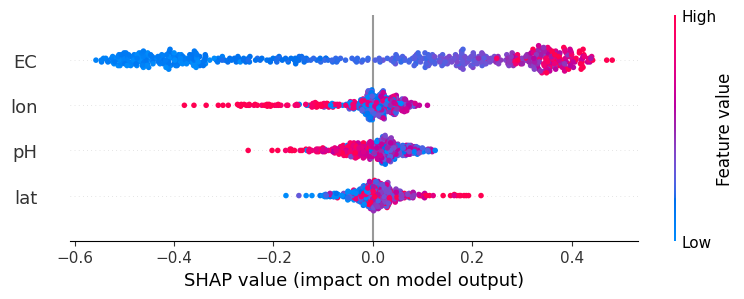



SHAP — RANDOM FOREST / SET B



,Feature,Mean_Abs_SHAP
0,EC,0.18581
1,HCO3,0.12065
2,Cl,0.08653
3,Na,0.06299
4,lon,0.02307
5,pH,0.01770
6,lat,0.01129


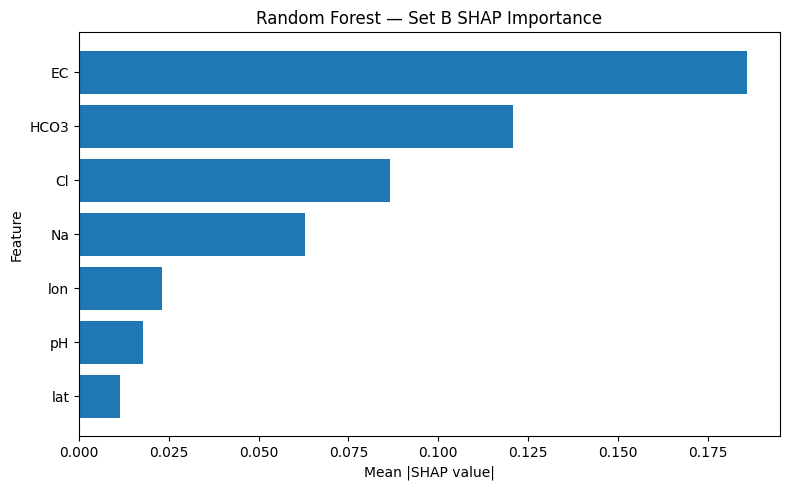

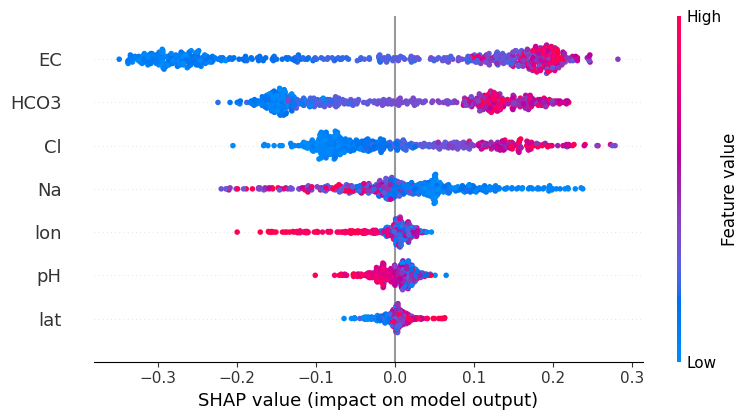



STEP 6B COMPLETE

Saved:
 - heldout_permutation_importance.csv
 - shap_random_forest_set_A.csv
 - shap_random_forest_set_B.csv

seed = 42


In [19]:
# =========================================================
# STEP 6B — EXPLAINABILITY + FEATURE IMPORTANCE
#
# Held-out permutation importance
# + SHAP analysis for Random Forest
#
# Set A:
#   pH + EC + lat + lon
#
# Set B:
#   pH + EC + lat + lon + HCO3 + Cl + Na
#
# seed = 42
# =========================================================

import os
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score


# =========================================================
# 0. Settings
# =========================================================

seed = 42

print("seed =", seed)


# =========================================================
# 1. Check SHAP installation
# =========================================================

try:

    import shap

except ImportError:

    print("SHAP not found. Installing in Colab...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "shap"
    ])

    import shap


print(
    "SHAP version:",
    shap.__version__
)


# =========================================================
# 2. Required variables
# =========================================================

required = [
    "trained_models",
    "split",
    "y_test"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:

    raise RuntimeError(
        f"Missing variables: {missing}. "
        "Run Steps 2 and 3 first."
    )


# =========================================================
# 3. Load clean data and reconstruct exact modeling set
# =========================================================

if not os.path.exists(
    "clean_bihar.csv"
):

    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )


clean = pd.read_csv(
    "clean_bihar.csv"
)


features_A = [
    "pH",
    "EC",
    "lat",
    "lon"
]


features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]


modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)


modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)


# =========================================================
# 4. Recover exact station-held-out test set
# =========================================================

test_idx = np.asarray(
    split["test_idx"],
    dtype=int
)


y_test_local = (
    modeling_df
    .iloc[test_idx]["y"]
    .to_numpy()
)


if not np.array_equal(
    y_test_local,
    np.asarray(y_test)
):

    raise ValueError(
        "Target alignment failed."
    )


X_A_test = (
    modeling_df
    .iloc[test_idx][features_A]
    .copy()
    .reset_index(drop=True)
)


X_B_test = (
    modeling_df
    .iloc[test_idx][features_B]
    .copy()
    .reset_index(drop=True)
)


print(
    "Test rows:",
    len(X_A_test)
)

print(
    "Target alignment: PASS"
)


# =========================================================
# 5. HELPER — find the underlying estimator
#
# For Random Forest the model is normally direct.
# For pipelines this function retrieves the final estimator.
# =========================================================

def final_estimator(model):

    if hasattr(
        model,
        "named_steps"
    ):

        return list(
            model.named_steps.values()
        )[-1]

    return model


# =========================================================
# 6. HELPER — model permutation importance
# =========================================================

def get_permutation_importance(
    model,
    X,
    y,
    scoring="roc_auc",
    n_repeats=50
):

    result = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=seed,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({

        "Feature": X.columns,

        "Importance_Mean":
            result.importances_mean,

        "Importance_SD":
            result.importances_std,

        "Importance_Low":
            result.importances_mean
            - 2 * result.importances_std,

        "Importance_High":
            result.importances_mean
            + 2 * result.importances_std

    })

    importance_df = (
        importance_df
        .sort_values(
            "Importance_Mean",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return importance_df


# =========================================================
# 7. PERMUTATION IMPORTANCE
# =========================================================

permutation_results = []


for feature_set, X_test_current in [
    ("A", X_A_test),
    ("B", X_B_test)
]:

    for model_name in [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVC RBF"
    ]:

        model = trained_models[
            feature_set
        ][model_name]


        importance = get_permutation_importance(
            model,
            X_test_current,
            np.asarray(y_test),
            scoring="roc_auc",
            n_repeats=50
        )


        importance.insert(
            0,
            "Model",
            model_name
        )

        importance.insert(
            0,
            "Feature Set",
            feature_set
        )


        permutation_results.append(
            importance
        )


permutation_df = pd.concat(
    permutation_results,
    ignore_index=True
)


# =========================================================
# 8. Display permutation results
# =========================================================

print("\n")
print("====================================================")
print("HELD-OUT PERMUTATION IMPORTANCE")
print("====================================================\n")


display(
    permutation_df[
        [
            "Feature Set",
            "Model",
            "Feature",
            "Importance_Mean",
            "Importance_SD",
            "Importance_Low",
            "Importance_High"
        ]
    ].round(5)
)


# =========================================================
# 9. Plot permutation importance for the primary models
# =========================================================

for feature_set in ["A", "B"]:

    temp = permutation_df[
        (
            permutation_df["Feature Set"]
            == feature_set
        )
        &
        (
            permutation_df["Model"]
            == "Random Forest"
        )
    ].copy()


    temp = temp.sort_values(
        "Importance_Mean"
    )


    plt.figure(
        figsize=(8, 5)
    )

    plt.barh(
        temp["Feature"],
        temp["Importance_Mean"]
    )

    plt.xlabel(
        "Decrease in ROC-AUC after permutation"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"Random Forest — Set {feature_set}\n"
        "Held-out permutation importance"
    )

    plt.tight_layout()

    plt.show()


# =========================================================
# 10. SHAP — Random Forest Set A
# =========================================================

rf_A = trained_models[
    "A"
]["Random Forest"]


rf_B = trained_models[
    "B"
]["Random Forest"]


# ---------------------------------------------------------
# SHAP Set A
# ---------------------------------------------------------

print("\n")
print("====================================================")
print("SHAP — RANDOM FOREST / SET A")
print("====================================================\n")


explainer_A = shap.TreeExplainer(
    rf_A
)


shap_A = explainer_A(
    X_A_test
)


# Handle SHAP versions where binary output can contain
# an extra class dimension.

values_A = shap_A.values

if values_A.ndim == 3:

    # Class 1 = hardness > 200
    values_A = values_A[:, :, 1]


shap_A_values = np.asarray(
    values_A
)


shap_A_importance = pd.DataFrame({

    "Feature":
        X_A_test.columns,

    "Mean_Abs_SHAP":
        np.mean(
            np.abs(
                shap_A_values
            ),
            axis=0
        )

})


shap_A_importance = (
    shap_A_importance
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    shap_A_importance.round(5)
)


# ---------------------------------------------------------
# SHAP Set A bar plot
# ---------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    shap_A_importance["Feature"][::-1],
    shap_A_importance["Mean_Abs_SHAP"][::-1]
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest — Set A SHAP Importance"
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# SHAP Set A beeswarm
# ---------------------------------------------------------

shap.summary_plot(
    shap_A_values,
    X_A_test,
    show=True
)


# =========================================================
# 11. SHAP — Random Forest Set B
# =========================================================

print("\n")
print("====================================================")
print("SHAP — RANDOM FOREST / SET B")
print("====================================================\n")


explainer_B = shap.TreeExplainer(
    rf_B
)


shap_B = explainer_B(
    X_B_test
)


values_B = shap_B.values


if values_B.ndim == 3:

    values_B = values_B[:, :, 1]


shap_B_values = np.asarray(
    values_B
)


shap_B_importance = pd.DataFrame({

    "Feature":
        X_B_test.columns,

    "Mean_Abs_SHAP":
        np.mean(
            np.abs(
                shap_B_values
            ),
            axis=0
        )

})


shap_B_importance = (
    shap_B_importance
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    shap_B_importance.round(5)
)


# ---------------------------------------------------------
# SHAP Set B bar plot
# ---------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    shap_B_importance["Feature"][::-1],
    shap_B_importance["Mean_Abs_SHAP"][::-1]
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest — Set B SHAP Importance"
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# SHAP Set B beeswarm
# ---------------------------------------------------------

shap.summary_plot(
    shap_B_values,
    X_B_test,
    show=True
)


# =========================================================
# 12. Save results
# =========================================================

permutation_df.to_csv(
    "heldout_permutation_importance.csv",
    index=False
)


shap_A_importance.to_csv(
    "shap_random_forest_set_A.csv",
    index=False
)


shap_B_importance.to_csv(
    "shap_random_forest_set_B.csv",
    index=False
)


print("\n")
print("====================================================")
print("STEP 6B COMPLETE")
print("====================================================")

print(
    "\nSaved:"
)

print(
    " - heldout_permutation_importance.csv"
)

print(
    " - shap_random_forest_set_A.csv"
)

print(
    " - shap_random_forest_set_B.csv"
)

print(
    "\nseed =",
    seed
)



SHAP — RANDOM FOREST / SET B



,Feature,Mean_Abs_SHAP
0,EC,0.18581
1,HCO3,0.12065
2,Cl,0.08653
3,Na,0.06299
4,lon,0.02307
5,pH,0.01770
6,lat,0.01129


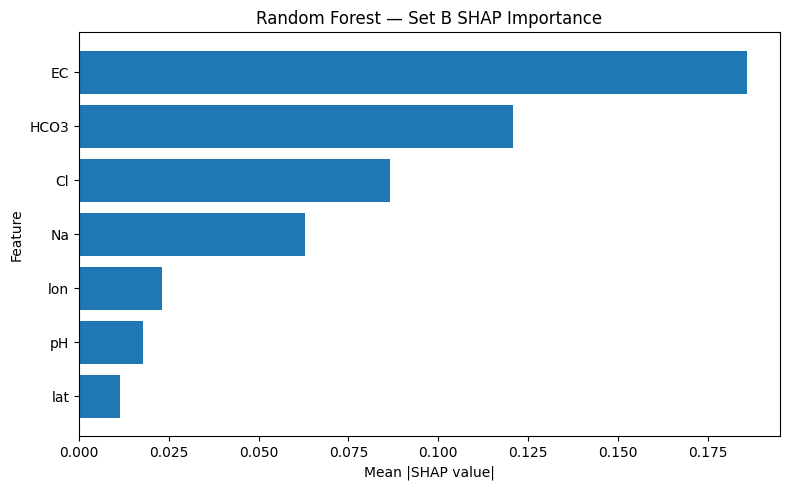

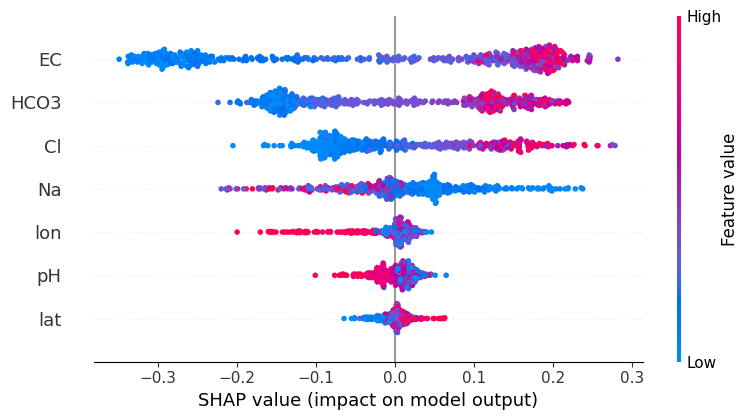


Step 6B complete.
Saved: shap_random_forest_set_B.csv
seed = 42


In [20]:
# =========================================================
# STEP 6B — SET B SHAP CONTINUATION
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

seed = 42

# ---------------------------------------------------------
# Random Forest Set B
# ---------------------------------------------------------

rf_B = trained_models["B"]["Random Forest"]

explainer_B = shap.TreeExplainer(
    rf_B
)

shap_B = explainer_B(
    X_B_test
)

values_B = shap_B.values

# SHAP version compatibility
if values_B.ndim == 3:
    values_B = values_B[:, :, 1]

shap_B_values = np.asarray(
    values_B
)


# ---------------------------------------------------------
# SHAP importance table
# ---------------------------------------------------------

shap_B_importance = pd.DataFrame({

    "Feature":
        X_B_test.columns,

    "Mean_Abs_SHAP":
        np.mean(
            np.abs(shap_B_values),
            axis=0
        )

}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)


print("\n")
print("====================================================")
print("SHAP — RANDOM FOREST / SET B")
print("====================================================\n")

display(
    shap_B_importance.round(5)
)


# ---------------------------------------------------------
# Bar chart
# ---------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    shap_B_importance["Feature"][::-1],
    shap_B_importance["Mean_Abs_SHAP"][::-1]
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest — Set B SHAP Importance"
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# Beeswarm
# ---------------------------------------------------------

shap.summary_plot(
    shap_B_values,
    X_B_test,
    show=True
)


# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

shap_B_importance.to_csv(
    "shap_random_forest_set_B.csv",
    index=False
)

print("\nStep 6B complete.")
print("Saved: shap_random_forest_set_B.csv")
print("seed =", seed)

In [21]:
# =========================================================
# STEP 7 — DISTRICT-HOLDOUT GENERALIZATION
#
# Question:
# Can AquaTrust generalize to districts with ZERO training
# observations?
#
# Same 2,105-row complete-case population.
#
# Feature sets:
#   A = pH + EC + lat + lon
#   B = pH + EC + lat + lon + HCO3 + Cl + Na
#
# Models:
#   Logistic Regression
#   Random Forest
#   Gradient Boosting
#   SVC RBF
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# =========================================================
# 0. Settings
# =========================================================

seed = 42

print("seed =", seed)


# =========================================================
# 1. Load exact modeling population
# =========================================================

if not os.path.exists(
    "clean_bihar.csv"
):

    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean = pd.read_csv(
    "clean_bihar.csv"
)


features_A = [
    "pH",
    "EC",
    "lat",
    "lon"
]

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]


modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)


modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)


modeling_df["district"] = (
    modeling_df["district"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# =========================================================
# 2. Basic population report
# =========================================================

print("\nModeling rows:",
      len(modeling_df))

print("Stations:",
      modeling_df["station"].nunique())

print("Districts:",
      modeling_df["district"].nunique())

print("Positive rate:",
      round(modeling_df["y"].mean(), 4))


# =========================================================
# 3. District-grouped split
# =========================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=8,
    random_state=seed
)


train_idx_district, test_idx_district = next(
    gss.split(
        modeling_df,
        modeling_df["y"],
        groups=modeling_df["district"]
    )
)


train_idx_district = np.asarray(
    train_idx_district,
    dtype=int
)

test_idx_district = np.asarray(
    test_idx_district,
    dtype=int
)


# =========================================================
# 4. District sets
# =========================================================

train_districts = sorted(
    modeling_df
    .iloc[train_idx_district]["district"]
    .unique()
)

test_districts = sorted(
    modeling_df
    .iloc[test_idx_district]["district"]
    .unique()
)


overlap = set(
    train_districts
).intersection(
    test_districts
)


if overlap:

    raise ValueError(
        f"District leakage detected: {overlap}"
    )


# =========================================================
# 5. Target vectors
# =========================================================

y_train_d = (
    modeling_df
    .iloc[train_idx_district]["y"]
    .to_numpy()
)

y_test_d = (
    modeling_df
    .iloc[test_idx_district]["y"]
    .to_numpy()
)


# =========================================================
# 6. Split summary
# =========================================================

print("\n")
print("====================================================")
print("DISTRICT-HOLDOUT SPLIT")
print("====================================================")

print(
    "\nTrain rows:",
    len(train_idx_district)
)

print(
    "Test rows:",
    len(test_idx_district)
)

print(
    "Train districts:",
    len(train_districts)
)

print(
    "Test districts:",
    len(test_districts)
)

print(
    "District overlap:",
    len(overlap)
)

print(
    "Train positive rate:",
    round(
        y_train_d.mean(),
        4
    )
)

print(
    "Test positive rate:",
    round(
        y_test_d.mean(),
        4
    )
)

print(
    "\nHeld-out districts:"
)

print(
    test_districts
)


# =========================================================
# 7. Per-district composition
# =========================================================

district_profile = (
    modeling_df
    .iloc[test_idx_district]
    .groupby("district")
    .agg(
        Rows=("y", "size"),
        Positive=("y", "sum"),
        Positive_Rate=("y", "mean")
    )
    .reset_index()
    .sort_values(
        "Positive_Rate",
        ascending=False
    )
)


print("\n")
print("====================================================")
print("HELD-OUT DISTRICT COMPOSITION")
print("====================================================\n")

display(
    district_profile.round(4)
)


# =========================================================
# 8. Train and evaluate
# =========================================================

results_district = []

district_models = {
    "A": {},
    "B": {}
}


for feature_set, features in [
    ("A", features_A),
    ("B", features_B)
]:

    X_train = (
        modeling_df
        .iloc[train_idx_district][features]
        .copy()
    )

    X_test = (
        modeling_df
        .iloc[test_idx_district][features]
        .copy()
    )


    for model_name in [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVC RBF"
    ]:

        # -------------------------------------------------
        # Use exact model configuration from Step 3
        # -------------------------------------------------

        template = trained_models[
            feature_set
        ][model_name]

        model = clone(
            template
        )


        # -------------------------------------------------
        # Train
        # -------------------------------------------------

        model.fit(
            X_train,
            y_train_d
        )


        # -------------------------------------------------
        # Predictions
        # -------------------------------------------------

        pred = model.predict(
            X_test
        )


        if hasattr(
            model,
            "predict_proba"
        ):

            score = model.predict_proba(
                X_test
            )[:, 1]

        else:

            score = model.decision_function(
                X_test
            )


        # -------------------------------------------------
        # Metrics
        # -------------------------------------------------

        accuracy = accuracy_score(
            y_test_d,
            pred
        )

        f1 = f1_score(
            y_test_d,
            pred,
            zero_division=0
        )

        auc = roc_auc_score(
            y_test_d,
            score
        )


        cm = confusion_matrix(
            y_test_d,
            pred
        )


        # -------------------------------------------------
        # Store
        # -------------------------------------------------

        results_district.append({

            "Feature Set":
                feature_set,

            "Model":
                model_name,

            "Accuracy":
                accuracy,

            "F1":
                f1,

            "ROC-AUC":
                auc,

            "Test Rows":
                len(test_idx_district),

            "Test Districts":
                len(test_districts),

            "Confusion Matrix":
                str(cm.tolist())

        })


        district_models[
            feature_set
        ][model_name] = model


# =========================================================
# 9. Results table
# =========================================================

district_df = pd.DataFrame(
    results_district
)


print("\n")
print("====================================================")
print("DISTRICT-HOLDOUT MODEL RESULTS")
print("====================================================\n")

display(
    district_df[
        [
            "Feature Set",
            "Model",
            "Accuracy",
            "F1",
            "ROC-AUC"
        ]
    ]
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .round(4)
)


# =========================================================
# 10. Station vs district generalization
# =========================================================

print("\n")
print("====================================================")
print("STATION vs DISTRICT GENERALIZATION")
print("====================================================\n")


station_results = results_df.copy()


comparison_rows = []


for feature_set in [
    "A",
    "B"
]:

    for model_name in [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVC RBF"
    ]:

        station_row = station_results[
            (
                station_results[
                    "Feature Set"
                ] == feature_set
            )
            &
            (
                station_results[
                    "Model"
                ] == model_name
            )
        ]


        district_row = district_df[
            (
                district_df[
                    "Feature Set"
                ] == feature_set
            )
            &
            (
                district_df[
                    "Model"
                ] == model_name
            )
        ]


        station_auc = float(
            station_row[
                "ROC-AUC"
            ].iloc[0]
        )

        district_auc = float(
            district_row[
                "ROC-AUC"
            ].iloc[0]
        )

        station_acc = float(
            station_row[
                "Accuracy"
            ].iloc[0]
        )

        district_acc = float(
            district_row[
                "Accuracy"
            ].iloc[0]
        )


        comparison_rows.append({

            "Feature Set":
                feature_set,

            "Model":
                model_name,

            "Station_AUC":
                station_auc,

            "District_AUC":
                district_auc,

            "AUC_Change":
                district_auc - station_auc,

            "Station_Accuracy":
                station_acc,

            "District_Accuracy":
                district_acc,

            "Accuracy_Change":
                district_acc - station_acc

        })


generalization_df = pd.DataFrame(
    comparison_rows
)


display(
    generalization_df.round(4)
)


# =========================================================
# 11. Save
# =========================================================

district_df.to_csv(
    "district_holdout_results.csv",
    index=False
)

district_profile.to_csv(
    "heldout_district_profile.csv",
    index=False
)

generalization_df.to_csv(
    "station_vs_district_generalization.csv",
    index=False
)


print("\nStep 7 complete.")

print(
    "Saved:"
)

print(
    " - district_holdout_results.csv"
)

print(
    " - heldout_district_profile.csv"
)

print(
    " - station_vs_district_generalization.csv"
)

print(
    "seed =",
    seed
)

seed = 42

Modeling rows: 2105
Stations: 735
Districts: 37
Positive rate: 0.5121


DISTRICT-HOLDOUT SPLIT

Train rows: 1612
Test rows: 493
Train districts: 29
Test districts: 8
District overlap: 0
Train positive rate: 0.5242
Test positive rate: 0.4726

Held-out districts:
['BHAGALPUR', 'BUXAR', 'KATIHAR', 'MADHEPURA', 'PURBA CHAMPARAN', 'PURNIA', 'SAMASTIPUR', 'SUPAUL']


HELD-OUT DISTRICT COMPOSITION



,district,Rows,Positive,Positive_Rate
6,SAMASTIPUR,44,30,0.6818
0,BHAGALPUR,53,35,0.6604
1,BUXAR,50,31,0.6200
3,MADHEPURA,38,23,0.6053
4,PURBA CHAMPARAN,72,36,0.5000
7,SUPAUL,75,29,0.3867
2,KATIHAR,86,30,0.3488
5,PURNIA,75,19,0.2533




DISTRICT-HOLDOUT MODEL RESULTS



,Feature Set,Model,Accuracy,F1,ROC-AUC
4,B,Logistic Regression,0.8945,0.8894,0.9474
5,B,Random Forest,0.8641,0.8624,0.9473
7,B,SVC RBF,0.8661,0.8540,0.9408
6,B,Gradient Boosting,0.8783,0.8755,0.9395
1,A,Random Forest,0.7951,0.7730,0.8821
0,A,Logistic Regression,0.7850,0.7464,0.8793
2,A,Gradient Boosting,0.7992,0.7843,0.8793
3,A,SVC RBF,0.8053,0.7778,0.8703




STATION vs DISTRICT GENERALIZATION



,Feature Set,Model,Station_AUC,District_AUC,AUC_Change,Station_Accuracy,District_Accuracy,Accuracy_Change
0,A,Logistic Regression,0.9208,0.8793,-0.0415,0.8519,0.7850,-0.0669
1,A,Random Forest,0.9263,0.8821,-0.0441,0.8404,0.7951,-0.0453
2,A,Gradient Boosting,0.9189,0.8793,-0.0396,0.8327,0.7992,-0.0335
3,A,SVC RBF,0.9259,0.8703,-0.0556,0.8519,0.8053,-0.0466
4,B,Logistic Regression,0.9768,0.9474,-0.0294,0.9269,0.8945,-0.0324
5,B,Random Forest,0.9768,0.9473,-0.0295,0.9212,0.8641,-0.0571
6,B,Gradient Boosting,0.9712,0.9395,-0.0317,0.9135,0.8783,-0.0352
7,B,SVC RBF,0.9740,0.9408,-0.0332,0.9135,0.8661,-0.0473



Step 7 complete.
Saved:
 - district_holdout_results.csv
 - heldout_district_profile.csv
 - station_vs_district_generalization.csv
seed = 42


In [22]:
# =========================================================
# STEP 8 — TEMPORAL GENERALIZATION
#
# Train: observations before 2020
# Test : observations from 2020–2021
#
# Question:
# Can AquaTrust trained on historical data generalize
# to later groundwater observations?
#
# Feature sets:
#   A = pH + EC + lat + lon
#   B = pH + EC + lat + lon + HCO3 + Cl + Na
#
# Models:
#   Logistic Regression
#   Random Forest
#   Gradient Boosting
#   SVC RBF
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# =========================================================
# 0. Settings
# =========================================================

seed = 42

TRAIN_END_YEAR = 2019
TEST_START_YEAR = 2020
TEST_END_YEAR = 2021

print("seed =", seed)


# =========================================================
# 1. Load clean data
# =========================================================

if not os.path.exists(
    "clean_bihar.csv"
):

    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean = pd.read_csv(
    "clean_bihar.csv"
)


# =========================================================
# 2. Feature definitions
# =========================================================

features_A = [
    "pH",
    "EC",
    "lat",
    "lon"
]

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]


required = features_B + [
    "hardness",
    "year",
    "station",
    "district"
]


missing_columns = [
    c for c in required
    if c not in clean.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# =========================================================
# 3. Reconstruct exact 2,105-row modeling population
# =========================================================

modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)


# Make sure year is numeric
modeling_df["year"] = pd.to_numeric(
    modeling_df["year"],
    errors="coerce"
)


# Target
modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)


# Remove invalid year rows
modeling_df = (
    modeling_df
    .dropna(subset=["year"])
    .reset_index(drop=True)
)


modeling_df["year"] = (
    modeling_df["year"]
    .astype(int)
)


print("\n")
print("====================================================")
print("TEMPORAL DATASET")
print("====================================================")

print(
    "Modeling rows:",
    len(modeling_df)
)

print(
    "Years:",
    sorted(
        modeling_df["year"].unique()
    )
)

print(
    "Stations:",
    modeling_df["station"].nunique()
)

print(
    "Districts:",
    modeling_df["district"].nunique()
)


# =========================================================
# 4. Chronological train/test split
# =========================================================

train_mask = (
    modeling_df["year"]
    <= TRAIN_END_YEAR
)

test_mask = (
    modeling_df["year"]
    >= TEST_START_YEAR
) & (
    modeling_df["year"]
    <= TEST_END_YEAR
)


train_df = (
    modeling_df[
        train_mask
    ]
    .copy()
    .reset_index(drop=True)
)


test_df = (
    modeling_df[
        test_mask
    ]
    .copy()
    .reset_index(drop=True)
)


# =========================================================
# 5. Check that the split is genuinely chronological
# =========================================================

if len(train_df) == 0:
    raise ValueError(
        "Training set is empty."
    )

if len(test_df) == 0:
    raise ValueError(
        "Temporal test set is empty."
    )


if train_df["year"].max() >= test_df["year"].min():

    raise ValueError(
        "Temporal leakage detected: "
        "training contains years at or after test period."
    )


# =========================================================
# 6. Split summary
# =========================================================

y_train_t = (
    train_df["y"]
    .to_numpy()
)

y_test_t = (
    test_df["y"]
    .to_numpy()
)


train_stations = set(
    train_df["station"]
    .astype(str)
)

test_stations = set(
    test_df["station"]
    .astype(str)
)


station_overlap = (
    train_stations
    .intersection(test_stations)
)


train_districts = set(
    train_df["district"]
    .astype(str)
)

test_districts = set(
    test_df["district"]
    .astype(str)
)


district_overlap = (
    train_districts
    .intersection(test_districts)
)


print("\n")
print("====================================================")
print("TEMPORAL HOLDOUT")
print("====================================================")

print(
    "\nTrain rows:",
    len(train_df)
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Training years:",
    f"{train_df['year'].min()}–"
    f"{train_df['year'].max()}"
)

print(
    "Testing years:",
    f"{test_df['year'].min()}–"
    f"{test_df['year'].max()}"
)

print(
    "Train positive rate:",
    round(
        y_train_t.mean(),
        4
    )
)

print(
    "Test positive rate:",
    round(
        y_test_t.mean(),
        4
    )
)

print(
    "Training stations:",
    len(train_stations)
)

print(
    "Testing stations:",
    len(test_stations)
)

print(
    "Station overlap:",
    len(station_overlap)
)

print(
    "Training districts:",
    len(train_districts)
)

print(
    "Testing districts:",
    len(test_districts)
)

print(
    "District overlap:",
    len(district_overlap)
)


# =========================================================
# 7. Year-by-year test composition
# =========================================================

year_profile = (
    test_df
    .groupby("year")
    .agg(
        Rows=("y", "size"),
        Positive=("y", "sum"),
        Positive_Rate=("y", "mean"),
        Stations=("station", "nunique"),
        Districts=("district", "nunique")
    )
    .reset_index()
)


print("\n")
print("====================================================")
print("TEST PERIOD BY YEAR")
print("====================================================\n")

display(
    year_profile.round(4)
)


# =========================================================
# 8. Train/evaluate every model
# =========================================================

temporal_results = []

temporal_models = {
    "A": {},
    "B": {}
}


for feature_set, features in [
    ("A", features_A),
    ("B", features_B)
]:

    X_train = (
        train_df[
            features
        ]
        .copy()
    )

    X_test = (
        test_df[
            features
        ]
        .copy()
    )


    for model_name in [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVC RBF"
    ]:

        # Use exact Step 3 configuration
        template = trained_models[
            feature_set
        ][model_name]

        model = clone(
            template
        )


        # -------------------------------------------------
        # Train ONLY on historical observations
        # -------------------------------------------------

        model.fit(
            X_train,
            y_train_t
        )


        # -------------------------------------------------
        # Predict future observations
        # -------------------------------------------------

        pred = model.predict(
            X_test
        )


        if hasattr(
            model,
            "predict_proba"
        ):

            score = model.predict_proba(
                X_test
            )[:, 1]

        else:

            score = model.decision_function(
                X_test
            )


        # -------------------------------------------------
        # Metrics
        # -------------------------------------------------

        accuracy = accuracy_score(
            y_test_t,
            pred
        )

        f1 = f1_score(
            y_test_t,
            pred,
            zero_division=0
        )

        auc = roc_auc_score(
            y_test_t,
            score
        )


        cm = confusion_matrix(
            y_test_t,
            pred
        )


        temporal_results.append({

            "Feature Set":
                feature_set,

            "Model":
                model_name,

            "Accuracy":
                accuracy,

            "F1":
                f1,

            "ROC-AUC":
                auc,

            "Confusion Matrix":
                str(
                    cm.tolist()
                )

        })


        temporal_models[
            feature_set
        ][model_name] = model


# =========================================================
# 9. Results
# =========================================================

temporal_df = pd.DataFrame(
    temporal_results
)


print("\n")
print("====================================================")
print("TEMPORAL GENERALIZATION RESULTS")
print("====================================================\n")

display(
    temporal_df[
        [
            "Feature Set",
            "Model",
            "Accuracy",
            "F1",
            "ROC-AUC"
        ]
    ]
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .round(4)
)


# =========================================================
# 10. Compare station, district and temporal AUC
# =========================================================

print("\n")
print("====================================================")
print("GENERALIZATION ACROSS VALIDATION AXES")
print("====================================================\n")


comparison_rows = []


for feature_set in [
    "A",
    "B"
]:

    for model_name in [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVC RBF"
    ]:

        station_row = results_df[
            (
                results_df[
                    "Feature Set"
                ] == feature_set
            )
            &
            (
                results_df[
                    "Model"
                ] == model_name
            )
        ]


        district_row = district_df[
            (
                district_df[
                    "Feature Set"
                ] == feature_set
            )
            &
            (
                district_df[
                    "Model"
                ] == model_name
            )
        ]


        temporal_row = temporal_df[
            (
                temporal_df[
                    "Feature Set"
                ] == feature_set
            )
            &
            (
                temporal_df[
                    "Model"
                ] == model_name
            )
        ]


        station_auc = float(
            station_row[
                "ROC-AUC"
            ].iloc[0]
        )

        district_auc = float(
            district_row[
                "ROC-AUC"
            ].iloc[0]
        )

        temporal_auc = float(
            temporal_row[
                "ROC-AUC"
            ].iloc[0]
        )


        comparison_rows.append({

            "Feature Set":
                feature_set,

            "Model":
                model_name,

            "Station_Heldout_AUC":
                station_auc,

            "District_Heldout_AUC":
                district_auc,

            "Temporal_Holdout_AUC":
                temporal_auc,

            "District_vs_Station":
                district_auc - station_auc,

            "Temporal_vs_Station":
                temporal_auc - station_auc

        })


generalization_all_df = pd.DataFrame(
    comparison_rows
)


display(
    generalization_all_df.round(4)
)


# =========================================================
# 11. Save results
# =========================================================

temporal_df.to_csv(
    "temporal_holdout_results.csv",
    index=False
)

year_profile.to_csv(
    "temporal_test_year_profile.csv",
    index=False
)

generalization_all_df.to_csv(
    "three_axis_generalization.csv",
    index=False
)


print("\nStep 8 complete.")

print(
    "Saved:"
)

print(
    " - temporal_holdout_results.csv"
)

print(
    " - temporal_test_year_profile.csv"
)

print(
    " - three_axis_generalization.csv"
)

print(
    "seed =",
    seed
)

seed = 42


TEMPORAL DATASET
Modeling rows: 2105
Years: [np.int64(2000), np.int64(2001), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2016), np.int64(2019), np.int64(2021)]
Stations: 735
Districts: 37


TEMPORAL HOLDOUT

Train rows: 1922
Test rows: 183
Training years: 2000–2019
Testing years: 2021–2021
Train positive rate: 0.5234
Test positive rate: 0.3934
Training stations: 695
Testing stations: 183
Station overlap: 143
Training districts: 37
Testing districts: 25
District overlap: 25


TEST PERIOD BY YEAR



,year,Rows,Positive,Positive_Rate,Stations,Districts
0,2021,183,72,0.3934,183,25




TEMPORAL GENERALIZATION RESULTS



,Feature Set,Model,Accuracy,F1,ROC-AUC
4,B,Logistic Regression,0.9344,0.9155,0.9706
7,B,SVC RBF,0.8962,0.8707,0.9637
5,B,Random Forest,0.9016,0.8800,0.9632
6,B,Gradient Boosting,0.9016,0.8816,0.9562
0,A,Logistic Regression,0.8251,0.7681,0.9103
3,A,SVC RBF,0.8361,0.7887,0.9035
2,A,Gradient Boosting,0.8142,0.7792,0.8946
1,A,Random Forest,0.8415,0.8079,0.8809




GENERALIZATION ACROSS VALIDATION AXES



,Feature Set,Model,Station_Heldout_AUC,District_Heldout_AUC,Temporal_Holdout_AUC,District_vs_Station,Temporal_vs_Station
0,A,Logistic Regression,0.9208,0.8793,0.9103,-0.0415,-0.0105
1,A,Random Forest,0.9263,0.8821,0.8809,-0.0441,-0.0453
2,A,Gradient Boosting,0.9189,0.8793,0.8946,-0.0396,-0.0243
3,A,SVC RBF,0.9259,0.8703,0.9035,-0.0556,-0.0223
4,B,Logistic Regression,0.9768,0.9474,0.9706,-0.0294,-0.0062
5,B,Random Forest,0.9768,0.9473,0.9632,-0.0295,-0.0136
6,B,Gradient Boosting,0.9712,0.9395,0.9562,-0.0317,-0.0150
7,B,SVC RBF,0.9740,0.9408,0.9637,-0.0332,-0.0103



Step 8 complete.
Saved:
 - temporal_holdout_results.csv
 - temporal_test_year_profile.csv
 - three_axis_generalization.csv
seed = 42


In [23]:
# =========================================================
# STEP 9A — HARDNESS THRESHOLD SENSITIVITY
#
# Primary threshold:
#   >200 mg/L as CaCO3
#
# Secondary threshold:
#   >600 mg/L as CaCO3
#
# The 600 threshold is treated as a rare-event stress test.
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


# =========================================================
# 0. Settings
# =========================================================

seed = 42

THRESHOLDS = [200, 600]

print("seed =", seed)


# =========================================================
# 1. Load clean dataset
# =========================================================

if not os.path.exists(
    "clean_bihar.csv"
):
    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean = pd.read_csv(
    "clean_bihar.csv"
)


# =========================================================
# 2. Basic hardness availability
# =========================================================

hardness_available = (
    clean["hardness"]
    .dropna()
)

print("\n")
print("====================================================")
print("HARDNESS THRESHOLD DISTRIBUTION")
print("====================================================\n")


for threshold in THRESHOLDS:

    usable = len(
        hardness_available
    )

    positives = int(
        (
            hardness_available
            > threshold
        ).sum()
    )

    negatives = (
        usable
        - positives
    )

    prevalence = (
        positives / usable
    )

    print(
        f"> {threshold} mg/L: "
        f"usable={usable:,} | "
        f"positive={positives:,} | "
        f"negative={negatives:,} | "
        f"prevalence={prevalence:.4%}"
    )


# =========================================================
# 3. Reconstruct exact 2,105-row modeling population
# =========================================================

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)


# =========================================================
# 4. Threshold distributions in the modeling population
# =========================================================

print("\n")
print("====================================================")
print("THRESHOLD DISTRIBUTION — 2,105 COMPLETE CASES")
print("====================================================\n")


threshold_rows = []


for threshold in THRESHOLDS:

    y_threshold = (
        modeling_df["hardness"]
        > threshold
    ).astype(int)

    positive = int(
        y_threshold.sum()
    )

    total = len(
        y_threshold
    )

    negative = (
        total
        - positive
    )

    prevalence = (
        positive
        / total
    )

    threshold_rows.append({

        "Threshold_mg_L":
            threshold,

        "Rows":
            total,

        "Positive":
            positive,

        "Negative":
            negative,

        "Positive_Rate":
            prevalence

    })


threshold_df = pd.DataFrame(
    threshold_rows
)


display(
    threshold_df.round(4)
)


# =========================================================
# 5. 600 mg/L target on station-held-out split
# =========================================================

test_idx = np.asarray(
    split["test_idx"],
    dtype=int
)

train_idx = np.asarray(
    split["train_idx"],
    dtype=int
)


# Create 600 mg/L target
y600 = (
    modeling_df["hardness"]
    > 600
).astype(int)


y600_train = (
    y600
    .iloc[train_idx]
    .to_numpy()
)

y600_test = (
    y600
    .iloc[test_idx]
    .to_numpy()
)


print("\n")
print("====================================================")
print("600 mg/L — STATION-HOLDOUT CLASS BALANCE")
print("====================================================")

print(
    "\nTrain positives:",
    int(y600_train.sum())
)

print(
    "Train negatives:",
    int((y600_train == 0).sum())
)

print(
    "Test positives:",
    int(y600_test.sum())
)

print(
    "Test negatives:",
    int((y600_test == 0).sum())
)

print(
    "Test prevalence:",
    f"{y600_test.mean():.4%}"
)


# =========================================================
# 6. Rare-event feasibility check
# =========================================================

if y600_test.sum() < 10:

    print("\n")
    print(
        "WARNING: fewer than 10 positive cases "
        "exist in the held-out test set."
    )

    print(
        "A 600 mg/L model evaluation will therefore "
        "have very high uncertainty and should NOT be "
        "used as a headline performance claim."
    )


# =========================================================
# 7. Train primary rare-event models
#
# Logistic Regression + Random Forest
#
# class_weight='balanced' is used only for this rare-event
# stress test because the 600 mg/L class is extremely rare.
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


rare_models = {

    "Logistic Regression":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=seed
                )
            )
        ]),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1
        )

}


rare_results = []


X_train_600 = (
    modeling_df
    .iloc[train_idx][features_B]
)

X_test_600 = (
    modeling_df
    .iloc[test_idx][features_B]
)


for model_name, model in rare_models.items():

    model.fit(
        X_train_600,
        y600_train
    )

    pred = model.predict(
        X_test_600
    )

    score = model.predict_proba(
        X_test_600
    )[:, 1]


    tn, fp, fn, tp = (
        confusion_matrix(
            y600_test,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )


    accuracy = accuracy_score(
        y600_test,
        pred
    )

    balanced_acc = (
        balanced_accuracy_score(
            y600_test,
            pred
        )
    )

    precision = precision_score(
        y600_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y600_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y600_test,
        pred,
        zero_division=0
    )


    if (
        len(
            np.unique(y600_test)
        ) == 2
    ):

        auc = roc_auc_score(
            y600_test,
            score
        )

        ap = average_precision_score(
            y600_test,
            score
        )

    else:

        auc = np.nan
        ap = np.nan


    rare_results.append({

        "Model":
            model_name,

        "Accuracy":
            accuracy,

        "Balanced_Accuracy":
            balanced_acc,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1":
            f1,

        "ROC-AUC":
            auc,

        "PR-AUC":
            ap,

        "TP":
            tp,

        "FP":
            fp,

        "FN":
            fn,

        "TN":
            tn

    })


rare_df = pd.DataFrame(
    rare_results
)


# =========================================================
# 8. Display rare-event result
# =========================================================

print("\n")
print("====================================================")
print("600 mg/L RARE-EVENT STRESS TEST")
print("====================================================\n")

display(
    rare_df.round(4)
)


# =========================================================
# 9. Compare with trivial prevalence baseline
# =========================================================

test_prevalence_600 = (
    y600_test.mean()
)


print("\n")
print("====================================================")
print("600 mg/L BASELINE")
print("====================================================")

print(
    f"\nTest positive prevalence: "
    f"{test_prevalence_600:.4%}"
)

print(
    "\nA naive classifier that predicts "
    "EVERY observation as negative would have:"
)

print(
    f"Accuracy = "
    f"{1 - test_prevalence_600:.4f}"
)

print(
    "Recall = 0.0000"
)

print(
    "PR-AUC baseline ≈ "
    f"{test_prevalence_600:.4f}"
)


# =========================================================
# 10. Save
# =========================================================

threshold_df.to_csv(
    "hardness_threshold_distribution.csv",
    index=False
)

rare_df.to_csv(
    "hardness_600_rare_event_results.csv",
    index=False
)


print("\nStep 9A complete.")

print(
    "Saved:"
)

print(
    " - hardness_threshold_distribution.csv"
)

print(
    " - hardness_600_rare_event_results.csv"
)

print(
    "seed =",
    seed
)

seed = 42


HARDNESS THRESHOLD DISTRIBUTION

> 200 mg/L: usable=2,464 | positive=1,295 | negative=1,169 | prevalence=52.5568%
> 600 mg/L: usable=2,464 | positive=32 | negative=2,432 | prevalence=1.2987%


THRESHOLD DISTRIBUTION — 2,105 COMPLETE CASES



,Threshold_mg_L,Rows,Positive,Negative,Positive_Rate
0,200,2105,1078,1027,0.5121
1,600,2105,29,2076,0.0138




600 mg/L — STATION-HOLDOUT CLASS BALANCE

Train positives: 18
Train negatives: 1567
Test positives: 11
Test negatives: 509
Test prevalence: 2.1154%


600 mg/L RARE-EVENT STRESS TEST



,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
0,Logistic Regression,0.9654,0.9823,0.3793,1.0000,0.5500,0.9911,0.7090,11,18,0,491
1,Random Forest,0.9827,0.5909,1.0000,0.1818,0.3077,0.9883,0.6938,2,0,9,509




600 mg/L BASELINE

Test positive prevalence: 2.1154%

A naive classifier that predicts EVERY observation as negative would have:
Accuracy = 0.9788
Recall = 0.0000
PR-AUC baseline ≈ 0.0212

Step 9A complete.
Saved:
 - hardness_threshold_distribution.csv
 - hardness_600_rare_event_results.csv
seed = 42


seed = 42

Training rows: 1585
Test rows: 520
Training stations: 551
Test stations: 184
Training positive rate: 0.5199
Test positive rate: 0.4885

A — Logistic Regression: OOF predictions complete.

A — Logistic Regression
OOF F2-optimal threshold: 0.2363
OOF F2: 0.8909
OOF precision: 0.6818
OOF recall: 0.9648
OOF F1: 0.7990
OOF recall≥90% threshold: 0.3386

B — Logistic Regression: OOF predictions complete.

B — Logistic Regression
OOF F2-optimal threshold: 0.2935
OOF F2: 0.9325
OOF precision: 0.8189
OOF recall: 0.9660
OOF F1: 0.8864
OOF recall≥90% threshold: 0.4576


OPERATIONAL THRESHOLD — TEST SET



,Model,Threshold_Type,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,F2
0,A — Logistic Regression,Default,0.5000,0.8519,0.8509,0.8798,0.8071,0.8419,0.8207
1,A — Logistic Regression,OOF F2-optimal,0.2363,0.7692,0.7738,0.6861,0.9724,0.8046,0.8975
2,A — Logistic Regression,OOF recall >= 90%,0.3386,0.8250,0.8273,0.7638,0.9291,0.8384,0.8906
3,B — Logistic Regression,Default,0.5000,0.9269,0.9267,0.9320,0.9173,0.9246,0.9202
4,B — Logistic Regression,OOF F2-optimal,0.2935,0.9058,0.9075,0.8475,0.9843,0.9107,0.9535
5,B — Logistic Regression,OOF recall >= 90%,0.4576,0.9308,0.9309,0.9225,0.9370,0.9297,0.9341




TEST PROBABILITY PERFORMANCE



,Model,ROC-AUC,PR-AUC,Brier,Log_Loss
0,A — Logistic Regression,0.9208,0.9016,0.1184,0.4005
1,B — Logistic Regression,0.9768,0.9777,0.0609,0.2353




CONFUSION MATRICES — F2 THRESHOLD


A — Logistic Regression
Threshold = 0.2363
Rows = Actual [0, 1]
Columns = Predicted [0, 1]
[[153 113]
 [  7 247]]

B — Logistic Regression
Threshold = 0.2935
Rows = Actual [0, 1]
Columns = Predicted [0, 1]
[[221  45]
 [  4 250]]


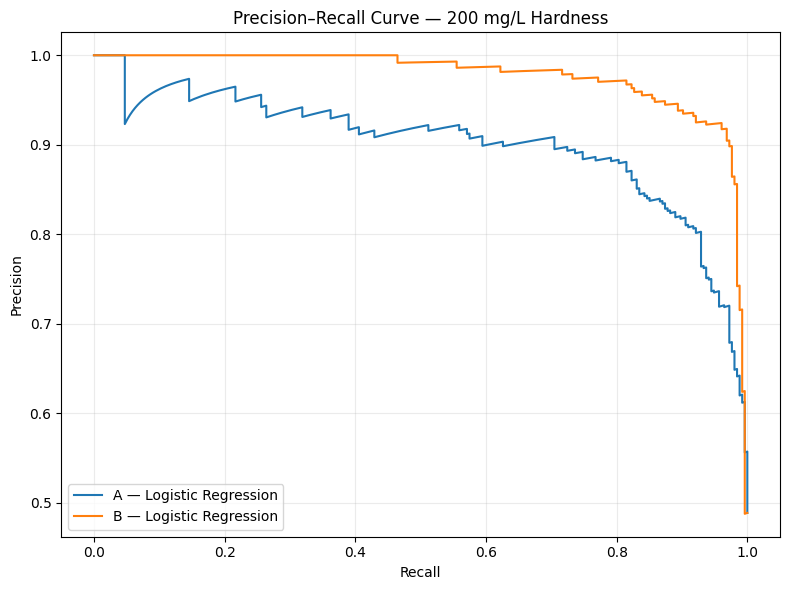


Step 9B complete.
Saved:
 - operational_threshold_results.csv
 - probability_performance_results.csv
seed = 42


In [24]:
# =========================================================
# STEP 9B — OPERATIONAL SCREENING THRESHOLD
#
# Primary target:
#   hardness > 200 mg/L as CaCO3
#
# Threshold selection:
#   5-fold STATION-GROUPED out-of-fold predictions
#   using TRAINING DATA ONLY
#
# Selection criterion:
#   Maximum F2 (recall-weighted)
#
# Final evaluation:
#   untouched 520-row station-held-out test set
#
# Models:
#   A Logistic Regression
#   B Logistic Regression
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    log_loss,
    brier_score_loss,
    precision_recall_curve
)

seed = 42


# =========================================================
# 1. Load exact modeling population
# =========================================================

if not os.path.exists(
    "clean_bihar.csv"
):
    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean = pd.read_csv(
    "clean_bihar.csv"
)


features_A = [
    "pH",
    "EC",
    "lat",
    "lon"
]

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]


modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)

modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)


# =========================================================
# 2. Recover SAME station-held-out split from Step 2
# =========================================================

train_idx = np.asarray(
    split["train_idx"],
    dtype=int
)

test_idx = np.asarray(
    split["test_idx"],
    dtype=int
)


train_df = (
    modeling_df
    .iloc[train_idx]
    .reset_index(drop=True)
)

test_df = (
    modeling_df
    .iloc[test_idx]
    .reset_index(drop=True)
)


y_train = (
    train_df["y"]
    .to_numpy()
    .astype(int)
)

y_test = (
    test_df["y"]
    .to_numpy()
    .astype(int)
)


# =========================================================
# 3. Verify original split
# =========================================================

print("seed =", seed)

print(
    "\nTraining rows:",
    len(train_df)
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Training stations:",
    train_df["station"].nunique()
)

print(
    "Test stations:",
    test_df["station"].nunique()
)

print(
    "Training positive rate:",
    round(y_train.mean(), 4)
)

print(
    "Test positive rate:",
    round(y_test.mean(), 4)
)


# =========================================================
# 4. Model selection
# =========================================================

models_to_evaluate = {

    "A — Logistic Regression":
        (
            "A",
            "Logistic Regression"
        ),

    "B — Logistic Regression":
        (
            "B",
            "Logistic Regression"
        )

}


# =========================================================
# 5. OOF threshold selection
# =========================================================

threshold_results = []
final_threshold_info = {}


for display_name, (
    feature_set,
    model_name
) in models_to_evaluate.items():


    features = (
        features_A
        if feature_set == "A"
        else features_B
    )


    X_train = (
        train_df[features]
        .copy()
    )


    X_test = (
        test_df[features]
        .copy()
    )


    groups_train = (
        train_df["station"]
        .astype(str)
        .to_numpy()
    )


    # -----------------------------------------------------
    # 5-fold station-grouped OOF predictions
    # -----------------------------------------------------

    cv = GroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )


    oof_scores = np.full(
        len(train_df),
        np.nan
    )


    for fold, (
        fold_train_idx,
        fold_valid_idx
    ) in enumerate(
        cv.split(
            X_train,
            y_train,
            groups_train
        ),
        start=1
    ):


        template = trained_models[
            feature_set
        ][model_name]


        model = clone(
            template
        )


        model.fit(
            X_train.iloc[
                fold_train_idx
            ],
            y_train[
                fold_train_idx
            ]
        )


        if hasattr(
            model,
            "predict_proba"
        ):

            fold_scores = (
                model
                .predict_proba(
                    X_train.iloc[
                        fold_valid_idx
                    ]
                )[:, 1]
            )

        else:

            raise RuntimeError(
                "Expected probability output "
                "for Logistic Regression."
            )


        oof_scores[
            fold_valid_idx
        ] = fold_scores


    if np.isnan(
        oof_scores
    ).any():

        raise ValueError(
            "Some OOF predictions are missing."
        )


    print(
        f"\n{display_name}: "
        "OOF predictions complete."
    )


    # =====================================================
    # 6. Find F2-optimal threshold
    # =====================================================

    precision, recall, thresholds = (
        precision_recall_curve(
            y_train,
            oof_scores
        )
    )


    # precision/recall has one extra element
    # compared with thresholds
    f2_values = (
        5 * precision[:-1] * recall[:-1]
        /
        (
            4 * precision[:-1]
            + recall[:-1]
        )
    )


    # Protect against zero denominator
    valid = (
        (4 * precision[:-1] + recall[:-1])
        > 0
    )


    f2_values[
        ~valid
    ] = 0


    best_idx = np.argmax(
        f2_values
    )


    selected_threshold = float(
        thresholds[best_idx]
    )


    oof_pred = (
        oof_scores
        >= selected_threshold
    ).astype(int)


    oof_accuracy = accuracy_score(
        y_train,
        oof_pred
    )

    oof_precision = precision_score(
        y_train,
        oof_pred,
        zero_division=0
    )

    oof_recall = recall_score(
        y_train,
        oof_pred,
        zero_division=0
    )

    oof_f1 = f1_score(
        y_train,
        oof_pred,
        zero_division=0
    )

    oof_f2 = fbeta_score(
        y_train,
        oof_pred,
        beta=2,
        zero_division=0
    )


    # =====================================================
    # 7. Also calculate threshold giving recall >= 90%
    # =====================================================

    eligible = np.where(
        recall[:-1] >= 0.90
    )[0]


    if len(eligible) > 0:

        # Highest threshold that still maintains
        # at least 90% OOF recall
        recall90_idx = eligible[
            np.argmax(
                thresholds[eligible]
            )
        ]

        recall90_threshold = float(
            thresholds[recall90_idx]
        )

        recall90_precision = float(
            precision[recall90_idx]
        )

        recall90_recall = float(
            recall[recall90_idx]
        )

    else:

        recall90_threshold = np.nan
        recall90_precision = np.nan
        recall90_recall = np.nan


    # =====================================================
    # 8. Fit FINAL model on all training data
    # =====================================================

    final_model = clone(
        trained_models[
            feature_set
        ][model_name]
    )


    final_model.fit(
        X_train,
        y_train
    )


    # Test probabilities
    test_prob = (
        final_model
        .predict_proba(
            X_test
        )[:, 1]
    )


    # =====================================================
    # 9. Evaluate DEFAULT 0.50 threshold
    # =====================================================

    default_threshold = 0.50

    default_pred = (
        test_prob
        >= default_threshold
    ).astype(int)


    # =====================================================
    # 10. Evaluate F2-selected threshold
    # =====================================================

    selected_pred = (
        test_prob
        >= selected_threshold
    ).astype(int)


    # =====================================================
    # 11. Evaluate recall>=90 threshold
    # =====================================================

    if np.isfinite(
        recall90_threshold
    ):

        recall90_pred = (
            test_prob
            >= recall90_threshold
        ).astype(int)

    else:

        recall90_pred = None


    # =====================================================
    # 12. Test metrics helper
    # =====================================================

    def evaluate_threshold(
        y_true,
        y_pred
    ):

        return {

            "Accuracy":
                accuracy_score(
                    y_true,
                    y_pred
                ),

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred
                ),

            "Precision":
                precision_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            "F1":
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            "F2":
                fbeta_score(
                    y_true,
                    y_pred,
                    beta=2,
                    zero_division=0
                )

        }


    # Default
    default_metrics = evaluate_threshold(
        y_test,
        default_pred
    )


    # F2 threshold
    selected_metrics = evaluate_threshold(
        y_test,
        selected_pred
    )


    # Recall 90
    if recall90_pred is not None:

        recall90_metrics = evaluate_threshold(
            y_test,
            recall90_pred
        )

    else:

        recall90_metrics = {
            k: np.nan
            for k in selected_metrics
        }


    # =====================================================
    # 13. Threshold results
    # =====================================================

    threshold_results.extend([

        {

            "Model":
                display_name,

            "Threshold_Type":
                "Default",

            "Threshold":
                default_threshold,

            **default_metrics

        },

        {

            "Model":
                display_name,

            "Threshold_Type":
                "OOF F2-optimal",

            "Threshold":
                selected_threshold,

            **selected_metrics

        },

        {

            "Model":
                display_name,

            "Threshold_Type":
                "OOF recall >= 90%",

            "Threshold":
                recall90_threshold,

            **recall90_metrics

        }

    ])


    # =====================================================
    # 14. Store model information
    # =====================================================

    final_threshold_info[
        display_name
    ] = {

        "feature_set":
            feature_set,

        "model":
            final_model,

        "oof_scores":
            oof_scores,

        "test_prob":
            test_prob,

        "f2_threshold":
            selected_threshold,

        "recall90_threshold":
            recall90_threshold

    }


    # =====================================================
    # 15. Print OOF threshold information
    # =====================================================

    print(
        f"\n{display_name}"
    )

    print(
        f"OOF F2-optimal threshold: "
        f"{selected_threshold:.4f}"
    )

    print(
        f"OOF F2: "
        f"{oof_f2:.4f}"
    )

    print(
        f"OOF precision: "
        f"{oof_precision:.4f}"
    )

    print(
        f"OOF recall: "
        f"{oof_recall:.4f}"
    )

    print(
        f"OOF F1: "
        f"{oof_f1:.4f}"
    )

    print(
        f"OOF recall≥90% threshold: "
        f"{recall90_threshold:.4f}"
    )


# =========================================================
# 16. Final threshold table
# =========================================================

threshold_df = pd.DataFrame(
    threshold_results
)


print("\n")
print("====================================================")
print("OPERATIONAL THRESHOLD — TEST SET")
print("====================================================\n")


display(
    threshold_df[
        [
            "Model",
            "Threshold_Type",
            "Threshold",
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "F1",
            "F2"
        ]
    ].round(4)
)


# =========================================================
# 17. ROC-AUC + PR-AUC + probability quality
# =========================================================

probability_results = []


for display_name, info in final_threshold_info.items():

    y_prob = info[
        "test_prob"
    ]


    auc = roc_auc_score(
        y_test,
        y_prob
    )


    pr_auc = average_precision_score(
        y_test,
        y_prob
    )


    brier = brier_score_loss(
        y_test,
        y_prob
    )


    logloss = log_loss(
        y_test,
        y_prob
    )


    probability_results.append({

        "Model":
            display_name,

        "ROC-AUC":
            auc,

        "PR-AUC":
            pr_auc,

        "Brier":
            brier,

        "Log_Loss":
            logloss

    })


probability_df = pd.DataFrame(
    probability_results
)


print("\n")
print("====================================================")
print("TEST PROBABILITY PERFORMANCE")
print("====================================================\n")


display(
    probability_df.round(4)
)


# =========================================================
# 18. Confusion matrices for F2-selected threshold
# =========================================================

print("\n")
print("====================================================")
print("CONFUSION MATRICES — F2 THRESHOLD")
print("====================================================\n")


for display_name, info in final_threshold_info.items():

    y_prob = info[
        "test_prob"
    ]

    threshold = info[
        "f2_threshold"
    ]

    pred = (
        y_prob >= threshold
    ).astype(int)


    cm = confusion_matrix(
        y_test,
        pred,
        labels=[0, 1]
    )


    print(
        f"\n{display_name}"
    )

    print(
        f"Threshold = "
        f"{threshold:.4f}"
    )

    print(
        "Rows = Actual [0, 1]"
    )

    print(
        "Columns = Predicted [0, 1]"
    )

    print(
        cm
    )


# =========================================================
# 19. Plot precision-recall curves
# =========================================================

plt.figure(
    figsize=(8, 6)
)


for display_name, info in final_threshold_info.items():

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_test,
            info["test_prob"]
        )
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=display_name
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision–Recall Curve — 200 mg/L Hardness"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# =========================================================
# 20. Save
# =========================================================

threshold_df.to_csv(
    "operational_threshold_results.csv",
    index=False
)

probability_df.to_csv(
    "probability_performance_results.csv",
    index=False
)


print("\nStep 9B complete.")

print(
    "Saved:"
)

print(
    " - operational_threshold_results.csv"
)

print(
    " - probability_performance_results.csv"
)

print(
    "seed =",
    seed
)

seed = 42

Final test observations: 520


FINAL OPERATIONAL TEST PERFORMANCE



,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,F2,TN,FP,FN,TP,ROC-AUC,PR-AUC,Brier,Log_Loss
0,A — Logistic Regression,0.3386,0.8250,0.8273,0.7638,0.9291,0.8384,0.8906,193,73,18,236,0.9208,0.9016,0.1184,0.4005
1,B — Logistic Regression,0.4576,0.9308,0.9309,0.9225,0.9370,0.9297,0.9341,246,20,16,238,0.9768,0.9777,0.0609,0.2353




CALIBRATION — A LOGISTIC REGRESSION



,Bin,N,Mean_Predicted,Observed_Positive_Rate,Absolute_Gap
0,1,43,0.0730,0.0000,0.0730
1,2,86,0.1504,0.0349,0.1155
2,3,71,0.2436,0.1549,0.0887
3,4,44,0.3540,0.3182,0.0358
4,5,43,0.4486,0.4884,0.0398
5,6,29,0.5562,0.7586,0.2024
6,7,36,0.6479,0.8889,0.2410
7,8,30,0.7507,0.8000,0.0493
8,9,37,0.8480,0.8919,0.0439
9,10,101,0.9754,0.9307,0.0447




CALIBRATION — B LOGISTIC REGRESSION



,Bin,N,Mean_Predicted,Observed_Positive_Rate,Absolute_Gap
0,1,134,0.0409,0.0149,0.0259
1,2,52,0.1508,0.0385,0.1123
2,3,42,0.2477,0.0000,0.2477
3,4,23,0.3384,0.1739,0.1645
4,5,19,0.4513,0.6842,0.2329
5,6,22,0.5585,0.7273,0.1688
6,7,18,0.6429,0.7222,0.0793
7,8,27,0.7602,0.8889,0.1287
8,9,31,0.8529,0.9677,0.1148
9,10,152,0.9813,0.9868,0.0055




CALIBRATION SUMMARY

A-LR ECE  = 0.0862
B-LR ECE  = 0.0787


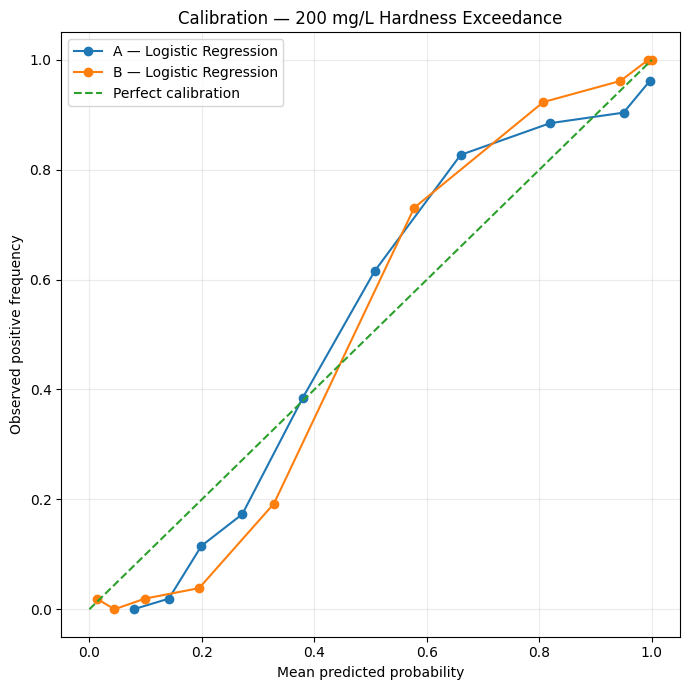



THRESHOLD STABILITY BOOTSTRAP

Test stations: 184
Bootstrap samples: 3000
Resampling unit: station
Completed 500/3,000...
Completed 1,000/3,000...
Completed 1,500/3,000...
Completed 2,000/3,000...
Completed 2,500/3,000...
Completed 3,000/3,000...


FIXED-THRESHOLD STATION-CLUSTER 95% CI



,Model,Metric,Observed,CI_Low,CI_High
0,A — Logistic Regression,Accuracy,0.8250,0.7859,0.8620
1,A — Logistic Regression,Precision,0.7638,0.7050,0.8200
2,A — Logistic Regression,Recall,0.9291,0.8945,0.9594
3,A — Logistic Regression,F1,0.8384,0.7964,0.8758
4,A — Logistic Regression,F2,0.8906,0.8575,0.9192
5,A — Logistic Regression,Balanced_Accuracy,0.8273,0.7921,0.8608
6,B — Logistic Regression,Accuracy,0.9308,0.9098,0.9515
7,B — Logistic Regression,Precision,0.9225,0.8889,0.9529
8,B — Logistic Regression,Recall,0.9370,0.9056,0.9669
9,B — Logistic Regression,F1,0.9297,0.9048,0.9520



Step 10 complete.
Saved:
 - final_aquatrust_operational_results.csv
 - aquatrust_A_calibration.csv
 - aquatrust_B_calibration.csv
 - final_threshold_cluster_bootstrap.csv
seed = 42


In [25]:
# =========================================================
# STEP 10 — FINAL MODEL CALIBRATION + THRESHOLD STABILITY
#
# Frozen operational thresholds selected WITHOUT using the
# final 520-row test set:
#
# A-LR threshold = 0.3386
# B-LR threshold = 0.4576
#
# This cell:
#   1. Evaluates calibration on untouched test data
#   2. Computes ECE
#   3. Produces reliability tables/plots
#   4. Computes fixed-threshold test metrics
#   5. Station-cluster bootstraps those fixed thresholds
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss
)

from sklearn.calibration import calibration_curve


# =========================================================
# 0. Settings
# =========================================================

seed = 42
N_BOOT = 3000

A_THRESHOLD = 0.3386
B_THRESHOLD = 0.4576

print("seed =", seed)


# =========================================================
# 1. Check Step 9B variables
# =========================================================

required = [
    "final_threshold_info",
    "split"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing variables: {missing}. "
        "Run Step 9B first."
    )


# =========================================================
# 2. Recover probabilities from Step 9B
# =========================================================

A_info = final_threshold_info[
    "A — Logistic Regression"
]

B_info = final_threshold_info[
    "B — Logistic Regression"
]

A_prob = np.asarray(
    A_info["test_prob"],
    dtype=float
)

B_prob = np.asarray(
    B_info["test_prob"],
    dtype=float
)


# y_test from Step 9B
y_final_test = np.asarray(
    y_test,
    dtype=int
)


if not (
    len(A_prob)
    == len(B_prob)
    == len(y_final_test)
):

    raise ValueError(
        "Probability / target lengths do not match."
    )


print(
    "\nFinal test observations:",
    len(y_final_test)
)


# =========================================================
# 3. Frozen thresholds
# =========================================================

thresholds = {

    "A — Logistic Regression":
        A_THRESHOLD,

    "B — Logistic Regression":
        B_THRESHOLD

}

probabilities = {

    "A — Logistic Regression":
        A_prob,

    "B — Logistic Regression":
        B_prob

}


# =========================================================
# 4. Fixed-threshold evaluation
# =========================================================

final_rows = []


for model_name, threshold in thresholds.items():

    prob = probabilities[
        model_name
    ]

    pred = (
        prob >= threshold
    ).astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            y_final_test,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )


    final_rows.append({

        "Model":
            model_name,

        "Threshold":
            threshold,

        "Accuracy":
            accuracy_score(
                y_final_test,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_final_test,
                pred
            ),

        "Precision":
            precision_score(
                y_final_test,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_final_test,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_final_test,
                pred,
                zero_division=0
            ),

        "F2":
            fbeta_score(
                y_final_test,
                pred,
                beta=2,
                zero_division=0
            ),

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp,

        "ROC-AUC":
            roc_auc_score(
                y_final_test,
                prob
            ),

        "PR-AUC":
            average_precision_score(
                y_final_test,
                prob
            ),

        "Brier":
            brier_score_loss(
                y_final_test,
                prob
            ),

        "Log_Loss":
            log_loss(
                y_final_test,
                prob
            )

    })


final_df = pd.DataFrame(
    final_rows
)


# =========================================================
# 5. Display final operational performance
# =========================================================

print("\n")
print("====================================================")
print("FINAL OPERATIONAL TEST PERFORMANCE")
print("====================================================\n")

display(
    final_df.round(4)
)


# =========================================================
# 6. Reliability / calibration tables
# =========================================================

def calibration_table(
    y_true,
    prob,
    n_bins=10
):

    bins = np.linspace(
        0,
        1,
        n_bins + 1
    )

    data = pd.DataFrame({

        "y":
            y_true,

        "prob":
            prob

    })

    data["bin"] = pd.cut(
        data["prob"],
        bins=bins,
        include_lowest=True,
        labels=False
    )

    rows = []

    for bin_id, group in (
        data.groupby(
            "bin",
            observed=True
        )
    ):

        if len(group) == 0:
            continue

        rows.append({

            "Bin":
                int(bin_id + 1),

            "N":
                len(group),

            "Mean_Predicted":
                group["prob"].mean(),

            "Observed_Positive_Rate":
                group["y"].mean(),

            "Absolute_Gap":
                abs(
                    group["prob"].mean()
                    -
                    group["y"].mean()
                )

        })

    return pd.DataFrame(rows)


A_calibration = calibration_table(
    y_final_test,
    A_prob,
    n_bins=10
)

B_calibration = calibration_table(
    y_final_test,
    B_prob,
    n_bins=10
)


print("\n")
print("====================================================")
print("CALIBRATION — A LOGISTIC REGRESSION")
print("====================================================\n")

display(
    A_calibration.round(4)
)


print("\n")
print("====================================================")
print("CALIBRATION — B LOGISTIC REGRESSION")
print("====================================================\n")

display(
    B_calibration.round(4)
)


# =========================================================
# 7. Expected Calibration Error
# =========================================================

def calculate_ece(
    y_true,
    prob,
    n_bins=10
):

    data = pd.DataFrame({

        "y":
            y_true,

        "prob":
            prob

    })

    bins = np.linspace(
        0,
        1,
        n_bins + 1
    )

    data["bin"] = pd.cut(
        data["prob"],
        bins=bins,
        include_lowest=True,
        labels=False
    )

    ece = 0.0

    for _, group in (
        data.groupby(
            "bin",
            observed=True
        )
    ):

        if len(group) == 0:
            continue

        observed = (
            group["y"].mean()
        )

        predicted = (
            group["prob"].mean()
        )

        ece += (
            len(group)
            / len(data)
        ) * abs(
            observed - predicted
        )

    return ece


A_ece = calculate_ece(
    y_final_test,
    A_prob
)

B_ece = calculate_ece(
    y_final_test,
    B_prob
)


print("\n")
print("====================================================")
print("CALIBRATION SUMMARY")
print("====================================================")

print(
    f"\nA-LR ECE  = {A_ece:.4f}"
)

print(
    f"B-LR ECE  = {B_ece:.4f}"
)


# =========================================================
# 8. Calibration curves
# =========================================================

A_true_prob, A_pred_prob = (
    calibration_curve(
        y_final_test,
        A_prob,
        n_bins=10,
        strategy="quantile"
    )
)

B_true_prob, B_pred_prob = (
    calibration_curve(
        y_final_test,
        B_prob,
        n_bins=10,
        strategy="quantile"
    )
)


plt.figure(
    figsize=(7, 7)
)

plt.plot(
    A_pred_prob,
    A_true_prob,
    marker="o",
    label="A — Logistic Regression"
)

plt.plot(
    B_pred_prob,
    B_true_prob,
    marker="o",
    label="B — Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel(
    "Mean predicted probability"
)

plt.ylabel(
    "Observed positive frequency"
)

plt.title(
    "Calibration — 200 mg/L Hardness Exceedance"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# =========================================================
# 9. Station-cluster bootstrap of FIXED thresholds
#
# Thresholds are NOT reselected here.
# We are testing whether the already-selected operating
# points remain stable across station resampling.
# =========================================================

clean = pd.read_csv(
    "clean_bihar.csv"
)

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)

modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)


test_idx = np.asarray(
    split["test_idx"],
    dtype=int
)


station_test = (
    modeling_df
    .iloc[test_idx]["station"]
    .astype(str)
    .reset_index(drop=True)
)


if len(station_test) != len(y_final_test):

    raise ValueError(
        "Station labels do not match final test set."
    )


# Station coding
station_codes, station_uniques = pd.factorize(
    station_test,
    sort=True
)

n_stations = len(
    station_uniques
)

print("\n")
print("====================================================")
print("THRESHOLD STABILITY BOOTSTRAP")
print("====================================================")

print(
    "\nTest stations:",
    n_stations
)

print(
    "Bootstrap samples:",
    N_BOOT
)

print(
    "Resampling unit: station"
)


# =========================================================
# 10. Bootstrap arrays
# =========================================================

bootstrap_metrics = {

    model_name: {

        "Accuracy": np.empty(N_BOOT),
        "Precision": np.empty(N_BOOT),
        "Recall": np.empty(N_BOOT),
        "F1": np.empty(N_BOOT),
        "F2": np.empty(N_BOOT),
        "Balanced_Accuracy": np.empty(N_BOOT)

    }

    for model_name in thresholds
}


rng = np.random.default_rng(
    seed
)


# =========================================================
# 11. Bootstrap loop
# =========================================================

for b in range(N_BOOT):

    sampled_stations = rng.integers(
        0,
        n_stations,
        size=n_stations
    )

    station_counts = np.bincount(
        sampled_stations,
        minlength=n_stations
    )

    weights = station_counts[
        station_codes
    ].astype(float)


    for model_name, threshold in thresholds.items():

        prob = probabilities[
            model_name
        ]

        pred = (
            prob >= threshold
        ).astype(int)


        bootstrap_metrics[
            model_name
        ]["Accuracy"][b] = (
            accuracy_score(
                y_final_test,
                pred,
                sample_weight=weights
            )
        )


        bootstrap_metrics[
            model_name
        ]["Precision"][b] = (
            precision_score(
                y_final_test,
                pred,
                sample_weight=weights,
                zero_division=0
            )
        )


        bootstrap_metrics[
            model_name
        ]["Recall"][b] = (
            recall_score(
                y_final_test,
                pred,
                sample_weight=weights,
                zero_division=0
            )
        )


        bootstrap_metrics[
            model_name
        ]["F1"][b] = (
            f1_score(
                y_final_test,
                pred,
                sample_weight=weights,
                zero_division=0
            )
        )


        bootstrap_metrics[
            model_name
        ]["F2"][b] = (
            fbeta_score(
                y_final_test,
                pred,
                beta=2,
                sample_weight=weights,
                zero_division=0
            )
        )


        bootstrap_metrics[
            model_name
        ]["Balanced_Accuracy"][b] = (
            balanced_accuracy_score(
                y_final_test,
                pred,
                sample_weight=weights
            )
        )


    if (b + 1) % 500 == 0:

        print(
            f"Completed {b + 1:,}/{N_BOOT:,}..."
        )


# =========================================================
# 12. Bootstrap CI table
# =========================================================

bootstrap_rows = []


for model_name in thresholds:

    for metric in [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "F2",
        "Balanced_Accuracy"
    ]:

        values = (
            bootstrap_metrics[
                model_name
            ][metric]
        )

        bootstrap_rows.append({

            "Model":
                model_name,

            "Metric":
                metric,

            "Observed":
                final_df[
                    final_df["Model"] == model_name
                ][metric]
                .iloc[0],

            "CI_Low":
                np.percentile(
                    values,
                    2.5
                ),

            "CI_High":
                np.percentile(
                    values,
                    97.5
                )

        })


threshold_bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


print("\n")
print("====================================================")
print("FIXED-THRESHOLD STATION-CLUSTER 95% CI")
print("====================================================\n")

display(
    threshold_bootstrap_df.round(4)
)


# =========================================================
# 13. Save
# =========================================================

final_df.to_csv(
    "final_aquatrust_operational_results.csv",
    index=False
)

A_calibration.to_csv(
    "aquatrust_A_calibration.csv",
    index=False
)

B_calibration.to_csv(
    "aquatrust_B_calibration.csv",
    index=False
)

threshold_bootstrap_df.to_csv(
    "final_threshold_cluster_bootstrap.csv",
    index=False
)


print("\nStep 10 complete.")

print(
    "Saved:"
)

print(
    " - final_aquatrust_operational_results.csv"
)

print(
    " - aquatrust_A_calibration.csv"
)

print(
    " - aquatrust_B_calibration.csv"
)

print(
    " - final_threshold_cluster_bootstrap.csv"
)

print(
    "seed =",
    seed
)

In [26]:
# =========================================================
# STEP 11 — CLUSTER-AWARE PAIRED A vs B INFERENCE
#
# Corrects the main weakness of row-level McNemar:
# multiple observations can belong to the same station.
#
# Comparison:
#   A Logistic Regression
#   vs
#   B Logistic Regression
#
# Primary operational thresholds:
#   A = 0.3386
#   B = 0.4576
#
# Also reports default 0.50 threshold.
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from scipy.stats import binomtest


# =========================================================
# 0. Settings
# =========================================================

seed = 42
rng = np.random.default_rng(seed)

N_BOOT = 5000
N_PERM = 10000

A_OPERATIONAL_THRESHOLD = 0.3386
B_OPERATIONAL_THRESHOLD = 0.4576

print("seed =", seed)


# =========================================================
# 1. Recover final probabilities
# =========================================================

if "final_threshold_info" not in globals():
    raise RuntimeError(
        "final_threshold_info not found. "
        "Run Step 9B / Step 10 first."
    )

A_prob = np.asarray(
    final_threshold_info[
        "A — Logistic Regression"
    ]["test_prob"],
    dtype=float
)

B_prob = np.asarray(
    final_threshold_info[
        "B — Logistic Regression"
    ]["test_prob"],
    dtype=float
)

y_test_final = np.asarray(
    y_test,
    dtype=int
)


if not (
    len(A_prob)
    == len(B_prob)
    == len(y_test_final)
):
    raise ValueError(
        "A/B probabilities and y_test "
        "are not aligned."
    )


# =========================================================
# 2. Recover exact station labels
# =========================================================

clean = pd.read_csv(
    "clean_bihar.csv"
)

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)

modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)


test_idx = np.asarray(
    split["test_idx"],
    dtype=int
)

station_test = (
    modeling_df
    .iloc[test_idx]["station"]
    .astype(str)
    .reset_index(drop=True)
)


if len(station_test) != len(y_test_final):
    raise ValueError(
        "Station labels do not match test rows."
    )


# =========================================================
# 3. Encode stations
# =========================================================

station_codes, station_names = pd.factorize(
    station_test,
    sort=True
)

n_stations = len(
    station_names
)

print("\nTest rows   :", len(y_test_final))
print("Test stations:", n_stations)


# =========================================================
# 4. Metric helper
# =========================================================

def weighted_metrics(
    y,
    pred,
    score,
    weights
):

    metrics = {

        "Accuracy":
            accuracy_score(
                y,
                pred,
                sample_weight=weights
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y,
                pred,
                sample_weight=weights
            ),

        "Precision":
            precision_score(
                y,
                pred,
                sample_weight=weights,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y,
                pred,
                sample_weight=weights,
                zero_division=0
            ),

        "F1":
            f1_score(
                y,
                pred,
                sample_weight=weights,
                zero_division=0
            )
    }


    positive_weight = np.sum(
        weights[y == 1]
    )

    negative_weight = np.sum(
        weights[y == 0]
    )

    if (
        positive_weight > 0
        and negative_weight > 0
    ):

        metrics["ROC-AUC"] = (
            roc_auc_score(
                y,
                score,
                sample_weight=weights
            )
        )

    else:

        metrics["ROC-AUC"] = np.nan


    return metrics


# =========================================================
# 5. Prediction configurations
# =========================================================

prediction_configs = {

    "Default 0.50": (
        A_prob >= 0.50,
        B_prob >= 0.50
    ),

    "Operational": (
        A_prob >= A_OPERATIONAL_THRESHOLD,
        B_prob >= B_OPERATIONAL_THRESHOLD
    )

}


# =========================================================
# 6. Point estimates
# =========================================================

point_rows = []


for config_name, (
    A_pred,
    B_pred
) in prediction_configs.items():

    A_metrics = weighted_metrics(
        y_test_final,
        A_pred.astype(int),
        A_prob,
        np.ones(len(y_test_final))
    )

    B_metrics = weighted_metrics(
        y_test_final,
        B_pred.astype(int),
        B_prob,
        np.ones(len(y_test_final))
    )


    for metric in A_metrics:

        point_rows.append({

            "Configuration":
                config_name,

            "Metric":
                metric,

            "A":
                A_metrics[metric],

            "B":
                B_metrics[metric],

            "B_minus_A":
                B_metrics[metric]
                - A_metrics[metric]

        })


point_df = pd.DataFrame(
    point_rows
)


print("\n")
print("====================================================")
print("POINT ESTIMATE — A vs B")
print("====================================================\n")

display(
    point_df.round(4)
)


# =========================================================
# 7. Cluster bootstrap of paired differences
# =========================================================

metric_names = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]


bootstrap_store = {

    config_name: {

        metric: np.empty(N_BOOT)

        for metric in metric_names

    }

    for config_name in prediction_configs
}


for b in range(N_BOOT):

    # -----------------------------------------------------
    # Sample whole stations
    # -----------------------------------------------------

    sampled_station_ids = rng.integers(
        0,
        n_stations,
        size=n_stations
    )

    station_counts = np.bincount(
        sampled_station_ids,
        minlength=n_stations
    )

    weights = station_counts[
        station_codes
    ].astype(float)


    for config_name, (
        A_pred,
        B_pred
    ) in prediction_configs.items():

        A_metrics = weighted_metrics(
            y_test_final,
            A_pred.astype(int),
            A_prob,
            weights
        )

        B_metrics = weighted_metrics(
            y_test_final,
            B_pred.astype(int),
            B_prob,
            weights
        )


        for metric in metric_names:

            bootstrap_store[
                config_name
            ][metric][b] = (
                B_metrics[metric]
                -
                A_metrics[metric]
            )


    if (b + 1) % 1000 == 0:

        print(
            f"Bootstrap "
            f"{b + 1:,}/{N_BOOT:,}"
        )


# =========================================================
# 8. Bootstrap CI
# =========================================================

bootstrap_rows = []


for config_name in prediction_configs:

    for metric in metric_names:

        values = (
            bootstrap_store[
                config_name
            ][metric]
        )

        values = values[
            np.isfinite(values)
        ]

        ci_low = np.percentile(
            values,
            2.5
        )

        ci_high = np.percentile(
            values,
            97.5
        )

        point_value = point_df[
            (
                point_df["Configuration"]
                == config_name
            )
            &
            (
                point_df["Metric"]
                == metric
            )
        ]["B_minus_A"].iloc[0]


        bootstrap_rows.append({

            "Configuration":
                config_name,

            "Metric":
                metric,

            "B_minus_A":
                point_value,

            "CI_Low":
                ci_low,

            "CI_High":
                ci_high,

            "CI_Excludes_Zero":
                (
                    ci_low > 0
                    or ci_high < 0
                )

        })


paired_bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


print("\n")
print("====================================================")
print("STATION-CLUSTER PAIRED BOOTSTRAP — 95% CI")
print("====================================================\n")

display(
    paired_bootstrap_df.round(4)
)


# =========================================================
# 9. Station-level accuracy differences
# =========================================================

permutation_results = []


for config_name, (
    A_pred,
    B_pred
) in prediction_configs.items():

    station_differences = []


    for station_id in range(
        n_stations
    ):

        idx = (
            station_codes
            == station_id
        )

        A_acc = np.mean(
            A_pred[idx]
            ==
            y_test_final[idx]
        )

        B_acc = np.mean(
            B_pred[idx]
            ==
            y_test_final[idx]
        )

        station_differences.append(
            B_acc - A_acc
        )


    station_differences = np.asarray(
        station_differences,
        dtype=float
    )


    observed = (
        station_differences.mean()
    )


    # -----------------------------------------------------
    # Sign-flip permutation
    #
    # H0: no systematic A/B difference
    # -----------------------------------------------------

    abs_diffs = np.abs(
        station_differences
    )

    exceedances = 0


    for p in range(
        N_PERM
    ):

        signs = rng.choice(
            [-1, 1],
            size=n_stations
        )

        permuted_mean = np.mean(
            signs * abs_diffs
        )

        if abs(permuted_mean) >= abs(observed):

            exceedances += 1


    p_value = (
        (exceedances + 1)
        /
        (N_PERM + 1)
    )


    # -----------------------------------------------------
    # Station sign test
    # -----------------------------------------------------

    positive = int(
        np.sum(
            station_differences > 0
        )
    )

    negative = int(
        np.sum(
            station_differences < 0
        )
    )

    ties = int(
        np.sum(
            station_differences == 0
        )
    )


    non_tied = positive + negative


    if non_tied > 0:

        sign_test = binomtest(
            positive,
            non_tied,
            0.5,
            alternative="two-sided"
        ).pvalue

    else:

        sign_test = 1.0


    permutation_results.append({

        "Configuration":
            config_name,

        "Mean_Station_Accuracy_Difference":
            observed,

        "Stations_B_Better":
            positive,

        "Stations_A_Better":
            negative,

        "Tied":
            ties,

        "Permutation_p":
            p_value,

        "Sign_Test_p":
            sign_test

    })


cluster_inference_df = pd.DataFrame(
    permutation_results
)


print("\n")
print("====================================================")
print("STATION-LEVEL PAIRED INFERENCE")
print("====================================================\n")

display(
    cluster_inference_df.round(6)
)


# =========================================================
# 10. Save
# =========================================================

point_df.to_csv(
    "cluster_aware_A_vs_B_point_estimates.csv",
    index=False
)

paired_bootstrap_df.to_csv(
    "cluster_aware_A_vs_B_bootstrap.csv",
    index=False
)

cluster_inference_df.to_csv(
    "cluster_aware_A_vs_B_inference.csv",
    index=False
)


print("\nStep 11 complete.")

print(
    "Saved:"
)

print(
    " - cluster_aware_A_vs_B_point_estimates.csv"
)

print(
    " - cluster_aware_A_vs_B_bootstrap.csv"
)

print(
    " - cluster_aware_A_vs_B_inference.csv"
)

print(
    "seed =",
    seed
)

seed = 42

Test rows   : 520
Test stations: 184


POINT ESTIMATE — A vs B



,Configuration,Metric,A,B,B_minus_A
0,Default 0.50,Accuracy,0.8519,0.9269,0.0750
1,Default 0.50,Balanced_Accuracy,0.8509,0.9267,0.0758
2,Default 0.50,Precision,0.8798,0.9320,0.0522
3,Default 0.50,Recall,0.8071,0.9173,0.1102
4,Default 0.50,F1,0.8419,0.9246,0.0827
5,Default 0.50,ROC-AUC,0.9208,0.9768,0.0561
6,Operational,Accuracy,0.8250,0.9308,0.1058
7,Operational,Balanced_Accuracy,0.8273,0.9309,0.1036
8,Operational,Precision,0.7638,0.9225,0.1587
9,Operational,Recall,0.9291,0.9370,0.0079


Bootstrap 1,000/5,000
Bootstrap 2,000/5,000
Bootstrap 3,000/5,000
Bootstrap 4,000/5,000
Bootstrap 5,000/5,000


STATION-CLUSTER PAIRED BOOTSTRAP — 95% CI



,Configuration,Metric,B_minus_A,CI_Low,CI_High,CI_Excludes_Zero
0,Default 0.50,Accuracy,0.0750,0.0431,0.1089,True
1,Default 0.50,Balanced_Accuracy,0.0758,0.0438,0.1096,True
2,Default 0.50,Precision,0.0522,0.0082,0.1023,True
3,Default 0.50,Recall,0.1102,0.0622,0.1621,True
4,Default 0.50,F1,0.0827,0.0483,0.1202,True
5,Default 0.50,ROC-AUC,0.0561,0.0309,0.0862,True
6,Operational,Accuracy,0.1058,0.0701,0.1431,True
7,Operational,Balanced_Accuracy,0.1036,0.0698,0.1389,True
8,Operational,Precision,0.1587,0.1128,0.2076,True
9,Operational,Recall,0.0079,-0.0277,0.0456,False




STATION-LEVEL PAIRED INFERENCE



,Configuration,Mean_Station_Accuracy_Difference,Stations_B_Better,Stations_A_Better,Tied,Permutation_p,Sign_Test_p
0,Default 0.50,0.087733,39,10,135,0.0001,0.000038
1,Operational,0.101520,49,8,127,0.0001,0.000000



Step 11 complete.
Saved:
 - cluster_aware_A_vs_B_point_estimates.csv
 - cluster_aware_A_vs_B_bootstrap.csv
 - cluster_aware_A_vs_B_inference.csv
seed = 42


In [28]:
# =========================================================
# STEP 12 — COMPLETE-CASE / MISSINGNESS AUDIT
# CORRECTED VERSION
#
# Audits why:
#
#   2464 hardness-available rows
#             ↓
#   2105 complete A+B rows
#
# Required A+B variables:
#   pH, EC, lat, lon, HCO3, Cl, Na
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import (
    ks_2samp,
    chi2_contingency
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score
)

seed = 42

print("seed =", seed)


# =========================================================
# 1. Load cleaned dataset
# =========================================================

if not os.path.exists(
    "clean_bihar.csv"
):
    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean = pd.read_csv(
    "clean_bihar.csv"
)


# =========================================================
# 2. Modeling variables
# =========================================================

features_A = [
    "pH",
    "EC",
    "lat",
    "lon"
]

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

all_model_features = features_B


# =========================================================
# 3. Hardness-available population
# =========================================================

hardness_df = (
    clean
    .dropna(
        subset=["hardness"]
    )
    .copy()
    .reset_index(drop=True)
)

hardness_df["y"] = (
    hardness_df["hardness"] > 200
).astype(int)


# =========================================================
# 4. COMPLETE A+B FLAG
# =========================================================

hardness_df["complete_AB"] = (
    hardness_df[
        all_model_features
    ]
    .notna()
    .all(axis=1)
)


complete_df = (
    hardness_df[
        hardness_df["complete_AB"]
    ]
    .copy()
    .reset_index(drop=True)
)


excluded_df = (
    hardness_df[
        ~hardness_df["complete_AB"]
    ]
    .copy()
    .reset_index(drop=True)
)


# =========================================================
# 5. Size audit
# =========================================================

n_hardness = len(
    hardness_df
)

n_complete = len(
    complete_df
)

n_excluded = len(
    excluded_df
)

retention = (
    n_complete
    /
    n_hardness
)

exclusion = (
    n_excluded
    /
    n_hardness
)


print("\n")
print("====================================================")
print("COMPLETE-CASE SIZE AUDIT")
print("====================================================")

print(
    f"\nHardness available : {n_hardness:,}"
)

print(
    f"Complete A+B       : {n_complete:,}"
)

print(
    f"Excluded           : {n_excluded:,}"
)

print(
    f"Retention          : {retention:.4%}"
)

print(
    f"Exclusion          : {exclusion:.4%}"
)


# =========================================================
# 6. Missingness BY EVERY MODELING FEATURE
# =========================================================

missing_rows = []

for feature in all_model_features:

    missing_count = int(
        hardness_df[feature].isna().sum()
    )

    missing_rows.append({

        "Feature":
            feature,

        "Missing":
            missing_count,

        "Missing_Rate":
            missing_count / n_hardness

    })


missingness_df = (
    pd.DataFrame(
        missing_rows
    )
    .sort_values(
        "Missing",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n")
print("====================================================")
print("MISSINGNESS — ALL MODELING FEATURES")
print("====================================================\n")

display(
    missingness_df.round(4)
)


# =========================================================
# 7. How many variables are missing per row?
# =========================================================

hardness_df["n_missing_model_features"] = (
    hardness_df[
        all_model_features
    ]
    .isna()
    .sum(axis=1)
)


missing_pattern = (
    hardness_df
    .groupby(
        "n_missing_model_features"
    )
    .agg(
        Rows=("y", "size"),
        Positive=("y", "sum"),
        Positive_Rate=("y", "mean")
    )
    .reset_index()
)


print("\n")
print("====================================================")
print("NUMBER OF MISSING MODEL FEATURES PER ROW")
print("====================================================\n")

display(
    missing_pattern.round(4)
)


# =========================================================
# 8. Exact missingness patterns
# =========================================================

def missing_pattern_name(row):

    missing = [
        feature
        for feature in all_model_features
        if pd.isna(row[feature])
    ]

    if len(missing) == 0:
        return "None"

    return " + ".join(missing)


hardness_df["Missing_Pattern"] = (
    hardness_df
    .apply(
        missing_pattern_name,
        axis=1
    )
)


pattern_summary = (
    hardness_df
    .groupby(
        "Missing_Pattern"
    )
    .agg(
        Rows=("y", "size"),
        Positive=("y", "sum"),
        Positive_Rate=("y", "mean")
    )
    .reset_index()
    .sort_values(
        "Rows",
        ascending=False
    )
)


print("\n")
print("====================================================")
print("EXACT MISSINGNESS PATTERNS")
print("====================================================\n")

display(
    pattern_summary.round(4)
)


# =========================================================
# 9. Target prevalence:
#    Complete vs excluded
# =========================================================

target_summary = pd.DataFrame({

    "Population": [
        "All hardness-available",
        "Complete A+B",
        "Excluded"
    ],

    "Rows": [
        len(hardness_df),
        len(complete_df),
        len(excluded_df)
    ],

    "Positive": [
        int(hardness_df["y"].sum()),
        int(complete_df["y"].sum()),
        int(excluded_df["y"].sum())
    ],

    "Positive_Rate": [
        hardness_df["y"].mean(),
        complete_df["y"].mean(),
        excluded_df["y"].mean()
    ]

})


print("\n")
print("====================================================")
print("TARGET PREVALENCE AUDIT")
print("====================================================\n")

display(
    target_summary.round(4)
)

print(
    "\nComplete - excluded prevalence difference:",
    round(
        complete_df["y"].mean()
        -
        excluded_df["y"].mean(),
        4
    )
)


# =========================================================
# 10. Compare observed variable distributions
#
# Complete vs excluded.
# =========================================================

continuous_features = [
    "hardness",
    "pH",
    "EC",
    "lat",
    "lon"
]


distribution_rows = []


for feature in continuous_features:

    full_values = (
        hardness_df[feature]
        .dropna()
        .to_numpy()
    )

    complete_values = (
        complete_df[feature]
        .dropna()
        .to_numpy()
    )


    if (
        len(full_values) > 0
        and len(complete_values) > 0
    ):

        ks_stat, ks_p = (
            ks_2samp(
                full_values,
                complete_values
            )
        )

    else:

        ks_stat = np.nan
        ks_p = np.nan


    distribution_rows.append({

        "Feature":
            feature,

        "Full_Mean":
            np.mean(full_values),

        "Complete_Mean":
            np.mean(complete_values),

        "Full_Median":
            np.median(full_values),

        "Complete_Median":
            np.median(complete_values),

        "KS_Statistic":
            ks_stat,

        "KS_p_value":
            ks_p

    })


distribution_df = pd.DataFrame(
    distribution_rows
)


print("\n")
print("====================================================")
print("OBSERVED-VARIABLE DISTRIBUTION AUDIT")
print("====================================================\n")

display(
    distribution_df.round(5)
)


# =========================================================
# 11. Year-level completeness
# =========================================================

year_audit = (
    hardness_df
    .groupby("year")
    .agg(

        Total=("complete_AB", "size"),

        Complete=(
            "complete_AB",
            "sum"
        ),

        Positive_Rate=(
            "y",
            "mean"
        )

    )
    .reset_index()
)


year_audit["Complete_Rate"] = (
    year_audit["Complete"]
    /
    year_audit["Total"]
)


year_audit["Excluded"] = (
    year_audit["Total"]
    -
    year_audit["Complete"]
)


print("\n")
print("====================================================")
print("YEAR-LEVEL COMPLETENESS")
print("====================================================\n")

display(
    year_audit.round(4)
)


# =========================================================
# 12. District-level completeness
# =========================================================

district_audit = (
    hardness_df
    .groupby("district")
    .agg(

        Total=("complete_AB", "size"),

        Complete=(
            "complete_AB",
            "sum"
        ),

        Positive=(
            "y",
            "sum"
        ),

        Positive_Rate=(
            "y",
            "mean"
        )

    )
    .reset_index()
)


district_audit["Complete_Rate"] = (
    district_audit["Complete"]
    /
    district_audit["Total"]
)


district_audit["Excluded"] = (
    district_audit["Total"]
    -
    district_audit["Complete"]
)


district_audit = (
    district_audit
    .sort_values(
        "Complete_Rate"
    )
    .reset_index(drop=True)
)


print("\n")
print("====================================================")
print("DISTRICT-LEVEL COMPLETENESS")
print("====================================================\n")

display(
    district_audit.round(4)
)


# =========================================================
# 13. Year × completeness test
# =========================================================

year_table = pd.crosstab(
    hardness_df["year"],
    hardness_df["complete_AB"]
)


if (
    year_table.shape[0] > 1
    and year_table.shape[1] > 1
):

    chi2_year, p_year, dof_year, _ = (
        chi2_contingency(
            year_table
        )
    )

else:

    chi2_year = np.nan
    p_year = np.nan
    dof_year = np.nan


print("\n")
print("====================================================")
print("YEAR × COMPLETENESS TEST")
print("====================================================")

print(
    f"\nChi-square = {chi2_year:.4f}"
)

print(
    f"p-value    = {p_year:.6g}"
)

print(
    f"dof        = {dof_year}"
)


# =========================================================
# 14. District × completeness test
# =========================================================

district_table = pd.crosstab(
    hardness_df["district"],
    hardness_df["complete_AB"]
)


if (
    district_table.shape[0] > 1
    and district_table.shape[1] > 1
):

    chi2_district, p_district, dof_district, _ = (
        chi2_contingency(
            district_table
        )
    )

else:

    chi2_district = np.nan
    p_district = np.nan
    dof_district = np.nan


print("\n")
print("====================================================")
print("DISTRICT × COMPLETENESS TEST")
print("====================================================")

print(
    f"\nChi-square = {chi2_district:.4f}"
)

print(
    f"p-value    = {p_district:.6g}"
)

print(
    f"dof        = {dof_district}"
)


# =========================================================
# 15. Missingness predictability audit
#
# Can observed variables predict whether a row is complete?
#
# Use variables that may themselves be observed even when
# additional chemistry is missing:
#
# pH + EC + latitude + longitude + hardness
#
# This is NOT an AquaTrust model.
# =========================================================

selection_features = [
    "pH",
    "EC",
    "lat",
    "lon",
    "hardness"
]


selection_df = (
    hardness_df[
        selection_features
        +
        ["complete_AB"]
    ]
    .dropna()
    .copy()
)


X_selection = (
    selection_df[
        selection_features
    ]
)

y_selection = (
    selection_df[
        "complete_AB"
    ]
    .astype(int)
)


if y_selection.nunique() == 2:

    selection_model = Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "model",
            LogisticRegression(
                max_iter=3000,
                random_state=seed
            )
        )

    ])


    selection_model.fit(
        X_selection,
        y_selection
    )


    selection_prob = (
        selection_model
        .predict_proba(
            X_selection
        )[:, 1]
    )


    selection_auc = (
        roc_auc_score(
            y_selection,
            selection_prob
        )
    )


    selection_pred = (
        selection_prob >= 0.5
    ).astype(int)


    selection_accuracy = (
        accuracy_score(
            y_selection,
            selection_pred
        )
    )


else:

    selection_auc = np.nan
    selection_accuracy = np.nan


print("\n")
print("====================================================")
print("MISSINGNESS PREDICTABILITY AUDIT")
print("====================================================")

print(
    f"\nRows used: {len(selection_df)}"
)

print(
    "Predictors: pH + EC + lat + lon + hardness"
)

print(
    f"\nAUC = {selection_auc:.4f}"
)

print(
    f"Accuracy = {selection_accuracy:.4f}"
)


# =========================================================
# 16. Station-level completeness
# =========================================================

station_completion = (
    hardness_df
    .groupby("station")
    .agg(

        Observations=(
            "complete_AB",
            "size"
        ),

        Complete=(
            "complete_AB",
            "sum"
        ),

        Positive_Rate=(
            "y",
            "mean"
        )

    )
    .reset_index()
)


station_completion["Complete_Rate"] = (
    station_completion["Complete"]
    /
    station_completion["Observations"]
)


print("\n")
print("====================================================")
print("STATION-LEVEL COMPLETENESS")
print("====================================================")

print(
    "\nStations:",
    len(station_completion)
)

print(
    "Median completion rate:",
    f"{station_completion['Complete_Rate'].median():.4f}"
)

print(
    "Mean completion rate:",
    f"{station_completion['Complete_Rate'].mean():.4f}"
)

print(
    "Stations with zero complete A+B:",
    int(
        (
            station_completion["Complete_Rate"]
            == 0
        ).sum()
    )
)

print(
    "Stations with 100% complete A+B:",
    int(
        (
            station_completion["Complete_Rate"]
            == 1
        ).sum()
    )
)


# =========================================================
# 17. Save everything
# =========================================================

missingness_df.to_csv(
    "all_feature_missingness_audit.csv",
    index=False
)

missing_pattern.to_csv(
    "missing_feature_count_audit.csv",
    index=False
)

pattern_summary.to_csv(
    "missingness_pattern_audit.csv",
    index=False
)

target_summary.to_csv(
    "missingness_target_summary.csv",
    index=False
)

distribution_df.to_csv(
    "complete_case_distribution_audit.csv",
    index=False
)

year_audit.to_csv(
    "complete_case_year_audit.csv",
    index=False
)

district_audit.to_csv(
    "complete_case_district_audit.csv",
    index=False
)

station_completion.to_csv(
    "complete_case_station_audit.csv",
    index=False
)


print("\n")
print("====================================================")
print("STEP 12 COMPLETE")
print("====================================================")

print("\nSaved:")
print(" - all_feature_missingness_audit.csv")
print(" - missing_feature_count_audit.csv")
print(" - missingness_pattern_audit.csv")
print(" - missingness_target_summary.csv")
print(" - complete_case_distribution_audit.csv")
print(" - complete_case_year_audit.csv")
print(" - complete_case_district_audit.csv")
print(" - complete_case_station_audit.csv")

print(
    "\nseed =",
    seed
)

seed = 42


COMPLETE-CASE SIZE AUDIT

Hardness available : 2,464
Complete A+B       : 2,105
Excluded           : 359
Retention          : 85.4302%
Exclusion          : 14.5698%


MISSINGNESS — ALL MODELING FEATURES



,Feature,Missing,Missing_Rate
0,pH,303,0.1230
1,Na,47,0.0191
2,Cl,25,0.0101
3,HCO3,11,0.0045
4,EC,0,0.0000
5,lat,0,0.0000
6,lon,0,0.0000




NUMBER OF MISSING MODEL FEATURES PER ROW



,n_missing_model_features,Rows,Positive,Positive_Rate
0,0,2105,1078,0.5121
1,1,337,207,0.6142
2,2,17,6,0.3529
3,3,5,4,0.8000




EXACT MISSINGNESS PATTERNS



...



YEAR-LEVEL COMPLETENESS



,year,Total,Complete,Positive_Rate,Complete_Rate,Excluded
0,2000,32,32,0.4688,1.0000,0
1,2001,69,69,0.6522,1.0000,0
2,2003,1,0,1.0000,0.0000,1
3,2004,45,45,0.6000,1.0000,0
4,2005,98,97,0.5612,0.9898,1
5,2006,24,24,0.6250,1.0000,0
6,2007,147,146,0.4626,0.9932,1
7,2008,168,168,0.4762,1.0000,0
8,2009,154,0,0.5260,0.0000,154
9,2010,167,18,0.6647,0.1078,149




DISTRICT-LEVEL COMPLETENESS



,district,Total,Complete,Positive,Positive_Rate,Complete_Rate,Excluded
0,KAIMUR,45,30,34,0.7556,0.6667,15
1,LAKHISARAI,25,17,12,0.4800,0.6800,8
2,ROHTAS,76,57,36,0.4737,0.7500,19
3,PURBA CHAMPARAN,94,72,46,0.4894,0.7660,22
4,AURANGABAD,75,59,44,0.5867,0.7867,16
5,GOPALGANJ,78,62,42,0.5385,0.7949,16
6,KISHANGANJ,40,32,4,0.1000,0.8000,8
7,SAHARSA,61,49,32,0.5246,0.8033,12
8,BANKA,51,41,21,0.4118,0.8039,10
9,BUXAR,62,50,39,0.6290,0.8065,12




YEAR × COMPLETENESS TEST

Chi-square = 1998.8390
p-value    = 0
dof        = 15


DISTRICT × COMPLETENESS TEST

Chi-square = 76.2966
p-value    = 0.000101978
dof        = 36


MISSINGNESS PREDICTABILITY AUDIT

Rows used: 2161
Predictors: pH + EC + lat + lon + hardness

AUC = 0.8189
Accuracy = 0.9741


STATION-LEVEL COMPLETENESS

Stations: 745
Median completion rate: 1.0000
Mean completion rate: 0.8937
Stations with zero complete A+B: 10
Stations with 100% complete A+B: 479


STEP 12 COMPLETE

Saved:
 - all_feature_missingness_audit.csv
 - missing_feature_count_audit.csv
 - missingness_pattern_audit.csv
 - missingness_target_summary.csv
 - complete_case_distribution_audit.csv
 - complete_case_year_audit.csv
 - complete_case_district_audit.csv
 - complete_case_station_audit.csv

seed = 42


In [29]:
# =========================================================
# STEP 13 — MISSINGNESS-AWARE SENSITIVITY ANALYSIS
#
# Primary analysis used:
#   2105 complete A+B observations.
#
# Sensitivity analysis uses:
#   ALL 2464 hardness-available observations.
#
# Missing predictor values are imputed INSIDE the pipeline
# using training data only.
#
# No missingness indicators are added.
# This prevents the model from directly learning the
# missingness pattern itself.
#
# Same basic station-held-out design.
#
# Feature Sets:
#   A = pH + EC + lat + lon
#   B = pH + EC + lat + lon + HCO3 + Cl + Na
#
# Models:
#   Logistic Regression
#   Random Forest
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

seed = 42

print("seed =", seed)


# =========================================================
# 1. Load cleaned dataset
# =========================================================

if not os.path.exists(
    "clean_bihar.csv"
):

    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean = pd.read_csv(
    "clean_bihar.csv"
)


# =========================================================
# 2. Keep every observation with hardness available
# =========================================================

analysis_df = (
    clean
    .dropna(
        subset=["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)


# Target
analysis_df["y"] = (
    analysis_df["hardness"] > 200
).astype(int)


# Clean station/district strings
analysis_df["station"] = (
    analysis_df["station"]
    .astype(str)
    .str.strip()
)

analysis_df["district"] = (
    analysis_df["district"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# =========================================================
# 3. Feature sets
# =========================================================

features_A = [
    "pH",
    "EC",
    "lat",
    "lon"
]

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]


# =========================================================
# 4. Dataset summary
# =========================================================

print("\n")
print("====================================================")
print("SENSITIVITY DATASET")
print("====================================================")

print(
    "\nRows:",
    len(analysis_df)
)

print(
    "Stations:",
    analysis_df["station"].nunique()
)

print(
    "Districts:",
    analysis_df["district"].nunique()
)

print(
    "Positive:",
    int(analysis_df["y"].sum())
)

print(
    "Positive rate:",
    f"{analysis_df['y'].mean():.4%}"
)


# =========================================================
# 5. Station-grouped split
# =========================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=seed
)


train_idx_sens, test_idx_sens = next(
    gss.split(
        analysis_df,
        analysis_df["y"],
        groups=analysis_df["station"]
    )
)


train_idx_sens = np.asarray(
    train_idx_sens,
    dtype=int
)

test_idx_sens = np.asarray(
    test_idx_sens,
    dtype=int
)


# =========================================================
# 6. Train/test data
# =========================================================

train_sens = (
    analysis_df
    .iloc[train_idx_sens]
    .reset_index(drop=True)
)

test_sens = (
    analysis_df
    .iloc[test_idx_sens]
    .reset_index(drop=True)
)


y_train_sens = (
    train_sens["y"]
    .to_numpy()
    .astype(int)
)

y_test_sens = (
    test_sens["y"]
    .to_numpy()
    .astype(int)
)


# =========================================================
# 7. Split sanity check
# =========================================================

train_stations = set(
    train_sens["station"]
)

test_stations = set(
    test_sens["station"]
)

station_overlap = (
    train_stations
    .intersection(
        test_stations
    )
)


if station_overlap:

    raise ValueError(
        "Station leakage detected."
    )


print("\n")
print("====================================================")
print("SENSITIVITY STATION-HOLDOUT")
print("====================================================")

print(
    "\nTrain rows:",
    len(train_sens)
)

print(
    "Test rows:",
    len(test_sens)
)

print(
    "Train stations:",
    len(train_stations)
)

print(
    "Test stations:",
    len(test_stations)
)

print(
    "Station overlap:",
    len(station_overlap)
)

print(
    "Train positive rate:",
    f"{y_train_sens.mean():.4%}"
)

print(
    "Test positive rate:",
    f"{y_test_sens.mean():.4%}"
)


# =========================================================
# 8. Model builders
# =========================================================

def make_lr():

    return Pipeline([

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        ),

        (
            "model",
            LogisticRegression(
                max_iter=3000,
                random_state=seed
            )
        )

    ])


def make_rf():

    return Pipeline([

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                random_state=seed,
                n_jobs=-1
            )
        )

    ])


model_builders = {

    "Logistic Regression":
        make_lr,

    "Random Forest":
        make_rf

}


# =========================================================
# 9. Train/evaluate A and B
# =========================================================

sensitivity_results = []

sensitivity_models = {
    "A": {},
    "B": {}
}


for feature_set, features in [
    ("A", features_A),
    ("B", features_B)
]:

    X_train = (
        train_sens[
            features
        ]
        .copy()
    )

    X_test = (
        test_sens[
            features
        ]
        .copy()
    )


    print(
        f"\nTraining Feature Set {feature_set}"
    )


    for model_name, builder in model_builders.items():

        model = builder()


        # -------------------------------------------------
        # Fit
        # -------------------------------------------------

        model.fit(
            X_train,
            y_train_sens
        )


        # -------------------------------------------------
        # Predict
        # -------------------------------------------------

        pred = model.predict(
            X_test
        )


        score = (
            model
            .predict_proba(
                X_test
            )[:, 1]
        )


        # -------------------------------------------------
        # Metrics
        # -------------------------------------------------

        accuracy = accuracy_score(
            y_test_sens,
            pred
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y_test_sens,
                pred
            )
        )

        precision = precision_score(
            y_test_sens,
            pred,
            zero_division=0
        )

        recall = recall_score(
            y_test_sens,
            pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test_sens,
            pred,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            y_test_sens,
            score
        )

        pr_auc = (
            average_precision_score(
                y_test_sens,
                score
            )
        )


        sensitivity_results.append({

            "Feature Set":
                feature_set,

            "Model":
                model_name,

            "Accuracy":
                accuracy,

            "Balanced_Accuracy":
                balanced_accuracy,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1":
                f1,

            "ROC-AUC":
                roc_auc,

            "PR-AUC":
                pr_auc

        })


        sensitivity_models[
            feature_set
        ][model_name] = model


sensitivity_df = pd.DataFrame(
    sensitivity_results
)


# =========================================================
# 10. Display results
# =========================================================

print("\n")
print("====================================================")
print("MISSINGNESS-AWARE SENSITIVITY RESULTS")
print("====================================================\n")

display(
    sensitivity_df[
        [
            "Feature Set",
            "Model",
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC"
        ]
    ]
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .round(4)
)


# =========================================================
# 11. Direct A → B differences
# =========================================================

print("\n")
print("====================================================")
print("SENSITIVITY — B MINUS A")
print("====================================================")


for model_name in model_builders.keys():

    temp = (
        sensitivity_df[
            sensitivity_df[
                "Model"
            ] == model_name
        ]
        .set_index(
            "Feature Set"
        )
    )


    print(
        f"\n--- {model_name} ---"
    )


    for metric in [
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]:

        delta = (
            temp.loc[
                "B",
                metric
            ]
            -
            temp.loc[
                "A",
                metric
            ]
        )

        print(
            f"{metric}: "
            f"{delta:+.4f}"
        )


# =========================================================
# 12. Compare primary vs sensitivity results
# =========================================================

print("\n")
print("====================================================")
print("PRIMARY COMPLETE-CASE vs SENSITIVITY")
print("====================================================")


primary_rows = []

for _, row in results_df.iterrows():

    if row["Model"] in [
        "Logistic Regression",
        "Random Forest"
    ]:

        primary_rows.append({

            "Analysis":
                "Primary complete-case",

            "Feature Set":
                row["Feature Set"],

            "Model":
                row["Model"],

            "Accuracy":
                row["Accuracy"],

            "F1":
                row["F1"],

            "ROC-AUC":
                row["ROC-AUC"]

        })


primary_compare_df = pd.DataFrame(
    primary_rows
)


sensitivity_compare_df = (
    sensitivity_df[
        [
            "Feature Set",
            "Model",
            "Accuracy",
            "F1",
            "ROC-AUC"
        ]
    ]
    .copy()
)

sensitivity_compare_df.insert(
    0,
    "Analysis",
    "Missingness-aware sensitivity"
)


combined_sensitivity_df = pd.concat(
    [
        primary_compare_df,
        sensitivity_compare_df
    ],
    ignore_index=True
)


display(
    combined_sensitivity_df.round(4)
)


# =========================================================
# 13. Missingness counts actually used by each pipeline
# =========================================================

print("\n")
print("====================================================")
print("MISSING VALUES IN SENSITIVITY DATASET")
print("====================================================\n")

missing_counts = (
    analysis_df[
        features_B
    ]
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)


missing_rates = (
    missing_counts
    /
    len(analysis_df)
)


missing_sensitivity_df = pd.DataFrame({

    "Feature":
        missing_counts.index,

    "Missing":
        missing_counts.values,

    "Missing_Rate":
        missing_rates.values

})


display(
    missing_sensitivity_df.round(4)
)


# =========================================================
# 14. Save
# =========================================================

sensitivity_df.to_csv(
    "missingness_aware_sensitivity_results.csv",
    index=False
)

combined_sensitivity_df.to_csv(
    "primary_vs_sensitivity_results.csv",
    index=False
)

missing_sensitivity_df.to_csv(
    "sensitivity_dataset_missingness.csv",
    index=False
)


print("\nStep 13 complete.")

print(
    "Saved:"
)

print(
    " - missingness_aware_sensitivity_results.csv"
)

print(
    " - primary_vs_sensitivity_results.csv"
)

print(
    " - sensitivity_dataset_missingness.csv"
)

print(
    "seed =",
    seed
)

seed = 42


SENSITIVITY DATASET

Rows: 2464
Stations: 745
Districts: 37
Positive: 1295
Positive rate: 52.5568%


SENSITIVITY STATION-HOLDOUT

Train rows: 1985
Test rows: 479
Train stations: 596
Test stations: 149
Station overlap: 0
Train positive rate: 52.3929%
Test positive rate: 53.2359%

Training Feature Set A

Training Feature Set B


MISSINGNESS-AWARE SENSITIVITY RESULTS



,Feature Set,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,B,Random Forest,0.9019,0.9000,0.8910,0.9294,0.9098,0.9529,0.9417
2,B,Logistic Regression,0.8977,0.8985,0.9187,0.8863,0.9022,0.9452,0.9473
1,A,Random Forest,0.8205,0.8170,0.8073,0.8706,0.8377,0.8884,0.8766
0,A,Logistic Regression,0.7996,0.8012,0.8354,0.7765,0.8049,0.8847,0.8775




SENSITIVITY — B MINUS A

--- Logistic Regression ---
Accuracy: +0.0981
Balanced_Accuracy: +0.0973
Precision: +0.0833
Recall: +0.1098
F1: +0.0973
ROC-AUC: +0.0606
PR-AUC: +0.0698

--- Random Forest ---
Accuracy: +0.0814
Balanced_Accuracy: +0.0830
Precision: +0.0837
Recall: +0.0588
F1: +0.0721
ROC-AUC: +0.0645
PR-AUC: +0.0651


PRIMARY COMPLETE-CASE vs SENSITIVITY


,Analysis,Feature Set,Model,Accuracy,F1,ROC-AUC
0,Primary complete-case,A,Random Forest,0.8404,0.8425,0.9263
1,Primary complete-case,A,Logistic Regression,0.8519,0.8419,0.9208
2,Primary complete-case,B,Logistic Regression,0.9269,0.9246,0.9768
3,Primary complete-case,B,Random Forest,0.9212,0.9210,0.9768
4,Missingness-aware sensitivity,A,Logistic Regression,0.7996,0.8049,0.8847
5,Missingness-aware sensitivity,A,Random Forest,0.8205,0.8377,0.8884
6,Missingness-aware sensitivity,B,Logistic Regression,0.8977,0.9022,0.9452
7,Missingness-aware sensitivity,B,Random Forest,0.9019,0.9098,0.9529




MISSING VALUES IN SENSITIVITY DATASET



,Feature,Missing,Missing_Rate
0,pH,303,0.1230
1,Na,47,0.0191
2,Cl,25,0.0101
3,HCO3,11,0.0045
4,EC,0,0.0000
5,lat,0,0.0000
6,lon,0,0.0000



Step 13 complete.
Saved:
 - missingness_aware_sensitivity_results.csv
 - primary_vs_sensitivity_results.csv
 - sensitivity_dataset_missingness.csv
seed = 42


In [30]:
# =========================================================
# STEP 14 — TRAINING-ONLY MODEL SELECTION
#
# IMPORTANT:
# The 520-row final test set is NOT used to select the model.
#
# Selection:
#   5-fold station-grouped CV on the 1585 training rows
#
# Candidate models:
#   A + Logistic Regression
#   A + Random Forest
#   A + Gradient Boosting
#   A + SVC RBF
#   B + Logistic Regression
#   B + Random Forest
#   B + Gradient Boosting
#   B + SVC RBF
#
# Primary selection metric:
#   Mean validation ROC-AUC
#
# Secondary:
#   Mean validation F1
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    accuracy_score
)


# =========================================================
# 0. Settings
# =========================================================

seed = 42
N_SPLITS = 5

print("seed =", seed)


# =========================================================
# 1. Reconstruct exact 2,105-row modeling population
# =========================================================

if not os.path.exists(
    "clean_bihar.csv"
):

    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )


clean = pd.read_csv(
    "clean_bihar.csv"
)


features_A = [
    "pH",
    "EC",
    "lat",
    "lon"
]

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]


modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)


modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)


modeling_df["station"] = (
    modeling_df["station"]
    .astype(str)
    .str.strip()
)


# =========================================================
# 2. Recover EXACT primary station split
# =========================================================

train_idx = np.asarray(
    split["train_idx"],
    dtype=int
)

test_idx = np.asarray(
    split["test_idx"],
    dtype=int
)


train_df = (
    modeling_df
    .iloc[train_idx]
    .reset_index(drop=True)
)

test_df = (
    modeling_df
    .iloc[test_idx]
    .reset_index(drop=True)
)


y_train = (
    train_df["y"]
    .to_numpy()
)

y_test = (
    test_df["y"]
    .to_numpy()
)


print("\nTraining rows:", len(train_df))
print("Test rows:", len(test_df))
print(
    "Training stations:",
    train_df["station"].nunique()
)
print(
    "Test stations:",
    test_df["station"].nunique()
)


# =========================================================
# 3. Candidate configurations
# =========================================================

candidate_configs = {

    "A — Logistic Regression":
        ("A", "Logistic Regression", features_A),

    "A — Random Forest":
        ("A", "Random Forest", features_A),

    "A — Gradient Boosting":
        ("A", "Gradient Boosting", features_A),

    "A — SVC RBF":
        ("A", "SVC RBF", features_A),

    "B — Logistic Regression":
        ("B", "Logistic Regression", features_B),

    "B — Random Forest":
        ("B", "Random Forest", features_B),

    "B — Gradient Boosting":
        ("B", "Gradient Boosting", features_B),

    "B — SVC RBF":
        ("B", "SVC RBF", features_B)

}


# =========================================================
# 4. Training-only grouped CV
# =========================================================

gkf = GroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=seed
)


cv_rows = []


for config_name, (
    feature_set,
    model_name,
    features
) in candidate_configs.items():


    X_train = (
        train_df[
            features
        ]
        .copy()
    )


    groups = (
        train_df["station"]
        .to_numpy()
    )


    fold_auc = []
    fold_f1 = []
    fold_accuracy = []


    for fold, (
        fold_train_idx,
        fold_valid_idx
    ) in enumerate(

        gkf.split(
            X_train,
            y_train,
            groups=groups
        ),

        start=1

    ):


        # -------------------------------------------------
        # Fresh exact Step 3 model
        # -------------------------------------------------

        template = trained_models[
            feature_set
        ][model_name]

        model = clone(
            template
        )


        # -------------------------------------------------
        # Fit ONLY on fold training stations
        # -------------------------------------------------

        model.fit(
            X_train.iloc[
                fold_train_idx
            ],
            y_train[
                fold_train_idx
            ]
        )


        # -------------------------------------------------
        # Validation predictions
        # -------------------------------------------------

        X_valid = (
            X_train
            .iloc[
                fold_valid_idx
            ]
        )

        y_valid = (
            y_train[
                fold_valid_idx
            ]
        )


        pred = model.predict(
            X_valid
        )


        if hasattr(
            model,
            "predict_proba"
        ):

            score = (
                model
                .predict_proba(
                    X_valid
                )[:, 1]
            )

        else:

            score = (
                model
                .decision_function(
                    X_valid
                )
            )


        fold_auc.append(
            roc_auc_score(
                y_valid,
                score
            )
        )


        fold_f1.append(
            f1_score(
                y_valid,
                pred,
                zero_division=0
            )
        )


        fold_accuracy.append(
            accuracy_score(
                y_valid,
                pred
            )
        )


    # -----------------------------------------------------
    # Store CV summary
    # -----------------------------------------------------

    cv_rows.append({

        "Configuration":
            config_name,

        "Feature Set":
            feature_set,

        "Model":
            model_name,

        "Mean_ROC_AUC":
            np.mean(fold_auc),

        "SD_ROC_AUC":
            np.std(
                fold_auc,
                ddof=1
            ),

        "Mean_F1":
            np.mean(fold_f1),

        "SD_F1":
            np.std(
                fold_f1,
                ddof=1
            ),

        "Mean_Accuracy":
            np.mean(fold_accuracy),

        "SD_Accuracy":
            np.std(
                fold_accuracy,
                ddof=1
            )

    })


cv_selection_df = (
    pd.DataFrame(
        cv_rows
    )
    .sort_values(
        [
            "Mean_ROC_AUC",
            "Mean_F1"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


# =========================================================
# 5. Display training-only selection
# =========================================================

print("\n")
print("====================================================")
print("TRAINING-ONLY GROUPED CV MODEL SELECTION")
print("====================================================\n")

display(
    cv_selection_df[
        [
            "Configuration",
            "Mean_ROC_AUC",
            "SD_ROC_AUC",
            "Mean_F1",
            "SD_F1",
            "Mean_Accuracy",
            "SD_Accuracy"
        ]
    ].round(4)
)


# =========================================================
# 6. Lock winner
# =========================================================

winner = (
    cv_selection_df
    .iloc[0]
)


FINAL_CONFIGURATION = (
    winner["Configuration"]
)

FINAL_FEATURE_SET = (
    winner["Feature Set"]
)

FINAL_MODEL_NAME = (
    winner["Model"]
)

FINAL_FEATURES = (
    features_A
    if FINAL_FEATURE_SET == "A"
    else features_B
)


print("\n")
print("====================================================")
print("LOCKED FINAL MODEL")
print("====================================================")

print(
    "\nConfiguration:",
    FINAL_CONFIGURATION
)

print(
    "Feature Set:",
    FINAL_FEATURE_SET
)

print(
    "Model:",
    FINAL_MODEL_NAME
)

print(
    "Selected using training data only."
)

print(
    f"Mean CV ROC-AUC: "
    f"{winner['Mean_ROC_AUC']:.4f}"
)

print(
    f"Mean CV F1: "
    f"{winner['Mean_F1']:.4f}"
)


# =========================================================
# 7. Fit LOCKED model on all 1585 training rows
# =========================================================

X_train_final = (
    train_df[
        FINAL_FEATURES
    ]
    .copy()
)

X_test_final = (
    test_df[
        FINAL_FEATURES
    ]
    .copy()
)


template = trained_models[
    FINAL_FEATURE_SET
][FINAL_MODEL_NAME]


final_locked_model = clone(
    template
)


final_locked_model.fit(
    X_train_final,
    y_train
)


# =========================================================
# 8. Final test prediction
# =========================================================

final_test_pred = (
    final_locked_model
    .predict(
        X_test_final
    )
)


if hasattr(
    final_locked_model,
    "predict_proba"
):

    final_test_prob = (
        final_locked_model
        .predict_proba(
            X_test_final
        )[:, 1]
    )

else:

    final_test_prob = (
        final_locked_model
        .decision_function(
            X_test_final
        )
    )


# =========================================================
# 9. Final TEST evaluation at default 0.50
# =========================================================

final_test_accuracy = (
    accuracy_score(
        y_test,
        final_test_pred
    )
)


final_test_f1 = (
    f1_score(
        y_test,
        final_test_pred,
        zero_division=0
    )
)


final_test_auc = (
    roc_auc_score(
        y_test,
        final_test_prob
    )
)


print("\n")
print("====================================================")
print("LOCKED MODEL — FINAL TEST PERFORMANCE")
print("====================================================")

print(
    "\nConfiguration:",
    FINAL_CONFIGURATION
)

print(
    "Test Accuracy:",
    f"{final_test_accuracy:.4f}"
)

print(
    "Test F1:",
    f"{final_test_f1:.4f}"
)

print(
    "Test ROC-AUC:",
    f"{final_test_auc:.4f}"
)


# =========================================================
# 10. Check whether selected model is B Logistic Regression
# =========================================================

if FINAL_CONFIGURATION == "B — Logistic Regression":

    print("\n")
    print(
        "IMPORTANT: Training-only selection "
        "independently selected B Logistic Regression."
    )

    print(
        "Therefore the previously selected "
        "B-LR operational threshold = 0.4576 "
        "can be retained."
    )

    final_operational_threshold = 0.4576

    final_operational_pred = (
        final_test_prob
        >= final_operational_threshold
    ).astype(int)


    final_operational_accuracy = (
        accuracy_score(
            y_test,
            final_operational_pred
        )
    )


    final_operational_precision = (
        precision_score(
            y_test,
            final_operational_pred,
            zero_division=0
        )
    )


    final_operational_recall = (
        recall_score(
            y_test,
            final_operational_pred,
            zero_division=0
        )
    )


    final_operational_f1 = (
        f1_score(
            y_test,
            final_operational_pred,
            zero_division=0
        )
    )


    print("\n")
    print(
        "===================================================="
    )

    print(
        "LOCKED B-LR — OPERATIONAL TEST PERFORMANCE"
    )

    print(
        "===================================================="
    )

    print(
        f"\nThreshold: "
        f"{final_operational_threshold:.4f}"
    )

    print(
        f"Accuracy: "
        f"{final_operational_accuracy:.4f}"
    )

    print(
        f"Precision: "
        f"{final_operational_precision:.4f}"
    )

    print(
        f"Recall: "
        f"{final_operational_recall:.4f}"
    )

    print(
        f"F1: "
        f"{final_operational_f1:.4f}"
    )


else:

    print("\n")
    print(
        "The training-only winner was not B Logistic Regression."
    )

    print(
        "Do NOT reuse the old B-LR threshold."
    )

    print(
        "A new training-only threshold-selection cell "
        "will be required for the selected model."
    )


# =========================================================
# 11. Save
# =========================================================

cv_selection_df.to_csv(
    "training_only_model_selection.csv",
    index=False
)


print("\n")
print("Step 14 complete.")

print(
    "Saved: training_only_model_selection.csv"
)

print(
    "seed =",
    seed
)

seed = 42

Training rows: 1585
Test rows: 520
Training stations: 551
Test stations: 184


TRAINING-ONLY GROUPED CV MODEL SELECTION



,Configuration,Mean_ROC_AUC,SD_ROC_AUC,Mean_F1,SD_F1,Mean_Accuracy,SD_Accuracy
0,B — Random Forest,0.9506,0.0158,0.8893,0.0216,0.8813,0.0247
1,B — SVC RBF,0.9502,0.0119,0.8857,0.0158,0.8816,0.0183
2,B — Logistic Regression,0.9489,0.0115,0.8900,0.0266,0.8881,0.0281
3,B — Gradient Boosting,0.9448,0.0152,0.8902,0.0231,0.8831,0.0268
4,A — SVC RBF,0.8795,0.0137,0.8105,0.0337,0.8048,0.0281
5,A — Logistic Regression,0.8759,0.0114,0.7783,0.0318,0.7838,0.0215
6,A — Gradient Boosting,0.8747,0.0160,0.8130,0.0184,0.7977,0.0121
7,A — Random Forest,0.8714,0.0250,0.8172,0.0273,0.8045,0.0229




LOCKED FINAL MODEL

Configuration: B — Random Forest
Feature Set: B
Model: Random Forest
Selected using training data only.
Mean CV ROC-AUC: 0.9506
Mean CV F1: 0.8893


LOCKED MODEL — FINAL TEST PERFORMANCE

Configuration: B — Random Forest
Test Accuracy: 0.9212
Test F1: 0.9210
Test ROC-AUC: 0.9768


The training-only winner was not B Logistic Regression.
Do NOT reuse the old B-LR threshold.
A new training-only threshold-selection cell will be required for the selected model.


Step 14 complete.
Saved: training_only_model_selection.csv
seed = 42


In [31]:
# =========================================================
# STEP 15 — TRAINING-ONLY THRESHOLD SELECTION
#              + FINAL OPERATIONAL TEST
#
# LOCKED MODEL:
#   Feature Set B + Random Forest
#
# IMPORTANT:
#   The 520-row final test set is NOT used for threshold
#   selection.
#
# Threshold selection:
#   5-fold station-grouped OOF predictions on the
#   1,585-row training set only.
#
# Primary threshold objective:
#   Maximum F1
#
# Final evaluation:
#   Untouched 520-row station-held-out test set.
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    balanced_accuracy_score
)

seed = 42
N_SPLITS = 5

print("seed =", seed)


# =========================================================
# 1. Reconstruct exact modeling population
# =========================================================

if not os.path.exists("clean_bihar.csv"):
    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean = pd.read_csv("clean_bihar.csv")

features_B = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

modeling_df = (
    clean
    .dropna(
        subset=features_B + ["hardness"]
    )
    .reset_index(drop=True)
    .copy()
)

modeling_df["y"] = (
    modeling_df["hardness"] > 200
).astype(int)

modeling_df["station"] = (
    modeling_df["station"]
    .astype(str)
    .str.strip()
)

print("\nModeling population:", len(modeling_df))


# =========================================================
# 2. Recover EXACT Step 14 train/test split
# =========================================================

train_idx = np.asarray(
    split["train_idx"],
    dtype=int
)

test_idx = np.asarray(
    split["test_idx"],
    dtype=int
)

train_df = (
    modeling_df
    .iloc[train_idx]
    .reset_index(drop=True)
)

test_df = (
    modeling_df
    .iloc[test_idx]
    .reset_index(drop=True)
)

y_train = (
    train_df["y"]
    .to_numpy()
)

y_test = (
    test_df["y"]
    .to_numpy()
)

X_train = (
    train_df[features_B]
    .copy()
)

X_test = (
    test_df[features_B]
    .copy()
)

groups_train = (
    train_df["station"]
    .to_numpy()
)

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Training stations:", train_df["station"].nunique())
print("Test stations:", test_df["station"].nunique())


# =========================================================
# 3. Verify locked model
# =========================================================

FINAL_FEATURE_SET = "B"
FINAL_MODEL_NAME = "Random Forest"

if FINAL_CONFIGURATION != "B — Random Forest":
    raise RuntimeError(
        f"Expected locked winner to be B — Random Forest, "
        f"but found: {FINAL_CONFIGURATION}"
    )

template = trained_models[
    FINAL_FEATURE_SET
][FINAL_MODEL_NAME]

print("\nLocked model verified:")
print("Feature Set:", FINAL_FEATURE_SET)
print("Model:", FINAL_MODEL_NAME)


# =========================================================
# 4. Training-only OOF probability generation
# =========================================================

gkf = GroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=seed
)

oof_prob = np.full(
    len(X_train),
    np.nan,
    dtype=float
)

oof_pred_default = np.full(
    len(X_train),
    -1,
    dtype=int
)

fold_records = []

for fold, (
    fold_train_idx,
    fold_valid_idx
) in enumerate(
    gkf.split(
        X_train,
        y_train,
        groups=groups_train
    ),
    start=1
):

    model = clone(template)

    model.fit(
        X_train.iloc[fold_train_idx],
        y_train[fold_train_idx]
    )

    prob = model.predict_proba(
        X_train.iloc[fold_valid_idx]
    )[:, 1]

    pred = (
        prob >= 0.50
    ).astype(int)

    oof_prob[fold_valid_idx] = prob
    oof_pred_default[fold_valid_idx] = pred

    fold_auc = roc_auc_score(
        y_train[fold_valid_idx],
        prob
    )

    fold_f1 = f1_score(
        y_train[fold_valid_idx],
        pred,
        zero_division=0
    )

    fold_acc = accuracy_score(
        y_train[fold_valid_idx],
        pred
    )

    fold_records.append({
        "Fold": fold,
        "Rows": len(fold_valid_idx),
        "Stations": train_df.iloc[
            fold_valid_idx
        ]["station"].nunique(),
        "ROC_AUC": fold_auc,
        "F1_at_0.50": fold_f1,
        "Accuracy_at_0.50": fold_acc
    })


if np.isnan(oof_prob).any():
    raise RuntimeError(
        "OOF probability generation failed: "
        "some training observations have no OOF prediction."
    )

if (oof_pred_default < 0).any():
    raise RuntimeError(
        "OOF prediction generation failed."
    )


fold_df = pd.DataFrame(
    fold_records
)

print("\n")
print("====================================================")
print("TRAINING-ONLY OOF THRESHOLD DATA")
print("====================================================")

display(
    fold_df.round(4)
)

print(
    "\nOOF rows:",
    len(oof_prob)
)

print(
    "All OOF predictions available:",
    not np.isnan(oof_prob).any()
)


# =========================================================
# 5. Baseline OOF performance at threshold 0.50
# =========================================================

oof_accuracy_050 = accuracy_score(
    y_train,
    oof_pred_default
)

oof_precision_050 = precision_score(
    y_train,
    oof_pred_default,
    zero_division=0
)

oof_recall_050 = recall_score(
    y_train,
    oof_pred_default,
    zero_division=0
)

oof_f1_050 = f1_score(
    y_train,
    oof_pred_default,
    zero_division=0
)

oof_auc = roc_auc_score(
    y_train,
    oof_prob
)


# =========================================================
# 6. Select threshold using TRAINING OOF ONLY
#
# Search every unique OOF probability.
# Primary objective = maximum F1.
# Tie-break 1 = higher recall.
# Tie-break 2 = higher threshold.
# =========================================================

candidate_thresholds = np.unique(
    np.round(oof_prob, 10)
)

threshold_rows = []

for threshold in candidate_thresholds:

    pred = (
        oof_prob >= threshold
    ).astype(int)

    acc = accuracy_score(
        y_train,
        pred
    )

    precision = precision_score(
        y_train,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        pred,
        zero_division=0
    )

    specificity = (
        np.sum(
            (y_train == 0) &
            (pred == 0)
        )
        /
        np.sum(y_train == 0)
    )

    balanced_acc = balanced_accuracy_score(
        y_train,
        pred
    )

    threshold_rows.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "Balanced_Accuracy": balanced_acc
    })


threshold_df = pd.DataFrame(
    threshold_rows
)

threshold_df = (
    threshold_df
    .sort_values(
        [
            "F1",
            "Recall",
            "Threshold"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

best_threshold = float(
    threshold_df.iloc[0]["Threshold"]
)

best_oof = (
    threshold_df.iloc[0]
)


# =========================================================
# 7. Display threshold-selection result
# =========================================================

print("\n")
print("====================================================")
print("TRAINING-ONLY THRESHOLD SELECTION")
print("====================================================")

print(
    f"\nOOF ROC-AUC: {oof_auc:.4f}"
)

print(
    f"OOF Accuracy @ 0.50: {oof_accuracy_050:.4f}"
)

print(
    f"OOF Precision @ 0.50: {oof_precision_050:.4f}"
)

print(
    f"OOF Recall @ 0.50: {oof_recall_050:.4f}"
)

print(
    f"OOF F1 @ 0.50: {oof_f1_050:.4f}"
)

print("\nSelected threshold:", best_threshold)

print(
    f"OOF Accuracy @ selected threshold: "
    f"{best_oof['Accuracy']:.4f}"
)

print(
    f"OOF Precision @ selected threshold: "
    f"{best_oof['Precision']:.4f}"
)

print(
    f"OOF Recall @ selected threshold: "
    f"{best_oof['Recall']:.4f}"
)

print(
    f"OOF F1 @ selected threshold: "
    f"{best_oof['F1']:.4f}"
)

print(
    f"OOF Specificity @ selected threshold: "
    f"{best_oof['Specificity']:.4f}"
)

print(
    f"OOF Balanced Accuracy @ selected threshold: "
    f"{best_oof['Balanced_Accuracy']:.4f}"
)


# =========================================================
# 8. Fit LOCKED B-RF on ALL 1,585 training rows
# =========================================================

final_locked_model = clone(
    template
)

final_locked_model.fit(
    X_train,
    y_train
)

print("\n")
print(
    "Locked B-RF refitted on all training rows."
)


# =========================================================
# 9. FINAL TEST probabilities
#
# The 520 test rows are touched ONLY here.
# =========================================================

test_prob = (
    final_locked_model
    .predict_proba(X_test)[:, 1]
)

test_pred_050 = (
    test_prob >= 0.50
).astype(int)

test_pred_operational = (
    test_prob >= best_threshold
).astype(int)


# =========================================================
# 10. Test evaluation helper
# =========================================================

def evaluate_predictions(
    y_true,
    pred,
    prob
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred
    ).ravel()

    return {
        "Accuracy": accuracy_score(
            y_true,
            pred
        ),
        "Precision": precision_score(
            y_true,
            pred,
            zero_division=0
        ),
        "Recall_Sensitivity": recall_score(
            y_true,
            pred,
            zero_division=0
        ),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(
            y_true,
            pred,
            zero_division=0
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_true,
            pred
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            prob
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


test_default_metrics = evaluate_predictions(
    y_test,
    test_pred_050,
    test_prob
)

test_operational_metrics = evaluate_predictions(
    y_test,
    test_pred_operational,
    test_prob
)


# =========================================================
# 11. FINAL TEST RESULTS
# =========================================================

print("\n")
print("====================================================")
print("FINAL TEST PERFORMANCE — LOCKED B-RF")
print("====================================================")

print("\nThreshold = 0.5000")
for key, value in test_default_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\n")
print(
    f"Threshold = {best_threshold:.4f} "
    f"(selected from training OOF only)"
)

for key, value in test_operational_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


# =========================================================
# 12. Compare default vs operational threshold
# =========================================================

threshold_comparison_df = pd.DataFrame([
    {
        "Threshold_Type": "Default",
        "Threshold": 0.50,
        **test_default_metrics
    },
    {
        "Threshold_Type": "Training-Selected",
        "Threshold": best_threshold,
        **test_operational_metrics
    }
])

print("\n")
print("====================================================")
print("DEFAULT vs OPERATIONAL THRESHOLD")
print("====================================================")

display(
    threshold_comparison_df.round(4)
)


# =========================================================
# 13. Leakage / selection audit
# =========================================================

print("\n")
print("====================================================")
print("STEP 15 AUDIT")
print("====================================================")

print(
    "Threshold selected using test set:",
    False
)

print(
    "Threshold selected using training OOF:",
    True
)

print(
    "Final model trained using test rows before evaluation:",
    False
)

print(
    "Station overlap:",
    len(
        set(train_df["station"])
        &
        set(test_df["station"])
    )
)

print(
    "Final test rows:",
    len(test_df)
)

print(
    "seed =",
    seed
)


# =========================================================
# 14. Save results
# =========================================================

fold_df.to_csv(
    "step15_oof_folds.csv",
    index=False
)

threshold_df.to_csv(
    "step15_training_threshold_search.csv",
    index=False
)

threshold_comparison_df.to_csv(
    "step15_final_test_threshold_comparison.csv",
    index=False
)

print("\n")
print("Step 15 complete.")

print(
    "Saved:"
)

print(
    "- step15_oof_folds.csv"
)

print(
    "- step15_training_threshold_search.csv"
)

print(
    "- step15_final_test_threshold_comparison.csv"
)

print(
    "seed =",
    seed
)

seed = 42

Modeling population: 2105
Training rows: 1585
Test rows: 520
Training stations: 551
Test stations: 184

Locked model verified:
Feature Set: B
Model: Random Forest


TRAINING-ONLY OOF THRESHOLD DATA


,Fold,Rows,Stations,ROC_AUC,F1_at_0.50,Accuracy_at_0.50
0,1,336,111,0.9528,0.8709,0.8720
1,2,319,110,0.9418,0.8895,0.8715
2,3,327,110,0.9639,0.8978,0.8991
3,4,288,110,0.9662,0.9206,0.9132
4,5,315,110,0.9284,0.8652,0.8476



OOF rows: 1585
All OOF predictions available: True


TRAINING-ONLY THRESHOLD SELECTION

OOF ROC-AUC: 0.9500
OOF Accuracy @ 0.50: 0.8801
OOF Precision @ 0.50: 0.8627
OOF Recall @ 0.50: 0.9150
OOF F1 @ 0.50: 0.8881

Selected threshold: 0.455
OOF Accuracy @ selected threshold: 0.8820
OOF Precision @ selected threshold: 0.8535
OOF Recall @ selected threshold: 0.9333
OOF F1 @ selected threshold: 0.8916
OOF Specificity @ selected threshold: 0.8265
OOF Balanced Accuracy @ selected threshold: 0.8799


Locked B-RF refitted on all training rows.


FINAL TEST PERFORMANCE — LOCKED B-RF

Threshold = 0.5000
Accuracy: 0.9192
Precision: 0.8985
Recall_Sensitivity: 0.9409
Specificity: 0.8985
F1: 0.9192
Balanced_Accuracy: 0.9197
ROC_AUC: 0.9768
TN: 239
FP: 27
FN: 15
TP: 239


Threshold = 0.4550 (selected from training OOF only)
Accuracy: 0.9038
Precision: 0.8696
Recall_Sensitivity: 0.9449
Specificity: 0.8647
F1: 0.9057
Balanced_Accuracy: 0.9048
ROC_AUC: 0.9768
TN: 230
FP: 36
FN: 14
TP: 240


DEFAULT vs 

,Threshold_Type,Threshold,Accuracy,Precision,Recall_Sensitivity,Specificity,F1,Balanced_Accuracy,ROC_AUC,TN,FP,FN,TP
0,Default,0.500,0.9192,0.8985,0.9409,0.8985,0.9192,0.9197,0.9768,239,27,15,239
1,Training-Selected,0.455,0.9038,0.8696,0.9449,0.8647,0.9057,0.9048,0.9768,230,36,14,240




STEP 15 AUDIT
Threshold selected using test set: False
Threshold selected using training OOF: True
Final model trained using test rows before evaluation: False
Station overlap: 0
Final test rows: 520
seed = 42


Step 15 complete.
Saved:
- step15_oof_folds.csv
- step15_training_threshold_search.csv
- step15_final_test_threshold_comparison.csv
seed = 42


In [32]:
# =========================================================
# STEP 16 — REPRODUCIBILITY / RANDOM-STATE AUDIT
#
# Purpose:
#   Verify that the locked models are deterministic.
#
# seed = 42
# =========================================================

import numpy as np

seed = 42

print("====================================================")
print("STEP 16 — RANDOM STATE AUDIT")
print("====================================================")

print("\nGlobal NumPy random state:")
print("seed variable =", seed)

print("\nEstimator random_state values:")
print("--------------------------------------------")

for feature_set in ["A", "B"]:
    for model_name in [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVC RBF"
    ]:

        model = trained_models[
            feature_set
        ][model_name]

        print(
            f"{feature_set} — {model_name}: "
            f"random_state = "
            f"{getattr(model, 'random_state', 'N/A')}"
        )


# =========================================================
# Check specifically the locked final model
# =========================================================

locked_template = trained_models[
    "B"
]["Random Forest"]

print("\n")
print("====================================================")
print("LOCKED B-RF CHECK")
print("====================================================")

print(
    "Estimator:",
    locked_template
)

print(
    "random_state:",
    locked_template.random_state
)


# =========================================================
# Determine whether the seed is properly embedded
# =========================================================

if locked_template.random_state == 42:

    print("\nPASS:")
    print(
        "Locked Random Forest explicitly uses "
        "random_state=42."
    )

else:

    print("\nWARNING:")
    print(
        "Locked Random Forest does NOT explicitly "
        "use random_state=42."
    )

    print(
        "\nThe notebook variable seed=42 alone is "
        "not sufficient to guarantee identical RF fits."
    )

    print(
        "\nDo NOT yet finalize the numerical results."
    )


print("\n")
print("seed =", seed)

STEP 16 — RANDOM STATE AUDIT

Global NumPy random state:
seed variable = 42

Estimator random_state values:
--------------------------------------------
A — Logistic Regression: random_state = N/A
A — Random Forest: random_state = 42
A — Gradient Boosting: random_state = 42
A — SVC RBF: random_state = N/A
B — Logistic Regression: random_state = N/A
B — Random Forest: random_state = 42
B — Gradient Boosting: random_state = 42
B — SVC RBF: random_state = N/A


LOCKED B-RF CHECK
Estimator: RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)
random_state: 42

PASS:
Locked Random Forest explicitly uses random_state=42.


seed = 42


In [33]:
# =========================================================
# STEP 17 — FINAL PREDICTION CONSISTENCY AUDIT
#
# Purpose:
#   Resolve the Step 14 accuracy = 0.9212 versus
#   Step 15 accuracy = 0.9192 discrepancy.
#
# Specifically checks:
#   model.predict()
#   vs
#   predict_proba() >= 0.50
#   vs
#   predict_proba() > 0.50
#
# seed = 42
# =========================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import accuracy_score

seed = 42

print("seed =", seed)

# ---------------------------------------------------------
# 1. Refit the EXACT locked model
# ---------------------------------------------------------

template = trained_models["B"]["Random Forest"]

audit_model = clone(template)

audit_model.fit(
    X_train,
    y_train
)

# ---------------------------------------------------------
# 2. Three prediction mechanisms
# ---------------------------------------------------------

pred_sklearn = audit_model.predict(
    X_test
)

prob_test = audit_model.predict_proba(
    X_test
)[:, 1]

pred_ge = (
    prob_test >= 0.50
).astype(int)

pred_gt = (
    prob_test > 0.50
).astype(int)

# ---------------------------------------------------------
# 3. Compare predictions
# ---------------------------------------------------------

print("\n")
print("====================================================")
print("PREDICTION CONSISTENCY")
print("====================================================")

print(
    "Accuracy using model.predict():",
    f"{accuracy_score(y_test, pred_sklearn):.4f}"
)

print(
    "Accuracy using probability >= 0.50:",
    f"{accuracy_score(y_test, pred_ge):.4f}"
)

print(
    "Accuracy using probability > 0.50:",
    f"{accuracy_score(y_test, pred_gt):.4f}"
)

print("\n")
print(
    "predict() vs probability >= 0.50:",
    np.sum(pred_sklearn != pred_ge),
    "different rows"
)

print(
    "predict() vs probability > 0.50:",
    np.sum(pred_sklearn != pred_gt),
    "different rows"
)


# ---------------------------------------------------------
# 4. Identify exact 0.50 probabilities
# ---------------------------------------------------------

tie_mask = np.isclose(
    prob_test,
    0.50,
    atol=1e-12
)

print("\n")
print("====================================================")
print("EXACT / NEAR-EXACT 0.50 PROBABILITY CHECK")
print("====================================================")

print(
    "Rows with probability exactly/near 0.50:",
    int(tie_mask.sum())
)

if tie_mask.any():

    tie_table = pd.DataFrame({
        "Test_Position":
            np.where(tie_mask)[0],

        "Station":
            test_df.loc[
                tie_mask,
                "station"
            ].to_numpy(),

        "True_Label":
            y_test[tie_mask],

        "Probability_Class1":
            prob_test[tie_mask],

        "predict()":
            pred_sklearn[tie_mask],

        "probability>=0.50":
            pred_ge[tie_mask],

        "probability>0.50":
            pred_gt[tie_mask]
    })

    display(
        tie_table
    )


# ---------------------------------------------------------
# 5. Exact disagreement table
# ---------------------------------------------------------

diff_mask = (
    pred_sklearn != pred_ge
)

if diff_mask.any():

    diff_table = pd.DataFrame({
        "Test_Position":
            np.where(diff_mask)[0],

        "Station":
            test_df.loc[
                diff_mask,
                "station"
            ].to_numpy(),

        "True_Label":
            y_test[diff_mask],

        "Probability_Class1":
            prob_test[diff_mask],

        "predict()":
            pred_sklearn[diff_mask],

        "probability>=0.50":
            pred_ge[diff_mask]
    })

    print("\n")
    print("====================================================")
    print("DISAGREEMENT DETAILS")
    print("====================================================")

    display(
        diff_table
    )


# ---------------------------------------------------------
# 6. Determine which implementation matches sklearn
# ---------------------------------------------------------

print("\n")
print("====================================================")
print("CONSISTENCY VERDICT")
print("====================================================")

if np.array_equal(
    pred_sklearn,
    pred_gt
):

    print(
        "PASS: sklearn predict() matches "
        "probability > 0.50."
    )

else:

    print(
        "WARNING: sklearn predict() differs from "
        "probability > 0.50."
    )


if (
    np.sum(pred_sklearn != pred_ge) > 0
    and
    np.sum(pred_sklearn != pred_gt) == 0
    and
    tie_mask.any()
):

    print("\n")
    print(
        "RESOLUTION:"
    )

    print(
        "The Step 14 vs Step 15 discrepancy is "
        "caused by a probability tie at 0.50."
    )

    print(
        "Step 14 used model.predict(), while "
        "Step 15 used probability >= 0.50."
    )

    print(
        "For the final report, use model.predict() "
        "as the canonical default-threshold prediction."
    )

else:

    print(
        "\nThe discrepancy is NOT explained by "
        "a 0.50 probability tie."
    )

    print(
        "Further investigation is required before "
        "freezing the final test metrics."
    )


# ---------------------------------------------------------
# 7. Recompute canonical final metrics
# ---------------------------------------------------------

canonical_accuracy = accuracy_score(
    y_test,
    pred_sklearn
)

print("\n")
print(
    "Canonical default-threshold test accuracy:",
    f"{canonical_accuracy:.4f}"
)

print(
    "seed =",
    seed
)

seed = 42


PREDICTION CONSISTENCY
Accuracy using model.predict(): 0.9212
Accuracy using probability >= 0.50: 0.9192
Accuracy using probability > 0.50: 0.9212


predict() vs probability >= 0.50: 1 different rows
predict() vs probability > 0.50: 0 different rows


EXACT / NEAR-EXACT 0.50 PROBABILITY CHECK
Rows with probability exactly/near 0.50: 1


,Test_Position,Station,True_Label,Probability_Class1,predict(),probability>=0.50,probability>0.50
0,105,Bathnaha_badres,0,0.5,0,1,0




DISAGREEMENT DETAILS


,Test_Position,Station,True_Label,Probability_Class1,predict(),probability>=0.50
0,105,Bathnaha_badres,0,0.5,0,1




CONSISTENCY VERDICT
PASS: sklearn predict() matches probability > 0.50.


RESOLUTION:
The Step 14 vs Step 15 discrepancy is caused by a probability tie at 0.50.
Step 14 used model.predict(), while Step 15 used probability >= 0.50.
For the final report, use model.predict() as the canonical default-threshold prediction.


Canonical default-threshold test accuracy: 0.9212
seed = 42


In [34]:
# =========================================================
# STEP 18 — LOCATION-PROXY / ABLATION AUDIT
#
# Question:
#   Is AquaTrust's predictive performance driven mainly
#   by pH/EC/chemistry, or by geographic coordinates?
#
# All model variants use the SAME Random Forest architecture.
#
# Primary analysis:
#   5-fold station-grouped CV on TRAINING DATA ONLY.
#
# Secondary:
#   Final 520-row unseen-station test evaluation.
#
# seed = 42
# =========================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)

seed = 42
N_SPLITS = 5

print("seed =", seed)


# =========================================================
# 1. Feature configurations
# =========================================================

feature_configs = {

    "A — Full":
        [
            "pH",
            "EC",
            "lat",
            "lon"
        ],

    "A — No Location":
        [
            "pH",
            "EC"
        ],

    "B — Full":
        [
            "pH",
            "EC",
            "lat",
            "lon",
            "HCO3",
            "Cl",
            "Na"
        ],

    "B — No Location":
        [
            "pH",
            "EC",
            "HCO3",
            "Cl",
            "Na"
        ]
}


# =========================================================
# 2. Verify exact training population
# =========================================================

print("\n")
print("====================================================")
print("DATA AUDIT")
print("====================================================")

print(
    "Training rows:",
    len(train_df)
)

print(
    "Training stations:",
    train_df["station"].nunique()
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Test stations:",
    test_df["station"].nunique()
)

print(
    "Station overlap:",
    len(
        set(train_df["station"])
        &
        set(test_df["station"])
    )
)


if len(
    set(train_df["station"])
    &
    set(test_df["station"])
) != 0:

    raise RuntimeError(
        "Station leakage detected."
    )


# =========================================================
# 3. Locked Random Forest template
# =========================================================

rf_template = clone(
    trained_models["B"]["Random Forest"]
)

if rf_template.random_state != 42:

    raise RuntimeError(
        "Random Forest random_state is not 42."
    )

print(
    "\nRandom Forest random_state:",
    rf_template.random_state
)


# =========================================================
# 4. Grouped CV
# =========================================================

gkf = GroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=seed
)

cv_results = []


for config_name, features in feature_configs.items():

    print(
        f"\nRunning:",
        config_name
    )

    fold_auc = []
    fold_accuracy = []
    fold_f1 = []
    fold_precision = []
    fold_recall = []
    fold_balanced_accuracy = []

    X = train_df[
        features
    ].copy()

    for fold, (
        fold_train_idx,
        fold_valid_idx
    ) in enumerate(

        gkf.split(
            X,
            y_train,
            groups=groups_train
        ),

        start=1
    ):

        model = clone(
            rf_template
        )

        model.fit(
            X.iloc[
                fold_train_idx
            ],
            y_train[
                fold_train_idx
            ]
        )

        X_valid = X.iloc[
            fold_valid_idx
        ]

        y_valid = y_train[
            fold_valid_idx
        ]

        prob = model.predict_proba(
            X_valid
        )[:, 1]

        pred = model.predict(
            X_valid
        )

        fold_auc.append(
            roc_auc_score(
                y_valid,
                prob
            )
        )

        fold_accuracy.append(
            accuracy_score(
                y_valid,
                pred
            )
        )

        fold_f1.append(
            f1_score(
                y_valid,
                pred,
                zero_division=0
            )
        )

        fold_precision.append(
            precision_score(
                y_valid,
                pred,
                zero_division=0
            )
        )

        fold_recall.append(
            recall_score(
                y_valid,
                pred,
                zero_division=0
            )
        )

        fold_balanced_accuracy.append(
            balanced_accuracy_score(
                y_valid,
                pred
            )
        )

    cv_results.append({

        "Configuration":
            config_name,

        "Features":
            ", ".join(features),

        "Mean_ROC_AUC":
            np.mean(fold_auc),

        "SD_ROC_AUC":
            np.std(
                fold_auc,
                ddof=1
            ),

        "Mean_Accuracy":
            np.mean(fold_accuracy),

        "SD_Accuracy":
            np.std(
                fold_accuracy,
                ddof=1
            ),

        "Mean_F1":
            np.mean(fold_f1),

        "SD_F1":
            np.std(
                fold_f1,
                ddof=1
            ),

        "Mean_Precision":
            np.mean(fold_precision),

        "Mean_Recall":
            np.mean(fold_recall),

        "Mean_Balanced_Accuracy":
            np.mean(
                fold_balanced_accuracy
            )
    })


cv_ablation_df = (
    pd.DataFrame(
        cv_results
    )
)


# =========================================================
# 5. Display grouped-CV ablation results
# =========================================================

print("\n")
print("====================================================")
print("TRAINING-ONLY LOCATION ABLATION")
print("====================================================")

display(
    cv_ablation_df[
        [
            "Configuration",
            "Mean_ROC_AUC",
            "SD_ROC_AUC",
            "Mean_Accuracy",
            "SD_Accuracy",
            "Mean_F1",
            "SD_F1",
            "Mean_Precision",
            "Mean_Recall",
            "Mean_Balanced_Accuracy"
        ]
    ]
    .sort_values(
        "Mean_ROC_AUC",
        ascending=False
    )
    .round(4)
)


# =========================================================
# 6. Calculate location contribution
# =========================================================

auc_lookup = dict(
    zip(
        cv_ablation_df[
            "Configuration"
        ],
        cv_ablation_df[
            "Mean_ROC_AUC"
        ]
    )
)

acc_lookup = dict(
    zip(
        cv_ablation_df[
            "Configuration"
        ],
        cv_ablation_df[
            "Mean_Accuracy"
        ]
    )
)

f1_lookup = dict(
    zip(
        cv_ablation_df[
            "Configuration"
        ],
        cv_ablation_df[
            "Mean_F1"
        ]
    )
)


A_location_auc_gain = (
    auc_lookup["A — Full"]
    -
    auc_lookup["A — No Location"]
)

B_location_auc_gain = (
    auc_lookup["B — Full"]
    -
    auc_lookup["B — No Location"]
)

A_location_acc_gain = (
    acc_lookup["A — Full"]
    -
    acc_lookup["A — No Location"]
)

B_location_acc_gain = (
    acc_lookup["B — Full"]
    -
    acc_lookup["B — No Location"]
)

A_location_f1_gain = (
    f1_lookup["A — Full"]
    -
    f1_lookup["A — No Location"]
)

B_location_f1_gain = (
    f1_lookup["B — Full"]
    -
    f1_lookup["B — No Location"]
)


print("\n")
print("====================================================")
print("LOCATION CONTRIBUTION — TRAINING CV")
print("====================================================")

print(
    f"\nA ROC-AUC gain from location: "
    f"{A_location_auc_gain:+.4f}"
)

print(
    f"A Accuracy gain from location: "
    f"{A_location_acc_gain:+.4f}"
)

print(
    f"A F1 gain from location: "
    f"{A_location_f1_gain:+.4f}"
)

print(
    f"\nB ROC-AUC gain from location: "
    f"{B_location_auc_gain:+.4f}"
)

print(
    f"B Accuracy gain from location: "
    f"{B_location_acc_gain:+.4f}"
)

print(
    f"B F1 gain from location: "
    f"{B_location_f1_gain:+.4f}"
)


# =========================================================
# 7. Fit each configuration on ALL training rows
# =========================================================

test_results = []


for config_name, features in feature_configs.items():

    model = clone(
        rf_template
    )

    model.fit(
        train_df[features],
        y_train
    )

    test_prob = model.predict_proba(
        test_df[features]
    )[:, 1]

    # Canonical sklearn prediction
    test_pred = model.predict(
        test_df[features]
    )

    tn, fp, fn, tp = (
        __import__(
            "sklearn.metrics",
            fromlist=["confusion_matrix"]
        )
        .confusion_matrix(
            y_test,
            test_pred
        )
        .ravel()
    )

    test_results.append({

        "Configuration":
            config_name,

        "Test_ROC_AUC":
            roc_auc_score(
                y_test,
                test_prob
            ),

        "Test_Accuracy":
            accuracy_score(
                y_test,
                test_pred
            ),

        "Test_Precision":
            precision_score(
                y_test,
                test_pred,
                zero_division=0
            ),

        "Test_Recall":
            recall_score(
                y_test,
                test_pred,
                zero_division=0
            ),

        "Test_Specificity":
            tn / (tn + fp),

        "Test_F1":
            f1_score(
                y_test,
                test_pred,
                zero_division=0
            ),

        "Test_Balanced_Accuracy":
            balanced_accuracy_score(
                y_test,
                test_pred
            ),

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp
    })


test_ablation_df = (
    pd.DataFrame(
        test_results
    )
)


# =========================================================
# 8. Display final unseen-station test comparison
# =========================================================

print("\n")
print("====================================================")
print("UNSEEN-STATION TEST — LOCATION ABLATION")
print("====================================================")

display(
    test_ablation_df
    .sort_values(
        "Test_ROC_AUC",
        ascending=False
    )
    .round(4)
)


# =========================================================
# 9. Calculate test-set location effect
# =========================================================

test_auc_lookup = dict(
    zip(
        test_ablation_df[
            "Configuration"
        ],
        test_ablation_df[
            "Test_ROC_AUC"
        ]
    )
)

test_acc_lookup = dict(
    zip(
        test_ablation_df[
            "Configuration"
        ],
        test_ablation_df[
            "Test_Accuracy"
        ]
    )
)

test_f1_lookup = dict(
    zip(
        test_ablation_df[
            "Configuration"
        ],
        test_ablation_df[
            "Test_F1"
        ]
    )
)

print("\n")
print("====================================================")
print("TEST LOCATION CONTRIBUTION")
print("====================================================")

print(
    f"\nA ROC-AUC difference "
    f"(Full − No Location): "
    f"{test_auc_lookup['A — Full'] - test_auc_lookup['A — No Location']:+.4f}"
)

print(
    f"A Accuracy difference: "
    f"{test_acc_lookup['A — Full'] - test_acc_lookup['A — No Location']:+.4f}"
)

print(
    f"A F1 difference: "
    f"{test_f1_lookup['A — Full'] - test_f1_lookup['A — No Location']:+.4f}"
)

print(
    f"\nB ROC-AUC difference "
    f"(Full − No Location): "
    f"{test_auc_lookup['B — Full'] - test_auc_lookup['B — No Location']:+.4f}"
)

print(
    f"B Accuracy difference: "
    f"{test_acc_lookup['B — Full'] - test_acc_lookup['B — No Location']:+.4f}"
)

print(
    f"B F1 difference: "
    f"{test_f1_lookup['B — Full'] - test_f1_lookup['B — No Location']:+.4f}"
)


# =========================================================
# 10. Overall interpretation flags
# =========================================================

print("\n")
print("====================================================")
print("LOCATION-PROXY AUDIT FLAGS")
print("====================================================")

if abs(A_location_auc_gain) < 0.01:

    print(
        "A: Location has LITTLE effect on grouped-CV ROC-AUC."
    )

elif A_location_auc_gain >= 0.03:

    print(
        "A: Location has a LARGE effect on grouped-CV ROC-AUC."
    )

else:

    print(
        "A: Location has a MODERATE effect on grouped-CV ROC-AUC."
    )


if abs(B_location_auc_gain) < 0.01:

    print(
        "B: Location has LITTLE effect on grouped-CV ROC-AUC."
    )

elif B_location_auc_gain >= 0.03:

    print(
        "B: Location has a LARGE effect on grouped-CV ROC-AUC."
    )

else:

    print(
        "B: Location has a MODERATE effect on grouped-CV ROC-AUC."
    )


# =========================================================
# 11. Save
# =========================================================

cv_ablation_df.to_csv(
    "step18_location_ablation_cv.csv",
    index=False
)

test_ablation_df.to_csv(
    "step18_location_ablation_test.csv",
    index=False
)

print("\n")
print("Step 18 complete.")

print(
    "Saved:"
)

print(
    "- step18_location_ablation_cv.csv"
)

print(
    "- step18_location_ablation_test.csv"
)

print(
    "seed =",
    seed
)

seed = 42


DATA AUDIT
Training rows: 1585
Training stations: 551
Test rows: 520
Test stations: 184
Station overlap: 0

Random Forest random_state: 42

Running: A — Full

Running: A — No Location

Running: B — Full

Running: B — No Location


TRAINING-ONLY LOCATION ABLATION


,Configuration,Mean_ROC_AUC,SD_ROC_AUC,Mean_Accuracy,SD_Accuracy,Mean_F1,SD_F1,Mean_Precision,Mean_Recall,Mean_Balanced_Accuracy
3,B — No Location,0.9510,0.0145,0.8861,0.0257,0.8934,0.0206,0.8739,0.9141,0.8839
2,B — Full,0.9506,0.0158,0.8813,0.0247,0.8893,0.0216,0.8654,0.9159,0.8798
0,A — Full,0.8714,0.0250,0.8045,0.0229,0.8172,0.0273,0.7934,0.8444,0.8036
1,A — No Location,0.8553,0.0350,0.7786,0.0346,0.7897,0.0358,0.7799,0.8025,0.7779




LOCATION CONTRIBUTION — TRAINING CV

A ROC-AUC gain from location: +0.0160
A Accuracy gain from location: +0.0259
A F1 gain from location: +0.0275

B ROC-AUC gain from location: -0.0003
B Accuracy gain from location: -0.0048
B F1 gain from location: -0.0041


UNSEEN-STATION TEST — LOCATION ABLATION


,Configuration,Test_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_Specificity,Test_F1,Test_Balanced_Accuracy,TN,FP,FN,TP
2,B — Full,0.9768,0.9212,0.9019,0.9409,0.9023,0.9210,0.9216,240,26,15,239
3,B — No Location,0.9765,0.9135,0.8885,0.9409,0.8872,0.9140,0.9141,236,30,15,239
0,A — Full,0.9263,0.8404,0.8132,0.8740,0.8083,0.8425,0.8411,215,51,32,222
1,A — No Location,0.8950,0.8192,0.7920,0.8543,0.7857,0.8220,0.8200,209,57,37,217




TEST LOCATION CONTRIBUTION

A ROC-AUC difference (Full − No Location): +0.0312
A Accuracy difference: +0.0212
A F1 difference: +0.0205

B ROC-AUC difference (Full − No Location): +0.0003
B Accuracy difference: +0.0077
B F1 difference: +0.0070


LOCATION-PROXY AUDIT FLAGS
A: Location has a MODERATE effect on grouped-CV ROC-AUC.
B: Location has LITTLE effect on grouped-CV ROC-AUC.


Step 18 complete.
Saved:
- step18_location_ablation_cv.csv
- step18_location_ablation_test.csv
seed = 42


In [35]:
# =========================================================
# STEP 19 — SPATIAL-BLOCK GENERALIZATION
#
# Purpose:
#   Stress-test geographic generalization using ONLY the
#   1,585 training observations.
#
# Method:
#   5 geographic station clusters constructed from lat/lon.
#   Each spatial block is used once as validation data.
#
# Models:
#   B — Full
#   B — No Location
#
# IMPORTANT:
#   The 520-row final test set is NOT used for:
#       - spatial grouping
#       - model fitting
#       - model selection
#       - threshold selection
#
# seed = 42
# =========================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)

seed = 42
N_SPATIAL_BLOCKS = 5

print("seed =", seed)


# =========================================================
# 1. VERIFY TRAIN/TEST POPULATION
# =========================================================

print("\n")
print("====================================================")
print("DATA AUDIT")
print("====================================================")

print("Training rows:", len(train_df))
print("Training stations:", train_df["station"].nunique())
print("Test rows:", len(test_df))
print("Test stations:", test_df["station"].nunique())

station_overlap = (
    set(train_df["station"])
    &
    set(test_df["station"])
)

print(
    "Train/test station overlap:",
    len(station_overlap)
)

if len(station_overlap) != 0:
    raise RuntimeError(
        "Station leakage detected."
    )


# =========================================================
# 2. ONE GEOGRAPHIC LOCATION PER STATION
#
# This prevents different observations from the same
# station being assigned to different spatial blocks.
# =========================================================

station_geo = (
    train_df[
        [
            "station",
            "lat",
            "lon"
        ]
    ]
    .drop_duplicates(
        subset=["station"]
    )
    .copy()
)

station_geo = station_geo[
    station_geo["lat"].between(
        24,
        28
    )
    &
    station_geo["lon"].between(
        83,
        88.5
    )
].reset_index(drop=True)


print("\n")
print("Training stations with valid coordinates:",
      len(station_geo))

if (
    len(station_geo)
    !=
    train_df["station"].nunique()
):

    raise RuntimeError(
        "Some training stations have missing or "
        "invalid coordinates."
    )


# =========================================================
# 3. APPROXIMATE EQUAL-DISTANCE COORDINATES
#
# Longitude degree distance is smaller than latitude
# degree distance at Bihar's latitude.
# =========================================================

mean_lat_rad = np.deg2rad(
    station_geo["lat"].mean()
)

station_geo["x"] = (
    station_geo["lon"]
    *
    np.cos(mean_lat_rad)
)

station_geo["y"] = (
    station_geo["lat"]
)


# =========================================================
# 4. CREATE 5 GEOGRAPHIC BLOCKS
# =========================================================

kmeans = KMeans(
    n_clusters=N_SPATIAL_BLOCKS,
    random_state=seed,
    n_init=50
)

station_geo["spatial_block"] = (
    kmeans.fit_predict(
        station_geo[
            [
                "x",
                "y"
            ]
        ]
    )
)


# =========================================================
# 5. ASSIGN BLOCK TO EVERY TRAINING OBSERVATION
# =========================================================

block_map = dict(
    zip(
        station_geo["station"],
        station_geo["spatial_block"]
    )
)

train_spatial = train_df.copy()

train_spatial["spatial_block"] = (
    train_spatial["station"]
    .map(block_map)
)

if train_spatial["spatial_block"].isna().any():
    raise RuntimeError(
        "Some observations were not assigned "
        "to a spatial block."
    )


# =========================================================
# 6. INSPECT BLOCK COMPOSITION
# =========================================================

block_summary = (
    train_spatial
    .groupby("spatial_block")
    .agg(
        Rows=("station", "size"),
        Stations=("station", "nunique"),
        Positive_Rate=("y", "mean"),
        Min_Lat=("lat", "min"),
        Max_Lat=("lat", "max"),
        Min_Lon=("lon", "min"),
        Max_Lon=("lon", "max")
    )
    .reset_index()
    .sort_values("spatial_block")
)

print("\n")
print("====================================================")
print("SPATIAL BLOCK COMPOSITION")
print("====================================================")

display(
    block_summary.round(4)
)


# =========================================================
# 7. FEATURES
# =========================================================

spatial_configs = {

    "B — Full":
        [
            "pH",
            "EC",
            "lat",
            "lon",
            "HCO3",
            "Cl",
            "Na"
        ],

    "B — No Location":
        [
            "pH",
            "EC",
            "HCO3",
            "Cl",
            "Na"
        ]
}


# =========================================================
# 8. LOCKED RANDOM FOREST
# =========================================================

rf_template = clone(
    trained_models["B"]["Random Forest"]
)

if rf_template.random_state != 42:

    raise RuntimeError(
        "Random Forest random_state is not 42."
    )

print(
    "\nRandom Forest:",
    rf_template
)


# =========================================================
# 9. LEAVE-ONE-SPATIAL-BLOCK-OUT VALIDATION
# =========================================================

spatial_fold_rows = []

for config_name, features in spatial_configs.items():

    print("\nRunning:", config_name)

    for block in sorted(
        train_spatial[
            "spatial_block"
        ].unique()
    ):

        valid_mask = (
            train_spatial[
                "spatial_block"
            ]
            == block
        )

        fold_train = (
            train_spatial[
                ~valid_mask
            ]
            .reset_index(drop=True)
        )

        fold_valid = (
            train_spatial[
                valid_mask
            ]
            .reset_index(drop=True)
        )

        model = clone(
            rf_template
        )

        model.fit(
            fold_train[features],
            fold_train["y"]
        )

        prob = model.predict_proba(
            fold_valid[features]
        )[:, 1]

        pred = model.predict(
            fold_valid[features]
        )

        tn, fp, fn, tp = (
            __import__(
                "sklearn.metrics",
                fromlist=["confusion_matrix"]
            )
            .confusion_matrix(
                fold_valid["y"],
                pred
            )
            .ravel()
        )

        spatial_fold_rows.append({

            "Configuration":
                config_name,

            "Spatial_Block":
                int(block),

            "Rows":
                len(fold_valid),

            "Stations":
                fold_valid["station"].nunique(),

            "Positive_Rate":
                fold_valid["y"].mean(),

            "ROC_AUC":
                roc_auc_score(
                    fold_valid["y"],
                    prob
                ),

            "Accuracy":
                accuracy_score(
                    fold_valid["y"],
                    pred
                ),

            "Precision":
                precision_score(
                    fold_valid["y"],
                    pred,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    fold_valid["y"],
                    pred,
                    zero_division=0
                ),

            "Specificity":
                tn / (tn + fp),

            "F1":
                f1_score(
                    fold_valid["y"],
                    pred,
                    zero_division=0
                ),

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    fold_valid["y"],
                    pred
                ),

            "TN":
                tn,

            "FP":
                fp,

            "FN":
                fn,

            "TP":
                tp
        })


spatial_fold_df = pd.DataFrame(
    spatial_fold_rows
)


# =========================================================
# 10. DISPLAY BLOCK-LEVEL RESULTS
# =========================================================

print("\n")
print("====================================================")
print("SPATIAL BLOCK RESULTS")
print("====================================================")

display(
    spatial_fold_df[
        [
            "Configuration",
            "Spatial_Block",
            "Rows",
            "Stations",
            "Positive_Rate",
            "ROC_AUC",
            "Accuracy",
            "F1",
            "Recall",
            "Specificity",
            "Balanced_Accuracy"
        ]
    ]
    .round(4)
)


# =========================================================
# 11. SUMMARY
# =========================================================

spatial_summary_df = (
    spatial_fold_df
    .groupby("Configuration")
    .agg(
        Mean_ROC_AUC=("ROC_AUC", "mean"),
        SD_ROC_AUC=("ROC_AUC", "std"),
        Min_ROC_AUC=("ROC_AUC", "min"),
        Max_ROC_AUC=("ROC_AUC", "max"),

        Mean_Accuracy=("Accuracy", "mean"),
        SD_Accuracy=("Accuracy", "std"),

        Mean_F1=("F1", "mean"),
        SD_F1=("F1", "std"),

        Mean_Precision=("Precision", "mean"),
        Mean_Recall=("Recall", "mean"),
        Mean_Specificity=("Specificity", "mean"),
        Mean_Balanced_Accuracy=(
            "Balanced_Accuracy",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "Mean_ROC_AUC",
        ascending=False
    )
)

print("\n")
print("====================================================")
print("SPATIAL-BLOCK VALIDATION SUMMARY")
print("====================================================")

display(
    spatial_summary_df.round(4)
)


# =========================================================
# 12. COMPARE TO ORDINARY STATION-GROUPED CV
# =========================================================

ordinary_auc_map = {

    "B — Full":
        auc_lookup["B — Full"],

    "B — No Location":
        auc_lookup["B — No Location"]
}

comparison_rows = []

for config in spatial_configs:

    spatial_auc = float(
        spatial_summary_df.loc[
            spatial_summary_df["Configuration"]
            == config,
            "Mean_ROC_AUC"
        ].iloc[0]
    )

    grouped_auc = float(
        ordinary_auc_map[config]
    )

    comparison_rows.append({

        "Configuration":
            config,

        "Station_Grouped_CV_AUC":
            grouped_auc,

        "Spatial_Block_CV_AUC":
            spatial_auc,

        "Spatial_AUC_Drop":
            grouped_auc - spatial_auc
    })

spatial_vs_grouped_df = (
    pd.DataFrame(
        comparison_rows
    )
)

print("\n")
print("====================================================")
print("STATION-GROUPED vs SPATIAL-BLOCK CV")
print("====================================================")

display(
    spatial_vs_grouped_df.round(4)
)


# =========================================================
# 13. INTERPRETATION FLAGS
# =========================================================

print("\n")
print("====================================================")
print("SPATIAL GENERALIZATION AUDIT")
print("====================================================")

for _, row in spatial_summary_df.iterrows():

    config = row["Configuration"]

    mean_auc = row[
        "Mean_ROC_AUC"
    ]

    min_auc = row[
        "Min_ROC_AUC"
    ]

    print(
        f"\n{config}"
    )

    print(
        f"Mean spatial AUC: {mean_auc:.4f}"
    )

    print(
        f"Worst-block AUC: {min_auc:.4f}"
    )

    if mean_auc >= 0.90:

        print(
            "Interpretation: strong spatial "
            "generalization signal."
        )

    elif mean_auc >= 0.80:

        print(
            "Interpretation: moderate spatial "
            "generalization."
        )

    else:

        print(
            "Interpretation: weak spatial "
            "generalization."
        )


# =========================================================
# 14. LOCATION EFFECT UNDER SPATIAL VALIDATION
# =========================================================

spatial_auc_map = dict(
    zip(
        spatial_summary_df["Configuration"],
        spatial_summary_df["Mean_ROC_AUC"]
    )
)

spatial_location_effect = (
    spatial_auc_map["B — Full"]
    -
    spatial_auc_map["B — No Location"]
)

print("\n")
print("====================================================")
print("B LOCATION EFFECT — SPATIAL CV")
print("====================================================")

print(
    f"B Full − B No Location ROC-AUC: "
    f"{spatial_location_effect:+.4f}"
)


# =========================================================
# 15. SAVE
# =========================================================

block_summary.to_csv(
    "step19_spatial_block_summary.csv",
    index=False
)

spatial_fold_df.to_csv(
    "step19_spatial_block_results.csv",
    index=False
)

spatial_summary_df.to_csv(
    "step19_spatial_summary.csv",
    index=False
)

spatial_vs_grouped_df.to_csv(
    "step19_spatial_vs_station_cv.csv",
    index=False
)

print("\n")
print("Step 19 complete.")

print("Saved:")
print("- step19_spatial_block_summary.csv")
print("- step19_spatial_block_results.csv")
print("- step19_spatial_summary.csv")
print("- step19_spatial_vs_station_cv.csv")

print("seed =", seed)

seed = 42


DATA AUDIT
Training rows: 1585
Training stations: 551
Test rows: 520
Test stations: 184
Train/test station overlap: 0


Training stations with valid coordinates: 551


SPATIAL BLOCK COMPOSITION


,spatial_block,Rows,Stations,Positive_Rate,Min_Lat,Max_Lat,Min_Lon,Max_Lon
0,0,291,96,0.4192,25.2083,26.4869,84.5564,88.2319
1,1,413,143,0.5133,24.4353,26.0664,83.4411,86.9833
2,2,371,124,0.5633,24.5497,25.6522,85.2958,87.1333
3,3,273,103,0.5348,24.9803,26.8419,83.5675,86.5242
4,4,237,85,0.5696,25.4661,27.4292,83.9417,87.6019



Random Forest: RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)

Running: B — Full

Running: B — No Location


SPATIAL BLOCK RESULTS


,Configuration,Spatial_Block,Rows,Stations,Positive_Rate,ROC_AUC,Accuracy,F1,Recall,Specificity,Balanced_Accuracy
0,B — Full,0,291,96,0.4192,0.9071,0.8247,0.8016,0.8443,0.8107,0.8275
1,B — Full,1,413,143,0.5133,0.9525,0.8741,0.8839,0.9340,0.8109,0.8725
2,B — Full,2,371,124,0.5633,0.9393,0.8706,0.8846,0.8804,0.8580,0.8692
3,B — Full,3,273,103,0.5348,0.9623,0.9084,0.9141,0.9110,0.9055,0.9082
4,B — Full,4,237,85,0.5696,0.9387,0.8481,0.8714,0.9037,0.7745,0.8391
5,B — No Location,0,291,96,0.4192,0.9079,0.8282,0.8120,0.8852,0.7870,0.8361
6,B — No Location,1,413,143,0.5133,0.9575,0.8886,0.8940,0.9151,0.8607,0.8879
7,B — No Location,2,371,124,0.5633,0.9374,0.8706,0.8841,0.8756,0.8642,0.8699
8,B — No Location,3,273,103,0.5348,0.9586,0.9121,0.9167,0.9041,0.9213,0.9127
9,B — No Location,4,237,85,0.5696,0.9474,0.8608,0.8800,0.8963,0.8137,0.8550




SPATIAL-BLOCK VALIDATION SUMMARY


,Configuration,Mean_ROC_AUC,SD_ROC_AUC,Min_ROC_AUC,Max_ROC_AUC,Mean_Accuracy,SD_Accuracy,Mean_F1,SD_F1,Mean_Precision,Mean_Recall,Mean_Specificity,Mean_Balanced_Accuracy
1,B — No Location,0.9417,0.0208,0.9079,0.9586,0.8721,0.0314,0.8774,0.0392,0.8621,0.8953,0.8494,0.8723
0,B — Full,0.9400,0.0208,0.9071,0.9623,0.8652,0.0312,0.8711,0.0419,0.8499,0.8947,0.8319,0.8633




STATION-GROUPED vs SPATIAL-BLOCK CV


,Configuration,Station_Grouped_CV_AUC,Spatial_Block_CV_AUC,Spatial_AUC_Drop
0,B — Full,0.9506,0.9400,0.0107
1,B — No Location,0.9510,0.9417,0.0092




SPATIAL GENERALIZATION AUDIT

B — No Location
Mean spatial AUC: 0.9417
Worst-block AUC: 0.9079
Interpretation: strong spatial generalization signal.

B — Full
Mean spatial AUC: 0.9400
Worst-block AUC: 0.9071
Interpretation: strong spatial generalization signal.


B LOCATION EFFECT — SPATIAL CV
B Full − B No Location ROC-AUC: -0.0018


Step 19 complete.
Saved:
- step19_spatial_block_summary.csv
- step19_spatial_block_results.csv
- step19_spatial_summary.csv
- step19_spatial_vs_station_cv.csv
seed = 42


In [36]:
# =========================================================
# STEP 20 — TEMPORAL / FUTURE-YEAR GENERALIZATION
#
# Purpose:
#   Test whether AquaTrust learned relationships that survive
#   across time rather than only within a mixed-year dataset.
#
# Temporal validation:
#
#   Validation year 2013 -> train <= 2012
#   Validation year 2016 -> train <= 2013
#   Validation year 2019 -> train <= 2016
#   Validation year 2020 -> train <= 2019
#   Validation year 2021 -> train <= 2020
#
# Configurations:
#   A — Full
#   A — No Location
#   B — Full
#   B — No Location
#
# Primary analysis:
#   Future-year prediction.
#
# Secondary stress test:
#   Future-year rows from stations never seen in earlier years.
#
# FINAL 520-ROW TEST SET IS NOT USED.
#
# seed = 42
# =========================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    confusion_matrix
)

seed = 42

print("seed =", seed)


# =========================================================
# 1. Verify exact training population
# =========================================================

print("\n")
print("====================================================")
print("TEMPORAL DATA AUDIT")
print("====================================================")

print(
    "Training rows:",
    len(train_df)
)

print(
    "Training stations:",
    train_df["station"].nunique()
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Test stations:",
    test_df["station"].nunique()
)

station_overlap = (
    set(train_df["station"])
    &
    set(test_df["station"])
)

print(
    "Train/test station overlap:",
    len(station_overlap)
)

if len(station_overlap) != 0:
    raise RuntimeError(
        "Station leakage between primary train and test."
    )


# =========================================================
# 2. Clean year field
# =========================================================

temporal_df = train_df.copy()

temporal_df["year"] = pd.to_numeric(
    temporal_df["year"],
    errors="coerce"
)

if temporal_df["year"].isna().any():
    raise RuntimeError(
        "Missing year values found in training data."
    )

temporal_df["year"] = (
    temporal_df["year"]
    .astype(int)
)


# =========================================================
# 3. Show training-year distribution
# =========================================================

year_distribution = (
    temporal_df
    .groupby("year")
    .agg(
        Rows=("station", "size"),
        Stations=("station", "nunique"),
        Positive_Rate=("y", "mean")
    )
    .reset_index()
    .sort_values("year")
)

print("\n")
print("====================================================")
print("TRAINING YEAR DISTRIBUTION")
print("====================================================")

display(
    year_distribution.round(4)
)


# =========================================================
# 4. Temporal folds
#
# We intentionally use later, sufficiently populated years.
# Each validation year is strictly after its training period.
# =========================================================

temporal_folds = [
    (2013, 2012),
    (2016, 2013),
    (2019, 2016),
    (2020, 2019),
    (2021, 2020)
]


# =========================================================
# 5. Feature configurations
# =========================================================

temporal_configs = {

    "A — Full":
        [
            "pH",
            "EC",
            "lat",
            "lon"
        ],

    "A — No Location":
        [
            "pH",
            "EC"
        ],

    "B — Full":
        [
            "pH",
            "EC",
            "lat",
            "lon",
            "HCO3",
            "Cl",
            "Na"
        ],

    "B — No Location":
        [
            "pH",
            "EC",
            "HCO3",
            "Cl",
            "Na"
        ]
}


# =========================================================
# 6. Verify locked RF
# =========================================================

rf_template = clone(
    trained_models["B"]["Random Forest"]
)

if rf_template.random_state != 42:
    raise RuntimeError(
        "Locked Random Forest does not use random_state=42."
    )

print("\nLocked Random Forest:")
print(rf_template)


# =========================================================
# 7. FUTURE-YEAR VALIDATION
# =========================================================

temporal_rows = []


for validation_year, last_training_year in temporal_folds:

    fold_train = (
        temporal_df[
            temporal_df["year"]
            <= last_training_year
        ]
        .reset_index(drop=True)
    )

    fold_valid = (
        temporal_df[
            temporal_df["year"]
            ==
            validation_year
        ]
        .reset_index(drop=True)
    )

    if len(fold_train) == 0:
        print(
            f"\nSkipping {validation_year}: "
            "no training observations."
        )
        continue

    if len(fold_valid) == 0:
        print(
            f"\nSkipping {validation_year}: "
            "no validation observations."
        )
        continue

    if fold_train["y"].nunique() < 2:
        print(
            f"\nSkipping {validation_year}: "
            "training data has only one class."
        )
        continue

    if fold_valid["y"].nunique() < 2:
        print(
            f"\nSkipping {validation_year}: "
            "validation data has only one class."
        )
        continue

    train_stations = set(
        fold_train["station"]
    )

    valid_stations = set(
        fold_valid["station"]
    )

    station_overlap_count = len(
        train_stations
        &
        valid_stations
    )

    unseen_station_mask = (
        ~fold_valid["station"].isin(
            train_stations
        )
    )

    unseen_station_valid = (
        fold_valid[
            unseen_station_mask
        ]
        .reset_index(drop=True)
    )

    print("\n")
    print("----------------------------------------------------")
    print(
        f"VALIDATION YEAR {validation_year}"
    )
    print(
        f"Training <= {last_training_year}"
    )
    print("----------------------------------------------------")

    print(
        "Training rows:",
        len(fold_train)
    )

    print(
        "Training stations:",
        fold_train["station"].nunique()
    )

    print(
        "Validation rows:",
        len(fold_valid)
    )

    print(
        "Validation stations:",
        fold_valid["station"].nunique()
    )

    print(
        "Station overlap across time:",
        station_overlap_count
    )

    print(
        "Validation rows from unseen stations:",
        len(unseen_station_valid)
    )

    for config_name, features in temporal_configs.items():

        model = clone(
            rf_template
        )

        model.fit(
            fold_train[features],
            fold_train["y"]
        )

        prob = model.predict_proba(
            fold_valid[features]
        )[:, 1]

        pred = model.predict(
            fold_valid[features]
        )

        tn, fp, fn, tp = confusion_matrix(
            fold_valid["y"],
            pred
        ).ravel()

        temporal_rows.append({

            "Validation_Year":
                validation_year,

            "Training_Through":
                last_training_year,

            "Configuration":
                config_name,

            "Rows":
                len(fold_valid),

            "Stations":
                fold_valid["station"].nunique(),

            "Station_Overlap":
                station_overlap_count,

            "Positive_Rate":
                fold_valid["y"].mean(),

            "ROC_AUC":
                roc_auc_score(
                    fold_valid["y"],
                    prob
                ),

            "Accuracy":
                accuracy_score(
                    fold_valid["y"],
                    pred
                ),

            "Precision":
                precision_score(
                    fold_valid["y"],
                    pred,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    fold_valid["y"],
                    pred,
                    zero_division=0
                ),

            "Specificity":
                tn / (tn + fp),

            "F1":
                f1_score(
                    fold_valid["y"],
                    pred,
                    zero_division=0
                ),

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    fold_valid["y"],
                    pred
                ),

            "TN":
                tn,

            "FP":
                fp,

            "FN":
                fn,

            "TP":
                tp
        })


# =========================================================
# 8. Display future-year results
# =========================================================

temporal_results_df = (
    pd.DataFrame(
        temporal_rows
    )
)

print("\n")
print("====================================================")
print("FUTURE-YEAR TEMPORAL VALIDATION")
print("====================================================")

display(
    temporal_results_df[
        [
            "Validation_Year",
            "Training_Through",
            "Configuration",
            "Rows",
            "Stations",
            "Station_Overlap",
            "Positive_Rate",
            "ROC_AUC",
            "Accuracy",
            "F1",
            "Precision",
            "Recall",
            "Specificity",
            "Balanced_Accuracy"
        ]
    ]
    .sort_values(
        [
            "Validation_Year",
            "ROC_AUC"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(4)
)


# =========================================================
# 9. TEMPORAL SUMMARY
# =========================================================

temporal_summary_df = (
    temporal_results_df
    .groupby("Configuration")
    .agg(
        Mean_ROC_AUC=("ROC_AUC", "mean"),
        SD_ROC_AUC=("ROC_AUC", "std"),
        Min_ROC_AUC=("ROC_AUC", "min"),
        Max_ROC_AUC=("ROC_AUC", "max"),

        Mean_Accuracy=("Accuracy", "mean"),
        SD_Accuracy=("Accuracy", "std"),

        Mean_F1=("F1", "mean"),
        SD_F1=("F1", "std"),

        Mean_Precision=("Precision", "mean"),
        Mean_Recall=("Recall", "mean"),
        Mean_Specificity=("Specificity", "mean"),
        Mean_Balanced_Accuracy=(
            "Balanced_Accuracy",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "Mean_ROC_AUC",
        ascending=False
    )
)

print("\n")
print("====================================================")
print("TEMPORAL VALIDATION SUMMARY")
print("====================================================")

display(
    temporal_summary_df.round(4)
)


# =========================================================
# 10. POOLED OUT-OF-TIME PREDICTIONS
#
# Each selected future-year observation is predicted only
# by a model trained on earlier years.
# =========================================================

pooled_rows = []


for validation_year, last_training_year in temporal_folds:

    fold_train = (
        temporal_df[
            temporal_df["year"]
            <= last_training_year
        ]
        .reset_index(drop=True)
    )

    fold_valid = (
        temporal_df[
            temporal_df["year"]
            ==
            validation_year
        ]
        .reset_index(drop=True)
    )

    if (
        len(fold_train) == 0
        or
        len(fold_valid) == 0
        or
        fold_train["y"].nunique() < 2
        or
        fold_valid["y"].nunique() < 2
    ):
        continue

    for config_name, features in temporal_configs.items():

        model = clone(
            rf_template
        )

        model.fit(
            fold_train[features],
            fold_train["y"]
        )

        prob = model.predict_proba(
            fold_valid[features]
        )[:, 1]

        pred = model.predict(
            fold_valid[features]
        )

        temp_output = pd.DataFrame({

            "year":
                validation_year,

            "station":
                fold_valid["station"].to_numpy(),

            "y":
                fold_valid["y"].to_numpy(),

            "prob":
                prob,

            "pred":
                pred,

            "Configuration":
                config_name
        })

        pooled_rows.append(
            temp_output
        )


pooled_temporal_df = pd.concat(
    pooled_rows,
    ignore_index=True
)


# =========================================================
# 11. POOLED TEMPORAL PERFORMANCE
# =========================================================

pooled_rows_summary = []

for config_name in temporal_configs:

    temp = pooled_temporal_df[
        pooled_temporal_df["Configuration"]
        ==
        config_name
    ]

    y_true = temp["y"].to_numpy()
    prob = temp["prob"].to_numpy()
    pred = temp["pred"].to_numpy()

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred
    ).ravel()

    pooled_rows_summary.append({

        "Configuration":
            config_name,

        "Pooled_Future_Rows":
            len(temp),

        "Pooled_Future_Years":
            temp["year"].nunique(),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                prob
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                pred
            ),

        "Precision":
            precision_score(
                y_true,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                pred,
                zero_division=0
            ),

        "Specificity":
            tn / (tn + fp),

        "F1":
            f1_score(
                y_true,
                pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                pred
            ),

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp
    })


pooled_temporal_summary_df = pd.DataFrame(
    pooled_rows_summary
)

print("\n")
print("====================================================")
print("POOLED OUT-OF-TIME PERFORMANCE")
print("====================================================")

display(
    pooled_temporal_summary_df.round(4)
)


# =========================================================
# 12. STRICT FUTURE + UNSEEN-STATION ANALYSIS
#
# This is much harder:
#   validation year must be later than training
#   AND station must never have appeared before.
#
# We only report a result when both classes are present.
# =========================================================

strict_rows = []


for validation_year, last_training_year in temporal_folds:

    fold_train = (
        temporal_df[
            temporal_df["year"]
            <= last_training_year
        ]
        .reset_index(drop=True)
    )

    fold_valid = (
        temporal_df[
            temporal_df["year"]
            ==
            validation_year
        ]
        .reset_index(drop=True)
    )

    train_stations = set(
        fold_train["station"]
    )

    strict_valid = (
        fold_valid[
            ~fold_valid["station"].isin(
                train_stations
            )
        ]
        .reset_index(drop=True)
    )

    if len(strict_valid) == 0:
        continue

    if (
        fold_train["y"].nunique() < 2
        or
        strict_valid["y"].nunique() < 2
    ):
        continue

    for config_name, features in temporal_configs.items():

        model = clone(
            rf_template
        )

        model.fit(
            fold_train[features],
            fold_train["y"]
        )

        prob = model.predict_proba(
            strict_valid[features]
        )[:, 1]

        pred = model.predict(
            strict_valid[features]
        )

        tn, fp, fn, tp = confusion_matrix(
            strict_valid["y"],
            pred
        ).ravel()

        strict_rows.append({

            "Validation_Year":
                validation_year,

            "Configuration":
                config_name,

            "Rows":
                len(strict_valid),

            "Stations":
                strict_valid["station"].nunique(),

            "ROC_AUC":
                roc_auc_score(
                    strict_valid["y"],
                    prob
                ),

            "Accuracy":
                accuracy_score(
                    strict_valid["y"],
                    pred
                ),

            "F1":
                f1_score(
                    strict_valid["y"],
                    pred,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    strict_valid["y"],
                    pred,
                    zero_division=0
                ),

            "Specificity":
                tn / (tn + fp),

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    strict_valid["y"],
                    pred
                ),

            "TN":
                tn,

            "FP":
                fp,

            "FN":
                fn,

            "TP":
                tp
        })


strict_temporal_df = pd.DataFrame(
    strict_rows
)

print("\n")
print("====================================================")
print("FUTURE + UNSEEN-STATION STRESS TEST")
print("====================================================")

if len(strict_temporal_df) == 0:

    print(
        "No eligible future/unseen-station folds "
        "contained both target classes."
    )

else:

    display(
        strict_temporal_df.round(4)
    )


# =========================================================
# 13. COMPARE B-FULL VS B-NO-LOCATION OVER TIME
# =========================================================

temporal_auc_map = (
    temporal_summary_df
    .set_index("Configuration")
    ["Mean_ROC_AUC"]
    .to_dict()
)

print("\n")
print("====================================================")
print("TEMPORAL LOCATION EFFECT")
print("====================================================")

if (
    "B — Full" in temporal_auc_map
    and
    "B — No Location" in temporal_auc_map
):

    temporal_location_effect = (
        temporal_auc_map["B — Full"]
        -
        temporal_auc_map["B — No Location"]
    )

    print(
        "B Full − B No Location mean temporal AUC:",
        f"{temporal_location_effect:+.4f}"
    )


# =========================================================
# 14. BASIC TEMPORAL STABILITY FLAGS
# =========================================================

print("\n")
print("====================================================")
print("TEMPORAL GENERALIZATION AUDIT")
print("====================================================")

for _, row in temporal_summary_df.iterrows():

    config = row["Configuration"]

    mean_auc = row["Mean_ROC_AUC"]
    min_auc = row["Min_ROC_AUC"]

    print(
        f"\n{config}"
    )

    print(
        f"Mean future-year AUC: {mean_auc:.4f}"
    )

    print(
        f"Worst future-year AUC: {min_auc:.4f}"
    )

    if min_auc >= 0.90:

        print(
            "→ Strong temporal stability."
        )

    elif min_auc >= 0.80:

        print(
            "→ Moderate temporal stability."
        )

    else:

        print(
            "→ Temporal degradation requires investigation."
        )


# =========================================================
# 15. SAVE
# =========================================================

year_distribution.to_csv(
    "step20_training_year_distribution.csv",
    index=False
)

temporal_results_df.to_csv(
    "step20_future_year_results.csv",
    index=False
)

temporal_summary_df.to_csv(
    "step20_temporal_summary.csv",
    index=False
)

pooled_temporal_summary_df.to_csv(
    "step20_pooled_out_of_time_results.csv",
    index=False
)

if len(strict_temporal_df) > 0:

    strict_temporal_df.to_csv(
        "step20_future_unseen_station_results.csv",
        index=False
    )

print("\n")
print("Step 20 complete.")

print("Saved:")
print("- step20_training_year_distribution.csv")
print("- step20_future_year_results.csv")
print("- step20_temporal_summary.csv")
print("- step20_pooled_out_of_time_results.csv")

if len(strict_temporal_df) > 0:
    print("- step20_future_unseen_station_results.csv")

print("seed =", seed)

seed = 42


TEMPORAL DATA AUDIT
Training rows: 1585
Training stations: 551
Test rows: 520
Test stations: 184
Train/test station overlap: 0


TRAINING YEAR DISTRIBUTION


,year,Rows,Stations,Positive_Rate
0,2000,22,22,0.4545
1,2001,51,50,0.6863
2,2004,29,29,0.5862
3,2005,69,69,0.5942
4,2006,22,22,0.6364
5,2007,110,110,0.5182
6,2008,123,121,0.4797
7,2010,12,11,0.5833
8,2011,126,126,0.6349
9,2012,114,113,0.4561



Locked Random Forest:
RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)


----------------------------------------------------
VALIDATION YEAR 2013
Training <= 2012
----------------------------------------------------
Training rows: 678
Training stations: 302
Validation rows: 237
Validation stations: 235
Station overlap across time: 161
Validation rows from unseen stations: 74


----------------------------------------------------
VALIDATION YEAR 2016
Training <= 2013
----------------------------------------------------
Training rows: 915
Training stations: 376
Validation rows: 265
Validation stations: 261
Station overlap across time: 251
Validation rows from unseen stations: 10


----------------------------------------------------
VALIDATION YEAR 2019
Training <= 2016
----------------------------------------------------
Training rows: 1180
Training stations: 386
Validation rows: 269
Validation stations: 269
Station o

,Validation_Year,Training_Through,Configuration,Rows,Stations,Station_Overlap,Positive_Rate,ROC_AUC,Accuracy,F1,Precision,Recall,Specificity,Balanced_Accuracy
3,2013,2012,B — No Location,237,235,161,0.4515,0.9430,0.8861,0.8811,0.8333,0.9346,0.8462,0.8904
2,2013,2012,B — Full,237,235,161,0.4515,0.9422,0.8819,0.8793,0.8160,0.9533,0.8231,0.8882
0,2013,2012,A — Full,237,235,161,0.4515,0.9208,0.8312,0.8333,0.7519,0.9346,0.7462,0.8404
1,2013,2012,A — No Location,237,235,161,0.4515,0.8972,0.8101,0.8052,0.7500,0.8692,0.7615,0.8153
7,2016,2013,B — No Location,265,261,251,0.4830,0.9575,0.8830,0.8775,0.8880,0.8672,0.8978,0.8825
6,2016,2013,B — Full,265,261,251,0.4830,0.9501,0.8943,0.8898,0.8968,0.8828,0.9051,0.8940
4,2016,2013,A — Full,265,261,251,0.4830,0.8826,0.8075,0.8061,0.7852,0.8281,0.7883,0.8082
5,2016,2013,A — No Location,265,261,251,0.4830,0.8775,0.8189,0.8140,0.8077,0.8203,0.8175,0.8189
11,2019,2016,B — No Location,269,269,134,0.6059,0.9455,0.8439,0.8600,0.9416,0.7914,0.9245,0.8580
10,2019,2016,B — Full,269,269,134,0.6059,0.9441,0.8439,0.8591,0.9481,0.7853,0.9340,0.8596




TEMPORAL VALIDATION SUMMARY


...



POOLED OUT-OF-TIME PERFORMANCE


,Configuration,Pooled_Future_Rows,Pooled_Future_Years,ROC_AUC,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,TN,FP,FN,TP
0,A — Full,907,4,0.8677,0.8015,0.7944,0.8119,0.7912,0.8031,0.8016,360,95,85,367
1,A — No Location,907,4,0.8601,0.7828,0.7931,0.7633,0.8022,0.7779,0.7827,365,90,107,345
2,B — Full,907,4,0.9413,0.8754,0.8792,0.8695,0.8813,0.8743,0.8754,401,54,59,393
3,B — No Location,907,4,0.9474,0.8754,0.8844,0.8628,0.8879,0.8735,0.8754,404,51,62,390




FUTURE + UNSEEN-STATION STRESS TEST


,Validation_Year,Configuration,Rows,Stations,ROC_AUC,Accuracy,F1,Recall,Specificity,Balanced_Accuracy,TN,FP,FN,TP
0,2013,A — Full,74,74,0.9235,0.8514,0.8764,0.9512,0.7273,0.8392,24,9,2,39
1,2013,A — No Location,74,74,0.9372,0.8243,0.8506,0.9024,0.7273,0.8149,24,9,4,37
2,2013,B — Full,74,74,0.9335,0.8919,0.9091,0.9756,0.7879,0.8817,26,7,1,40
3,2013,B — No Location,74,74,0.9438,0.9189,0.9302,0.9756,0.8485,0.9120,28,5,1,40
4,2016,A — Full,10,10,0.9167,0.9000,0.8889,1.0000,0.8333,0.9167,5,1,0,4
5,2016,A — No Location,10,10,0.8333,0.8000,0.7500,0.7500,0.8333,0.7917,5,1,1,3
6,2016,B — Full,10,10,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,6,0,0,4
7,2016,B — No Location,10,10,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,6,0,0,4
8,2019,A — Full,135,135,0.8575,0.7704,0.8000,0.7381,0.8235,0.7808,42,9,22,62
9,2019,A — No Location,135,135,0.8534,0.7185,0.7467,0.6667,0.8039,0.7353,41,10,28,56




TEMPORAL LOCATION EFFECT
B Full − B No Location mean temporal AUC: -0.0051


TEMPORAL GENERALIZATION AUDIT

B — No Location
Mean future-year AUC: 0.9534
Worst future-year AUC: 0.9430
→ Strong temporal stability.

B — Full
Mean future-year AUC: 0.9484
Worst future-year AUC: 0.9422
→ Strong temporal stability.

A — Full
Mean future-year AUC: 0.8813
Worst future-year AUC: 0.8558
→ Moderate temporal stability.

A — No Location
Mean future-year AUC: 0.8732
Worst future-year AUC: 0.8381
→ Moderate temporal stability.


Step 20 complete.
Saved:
- step20_training_year_distribution.csv
- step20_future_year_results.csv
- step20_temporal_summary.csv
- step20_pooled_out_of_time_results.csv
- step20_future_unseen_station_results.csv
seed = 42


In [37]:
# =========================================================
# STEP 21 — COMPLETE-CASE / MISSINGNESS SELECTION AUDIT
#
# Question:
#   Are the 2,105 complete A/B observations systematically
#   different from the 2,464 observations where hardness
#   itself is available?
#
# This tests whether complete-case analysis may introduce
# selection bias.
#
# IMPORTANT:
#   This is an AUDIT only.
#   It does not alter the locked model.
#   It does not use the final 520-row test set for tuning.
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import (
    chi2_contingency,
    ks_2samp
)

seed = 42

print("seed =", seed)


# =========================================================
# 1. Load CLEAN DATA
# =========================================================

if not os.path.exists("clean_bihar.csv"):
    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean_audit = pd.read_csv(
    "clean_bihar.csv"
)

clean_audit["station"] = (
    clean_audit["station"]
    .astype(str)
    .str.strip()
)

clean_audit["year"] = pd.to_numeric(
    clean_audit["year"],
    errors="coerce"
)


# =========================================================
# 2. Define hardness-usable population
# =========================================================

hardness_df = (
    clean_audit[
        clean_audit["hardness"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

hardness_df["y"] = (
    hardness_df["hardness"] > 200
).astype(int)


# =========================================================
# 3. Define A/B complete-case status
# =========================================================

features_A = [
    "pH",
    "EC",
    "lat",
    "lon"
]

features_B_extra = [
    "HCO3",
    "Cl",
    "Na"
]

features_B = (
    features_A
    +
    features_B_extra
)

hardness_df["B_complete"] = (
    hardness_df[
        features_B
    ]
    .notna()
    .all(axis=1)
)


# =========================================================
# 4. Population accounting
# =========================================================

n_hardness = len(
    hardness_df
)

n_complete = int(
    hardness_df["B_complete"].sum()
)

n_incomplete = (
    n_hardness
    -
    n_complete
)

complete_rate = (
    n_complete
    /
    n_hardness
)

excluded_rate = (
    n_incomplete
    /
    n_hardness
)

print("\n")
print("====================================================")
print("POPULATION ACCOUNTING")
print("====================================================")

print(
    "Hardness-usable observations:",
    n_hardness
)

print(
    "A/B-complete observations:",
    n_complete
)

print(
    "Incomplete B observations:",
    n_incomplete
)

print(
    f"Complete-case retention: "
    f"{complete_rate:.4%}"
)

print(
    f"Excluded due to incomplete B: "
    f"{excluded_rate:.4%}"
)

if n_complete != 2105:
    print(
        "\nWARNING:"
        "\nExpected 2,105 complete A/B observations "
        f"but reconstructed {n_complete}."
    )
else:
    print(
        "\nPASS: complete-case population = 2,105."
    )


# =========================================================
# 5. Target-rate comparison
# =========================================================

group_summary = (
    hardness_df
    .groupby("B_complete")
    .agg(
        Rows=("hardness", "size"),
        Stations=("station", "nunique"),
        Positive_Rate=("y", "mean"),
        Median_Hardness=("hardness", "median"),
        Mean_Hardness=("hardness", "mean"),
        SD_Hardness=("hardness", "std")
    )
    .reset_index()
)

group_summary[
    "Population"
] = np.where(
    group_summary["B_complete"],
    "B Complete",
    "B Incomplete"
)

print("\n")
print("====================================================")
print("COMPLETE vs INCOMPLETE POPULATION")
print("====================================================")

display(
    group_summary[
        [
            "Population",
            "Rows",
            "Stations",
            "Positive_Rate",
            "Median_Hardness",
            "Mean_Hardness",
            "SD_Hardness"
        ]
    ].round(4)
)


# =========================================================
# 6. Target association test
#
# Is B-completeness associated with the target class?
# =========================================================

target_table = pd.crosstab(
    hardness_df["B_complete"],
    hardness_df["y"]
)

chi2_target, p_target, dof_target, expected_target = (
    chi2_contingency(
        target_table
    )
)

print("\n")
print("====================================================")
print("TARGET vs COMPLETE-CASE ASSOCIATION")
print("====================================================")

print(
    "Chi-square statistic:",
    f"{chi2_target:.4f}"
)

print(
    "p-value:",
    f"{p_target:.8f}"
)

print(
    "\nContingency table:"
)

display(
    target_table
)


# =========================================================
# 7. Continuous-distribution comparisons
#
# KS test compares complete vs incomplete groups.
# =========================================================

continuous_features = [
    "hardness",
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

ks_rows = []

for feature in continuous_features:

    complete_values = (
        hardness_df.loc[
            hardness_df["B_complete"],
            feature
        ]
        .dropna()
        .to_numpy()
    )

    incomplete_values = (
        hardness_df.loc[
            ~hardness_df["B_complete"],
            feature
        ]
        .dropna()
        .to_numpy()
    )

    if (
        len(complete_values) < 2
        or
        len(incomplete_values) < 2
    ):
        continue

    ks_stat, ks_p = ks_2samp(
        complete_values,
        incomplete_values
    )

    ks_rows.append({

        "Feature":
            feature,

        "Complete_N":
            len(complete_values),

        "Incomplete_N":
            len(incomplete_values),

        "Complete_Median":
            np.median(complete_values),

        "Incomplete_Median":
            np.median(incomplete_values),

        "KS_Statistic":
            ks_stat,

        "KS_p_value":
            ks_p
    })


ks_df = pd.DataFrame(
    ks_rows
)

print("\n")
print("====================================================")
print("DISTRIBUTION DIFFERENCES — COMPLETE vs INCOMPLETE")
print("====================================================")

display(
    ks_df.round(6)
)


# =========================================================
# 8. Missingness by individual B variable
# =========================================================

missing_rows = []

for feature in features_B_extra:

    missing_mask = (
        hardness_df[feature].isna()
    )

    missing_rows.append({

        "Feature":
            feature,

        "Missing_Rows":
            int(missing_mask.sum()),

        "Missing_Rate":
            missing_mask.mean(),

        "Observed_Rows":
            int((~missing_mask).sum())
    })


missingness_df = (
    pd.DataFrame(
        missing_rows
    )
    .sort_values(
        "Missing_Rate",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print("====================================================")
print("MISSINGNESS OF ADDITIONAL CHEMISTRY")
print("====================================================")

display(
    missingness_df.round(4)
)


# =========================================================
# 9. Completeness by year
# =========================================================

year_complete_df = (
    hardness_df
    .groupby("year")
    .agg(
        Hardness_Usable=("hardness", "size"),
        Complete_B=("B_complete", "sum"),
        Complete_Rate=("B_complete", "mean"),
        Positive_Rate=("y", "mean")
    )
    .reset_index()
    .sort_values("year")
)

print("\n")
print("====================================================")
print("B-COMPLETENESS BY YEAR")
print("====================================================")

display(
    year_complete_df.round(4)
)


# =========================================================
# 10. Completeness by district
# =========================================================

district_complete_df = (
    hardness_df
    .groupby("district")
    .agg(
        Hardness_Usable=("hardness", "size"),
        Complete_B=("B_complete", "sum"),
        Complete_Rate=("B_complete", "mean"),
        Positive_Rate=("y", "mean")
    )
    .reset_index()
)

district_complete_df[
    "Incomplete_B"
] = (
    district_complete_df[
        "Hardness_Usable"
    ]
    -
    district_complete_df[
        "Complete_B"
    ]
)

district_complete_df = (
    district_complete_df
    .sort_values(
        "Complete_Rate"
    )
    .reset_index(drop=True)
)

print("\n")
print("====================================================")
print("B-COMPLETENESS BY DISTRICT")
print("====================================================")

display(
    district_complete_df.round(4)
)


# =========================================================
# 11. Station-level completeness
#
# Determine whether incomplete chemistry is concentrated
# in a small number of stations.
# =========================================================

station_complete_df = (
    hardness_df
    .groupby("station")
    .agg(
        Rows=("hardness", "size"),
        Complete_B=("B_complete", "sum")
    )
    .reset_index()
)

station_complete_df[
    "Complete_Rate"
] = (
    station_complete_df["Complete_B"]
    /
    station_complete_df["Rows"]
)

print("\n")
print("====================================================")
print("STATION-LEVEL COMPLETENESS")
print("====================================================")

print(
    "Stations with at least one hardness observation:",
    len(station_complete_df)
)

print(
    "Fully complete stations:",
    int(
        (
            station_complete_df["Complete_Rate"]
            == 1
        ).sum()
    )
)

print(
    "Partially complete stations:",
    int(
        (
            (
                station_complete_df["Complete_Rate"] > 0
            )
            &
            (
                station_complete_df["Complete_Rate"] < 1
            )
        ).sum()
    )
)

print(
    "Fully incomplete stations:",
    int(
        (
            station_complete_df["Complete_Rate"]
            == 0
        ).sum()
    )
)

print("\nLowest-completeness stations:")

display(
    station_complete_df[
        [
            "station",
            "Rows",
            "Complete_B",
            "Complete_Rate"
        ]
    ]
    .sort_values(
        "Complete_Rate"
    )
    .head(20)
    .round(4)
)


# =========================================================
# 12. A/B selection rate among observations where A itself
#     is complete
#
# This asks:
#   Among observations that could actually run the cheap
#   Set-A system, how often is additional chemistry available?
# =========================================================

A_complete_mask = (
    hardness_df[
        features_A
    ]
    .notna()
    .all(axis=1)
)

A_complete_population = hardness_df[
    A_complete_mask
].copy()

A_to_B_rate = (
    A_complete_population["B_complete"].mean()
)

A_complete_positive_rate = (
    A_complete_population["y"].mean()
)

print("\n")
print("====================================================")
print("A-COMPLETE → B-COMPLETE ANALYSIS")
print("====================================================")

print(
    "Hardness-usable + A-complete rows:",
    len(A_complete_population)
)

print(
    f"Of those, B also complete: "
    f"{A_to_B_rate:.4%}"
)

print(
    "Positive rate among A-complete rows:",
    f"{A_complete_positive_rate:.4f}"
)


# =========================================================
# 13. Practical selection-bias assessment
# =========================================================

positive_rate_complete = float(
    group_summary.loc[
        group_summary["B_complete"],
        "Positive_Rate"
    ].iloc[0]
)

positive_rate_incomplete = float(
    group_summary.loc[
        ~group_summary["B_complete"],
        "Positive_Rate"
    ].iloc[0]
)

positive_rate_difference = (
    positive_rate_complete
    -
    positive_rate_incomplete
)


ks_hardness_row = ks_df[
    ks_df["Feature"] == "hardness"
]

hardness_ks_p = (
    float(
        ks_hardness_row[
            "KS_p_value"
        ].iloc[0]
    )
    if len(ks_hardness_row) > 0
    else np.nan
)


print("\n")
print("====================================================")
print("SELECTION-BIAS AUDIT")
print("====================================================")

print(
    f"Positive-rate difference "
    f"(complete − incomplete): "
    f"{positive_rate_difference:+.4f}"
)

print(
    f"Hardness KS p-value: "
    f"{hardness_ks_p:.8f}"
)

if p_target < 0.05:

    print(
        "\nWARNING: B-completeness is statistically "
        "associated with target class."
    )

else:

    print(
        "\nNo statistically significant target/completeness "
        "association detected."
    )


if (
    not np.isnan(hardness_ks_p)
    and
    hardness_ks_p < 0.05
):

    print(
        "WARNING: Hardness distributions differ "
        "between complete and incomplete populations."
    )

else:

    print(
        "No statistically significant hardness-distribution "
        "difference detected."
    )


# =========================================================
# 14. Honest interpretation rule
# =========================================================

print("\n")
print("====================================================")
print("INTERPRETATION")
print("====================================================")

if (
    p_target < 0.05
    or
    (
        not np.isnan(hardness_ks_p)
        and
        hardness_ks_p < 0.05
    )
):

    print(
        "RESULT: Complete-case selection appears "
        "systematically related to the observed data."
    )

    print(
        "Therefore the A-vs-B experiment should be described "
        "as conditional on observations with complete "
        "additional chemistry."
    )

elif (
    abs(positive_rate_difference) < 0.03
    and
    (
        np.isnan(hardness_ks_p)
        or
        hardness_ks_p >= 0.05
    )
):

    print(
        "RESULT: No major observed selection difference "
        "was detected in the primary target/hardness checks."
    )

    print(
        "Complete-case analysis is therefore less concerning, "
        "but missingness cannot be assumed to be completely random."
    )

else:

    print(
        "RESULT: Some distributional differences exist, "
        "but the magnitude needs contextual interpretation."
    )

print(
    "\nIMPORTANT:"
)

print(
    "Observed-data tests cannot prove that missingness "
    "is Missing Completely At Random (MCAR)."
)

print(
    "They only determine whether systematic differences "
    "are visible in the recorded variables."
)


# =========================================================
# 15. Save
# =========================================================

group_summary.to_csv(
    "step21_complete_vs_incomplete_summary.csv",
    index=False
)

ks_df.to_csv(
    "step21_distribution_tests.csv",
    index=False
)

missingness_df.to_csv(
    "step21_variable_missingness.csv",
    index=False
)

year_complete_df.to_csv(
    "step21_completeness_by_year.csv",
    index=False
)

district_complete_df.to_csv(
    "step21_completeness_by_district.csv",
    index=False
)

station_complete_df.to_csv(
    "step21_completeness_by_station.csv",
    index=False
)

print("\n")
print("Step 21 complete.")

print("Saved:")
print("- step21_complete_vs_incomplete_summary.csv")
print("- step21_distribution_tests.csv")
print("- step21_variable_missingness.csv")
print("- step21_completeness_by_year.csv")
print("- step21_completeness_by_district.csv")
print("- step21_completeness_by_station.csv")

print(
    "\nseed =",
    seed
)

seed = 42


POPULATION ACCOUNTING
Hardness-usable observations: 2464
A/B-complete observations: 2105
Incomplete B observations: 359
Complete-case retention: 85.4302%
Excluded due to incomplete B: 14.5698%

PASS: complete-case population = 2,105.


COMPLETE vs INCOMPLETE POPULATION


,Population,Rows,Stations,Positive_Rate,Median_Hardness,Mean_Hardness,SD_Hardness
0,B Incomplete,359,266,0.6045,225.0,246.6546,109.3652
1,B Complete,2105,735,0.5121,205.0,232.1160,128.1116




TARGET vs COMPLETE-CASE ASSOCIATION
Chi-square statistic: 10.1213
p-value: 0.00146563

Contingency table:


y,0,1
B_complete,,
False,142,217
True,1027,1078




DISTRIBUTION DIFFERENCES — COMPLETE vs INCOMPLETE


...



B-COMPLETENESS BY DISTRICT


,district,Hardness_Usable,Complete_B,Complete_Rate,Positive_Rate,Incomplete_B
0,KAIMUR,45,30,0.6667,0.7556,15
1,LAKHISARAI,25,17,0.6800,0.4800,8
2,ROHTAS,76,57,0.7500,0.4737,19
3,PURBA CHAMPARAN,94,72,0.7660,0.4894,22
4,AURANGABAD,75,59,0.7867,0.5867,16
5,GOPALGANJ,78,62,0.7949,0.5385,16
6,KISHANGANJ,40,32,0.8000,0.1000,8
7,SAHARSA,61,49,0.8033,0.5246,12
8,BANKA,51,41,0.8039,0.4118,10
9,BUXAR,62,50,0.8065,0.6290,12




STATION-LEVEL COMPLETENESS
Stations with at least one hardness observation: 745
Fully complete stations: 479
Partially complete stations: 256
Fully incomplete stations: 10

Lowest-completeness stations:


,station,Rows,Complete_B,Complete_Rate
1,Adhaura,1,0,0.0000
49,Baidyanathpur,1,0,0.0000
687,Siwan1,1,0,0.0000
255,Gangapur siswan,1,0,0.0000
82,Baraun mile,1,0,0.0000
466,Mairwa1,1,0,0.0000
359,Kajra2,1,0,0.0000
377,Kasba Kaliganj,1,0,0.0000
704,Surajgarha1,1,0,0.0000
278,Gularia,1,0,0.0000




A-COMPLETE → B-COMPLETE ANALYSIS
Hardness-usable + A-complete rows: 2161
Of those, B also complete: 97.4086%
Positive rate among A-complete rows: 0.5150


SELECTION-BIAS AUDIT
Positive-rate difference (complete − incomplete): -0.0923
Hardness KS p-value: 0.00023830



INTERPRETATION
RESULT: Complete-case selection appears systematically related to the observed data.
Therefore the A-vs-B experiment should be described as conditional on observations with complete additional chemistry.

IMPORTANT:
Observed-data tests cannot prove that missingness is Missing Completely At Random (MCAR).
They only determine whether systematic differences are visible in the recorded variables.


Step 21 complete.
Saved:
- step21_complete_vs_incomplete_summary.csv
- step21_distribution_tests.csv
- step21_variable_missingness.csv
- step21_completeness_by_year.csv
- step21_completeness_by_district.csv
- step21_completeness_by_station.csv

seed = 42


In [38]:
# =========================================================
# STEP 22 — MISSINGNESS DECOMPOSITION + SENSITIVITY AUDIT
#
# Goal:
#   Determine EXACTLY why 2,464 hardness-usable observations
#   became 2,105 A+B-complete observations.
#
# Key decomposition:
#
#   2464 hardness-usable
#        |
#        +--> 303 fail Set A completeness
#        |
#        +--> 2161 A-complete
#                  |
#                  +--> 56 fail additional chemistry
#                  |
#                  +--> 2105 A+B-complete
#
# We separately compare:
#
#   1. A-complete vs A-incomplete
#   2. A-complete & B-extra-complete
#      vs A-complete & B-extra-incomplete
#
# This tells us whether the complete-case restriction is
# actually problematic for the A-vs-B scientific comparison.
#
# NO FINAL TEST MODEL TUNING.
#
# seed = 42
# =========================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import (
    chi2_contingency,
    ks_2samp
)

seed = 42

print("seed =", seed)


# =========================================================
# 1. Load clean data
# =========================================================

if not os.path.exists("clean_bihar.csv"):
    raise FileNotFoundError(
        "clean_bihar.csv not found."
    )

clean22 = pd.read_csv(
    "clean_bihar.csv"
)

clean22["station"] = (
    clean22["station"]
    .astype(str)
    .str.strip()
)

clean22["year"] = pd.to_numeric(
    clean22["year"],
    errors="coerce"
)


# =========================================================
# 2. Hardness-usable population
# =========================================================

hardness22 = (
    clean22[
        clean22["hardness"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

hardness22["y"] = (
    hardness22["hardness"] > 200
).astype(int)


# =========================================================
# 3. Define feature groups
# =========================================================

A_features = [
    "pH",
    "EC",
    "lat",
    "lon"
]

B_extra = [
    "HCO3",
    "Cl",
    "Na"
]

B_all = (
    A_features
    +
    B_extra
)


# =========================================================
# 4. Completeness flags
# =========================================================

hardness22["A_complete"] = (
    hardness22[
        A_features
    ]
    .notna()
    .all(axis=1)
)

hardness22["B_extra_complete"] = (
    hardness22[
        B_extra
    ]
    .notna()
    .all(axis=1)
)

hardness22["AB_complete"] = (
    hardness22[
        B_all
    ]
    .notna()
    .all(axis=1)
)


# =========================================================
# 5. EXACT population decomposition
# =========================================================

n_total = len(
    hardness22
)

n_A_complete = int(
    hardness22["A_complete"].sum()
)

n_A_incomplete = (
    n_total
    -
    n_A_complete
)

A_complete_df = (
    hardness22[
        hardness22["A_complete"]
    ]
    .copy()
)

n_AB_complete = int(
    A_complete_df["B_extra_complete"].sum()
)

n_B_extra_incomplete = (
    len(A_complete_df)
    -
    n_AB_complete
)

print("\n")
print("====================================================")
print("EXACT MISSINGNESS DECOMPOSITION")
print("====================================================")

print(
    "Hardness-usable:",
    n_total
)

print(
    "A-complete:",
    n_A_complete
)

print(
    "A-incomplete:",
    n_A_incomplete
)

print(
    "A-complete + B-extra-complete:",
    n_AB_complete
)

print(
    "A-complete + B-extra-incomplete:",
    n_B_extra_incomplete
)

print("\nExpected:")
print("2464 = 303 A-incomplete + 2161 A-complete")
print("2161 = 56 B-extra-incomplete + 2105 AB-complete")


# =========================================================
# 6. VERIFY EXPECTED NUMBERS
# =========================================================

if n_total != 2464:
    raise RuntimeError(
        f"Expected 2464 hardness-usable rows, "
        f"found {n_total}."
    )

if n_A_complete != 2161:
    raise RuntimeError(
        f"Expected 2161 A-complete rows, "
        f"found {n_A_complete}."
    )

if n_AB_complete != 2105:
    raise RuntimeError(
        f"Expected 2105 AB-complete rows, "
        f"found {n_AB_complete}."
    )

if n_A_incomplete != 303:
    raise RuntimeError(
        f"Expected 303 A-incomplete rows, "
        f"found {n_A_incomplete}."
    )

if n_B_extra_incomplete != 56:
    raise RuntimeError(
        f"Expected 56 B-extra-incomplete rows "
        f"among A-complete cases, "
        f"found {n_B_extra_incomplete}."
    )

print("\nDecomposition verification: PASS")


# =========================================================
# 7. Individual missingness counts
# =========================================================

missing_feature_rows = []

for feature in B_all:

    missing_mask = (
        hardness22[feature].isna()
    )

    missing_feature_rows.append({

        "Feature":
            feature,

        "Missing_Rows":
            int(missing_mask.sum()),

        "Missing_Rate":
            missing_mask.mean()
    })


missing_feature_df = (
    pd.DataFrame(
        missing_feature_rows
    )
    .sort_values(
        "Missing_Rate",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print("====================================================")
print("INDIVIDUAL FEATURE MISSINGNESS")
print("====================================================")

display(
    missing_feature_df.round(4)
)


# =========================================================
# 8. Missingness patterns
#
# This tells us whether missingness is isolated or whether
# several fields tend to disappear together.
# =========================================================

missing_pattern_columns = []

for feature in B_all:

    missing_pattern_columns.append(
        hardness22[feature].isna()
        .astype(int)
        .rename(
            f"{feature}_missing"
        )
    )

missing_pattern_df = pd.concat(
    missing_pattern_columns,
    axis=1
)

missing_pattern_df[
    "n_missing"
] = missing_pattern_df.sum(
    axis=1
)

pattern_counts = (
    missing_pattern_df
    .value_counts()
    .reset_index(name="Rows")
)

print("\n")
print("====================================================")
print("MISSINGNESS PATTERNS")
print("====================================================")

display(
    pattern_counts
    .head(20)
)


# =========================================================
# 9. DEFINE THREE POPULATIONS
#
# Population 1:
#   A-complete
#
# Population 2:
#   A-incomplete
#
# Population 3:
#   A-complete but B-extra-incomplete
#
# Population 4:
#   A+B complete
# =========================================================

hardness22["Population"] = np.select(

    [
        ~hardness22["A_complete"],

        (
            hardness22["A_complete"]
            &
            ~hardness22["B_extra_complete"]
        ),

        hardness22["AB_complete"]
    ],

    [
        "A-incomplete",

        "A-complete / B-extra-incomplete",

        "A+B-complete"
    ],

    default="Other"
)


# =========================================================
# 10. Population summary
# =========================================================

population_summary_df = (
    hardness22
    .groupby("Population")
    .agg(
        Rows=("hardness", "size"),
        Stations=("station", "nunique"),
        Positive_Rate=("y", "mean"),
        Median_Hardness=("hardness", "median"),
        Mean_Hardness=("hardness", "mean"),
        SD_Hardness=("hardness", "std"),
        Median_EC=("EC", "median"),
        Median_pH=("pH", "median"),
        Median_HCO3=("HCO3", "median"),
        Median_Cl=("Cl", "median"),
        Median_Na=("Na", "median")
    )
    .reset_index()
)

print("\n")
print("====================================================")
print("POPULATION SUMMARY")
print("====================================================")

display(
    population_summary_df.round(4)
)


# =========================================================
# 11. TARGET ASSOCIATION:
#    A-complete vs A-incomplete
# =========================================================

A_target_table = pd.crosstab(

    hardness22["A_complete"],

    hardness22["y"]
)

A_chi2, A_p, A_dof, A_expected = (
    chi2_contingency(
        A_target_table
    )
)

print("\n")
print("====================================================")
print("TARGET vs A-COMPLETENESS")
print("====================================================")

print(
    "Chi-square:",
    f"{A_chi2:.4f}"
)

print(
    "p-value:",
    f"{A_p:.8f}"
)

display(
    A_target_table
)


# =========================================================
# 12. TARGET ASSOCIATION:
#    among A-complete rows, compare B-extra completeness
# =========================================================

B_extra_target_table = pd.crosstab(

    A_complete_df[
        "B_extra_complete"
    ],

    A_complete_df[
        "y"
    ]
)

B_chi2, B_p, B_dof, B_expected = (
    chi2_contingency(
        B_extra_target_table
    )
)

print("\n")
print("====================================================")
print("TARGET vs ADDITIONAL-CHEMISTRY COMPLETENESS")
print("(CONDITIONAL ON A-COMPLETE)")
print("====================================================")

print(
    "Chi-square:",
    f"{B_chi2:.4f}"
)

print(
    "p-value:",
    f"{B_p:.8f}"
)

display(
    B_extra_target_table
)


# =========================================================
# 13. Continuous distributions:
#    A-complete vs A-incomplete
# =========================================================

comparison_features_A = [
    "hardness",
    "EC",
    "lat",
    "lon"
]

ks_A_rows = []

A_complete_group = hardness22[
    hardness22["A_complete"]
]

A_incomplete_group = hardness22[
    ~hardness22["A_complete"]
]

for feature in comparison_features_A:

    x = (
        A_complete_group[
            feature
        ]
        .dropna()
        .to_numpy()
    )

    z = (
        A_incomplete_group[
            feature
        ]
        .dropna()
        .to_numpy()
    )

    if len(x) < 2 or len(z) < 2:
        continue

    statistic, p_value = ks_2samp(
        x,
        z
    )

    ks_A_rows.append({

        "Feature":
            feature,

        "A_complete_N":
            len(x),

        "A_incomplete_N":
            len(z),

        "A_complete_Median":
            np.median(x),

        "A_incomplete_Median":
            np.median(z),

        "KS_Statistic":
            statistic,

        "KS_p_value":
            p_value
    })


ks_A_df = pd.DataFrame(
    ks_A_rows
)

print("\n")
print("====================================================")
print("A-COMPLETE vs A-INCOMPLETE DISTRIBUTIONS")
print("====================================================")

display(
    ks_A_df.round(6)
)


# =========================================================
# 14. Continuous distributions:
#    among A-complete rows, B-extra-complete vs incomplete
# =========================================================

B_complete_group = A_complete_df[
    A_complete_df[
        "B_extra_complete"
    ]
]

B_incomplete_group = A_complete_df[
    ~A_complete_df[
        "B_extra_complete"
    ]
]

comparison_features_B = [
    "hardness",
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

ks_B_rows = []

for feature in comparison_features_B:

    x = (
        B_complete_group[
            feature
        ]
        .dropna()
        .to_numpy()
    )

    z = (
        B_incomplete_group[
            feature
        ]
        .dropna()
        .to_numpy()
    )

    if len(x) < 2 or len(z) < 2:
        continue

    statistic, p_value = ks_2samp(
        x,
        z
    )

    ks_B_rows.append({

        "Feature":
            feature,

        "B_complete_N":
            len(x),

        "B_incomplete_N":
            len(z),

        "Complete_Median":
            np.median(x),

        "Incomplete_Median":
            np.median(z),

        "KS_Statistic":
            statistic,

        "KS_p_value":
            p_value
    })


ks_B_df = pd.DataFrame(
    ks_B_rows
)

print("\n")
print("====================================================")
print("B-EXTRA COMPLETE vs B-EXTRA INCOMPLETE")
print("(CONDITIONAL ON A-COMPLETE)")
print("====================================================")

display(
    ks_B_df.round(6)
)


# =========================================================
# 15. YEAR DISTRIBUTION
# =========================================================

year_selection_df = (
    hardness22
    .groupby(
        [
            "year",
            "Population"
        ]
    )
    .agg(
        Rows=("hardness", "size"),
        Positive_Rate=("y", "mean")
    )
    .reset_index()
    .sort_values(
        [
            "year",
            "Population"
        ]
    )
)

print("\n")
print("====================================================")
print("MISSINGNESS / POPULATION BY YEAR")
print("====================================================")

display(
    year_selection_df.round(4)
)


# =========================================================
# 16. A-complete coverage by year
# =========================================================

year_A_completion_df = (
    hardness22
    .groupby("year")
    .agg(
        Hardness_Usable=("hardness", "size"),
        A_Complete=("A_complete", "sum")
    )
    .reset_index()
)

year_A_completion_df[
    "A_Complete_Rate"
] = (
    year_A_completion_df["A_Complete"]
    /
    year_A_completion_df["Hardness_Usable"]
)

print("\n")
print("====================================================")
print("A-COMPLETENESS BY YEAR")
print("====================================================")

display(
    year_A_completion_df.round(4)
)


# =========================================================
# 17. B-extra completeness conditional on A-complete
# =========================================================

A_complete_year_df = (
    A_complete_df
    .groupby("year")
    .agg(
        A_Complete=("hardness", "size"),
        B_Extra_Complete=(
            "B_extra_complete",
            "sum"
        )
    )
    .reset_index()
)

A_complete_year_df[
    "B_Extra_Complete_Rate"
] = (
    A_complete_year_df[
        "B_Extra_Complete"
    ]
    /
    A_complete_year_df[
        "A_Complete"
    ]
)

print("\n")
print("====================================================")
print("ADDITIONAL CHEMISTRY COMPLETENESS BY YEAR")
print("(CONDITIONAL ON A-COMPLETE)")
print("====================================================")

display(
    A_complete_year_df.round(4)
)


# =========================================================
# 18. Practical effect sizes
# =========================================================

A_complete_positive_rate = (
    A_complete_group["y"].mean()
)

A_incomplete_positive_rate = (
    A_incomplete_group["y"].mean()
)

B_complete_positive_rate = (
    B_complete_group["y"].mean()
)

B_extra_incomplete_positive_rate = (
    B_incomplete_group["y"].mean()
)

print("\n")
print("====================================================")
print("PRACTICAL TARGET-RATE DIFFERENCES")
print("====================================================")

print(
    "A-complete positive rate:",
    f"{A_complete_positive_rate:.4f}"
)

print(
    "A-incomplete positive rate:",
    f"{A_incomplete_positive_rate:.4f}"
)

print(
    "Difference:",
    f"{A_complete_positive_rate - A_incomplete_positive_rate:+.4f}"
)

print("\n")

print(
    "B-extra-complete positive rate:",
    f"{B_complete_positive_rate:.4f}"
)

print(
    "B-extra-incomplete positive rate:",
    f"{B_extra_incomplete_positive_rate:.4f}"
)

print(
    "Difference:",
    f"{B_complete_positive_rate - B_extra_incomplete_positive_rate:+.4f}"
)


# =========================================================
# 19. FINAL INTERPRETATION FLAGS
# =========================================================

print("\n")
print("====================================================")
print("STEP 22 INTERPRETATION")
print("====================================================")

if (
    A_p < 0.05
):

    print(
        "A-level selection: statistically associated "
        "with the hardness target."
    )

else:

    print(
        "A-level selection: no statistically significant "
        "target association detected."
    )


if (
    B_p < 0.05
):

    print(
        "Additional-chemistry selection: statistically "
        "associated with the target even after conditioning "
        "on A completeness."
    )

else:

    print(
        "Additional-chemistry selection: no statistically "
        "significant target association detected after "
        "conditioning on A completeness."
    )


print("\n")
print(
    "CRITICAL INTERPRETATION:"
)

print(
    "The broad 2464 → 2105 complete-case difference "
    "must NOT automatically be described as missing "
    "laboratory chemistry."
)

print(
    f"A-incomplete accounts for {n_A_incomplete} rows."
)

print(
    f"Only {n_B_extra_incomplete} additional rows are lost "
    "because HCO3/Cl/Na are incomplete after A is complete."
)

print(
    "\nThis separates the potential selection problem "
    "in the low-cost feature population from the potential "
    "selection problem in the incremental-chemistry comparison."
)


# =========================================================
# 20. Save
# =========================================================

missing_feature_df.to_csv(
    "step22_feature_missingness.csv",
    index=False
)

population_summary_df.to_csv(
    "step22_population_summary.csv",
    index=False
)

ks_A_df.to_csv(
    "step22_A_complete_vs_incomplete_KS.csv",
    index=False
)

ks_B_df.to_csv(
    "step22_B_extra_complete_vs_incomplete_KS.csv",
    index=False
)

year_selection_df.to_csv(
    "step22_population_by_year.csv",
    index=False
)

year_A_completion_df.to_csv(
    "step22_A_completion_by_year.csv",
    index=False
)

A_complete_year_df.to_csv(
    "step22_B_extra_completion_by_year.csv",
    index=False
)

print("\n")
print("Step 22 complete.")

print("Saved:")
print("- step22_feature_missingness.csv")
print("- step22_population_summary.csv")
print("- step22_A_complete_vs_incomplete_KS.csv")
print("- step22_B_extra_complete_vs_incomplete_KS.csv")
print("- step22_population_by_year.csv")
print("- step22_A_completion_by_year.csv")
print("- step22_B_extra_completion_by_year.csv")

print("\nseed =", seed)

seed = 42


EXACT MISSINGNESS DECOMPOSITION
Hardness-usable: 2464
A-complete: 2161
A-incomplete: 303
A-complete + B-extra-complete: 2105
A-complete + B-extra-incomplete: 56

Expected:
2464 = 303 A-incomplete + 2161 A-complete
2161 = 56 B-extra-incomplete + 2105 AB-complete

Decomposition verification: PASS


INDIVIDUAL FEATURE MISSINGNESS


,Feature,Missing_Rows,Missing_Rate
0,pH,303,0.1230
1,Na,47,0.0191
2,Cl,25,0.0101
3,HCO3,11,0.0045
4,EC,0,0.0000
5,lat,0,0.0000
6,lon,0,0.0000




MISSINGNESS PATTERNS


,pH_missing,EC_missing,lat_missing,lon_missing,HCO3_missing,Cl_missing,Na_missing,n_missing,Rows
0,0,0,0,0,0,0,0,0,2105
1,1,0,0,0,0,0,0,1,290
2,0,0,0,0,0,0,1,1,43
3,1,0,0,0,0,1,0,2,10
4,0,0,0,0,1,1,0,2,6
5,0,0,0,0,0,1,0,1,4
6,0,0,0,0,1,1,1,3,3
7,1,0,0,0,1,1,0,3,2
8,1,0,0,0,0,0,1,2,1




POPULATION SUMMARY


...



A-COMPLETENESS BY YEAR


,year,Hardness_Usable,A_Complete,A_Complete_Rate
0,2000,32,32,1.0000
1,2001,69,69,1.0000
2,2003,1,1,1.0000
3,2004,45,45,1.0000
4,2005,98,98,1.0000
5,2006,24,24,1.0000
6,2007,147,147,1.0000
7,2008,168,168,1.0000
8,2009,154,0,0.0000
9,2010,167,18,0.1078




ADDITIONAL CHEMISTRY COMPLETENESS BY YEAR
(CONDITIONAL ON A-COMPLETE)


,year,A_Complete,B_Extra_Complete,B_Extra_Complete_Rate
0,2000,32,32,1.0000
1,2001,69,69,1.0000
2,2003,1,0,0.0000
3,2004,45,45,1.0000
4,2005,98,97,0.9898
5,2006,24,24,1.0000
6,2007,147,146,0.9932
7,2008,168,168,1.0000
8,2010,18,18,1.0000
9,2011,163,160,0.9816




PRACTICAL TARGET-RATE DIFFERENCES
A-complete positive rate: 0.5150
A-incomplete positive rate: 0.6007
Difference: -0.0856


B-extra-complete positive rate: 0.5121
B-extra-incomplete positive rate: 0.6250
Difference: -0.1129


STEP 22 INTERPRETATION
A-level selection: statistically associated with the hardness target.
Additional-chemistry selection: no statistically significant target association detected after conditioning on A completeness.


CRITICAL INTERPRETATION:
The broad 2464 → 2105 complete-case difference must NOT automatically be described as missing laboratory chemistry.
A-incomplete accounts for 303 rows.
Only 56 additional rows are lost because HCO3/Cl/Na are incomplete after A is complete.

This separates the potential selection problem in the low-cost feature population from the potential selection problem in the incremental-chemistry comparison.


Step 22 complete.
Saved:
- step22_feature_missingness.csv
- step22_population_summary.csv
- step22_A_complete_vs_incomplet

In [39]:
# =========================================================
# STEP 23 — HARDNESS THRESHOLD ROBUSTNESS
#
# Purpose:
#   Determine whether the predictive relationship is robust
#   to reasonable changes in the hardness decision threshold.
#
# Thresholds tested:
#   150, 200, 250, 300, 400, 600 mg/L as CaCO3
#
# Primary reference:
#   200 mg/L = BIS acceptable-limit boundary
#
# 600 mg/L is intentionally treated as a rare-event
# sensitivity analysis, NOT as an equivalent primary target.
#
# MODEL:
#   B — Random Forest
#
# PRIMARY VALIDATION:
#   Training-only station-grouped / stratified-grouped CV
#
# FINAL 520-ROW TEST SET:
#   NOT USED
#
# seed = 42
# =========================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

seed = 42
N_SPLITS = 5

THRESHOLDS = [
    150,
    200,
    250,
    300,
    400,
    600
]

print("seed =", seed)


# =========================================================
# 1. Verify training population
# =========================================================

print("\n")
print("====================================================")
print("DATA AUDIT")
print("====================================================")

print(
    "Training rows:",
    len(train_df)
)

print(
    "Training stations:",
    train_df["station"].nunique()
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Test set intentionally unused:",
    True
)


# =========================================================
# 2. Basic threshold distribution
# =========================================================

threshold_distribution_rows = []

hardness_train = (
    train_df["hardness"]
    .dropna()
    .to_numpy()
)

for threshold in THRESHOLDS:

    y_threshold = (
        hardness_train
        >
        threshold
    ).astype(int)

    positives = int(
        y_threshold.sum()
    )

    negatives = (
        len(y_threshold)
        -
        positives
    )

    prevalence = (
        positives
        /
        len(y_threshold)
    )

    threshold_distribution_rows.append({

        "Threshold_mg_L":
            threshold,

        "Rows":
            len(y_threshold),

        "Positive":
            positives,

        "Negative":
            negatives,

        "Positive_Rate":
            prevalence
    })


threshold_distribution_df = (
    pd.DataFrame(
        threshold_distribution_rows
    )
)

print("\n")
print("====================================================")
print("TARGET DISTRIBUTION BY THRESHOLD")
print("====================================================")

display(
    threshold_distribution_df.round(4)
)


# =========================================================
# 3. Locked Random Forest
# =========================================================

rf_template = clone(
    trained_models[
        "B"
    ][
        "Random Forest"
    ]
)

if rf_template.random_state != 42:

    raise RuntimeError(
        "Locked Random Forest random_state != 42."
    )

print("\n")
print(
    "Locked model:",
    rf_template
)


# =========================================================
# 4. Try StratifiedGroupKFold
#
# This is preferable for threshold-sensitivity because
# high thresholds can become highly imbalanced.
# =========================================================

try:

    from sklearn.model_selection import (
        StratifiedGroupKFold
    )

    USE_STRATIFIED_GROUP = True

    print(
        "\nUsing StratifiedGroupKFold."
    )

except ImportError:

    from sklearn.model_selection import (
        GroupKFold
    )

    USE_STRATIFIED_GROUP = False

    print(
        "\nStratifiedGroupKFold unavailable."
    )

    print(
        "Fallback: GroupKFold."
    )


# =========================================================
# 5. Storage
# =========================================================

threshold_cv_rows = []


# =========================================================
# 6. Run threshold sensitivity
# =========================================================

for threshold in THRESHOLDS:

    print("\n")
    print("----------------------------------------------------")
    print(
        f"THRESHOLD = {threshold} mg/L"
    )
    print("----------------------------------------------------")

    y_threshold = (
        train_df["hardness"]
        >
        threshold
    ).astype(int).to_numpy()

    positive_count = int(
        y_threshold.sum()
    )

    negative_count = (
        len(y_threshold)
        -
        positive_count
    )

    positive_rate = (
        positive_count
        /
        len(y_threshold)
    )

    print(
        "Positive:",
        positive_count
    )

    print(
        "Negative:",
        negative_count
    )

    print(
        "Positive rate:",
        f"{positive_rate:.4f}"
    )


    # -----------------------------------------------------
    # Very rare target warning
    # -----------------------------------------------------

    if positive_count < 50:

        print(
            "WARNING: fewer than 50 positives in training."
        )

        print(
            "This threshold will be treated as "
            "rare-event sensitivity analysis."
        )


    # -----------------------------------------------------
    # Build folds
    # -----------------------------------------------------

    if USE_STRATIFIED_GROUP:

        splitter = StratifiedGroupKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=seed
        )

        splits = splitter.split(
            train_df,
            y_threshold,
            groups=train_df["station"]
        )

    else:

        splitter = GroupKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=seed
        )

        splits = splitter.split(
            train_df,
            y_threshold,
            groups=train_df["station"]
        )


    fold_aucs = []
    fold_accuracy = []
    fold_f1 = []
    fold_precision = []
    fold_recall = []
    fold_balanced_accuracy = []

    valid_folds = 0


    # -----------------------------------------------------
    # Fold loop
    # -----------------------------------------------------

    for fold, (
        fold_train_idx,
        fold_valid_idx
    ) in enumerate(
        splits,
        start=1
    ):

        y_fold_train = (
            y_threshold[
                fold_train_idx
            ]
        )

        y_fold_valid = (
            y_threshold[
                fold_valid_idx
            ]
        )

        # ROC-AUC / binary metrics require both classes.
        if (
            len(np.unique(y_fold_train)) < 2
            or
            len(np.unique(y_fold_valid)) < 2
        ):

            print(
                f"Fold {fold}: skipped "
                "(one class absent)."
            )

            continue


        model = clone(
            rf_template
        )

        model.fit(
            train_df[
                [
                    "pH",
                    "EC",
                    "lat",
                    "lon",
                    "HCO3",
                    "Cl",
                    "Na"
                ]
            ].iloc[
                fold_train_idx
            ],

            y_fold_train
        )


        X_valid = train_df[
            [
                "pH",
                "EC",
                "lat",
                "lon",
                "HCO3",
                "Cl",
                "Na"
            ]
        ].iloc[
            fold_valid_idx
        ]


        prob = model.predict_proba(
            X_valid
        )[:, 1]

        pred = model.predict(
            X_valid
        )


        auc = roc_auc_score(
            y_fold_valid,
            prob
        )

        acc = accuracy_score(
            y_fold_valid,
            pred
        )

        precision = precision_score(
            y_fold_valid,
            pred,
            zero_division=0
        )

        recall = recall_score(
            y_fold_valid,
            pred,
            zero_division=0
        )

        f1 = f1_score(
            y_fold_valid,
            pred,
            zero_division=0
        )

        bal_acc = balanced_accuracy_score(
            y_fold_valid,
            pred
        )


        fold_aucs.append(
            auc
        )

        fold_accuracy.append(
            acc
        )

        fold_precision.append(
            precision
        )

        fold_recall.append(
            recall
        )

        fold_f1.append(
            f1
        )

        fold_balanced_accuracy.append(
            bal_acc
        )

        valid_folds += 1


        print(
            f"Fold {fold}: "
            f"AUC={auc:.4f}, "
            f"F1={f1:.4f}, "
            f"Accuracy={acc:.4f}"
        )


    # -----------------------------------------------------
    # Store threshold summary
    # -----------------------------------------------------

    if valid_folds > 0:

        threshold_cv_rows.append({

            "Threshold_mg_L":
                threshold,

            "Positive":
                positive_count,

            "Negative":
                negative_count,

            "Positive_Rate":
                positive_rate,

            "Valid_Folds":
                valid_folds,

            "Mean_ROC_AUC":
                np.mean(
                    fold_aucs
                ),

            "SD_ROC_AUC":
                (
                    np.std(
                        fold_aucs,
                        ddof=1
                    )
                    if len(fold_aucs) > 1
                    else np.nan
                ),

            "Min_ROC_AUC":
                np.min(
                    fold_aucs
                ),

            "Max_ROC_AUC":
                np.max(
                    fold_aucs
                ),

            "Mean_Accuracy":
                np.mean(
                    fold_accuracy
                ),

            "Mean_F1":
                np.mean(
                    fold_f1
                ),

            "Mean_Precision":
                np.mean(
                    fold_precision
                ),

            "Mean_Recall":
                np.mean(
                    fold_recall
                ),

            "Mean_Balanced_Accuracy":
                np.mean(
                    fold_balanced_accuracy
                )
        })

    else:

        threshold_cv_rows.append({

            "Threshold_mg_L":
                threshold,

            "Positive":
                positive_count,

            "Negative":
                negative_count,

            "Positive_Rate":
                positive_rate,

            "Valid_Folds":
                0,

            "Mean_ROC_AUC":
                np.nan,

            "SD_ROC_AUC":
                np.nan,

            "Min_ROC_AUC":
                np.nan,

            "Max_ROC_AUC":
                np.nan,

            "Mean_Accuracy":
                np.nan,

            "Mean_F1":
                np.nan,

            "Mean_Precision":
                np.nan,

            "Mean_Recall":
                np.nan,

            "Mean_Balanced_Accuracy":
                np.nan
        })


threshold_cv_df = pd.DataFrame(
    threshold_cv_rows
)


# =========================================================
# 7. Main robustness table
# =========================================================

print("\n")
print("====================================================")
print("THRESHOLD ROBUSTNESS — TRAINING-ONLY CV")
print("====================================================")

display(
    threshold_cv_df.round(4)
)


# =========================================================
# 8. Compare against primary 200 mg/L result
# =========================================================

primary_row = threshold_cv_df[
    threshold_cv_df[
        "Threshold_mg_L"
    ]
    ==
    200
]

if len(primary_row) == 1:

    primary_auc = float(
        primary_row[
            "Mean_ROC_AUC"
        ].iloc[0]
    )

    threshold_cv_df[
        "AUC_vs_200"
    ] = (
        threshold_cv_df[
            "Mean_ROC_AUC"
        ]
        -
        primary_auc
    )

else:

    threshold_cv_df[
        "AUC_vs_200"
    ] = np.nan


# =========================================================
# 9. Primary robustness interpretation
# =========================================================

print("\n")
print("====================================================")
print("ROBUSTNESS INTERPRETATION")
print("====================================================")

for _, row in threshold_cv_df.iterrows():

    threshold = int(
        row[
            "Threshold_mg_L"
        ]
    )

    auc = row[
        "Mean_ROC_AUC"
    ]

    positives = int(
        row[
            "Positive"
        ]
    )

    valid_folds = int(
        row[
            "Valid_Folds"
        ]
    )

    print(
        f"\n>{threshold} mg/L:"
    )

    print(
        f"  positives = {positives}"
    )

    print(
        f"  valid folds = {valid_folds}"
    )

    if pd.isna(auc):

        print(
            "  AUC unavailable."
        )

    else:

        print(
            f"  CV AUC = {auc:.4f}"
        )

        if positives < 50:

            print(
                "  → Rare-event result; "
                "interpret cautiously."
            )

        elif auc >= 0.90:

            print(
                "  → Strong predictive separation."
            )

        elif auc >= 0.80:

            print(
                "  → Moderate predictive separation."
            )

        else:

            print(
                "  → Weak predictive separation."
            )


# =========================================================
# 10. Explicit warning for 600 mg/L
# =========================================================

six_hundred = threshold_cv_df[
    threshold_cv_df[
        "Threshold_mg_L"
    ]
    ==
    600
]

print("\n")
print("====================================================")
print("600 mg/L SENSITIVITY ANALYSIS")
print("====================================================")

if len(six_hundred) == 1:

    p600 = int(
        six_hundred[
            "Positive"
        ].iloc[0]
    )

    print(
        "Training positives >600 mg/L:",
        p600
    )

    if p600 < 50:

        print(
            "\nConclusion:"
        )

        print(
            "600 mg/L is too sparse to serve as a "
            "primary balanced classification target."
        )

        print(
            "It should be reported as a high-hardness "
            "rare-event sensitivity analysis."
        )

    else:

        print(
            "600 mg/L has enough positives for "
            "meaningful validation."
        )

else:

    print(
        "600 mg/L result unavailable."
    )


# =========================================================
# 11. Save
# =========================================================

threshold_distribution_df.to_csv(
    "step23_threshold_distribution.csv",
    index=False
)

threshold_cv_df.to_csv(
    "step23_threshold_robustness_cv.csv",
    index=False
)

print("\n")
print("Step 23 complete.")

print("Saved:")
print("- step23_threshold_distribution.csv")
print("- step23_threshold_robustness_cv.csv")

print(
    "\nFinal test set was not used."
)

print(
    "seed =",
    seed
)

seed = 42


DATA AUDIT
Training rows: 1585
Training stations: 551
Test rows: 520
Test set intentionally unused: True


TARGET DISTRIBUTION BY THRESHOLD


,Threshold_mg_L,Rows,Positive,Negative,Positive_Rate
0,150,1585,1176,409,0.7420
1,200,1585,824,761,0.5199
2,250,1585,531,1054,0.3350
3,300,1585,336,1249,0.2120
4,400,1585,126,1459,0.0795
5,600,1585,18,1567,0.0114




Locked model: RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)

Using StratifiedGroupKFold.


----------------------------------------------------
THRESHOLD = 150 mg/L
----------------------------------------------------
Positive: 1176
Negative: 409
Positive rate: 0.7420
Fold 1: AUC=0.9350, F1=0.9240, Accuracy=0.8847
Fold 2: AUC=0.9215, F1=0.9270, Accuracy=0.8847
Fold 3: AUC=0.9315, F1=0.9319, Accuracy=0.8930
Fold 4: AUC=0.9737, F1=0.9450, Accuracy=0.9167
Fold 5: AUC=0.9674, F1=0.9478, Accuracy=0.9218


----------------------------------------------------
THRESHOLD = 200 mg/L
----------------------------------------------------
Positive: 824
Negative: 761
Positive rate: 0.5199
Fold 1: AUC=0.9538, F1=0.8777, Accuracy=0.8878
Fold 2: AUC=0.9712, F1=0.9188, Accuracy=0.9116
Fold 3: AUC=0.9329, F1=0.8587, Accuracy=0.8494
Fold 4: AUC=0.9624, F1=0.9236, Accuracy=0.9164
Fold 5: AUC=0.9113, F1=0.8482, Accuracy=0.8226


-------

,Threshold_mg_L,Positive,Negative,Positive_Rate,Valid_Folds,Mean_ROC_AUC,SD_ROC_AUC,Min_ROC_AUC,Max_ROC_AUC,Mean_Accuracy,Mean_F1,Mean_Precision,Mean_Recall,Mean_Balanced_Accuracy
0,150,1176,409,0.7420,5,0.9458,0.0232,0.9215,0.9737,0.9002,0.9352,0.9043,0.9686,0.8359
1,200,824,761,0.5199,5,0.9463,0.0242,0.9113,0.9712,0.8776,0.8854,0.8647,0.9082,0.8761
2,250,531,1054,0.3350,5,0.9596,0.0065,0.9509,0.9665,0.8896,0.8332,0.8410,0.8273,0.8747
3,300,336,1249,0.2120,5,0.9586,0.0119,0.9458,0.9776,0.9088,0.7725,0.8165,0.7365,0.8464
4,400,126,1459,0.0795,5,0.9689,0.0179,0.9379,0.9827,0.9470,0.6063,0.7428,0.5156,0.7499
5,600,18,1567,0.0114,5,0.9846,0.0130,0.9735,1.0000,0.9899,0.1833,0.4000,0.1286,0.5643




ROBUSTNESS INTERPRETATION

>150 mg/L:
  positives = 1176
  valid folds = 5
  CV AUC = 0.9458
  → Strong predictive separation.

>200 mg/L:
  positives = 824
  valid folds = 5
  CV AUC = 0.9463
  → Strong predictive separation.

>250 mg/L:
  positives = 531
  valid folds = 5
  CV AUC = 0.9596
  → Strong predictive separation.

>300 mg/L:
  positives = 336
  valid folds = 5
  CV AUC = 0.9586
  → Strong predictive separation.

>400 mg/L:
  positives = 126
  valid folds = 5
  CV AUC = 0.9689
  → Strong predictive separation.

>600 mg/L:
  positives = 18
  valid folds = 5
  CV AUC = 0.9846
  → Rare-event result; interpret cautiously.


600 mg/L SENSITIVITY ANALYSIS
Training positives >600 mg/L: 18

Conclusion:
600 mg/L is too sparse to serve as a primary balanced classification target.
It should be reported as a high-hardness rare-event sensitivity analysis.


Step 23 complete.
Saved:
- step23_threshold_distribution.csv
- step23_threshold_robustness_cv.csv

Final test set was not used.
se

In [40]:
# =========================================================
# STEP 24 — CROSS-VALIDATED FEATURE IMPORTANCE
#            + CHEMICAL REDUNDANCY AUDIT
#
# Purpose:
#   Determine which variables the locked B-RF actually relies
#   upon when predicting hardness > 200 mg/L.
#
# Primary method:
#   Station-grouped 5-fold CV
#   Permutation importance on validation folds
#   Scoring metric = ROC-AUC
#
# Secondary:
#   Random Forest impurity importance (MDI)
#   Spearman correlation matrix
#
# IMPORTANT:
#   Final 520-row test set is NOT used.
#
# seed = 42
# =========================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

seed = 42
N_SPLITS = 5
N_REPEATS = 30

print("seed =", seed)


# =========================================================
# 1. Verify training data
# =========================================================

print("\n")
print("====================================================")
print("DATA AUDIT")
print("====================================================")

print(
    "Training rows:",
    len(train_df)
)

print(
    "Training stations:",
    train_df["station"].nunique()
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Test set used for feature importance:",
    False
)

if len(
    set(train_df["station"])
    &
    set(test_df["station"])
) != 0:

    raise RuntimeError(
        "Station overlap detected."
    )


# =========================================================
# 2. Feature definitions
# =========================================================

features_B_full = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

features_B_no_location = [
    "pH",
    "EC",
    "HCO3",
    "Cl",
    "Na"
]


# =========================================================
# 3. Locked Random Forest
# =========================================================

rf_template = clone(
    trained_models[
        "B"
    ][
        "Random Forest"
    ]
)

if rf_template.random_state != 42:

    raise RuntimeError(
        "Locked Random Forest random_state != 42."
    )

print(
    "\nLocked model:",
    rf_template
)


# =========================================================
# 4. Grouped folds
# =========================================================

gkf = GroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=seed
)

groups = train_df[
    "station"
].to_numpy()


# =========================================================
# 5. Storage
# =========================================================

importance_rows = []
fold_baseline_rows = []


# =========================================================
# 6. Feature permutation analysis
# =========================================================

for fold, (
    fold_train_idx,
    fold_valid_idx
) in enumerate(

    gkf.split(
        train_df,
        y_train,
        groups=groups
    ),

    start=1
):

    fold_train = (
        train_df
        .iloc[fold_train_idx]
        .reset_index(drop=True)
    )

    fold_valid = (
        train_df
        .iloc[fold_valid_idx]
        .reset_index(drop=True)
    )

    print("\n")
    print(
        "----------------------------------------------------"
    )
    print(
        f"FOLD {fold}"
    )
    print(
        "----------------------------------------------------"
    )

    print(
        "Training rows:",
        len(fold_train)
    )

    print(
        "Validation rows:",
        len(fold_valid)
    )

    print(
        "Training stations:",
        fold_train["station"].nunique()
    )

    print(
        "Validation stations:",
        fold_valid["station"].nunique()
    )

    station_overlap = (
        set(fold_train["station"])
        &
        set(fold_valid["station"])
    )

    print(
        "Station overlap:",
        len(station_overlap)
    )

    if len(station_overlap) != 0:

        raise RuntimeError(
            f"Station leakage in fold {fold}."
        )


    for config_name, features in [

        (
            "B — Full",
            features_B_full
        ),

        (
            "B — No Location",
            features_B_no_location
        )

    ]:

        model = clone(
            rf_template
        )

        model.fit(
            fold_train[
                features
            ],
            fold_train[
                "y"
            ]
        )

        X_valid = fold_valid[
            features
        ]

        y_valid = fold_valid[
            "y"
        ]

        baseline_prob = model.predict_proba(
            X_valid
        )[:, 1]

        baseline_auc = roc_auc_score(
            y_valid,
            baseline_prob
        )

        fold_baseline_rows.append({

            "Fold":
                fold,

            "Configuration":
                config_name,

            "Rows":
                len(fold_valid),

            "Stations":
                fold_valid[
                    "station"
                ].nunique(),

            "Baseline_ROC_AUC":
                baseline_auc
        })


        # -------------------------------------------------
        # Permutation importance
        #
        # The validation fold is unseen by this fitted model.
        # Primary score = ROC-AUC.
        # -------------------------------------------------

        perm = permutation_importance(

            model,

            X_valid,

            y_valid,

            scoring="roc_auc",

            n_repeats=N_REPEATS,

            random_state=seed,

            n_jobs=-1
        )


        for feature, mean_imp, std_imp in zip(

            features,

            perm.importances_mean,

            perm.importances_std

        ):

            importance_rows.append({

                "Fold":
                    fold,

                "Configuration":
                    config_name,

                "Feature":
                    feature,

                "Baseline_ROC_AUC":
                    baseline_auc,

                "Permutation_AUC_Drop":
                    mean_imp,

                "Permutation_AUC_Drop_SD":
                    std_imp
            })


# =========================================================
# 7. Convert results
# =========================================================

importance_df = pd.DataFrame(
    importance_rows
)

baseline_df = pd.DataFrame(
    fold_baseline_rows
)


# =========================================================
# 8. Aggregate permutation importance
# =========================================================

importance_summary_df = (
    importance_df
    .groupby(
        [
            "Configuration",
            "Feature"
        ]
    )
    .agg(

        Mean_AUC_Drop=(
            "Permutation_AUC_Drop",
            "mean"
        ),

        SD_AUC_Drop_Across_Folds=(
            "Permutation_AUC_Drop",
            "std"
        ),

        Mean_Permutation_SD=(
            "Permutation_AUC_Drop_SD",
            "mean"
        ),

        Min_AUC_Drop=(
            "Permutation_AUC_Drop",
            "min"
        ),

        Max_AUC_Drop=(
            "Permutation_AUC_Drop",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        [
            "Configuration",
            "Mean_AUC_Drop"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)


# =========================================================
# 9. Display primary feature importance
# =========================================================

print("\n")
print("====================================================")
print("CROSS-VALIDATED PERMUTATION IMPORTANCE")
print("====================================================")

display(
    importance_summary_df.round(5)
)


# =========================================================
# 10. Fold-level importance
# =========================================================

print("\n")
print("====================================================")
print("FOLD-LEVEL PERMUTATION IMPORTANCE")
print("====================================================")

display(
    importance_df.round(5)
)


# =========================================================
# 11. Random Forest impurity importance
#
# Secondary diagnostic ONLY.
# =========================================================

mdi_rows = []


for config_name, features in [

    (
        "B — Full",
        features_B_full
    ),

    (
        "B — No Location",
        features_B_no_location
    )

]:

    fold_values = {
        feature: []
        for feature in features
    }

    for fold, (
        fold_train_idx,
        fold_valid_idx
    ) in enumerate(

        gkf.split(
            train_df,
            y_train,
            groups=groups
        ),

        start=1
    ):

        fold_train = train_df.iloc[
            fold_train_idx
        ]

        model = clone(
            rf_template
        )

        model.fit(
            fold_train[
                features
            ],
            fold_train[
                "y"
            ]
        )

        for feature, value in zip(
            features,
            model.feature_importances_
        ):

            fold_values[
                feature
            ].append(value)


    for feature in features:

        mdi_rows.append({

            "Configuration":
                config_name,

            "Feature":
                feature,

            "Mean_MDI":
                np.mean(
                    fold_values[
                        feature
                    ]
                ),

            "SD_MDI":
                np.std(
                    fold_values[
                        feature
                    ],
                    ddof=1
                )
        })


mdi_summary_df = (
    pd.DataFrame(
        mdi_rows
    )
    .sort_values(
        [
            "Configuration",
            "Mean_MDI"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)


print("\n")
print("====================================================")
print("SECONDARY — RANDOM FOREST IMPURITY IMPORTANCE")
print("====================================================")

display(
    mdi_summary_df.round(5)
)


# =========================================================
# 12. Spearman correlation matrix
#
# Calculated only within the B-complete training population.
# =========================================================

correlation_features = [
    "pH",
    "EC",
    "HCO3",
    "Cl",
    "Na",
    "hardness"
]

spearman_corr = (
    train_df[
        correlation_features
    ]
    .corr(
        method="spearman"
    )
)

print("\n")
print("====================================================")
print("SPEARMAN CORRELATION MATRIX")
print("====================================================")

display(
    spearman_corr.round(3)
)


# =========================================================
# 13. Correlations with target
# =========================================================

target_corr = (
    spearman_corr[
        "hardness"
    ]
    .drop(
        "hardness"
    )
    .sort_values(
        ascending=False
    )
)

print("\n")
print("====================================================")
print("SPEARMAN CORRELATION WITH RAW HARDNESS")
print("====================================================")

display(
    target_corr.to_frame(
        "Spearman_rho_with_hardness"
    ).round(4)
)


# =========================================================
# 14. Compare location importance
# =========================================================

print("\n")
print("====================================================")
print("LOCATION IMPORTANCE CHECK")
print("====================================================")

location_full = importance_summary_df[
    (
        importance_summary_df[
            "Configuration"
        ]
        ==
        "B — Full"
    )
    &
    (
        importance_summary_df[
            "Feature"
        ].isin(
            [
                "lat",
                "lon"
            ]
        )
    )
]

display(
    location_full.round(5)
)


# =========================================================
# 15. Total geographic contribution
# =========================================================

full_importance = importance_summary_df[
    importance_summary_df[
        "Configuration"
    ]
    ==
    "B — Full"
]

location_mean_drop = (
    full_importance.loc[
        full_importance[
            "Feature"
        ].isin(
            [
                "lat",
                "lon"
            ]
        ),
        "Mean_AUC_Drop"
    ]
    .sum()
)

chemistry_mean_drop = (
    full_importance.loc[
        full_importance[
            "Feature"
        ].isin(
            [
                "pH",
                "EC",
                "HCO3",
                "Cl",
                "Na"
            ]
        ),
        "Mean_AUC_Drop"
    ]
    .sum()
)

print(
    f"\nMean summed location AUC drop: "
    f"{location_mean_drop:.5f}"
)

print(
    f"Mean summed chemistry AUC drop: "
    f"{chemistry_mean_drop:.5f}"
)


# =========================================================
# 16. Stability check
# =========================================================

print("\n")
print("====================================================")
print("FEATURE IMPORTANCE STABILITY")
print("====================================================")

for config in [
    "B — Full",
    "B — No Location"
]:

    temp = importance_summary_df[
        importance_summary_df[
            "Configuration"
        ]
        ==
        config
    ].copy()

    temp = temp.sort_values(
        "Mean_AUC_Drop",
        ascending=False
    )

    print(
        f"\n{config}"
    )

    display(
        temp[
            [
                "Feature",
                "Mean_AUC_Drop",
                "SD_AUC_Drop_Across_Folds",
                "Min_AUC_Drop",
                "Max_AUC_Drop"
            ]
        ].round(5)
    )


# =========================================================
# 17. Automatic interpretation
# =========================================================

print("\n")
print("====================================================")
print("STEP 24 INTERPRETATION FLAGS")
print("====================================================")

top_feature = (
    importance_summary_df[
        importance_summary_df[
            "Configuration"
        ]
        ==
        "B — Full"
    ]
    .sort_values(
        "Mean_AUC_Drop",
        ascending=False
    )
    .iloc[0]
)

print(
    "Top B-Full feature by mean permutation AUC drop:",
    top_feature["Feature"]
)

print(
    "Mean AUC drop:",
    f"{top_feature['Mean_AUC_Drop']:.5f}"
)


if abs(location_mean_drop) < 0.01:

    print(
        "\nLocation signal:"
        "\nCoordinates show LOW aggregate permutation "
        "importance."
    )

else:

    print(
        "\nLocation signal:"
        "\nCoordinates show measurable aggregate "
        "permutation importance."
    )


print(
    "\nIMPORTANT:"
)

print(
    "Permutation importance measures dependence of "
    "this fitted model on each feature."
)

print(
    "It does NOT prove causal importance."
)

print(
    "Correlated variables can hide each other's "
    "permutation importance."
)

print(
    "Therefore feature rankings must be interpreted "
    "together with the Spearman correlation matrix."
)


# =========================================================
# 18. Save
# =========================================================

importance_df.to_csv(
    "step24_feature_permutation_fold_results.csv",
    index=False
)

importance_summary_df.to_csv(
    "step24_feature_permutation_summary.csv",
    index=False
)

mdi_summary_df.to_csv(
    "step24_random_forest_mdi_summary.csv",
    index=False
)

baseline_df.to_csv(
    "step24_feature_importance_baselines.csv",
    index=False
)

spearman_corr.to_csv(
    "step24_spearman_correlation_matrix.csv"
)

target_corr.to_csv(
    "step24_target_correlations.csv"
)

print("\n")
print("Step 24 complete.")

print("Saved:")
print("- step24_feature_permutation_fold_results.csv")
print("- step24_feature_permutation_summary.csv")
print("- step24_random_forest_mdi_summary.csv")
print("- step24_feature_importance_baselines.csv")
print("- step24_spearman_correlation_matrix.csv")
print("- step24_target_correlations.csv")

print(
    "\nPermutation repeats:",
    N_REPEATS
)

print(
    "seed =",
    seed
)

seed = 42


DATA AUDIT
Training rows: 1585
Training stations: 551
Test rows: 520
Test set used for feature importance: False

Locked model: RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)


----------------------------------------------------
FOLD 1
----------------------------------------------------
Training rows: 1249
Validation rows: 336
Training stations: 440
Validation stations: 111
Station overlap: 0


----------------------------------------------------
FOLD 2
----------------------------------------------------
Training rows: 1266
Validation rows: 319
Training stations: 441
Validation stations: 110
Station overlap: 0


----------------------------------------------------
FOLD 3
----------------------------------------------------
Training rows: 1258
Validation rows: 327
Training stations: 441
Validation stations: 110
Station overlap: 0


----------------------------------------------------
FOLD 4
------------

,Configuration,Feature,Mean_AUC_Drop,SD_AUC_Drop_Across_Folds,Mean_Permutation_SD,Min_AUC_Drop,Max_AUC_Drop
0,B — Full,EC,0.22949,0.01329,0.02206,0.21110,0.24805
1,B — Full,Na,0.07976,0.00674,0.00931,0.06977,0.08762
2,B — Full,HCO3,0.06648,0.00765,0.01167,0.05855,0.07923
3,B — Full,Cl,0.05511,0.01474,0.00799,0.03999,0.07217
4,B — Full,lon,0.00453,0.00262,0.00250,0.00215,0.00816
5,B — Full,lat,0.00361,0.00284,0.00182,-0.00033,0.00599
6,B — Full,pH,0.00124,0.00115,0.00174,-0.00033,0.00281
7,B — No Location,EC,0.24508,0.02361,0.02316,0.22068,0.28282
8,B — No Location,Na,0.10324,0.00843,0.01222,0.09106,0.11319
9,B — No Location,Cl,0.07634,0.03101,0.00926,0.05056,0.11886




FOLD-LEVEL PERMUTATION IMPORTANCE


,Fold,Configuration,Feature,Baseline_ROC_AUC,Permutation_AUC_Drop,Permutation_AUC_Drop_SD
0,1,B — Full,pH,0.95282,0.00164,0.00209
1,1,B — Full,EC,0.95282,0.21110,0.01542
2,1,B — Full,lat,0.95282,-0.00033,0.00143
3,1,B — Full,lon,0.95282,0.00215,0.00230
4,1,B — Full,HCO3,0.95282,0.07923,0.00926
5,1,B — Full,Cl,0.95282,0.06965,0.00981
6,1,B — Full,Na,0.95282,0.08762,0.00827
7,1,B — No Location,pH,0.95410,-0.00053,0.00234
8,1,B — No Location,EC,0.95410,0.22068,0.01822
9,1,B — No Location,HCO3,0.95410,0.09422,0.01074




SECONDARY — RANDOM FOREST IMPURITY IMPORTANCE


...


Mean summed location AUC drop: 0.00814
Mean summed chemistry AUC drop: 0.43206


FEATURE IMPORTANCE STABILITY

B — Full


,Feature,Mean_AUC_Drop,SD_AUC_Drop_Across_Folds,Min_AUC_Drop,Max_AUC_Drop
0,EC,0.22949,0.01329,0.21110,0.24805
1,Na,0.07976,0.00674,0.06977,0.08762
2,HCO3,0.06648,0.00765,0.05855,0.07923
3,Cl,0.05511,0.01474,0.03999,0.07217
4,lon,0.00453,0.00262,0.00215,0.00816
5,lat,0.00361,0.00284,-0.00033,0.00599
6,pH,0.00124,0.00115,-0.00033,0.00281



B — No Location


,Feature,Mean_AUC_Drop,SD_AUC_Drop_Across_Folds,Min_AUC_Drop,Max_AUC_Drop
7,EC,0.24508,0.02361,0.22068,0.28282
8,Na,0.10324,0.00843,0.09106,0.11319
9,Cl,0.07634,0.03101,0.05056,0.11886
10,HCO3,0.07524,0.01074,0.06805,0.09422
11,pH,0.00056,0.00202,-0.00152,0.00378




STEP 24 INTERPRETATION FLAGS
Top B-Full feature by mean permutation AUC drop: EC
Mean AUC drop: 0.22949

Location signal:
Coordinates show LOW aggregate permutation importance.

IMPORTANT:
Permutation importance measures dependence of this fitted model on each feature.
It does NOT prove causal importance.
Correlated variables can hide each other's permutation importance.
Therefore feature rankings must be interpreted together with the Spearman correlation matrix.


Step 24 complete.
Saved:
- step24_feature_permutation_fold_results.csv
- step24_feature_permutation_summary.csv
- step24_random_forest_mdi_summary.csv
- step24_feature_importance_baselines.csv
- step24_spearman_correlation_matrix.csv
- step24_target_correlations.csv

Permutation repeats: 30
seed = 42


SHAP version: 0.52.0
seed = 42


DATA AUDIT
Training rows: 1585
Training stations: 551
Test rows: 520
Test rows used for SHAP: False
Train/test station overlap: 0

Locked model: RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)


----------------------------------------------------
FOLD 1
----------------------------------------------------
Training rows: 1249
Validation rows: 336
Training stations: 440
Validation stations: 111
Station overlap: 0

Explaining: B — Full

Explaining: B — No Location


----------------------------------------------------
FOLD 2
----------------------------------------------------
Training rows: 1266
Validation rows: 319
Training stations: 441
Validation stations: 110
Station overlap: 0

Explaining: B — Full

Explaining: B — No Location


----------------------------------------------------
FOLD 3
----------------------------------------------------
Training rows: 1258
Validation rows: 327
T

,Configuration,Feature,Mean_Abs_SHAP,Median_Abs_SHAP,Mean_SHAP,SD_SHAP,Min_SHAP,Max_SHAP,N
0,B — Full,EC,0.17938,0.18543,-0.00403,0.19692,-0.34112,0.27146,1585
1,B — Full,HCO3,0.12142,0.12886,-0.00055,0.13143,-0.23493,0.25104,1585
2,B — Full,Cl,0.08766,0.08041,0.00699,0.10436,-0.20384,0.35938,1585
3,B — Full,Na,0.06427,0.04918,0.01204,0.08270,-0.29417,0.22774,1585
4,B — Full,pH,0.01906,0.01651,0.00183,0.02419,-0.11944,0.10017,1585
5,B — Full,lon,0.01881,0.01195,0.00086,0.03221,-0.23186,0.10819,1585
6,B — Full,lat,0.01288,0.00981,0.00148,0.01746,-0.08405,0.09119,1585
7,B — No Location,EC,0.19413,0.19854,-0.00841,0.21396,-0.40171,0.33872,1585
8,B — No Location,HCO3,0.12797,0.13577,-0.00248,0.13970,-0.27816,0.27651,1585
9,B — No Location,Cl,0.09107,0.07992,0.00939,0.11064,-0.23073,0.39638,1585




FOLD-LEVEL SHAP IMPORTANCE


,Configuration,Fold,Feature,Mean_Abs_SHAP,Mean_SHAP
0,B — Full,1,Cl,0.09112,0.00033
1,B — Full,1,EC,0.17480,-0.01779
2,B — Full,1,HCO3,0.12555,0.00543
3,B — Full,1,Na,0.06471,0.00211
4,B — Full,1,lat,0.01064,0.00332
5,B — Full,1,lon,0.01882,0.00610
6,B — Full,1,pH,0.01651,-0.00014
7,B — Full,2,Cl,0.10325,0.02811
8,B — Full,2,EC,0.17991,0.01402
9,B — Full,2,HCO3,0.11977,0.00194


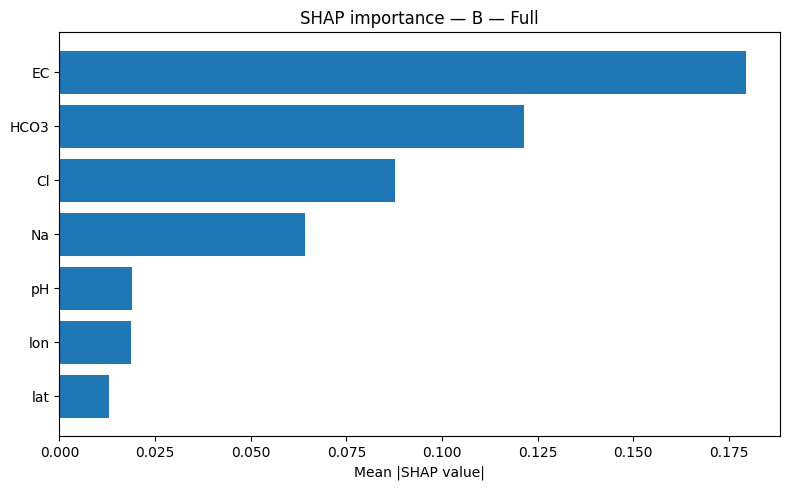

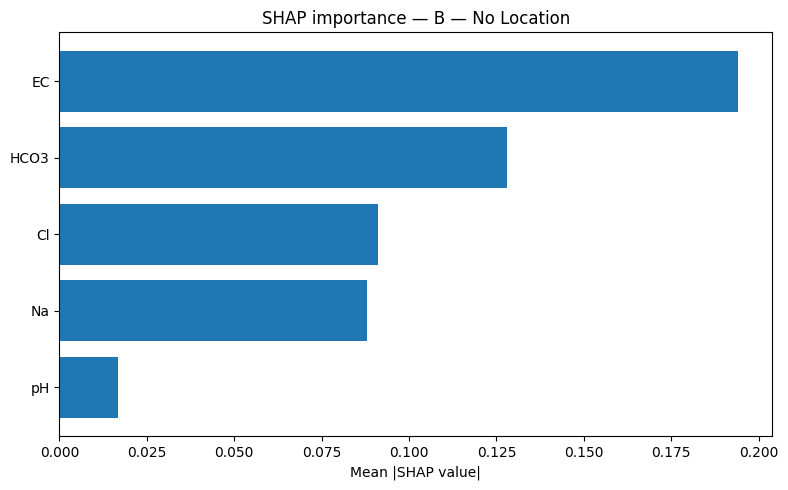



SHAP DIRECTIONALITY


,Configuration,Feature,Spearman_Feature_vs_SHAP,p_value
5,B — Full,Cl,0.93916,0.0
1,B — Full,EC,0.91453,0.0
4,B — Full,HCO3,0.91015,0.0
2,B — Full,lat,0.47757,0.0
3,B — Full,lon,-0.28382,0.0
0,B — Full,pH,-0.70625,0.0
6,B — Full,Na,-0.78366,0.0
10,B — No Location,Cl,0.91734,0.0
8,B — No Location,EC,0.91062,0.0
9,B — No Location,HCO3,0.91018,0.0




OBSERVED-DATA RESPONSE PROFILES


,Configuration,Feature,Quantile_Number,N,Feature_Median,Median_Model_Probability,Median_SHAP
0,B — Full,pH,1,159,7.13,0.75500,0.01623
1,B — Full,pH,2,163,7.45,0.79000,0.01820
2,B — Full,pH,3,154,7.64,0.74375,0.01666
3,B — Full,pH,4,165,7.80,0.75500,0.01754
4,B — Full,pH,5,193,7.95,0.74000,0.01107
...,...,...,...,...,...,...,...
115,B — No Location,Na,6,159,48.55,0.64000,0.03212
116,B — No Location,Na,7,151,60.00,0.74500,-0.02087
117,B — No Location,Na,8,163,74.00,0.60000,-0.06161
118,B — No Location,Na,9,152,103.12,0.89000,-0.03773




LOW → HIGH QUANTILE RESPONSE CONTRAST


,Configuration,Feature,Lowest_Quantile_Median_Value,Highest_Quantile_Median_Value,Lowest_Quantile_Probability,Highest_Quantile_Probability,Risk_Probability_Contrast,Lowest_Quantile_SHAP,Highest_Quantile_SHAP,SHAP_Contrast
0,B — Full,pH,7.13000,8.63000,0.75500,0.51875,-0.23625,0.01623,-0.02570,-0.04193
1,B — Full,EC,298.00000,1670.00000,0.01750,0.92000,0.90250,-0.29001,0.19153,0.48153
2,B — Full,lat,24.78750,26.61944,0.52250,0.55000,0.02750,-0.01653,0.00548,0.02201
3,B — Full,lon,84.13139,87.42847,0.73500,0.21625,-0.51875,0.00672,-0.06422,-0.07094
4,B — Full,HCO3,110.50000,520.87500,0.03250,0.92750,0.89500,-0.15220,0.13115,0.28335
5,B — Full,Cl,7.10000,231.00000,0.06250,0.90250,0.84000,-0.09961,0.16533,0.26494
6,B — Full,Na,10.00000,160.00000,0.05750,0.85750,0.80000,0.05993,-0.06761,-0.12754
7,B — No Location,pH,7.13000,8.63000,0.79750,0.49750,-0.30000,0.01045,-0.01682,-0.02727
8,B — No Location,EC,298.00000,1670.00000,0.00500,0.94000,0.93500,-0.32035,0.20930,0.52965
9,B — No Location,HCO3,110.50000,520.87500,0.01500,0.95000,0.93500,-0.16204,0.14200,0.30403


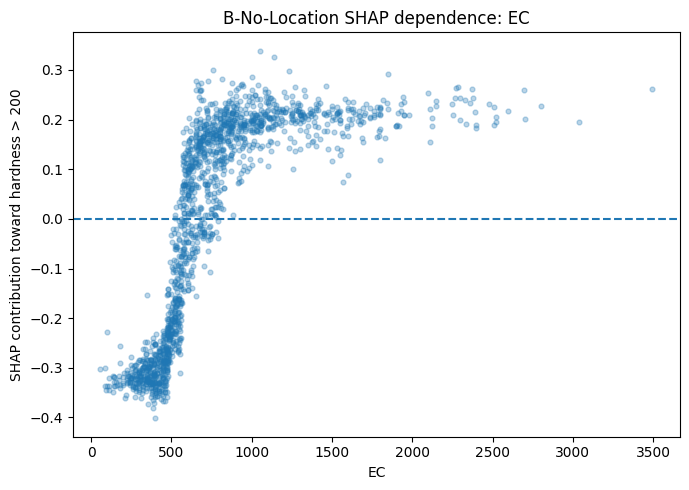

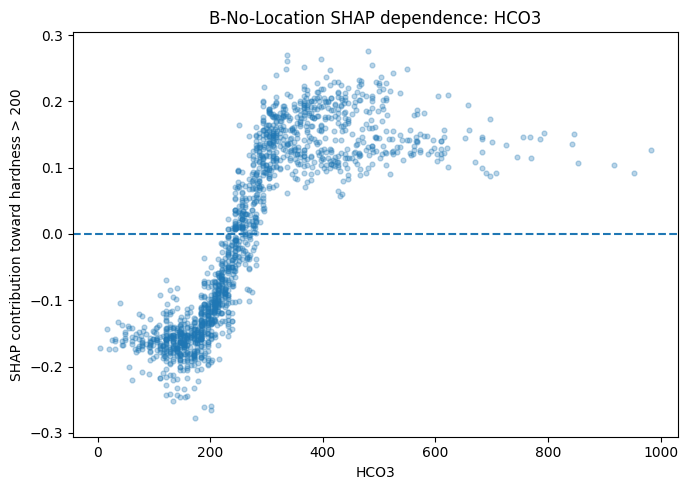

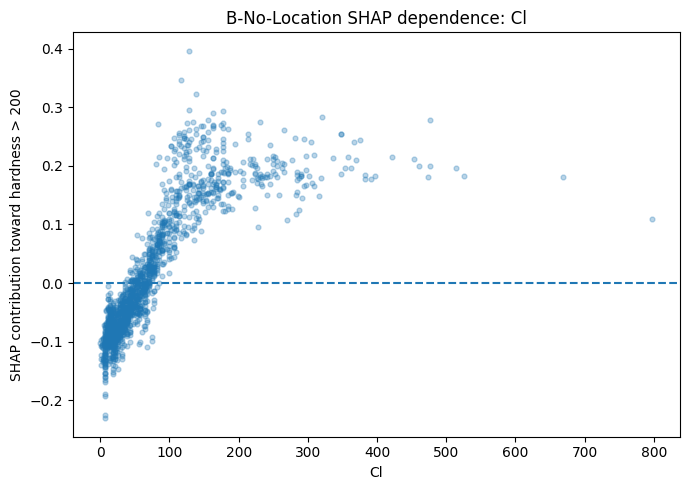

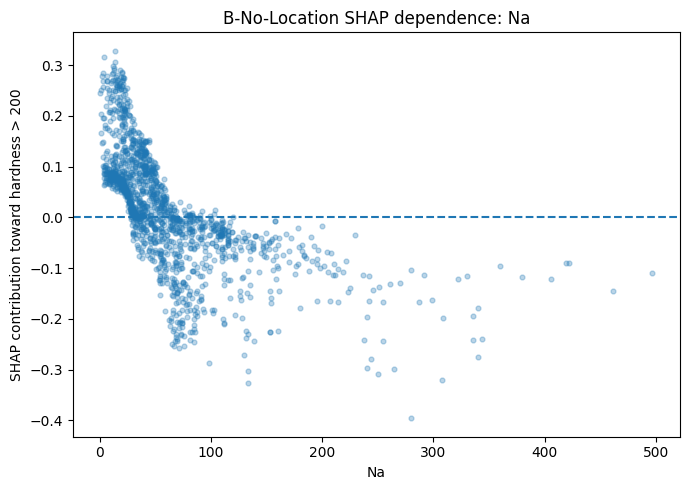

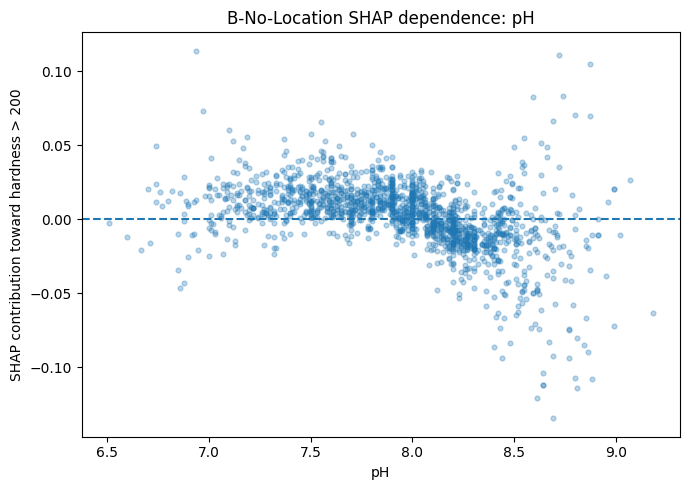



CHEMICAL BEHAVIOR AUDIT
EC: rho(feature, SHAP) = +0.9106
  → Direction is broadly consistent with increasing hardness risk.
HCO3: rho(feature, SHAP) = +0.9102
  → Direction is broadly consistent with increasing hardness risk.
Cl: rho(feature, SHAP) = +0.9173
  → Direction is broadly consistent with increasing hardness risk.
Na: rho(feature, SHAP) = -0.8000
  → WARNING: direction is not monotonically positive; investigate.
pH: rho(feature, SHAP) = -0.5504
  → No fixed monotonic direction pre-assumed for pH.


LOCATION SHAP CHECK


,Configuration,Feature,Mean_Abs_SHAP,Median_Abs_SHAP,Mean_SHAP,SD_SHAP,Min_SHAP,Max_SHAP,N
5,B — Full,lon,0.01881,0.01195,0.00086,0.03221,-0.23186,0.10819,1585
6,B — Full,lat,0.01288,0.00981,0.00148,0.01746,-0.08405,0.09119,1585




PERMUTATION vs SHAP RANKING


,Feature,Mean_AUC_Drop,Permutation_Rank,Mean_Abs_SHAP,SHAP_Rank
0,EC,0.22949,1,0.17938,1
1,HCO3,0.06648,3,0.12142,2
2,Cl,0.05511,4,0.08766,3
3,Na,0.07976,2,0.06427,4
4,pH,0.00124,7,0.01906,5
5,lon,0.00453,5,0.01881,6
6,lat,0.00361,6,0.01288,7




STEP 25 INTERPRETATION RULES
1. SHAP explains the fitted model; it does not establish causal effects.
2. Positive SHAP means the feature contribution pushes prediction toward hardness >200.
3. Negative SHAP means the feature contribution pushes prediction away from hardness >200.
4. Correlated chemistry means individual SHAP attributions should not be treated as independent chemical contributions.
5. The most credible conclusion comes from combining SHAP, permutation importance, correlations, and the ablation experiments.


Step 25 complete.
Saved:
- step25_shap_validation_values.csv
- step25_shap_summary.csv
- step25_shap_fold_summary.csv
- step25_shap_baselines.csv
- step25_shap_directionality.csv
- step25_observed_response_profiles.csv
- step25_quantile_response_contrasts.csv
- step25_location_shap.csv
- step25_permutation_vs_shap_ranking.csv

Final 520-row test set remained untouched.
seed = 42


In [41]:
# =========================================================
# STEP 25 — SHAP + CHEMICAL RESPONSE / BEHAVIOR AUDIT
#
# Purpose:
#   Explain the locked B-RF model using ONLY validation
#   observations from 5-fold station-grouped CV.
#
# Primary:
#   SHAP values on unseen validation folds.
#
# Secondary:
#   Observed-data response profiles using quantile bins.
#
# Configurations:
#   B — Full
#   B — No Location
#
# IMPORTANT:
#   Final 520-row test set is NOT used.
#
# seed = 42
# =========================================================

import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0. Install SHAP only if necessary
# ---------------------------------------------------------

try:
    import shap
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "shap"
        ]
    )
    import shap

print("SHAP version:", shap.__version__)

seed = 42
N_SPLITS = 5

print("seed =", seed)


# =========================================================
# 1. Verify train/test separation
# =========================================================

print("\n")
print("====================================================")
print("DATA AUDIT")
print("====================================================")

print(
    "Training rows:",
    len(train_df)
)

print(
    "Training stations:",
    train_df["station"].nunique()
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Test rows used for SHAP:",
    False
)

station_overlap = (
    set(train_df["station"])
    &
    set(test_df["station"])
)

print(
    "Train/test station overlap:",
    len(station_overlap)
)

if len(station_overlap) != 0:
    raise RuntimeError(
        "Station leakage detected."
    )


# =========================================================
# 2. Features
# =========================================================

features_B_full = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

features_B_no_location = [
    "pH",
    "EC",
    "HCO3",
    "Cl",
    "Na"
]

config_features = {
    "B — Full":
        features_B_full,

    "B — No Location":
        features_B_no_location
}


# =========================================================
# 3. Locked RF
# =========================================================

rf_template = clone(
    trained_models[
        "B"
    ][
        "Random Forest"
    ]
)

if rf_template.random_state != 42:
    raise RuntimeError(
        "Locked RF random_state != 42."
    )

print(
    "\nLocked model:",
    rf_template
)


# =========================================================
# 4. Helper: normalize SHAP output
#
# Current SHAP can return:
#   list[class] of arrays
# OR
#   ndarray[n_samples, n_features, n_classes]
#
# We want class 1 = hardness > 200.
# =========================================================

def extract_class1_shap(
    shap_output
):

    if isinstance(
        shap_output,
        list
    ):

        if len(shap_output) < 2:
            raise RuntimeError(
                "Unexpected SHAP list output."
            )

        return np.asarray(
            shap_output[1]
        )

    arr = np.asarray(
        shap_output
    )

    if arr.ndim == 3:

        if arr.shape[2] < 2:
            raise RuntimeError(
                "Unexpected 3D SHAP output."
            )

        return arr[:, :, 1]

    if arr.ndim == 2:

        return arr

    raise RuntimeError(
        f"Unexpected SHAP shape: {arr.shape}"
    )


# =========================================================
# 5. Grouped CV
# =========================================================

gkf = GroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=seed
)

groups = train_df[
    "station"
].to_numpy()


# =========================================================
# 6. Storage
# =========================================================

shap_rows = []
oof_behavior_rows = []
fold_baseline_rows = []


# =========================================================
# 7. LOOP THROUGH FOLDS
# =========================================================

for fold, (
    fold_train_idx,
    fold_valid_idx
) in enumerate(

    gkf.split(
        train_df,
        y_train,
        groups=groups
    ),

    start=1
):

    fold_train = (
        train_df
        .iloc[fold_train_idx]
        .reset_index(drop=True)
    )

    fold_valid = (
        train_df
        .iloc[fold_valid_idx]
        .reset_index(drop=True)
    )

    print("\n")
    print(
        "----------------------------------------------------"
    )
    print(
        f"FOLD {fold}"
    )
    print(
        "----------------------------------------------------"
    )

    print(
        "Training rows:",
        len(fold_train)
    )

    print(
        "Validation rows:",
        len(fold_valid)
    )

    print(
        "Training stations:",
        fold_train["station"].nunique()
    )

    print(
        "Validation stations:",
        fold_valid["station"].nunique()
    )

    overlap = (
        set(fold_train["station"])
        &
        set(fold_valid["station"])
    )

    print(
        "Station overlap:",
        len(overlap)
    )

    if len(overlap) != 0:
        raise RuntimeError(
            f"Station leakage in fold {fold}."
        )


    # =====================================================
    # Run both configurations
    # =====================================================

    for config_name, features in config_features.items():

        print(
            "\nExplaining:",
            config_name
        )

        model = clone(
            rf_template
        )

        model.fit(
            fold_train[features],
            fold_train["y"]
        )

        X_valid = (
            fold_valid[
                features
            ]
            .copy()
        )

        y_valid = (
            fold_valid[
                "y"
            ]
            .to_numpy()
        )


        # -------------------------------------------------
        # Baseline model output
        # -------------------------------------------------

        prob = model.predict_proba(
            X_valid
        )[:, 1]

        pred = model.predict(
            X_valid
        )

        auc = roc_auc_score(
            y_valid,
            prob
        )

        fold_baseline_rows.append({

            "Fold":
                fold,

            "Configuration":
                config_name,

            "Validation_Rows":
                len(X_valid),

            "Validation_Stations":
                fold_valid[
                    "station"
                ].nunique(),

            "Baseline_ROC_AUC":
                auc
        })


        # -------------------------------------------------
        # TreeExplainer
        #
        # We explain the model's tree output.
        # We intentionally avoid claiming that SHAP values
        # are causal effects.
        # -------------------------------------------------

        explainer = shap.TreeExplainer(
            model
        )

        try:

            shap_output = explainer.shap_values(
                X_valid,
                check_additivity=False
            )

        except TypeError:

            shap_output = explainer.shap_values(
                X_valid
            )


        shap_values = extract_class1_shap(
            shap_output
        )

        if shap_values.shape != (
            len(X_valid),
            len(features)
        ):

            raise RuntimeError(
                f"Unexpected SHAP shape "
                f"{shap_values.shape} for "
                f"{config_name}, fold {fold}."
            )


        # -------------------------------------------------
        # Store SHAP values
        # -------------------------------------------------

        for i, feature in enumerate(
            features
        ):

            values = shap_values[
                :,
                i
            ]

            raw_values = (
                X_valid[
                    feature
                ]
                .to_numpy()
            )

            for j in range(
                len(X_valid)
            ):

                shap_rows.append({

                    "Fold":
                        fold,

                    "Configuration":
                        config_name,

                    "Feature":
                        feature,

                    "Row_Index":
                        fold_valid_idx[j],

                    "Feature_Value":
                        raw_values[j],

                    "SHAP_Class1":
                        values[j],

                    "Absolute_SHAP":
                        abs(values[j]),

                    "Model_Probability":
                        prob[j],

                    "True_Label":
                        y_valid[j]
                })


# =========================================================
# 8. Convert SHAP results
# =========================================================

shap_df = pd.DataFrame(
    shap_rows
)

baseline_df = pd.DataFrame(
    fold_baseline_rows
)


# =========================================================
# 9. Aggregate SHAP importance
# =========================================================

shap_summary_df = (
    shap_df
    .groupby(
        [
            "Configuration",
            "Feature"
        ]
    )
    .agg(

        Mean_Abs_SHAP=(
            "Absolute_SHAP",
            "mean"
        ),

        Median_Abs_SHAP=(
            "Absolute_SHAP",
            "median"
        ),

        Mean_SHAP=(
            "SHAP_Class1",
            "mean"
        ),

        SD_SHAP=(
            "SHAP_Class1",
            "std"
        ),

        Min_SHAP=(
            "SHAP_Class1",
            "min"
        ),

        Max_SHAP=(
            "SHAP_Class1",
            "max"
        ),

        N=(
            "SHAP_Class1",
            "size"
        )
    )
    .reset_index()
    .sort_values(
        [
            "Configuration",
            "Mean_Abs_SHAP"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)


# =========================================================
# 10. Display SHAP importance
# =========================================================

print("\n")
print("====================================================")
print("CROSS-VALIDATED SHAP IMPORTANCE")
print("====================================================")

display(
    shap_summary_df.round(5)
)


# =========================================================
# 11. SHAP stability across folds
# =========================================================

shap_fold_summary_df = (
    shap_df
    .groupby(
        [
            "Configuration",
            "Fold",
            "Feature"
        ]
    )
    .agg(
        Mean_Abs_SHAP=(
            "Absolute_SHAP",
            "mean"
        ),

        Mean_SHAP=(
            "SHAP_Class1",
            "mean"
        )
    )
    .reset_index()
)

print("\n")
print("====================================================")
print("FOLD-LEVEL SHAP IMPORTANCE")
print("====================================================")

display(
    shap_fold_summary_df.round(5)
)


# =========================================================
# 12. Mean absolute SHAP plot
# =========================================================

for config in [
    "B — Full",
    "B — No Location"
]:

    temp = (
        shap_summary_df[
            shap_summary_df[
                "Configuration"
            ]
            ==
            config
        ]
        .sort_values(
            "Mean_Abs_SHAP"
        )
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.barh(
        temp["Feature"],
        temp["Mean_Abs_SHAP"]
    )

    plt.xlabel(
        "Mean |SHAP value|"
    )

    plt.title(
        f"SHAP importance — {config}"
    )

    plt.tight_layout()
    plt.show()


# =========================================================
# 13. SHAP directionality
#
# Spearman correlation:
#   feature value vs SHAP contribution toward class 1.
#
# Positive:
#   larger feature values generally push toward
#   hardness >200.
#
# Negative:
#   larger feature values generally push away from
#   hardness >200.
#
# This is a model-behavior indicator, NOT causality.
# =========================================================

from scipy.stats import spearmanr

direction_rows = []

for config in config_features:

    temp_config = shap_df[
        shap_df[
            "Configuration"
        ]
        ==
        config
    ]

    for feature in config_features[
        config
    ]:

        temp = temp_config[
            temp_config[
                "Feature"
            ]
            ==
            feature
        ]

        rho, p = spearmanr(
            temp["Feature_Value"],
            temp["SHAP_Class1"]
        )

        direction_rows.append({

            "Configuration":
                config,

            "Feature":
                feature,

            "Spearman_Feature_vs_SHAP":
                rho,

            "p_value":
                p
        })


direction_df = (
    pd.DataFrame(
        direction_rows
    )
    .sort_values(
        [
            "Configuration",
            "Spearman_Feature_vs_SHAP"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print("\n")
print("====================================================")
print("SHAP DIRECTIONALITY")
print("====================================================")

display(
    direction_df.round(5)
)


# =========================================================
# 14. QUANTILE RESPONSE PROFILES
#
# Uses REAL observed validation data.
#
# For each feature:
#   - split feature into deciles
#   - calculate median model probability
#   - calculate median SHAP contribution
#
# This avoids inventing unrealistic combinations of
# correlated chemistry variables.
# =========================================================

response_rows = []


for config in config_features:

    temp_config = shap_df[
        shap_df[
            "Configuration"
        ]
        ==
        config
    ].copy()

    for feature in config_features[
        config
    ]:

        temp = temp_config[
            temp_config[
                "Feature"
            ]
            ==
            feature
        ].copy()

        # -------------------------------------------------
        # Quantile bins
        # -------------------------------------------------

        try:

            temp[
                "Quantile_Bin"
            ] = pd.qcut(
                temp["Feature_Value"],
                q=10,
                duplicates="drop"
            )

        except ValueError:

            continue


        grouped = (
            temp
            .groupby(
                "Quantile_Bin",
                observed=True
            )
            .agg(

                N=(
                    "Feature_Value",
                    "size"
                ),

                Feature_Median=(
                    "Feature_Value",
                    "median"
                ),

                Median_Model_Probability=(
                    "Model_Probability",
                    "median"
                ),

                Mean_Model_Probability=(
                    "Model_Probability",
                    "mean"
                ),

                Median_SHAP=(
                    "SHAP_Class1",
                    "median"
                ),

                Mean_SHAP=(
                    "SHAP_Class1",
                    "mean"
                )
            )
            .reset_index()
        )

        grouped[
            "Configuration"
        ] = config

        grouped[
            "Feature"
        ] = feature

        grouped[
            "Quantile_Number"
        ] = np.arange(
            1,
            len(grouped) + 1
        )

        response_rows.append(
            grouped
        )


response_df = (
    pd.concat(
        response_rows,
        ignore_index=True
    )
)


print("\n")
print("====================================================")
print("OBSERVED-DATA RESPONSE PROFILES")
print("====================================================")

display(
    response_df[
        [
            "Configuration",
            "Feature",
            "Quantile_Number",
            "N",
            "Feature_Median",
            "Median_Model_Probability",
            "Median_SHAP"
        ]
    ]
    .round(5)
)


# =========================================================
# 15. Quantile risk contrast
#
# Difference between highest and lowest feature quantile.
# =========================================================

contrast_rows = []


for config in config_features:

    for feature in config_features[
        config
    ]:

        temp = response_df[
            (
                response_df[
                    "Configuration"
                ]
                ==
                config
            )
            &
            (
                response_df[
                    "Feature"
                ]
                ==
                feature
            )
        ].sort_values(
            "Quantile_Number"
        )

        if len(temp) < 2:
            continue

        low = temp.iloc[0]
        high = temp.iloc[-1]

        contrast_rows.append({

            "Configuration":
                config,

            "Feature":
                feature,

            "Lowest_Quantile_Median_Value":
                low["Feature_Median"],

            "Highest_Quantile_Median_Value":
                high["Feature_Median"],

            "Lowest_Quantile_Probability":
                low[
                    "Median_Model_Probability"
                ],

            "Highest_Quantile_Probability":
                high[
                    "Median_Model_Probability"
                ],

            "Risk_Probability_Contrast":
                (
                    high[
                        "Median_Model_Probability"
                    ]
                    -
                    low[
                        "Median_Model_Probability"
                    ]
                ),

            "Lowest_Quantile_SHAP":
                low["Median_SHAP"],

            "Highest_Quantile_SHAP":
                high["Median_SHAP"],

            "SHAP_Contrast":
                (
                    high["Median_SHAP"]
                    -
                    low["Median_SHAP"]
                )
        })


contrast_df = (
    pd.DataFrame(
        contrast_rows
    )
)


print("\n")
print("====================================================")
print("LOW → HIGH QUANTILE RESPONSE CONTRAST")
print("====================================================")

display(
    contrast_df.round(5)
)


# =========================================================
# 16. SHAP dependence-style plots for chemistry
#
# These use REAL validation observations.
# =========================================================

plot_features = [
    "EC",
    "HCO3",
    "Cl",
    "Na",
    "pH"
]


for feature in plot_features:

    temp = shap_df[
        (
            shap_df[
                "Configuration"
            ]
            ==
            "B — No Location"
        )
        &
        (
            shap_df[
                "Feature"
            ]
            ==
            feature
        )
    ]

    if len(temp) == 0:
        continue

    plt.figure(
        figsize=(7, 5)
    )

    plt.scatter(
        temp[
            "Feature_Value"
        ],
        temp[
            "SHAP_Class1"
        ],
        alpha=0.30,
        s=12
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        feature
    )

    plt.ylabel(
        "SHAP contribution toward hardness > 200"
    )

    plt.title(
        f"B-No-Location SHAP dependence: {feature}"
    )

    plt.tight_layout()
    plt.show()


# =========================================================
# 17. Automatic chemical-direction audit
# =========================================================

print("\n")
print("====================================================")
print("CHEMICAL BEHAVIOR AUDIT")
print("====================================================")

expected_positive = {
    "EC",
    "HCO3",
    "Cl",
    "Na"
}

for feature in [
    "EC",
    "HCO3",
    "Cl",
    "Na",
    "pH"
]:

    row = direction_df[
        (
            direction_df[
                "Configuration"
            ]
            ==
            "B — No Location"
        )
        &
        (
            direction_df[
                "Feature"
            ]
            ==
            feature
        )
    ]

    if len(row) == 0:
        continue

    rho = float(
        row[
            "Spearman_Feature_vs_SHAP"
        ].iloc[0]
    )

    print(
        f"{feature}: rho(feature, SHAP) = {rho:+.4f}"
    )

    if feature in expected_positive:

        if rho > 0:
            print(
                "  → Direction is broadly "
                "consistent with increasing hardness risk."
            )
        else:
            print(
                "  → WARNING: direction is not "
                "monotonically positive; investigate."
            )

    else:

        print(
            "  → No fixed monotonic direction "
            "pre-assumed for pH."
        )


# =========================================================
# 18. Location SHAP check
# =========================================================

print("\n")
print("====================================================")
print("LOCATION SHAP CHECK")
print("====================================================")

location_shap = shap_summary_df[
    (
        shap_summary_df[
            "Configuration"
        ]
        ==
        "B — Full"
    )
    &
    (
        shap_summary_df[
            "Feature"
        ].isin(
            [
                "lat",
                "lon"
            ]
        )
    )
]

display(
    location_shap.round(5)
)


# =========================================================
# 19. Compare SHAP ranking with permutation ranking
# =========================================================

perm_path = (
    "step24_feature_permutation_summary.csv"
)

try:

    perm_df = pd.read_csv(
        perm_path
    )

    perm_b_full = perm_df[
        perm_df[
            "Configuration"
        ]
        ==
        "B — Full"
    ][
        [
            "Feature",
            "Mean_AUC_Drop"
        ]
    ].copy()

    perm_b_full[
        "Permutation_Rank"
    ] = (
        perm_b_full[
            "Mean_AUC_Drop"
        ]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

    shap_b_full = shap_summary_df[
        shap_summary_df[
            "Configuration"
        ]
        ==
        "B — Full"
    ][
        [
            "Feature",
            "Mean_Abs_SHAP"
        ]
    ].copy()

    shap_b_full[
        "SHAP_Rank"
    ] = (
        shap_b_full[
            "Mean_Abs_SHAP"
        ]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

    ranking_comparison_df = (
        perm_b_full
        .merge(
            shap_b_full,
            on="Feature",
            how="outer"
        )
        .sort_values(
            "SHAP_Rank"
        )
        .reset_index(drop=True)
    )

    print("\n")
    print(
        "===================================================="
    )
    print(
        "PERMUTATION vs SHAP RANKING"
    )
    print(
        "===================================================="
    )

    display(
        ranking_comparison_df.round(5)
    )

except Exception as e:

    ranking_comparison_df = pd.DataFrame()

    print(
        "\nCould not load Step 24 permutation file:"
    )

    print(
        str(e)
    )


# =========================================================
# 20. Important interpretation statements
# =========================================================

print("\n")
print("====================================================")
print("STEP 25 INTERPRETATION RULES")
print("====================================================")

print(
    "1. SHAP explains the fitted model; "
    "it does not establish causal effects."
)

print(
    "2. Positive SHAP means the feature contribution "
    "pushes prediction toward hardness >200."
)

print(
    "3. Negative SHAP means the feature contribution "
    "pushes prediction away from hardness >200."
)

print(
    "4. Correlated chemistry means individual SHAP "
    "attributions should not be treated as independent "
    "chemical contributions."
)

print(
    "5. The most credible conclusion comes from combining "
    "SHAP, permutation importance, correlations, and the "
    "ablation experiments."
)


# =========================================================
# 21. SAVE
# =========================================================

shap_df.to_csv(
    "step25_shap_validation_values.csv",
    index=False
)

shap_summary_df.to_csv(
    "step25_shap_summary.csv",
    index=False
)

shap_fold_summary_df.to_csv(
    "step25_shap_fold_summary.csv",
    index=False
)

baseline_df.to_csv(
    "step25_shap_baselines.csv",
    index=False
)

direction_df.to_csv(
    "step25_shap_directionality.csv",
    index=False
)

response_df.to_csv(
    "step25_observed_response_profiles.csv",
    index=False
)

contrast_df.to_csv(
    "step25_quantile_response_contrasts.csv",
    index=False
)

location_shap.to_csv(
    "step25_location_shap.csv",
    index=False
)

if len(ranking_comparison_df) > 0:

    ranking_comparison_df.to_csv(
        "step25_permutation_vs_shap_ranking.csv",
        index=False
    )

print("\n")
print("Step 25 complete.")

print("Saved:")
print("- step25_shap_validation_values.csv")
print("- step25_shap_summary.csv")
print("- step25_shap_fold_summary.csv")
print("- step25_shap_baselines.csv")
print("- step25_shap_directionality.csv")
print("- step25_observed_response_profiles.csv")
print("- step25_quantile_response_contrasts.csv")
print("- step25_location_shap.csv")
print("- step25_permutation_vs_shap_ranking.csv")

print(
    "\nFinal 520-row test set remained untouched."
)

print(
    "seed =",
    seed
)

In [42]:
# =========================================================
# STEP 26 — CONDITIONAL CHEMISTRY / NA ANOMALY AUDIT
#
# Purpose:
#   Investigate the apparent contradiction:
#
#       Raw Na vs hardness: POSITIVE
#       Na vs SHAP contribution: NEGATIVE
#
#   Because EC is strongly correlated with Na and hardness,
#   this may be a conditional / confounding attribution effect.
#
# Primary dataset:
#   1,585 TRAINING observations only.
#
# Predictions:
#   Out-of-fold predictions from station-grouped CV.
#
# No final 520-row test data is used.
#
# seed = 42
# =========================================================

import numpy as np
import pandas as pd

from scipy.stats import spearmanr

seed = 42
N_SPLITS = 5

print("seed =", seed)


# =========================================================
# 1. VERIFY DATA
# =========================================================

print("\n")
print("====================================================")
print("DATA AUDIT")
print("====================================================")

print(
    "Training rows:",
    len(train_df)
)

print(
    "Training stations:",
    train_df["station"].nunique()
)

print(
    "Final test rows used:",
    False
)

if len(
    set(train_df["station"])
    &
    set(test_df["station"])
) != 0:

    raise RuntimeError(
        "Station overlap detected."
    )


# =========================================================
# 2. Recover OOF model probabilities
#
# Step 25 already generated SHAP validation records.
# We take exactly one feature row per observation to recover
# the OOF probability for B-No-Location.
# =========================================================

if "shap_df" not in globals():

    raise RuntimeError(
        "shap_df not found. Please rerun Step 25 first."
    )

oof_base = (
    shap_df[
        (
            shap_df["Configuration"]
            ==
            "B — No Location"
        )
        &
        (
            shap_df["Feature"]
            ==
            "EC"
        )
    ]
    [
        [
            "Row_Index",
            "Model_Probability",
            "True_Label"
        ]
    ]
    .drop_duplicates(
        subset=["Row_Index"]
    )
    .copy()
)

if len(oof_base) != len(train_df):

    raise RuntimeError(
        f"Expected {len(train_df)} unique OOF observations, "
        f"found {len(oof_base)}."
    )


# =========================================================
# 3. Merge original training chemistry
# =========================================================

analysis_df = train_df.copy()

analysis_df[
    "Row_Index"
] = np.arange(
    len(analysis_df)
)

analysis_df = (
    analysis_df
    .merge(
        oof_base,
        on="Row_Index",
        how="inner",
        suffixes=(
            "",
            "_OOF"
        )
    )
    .reset_index(drop=True)
)

if len(analysis_df) != len(train_df):

    raise RuntimeError(
        "OOF merge changed the training population."
    )


print(
    "\nOOF analysis rows:",
    len(analysis_df)
)

print(
    "OOF predictions complete:",
    analysis_df[
        "Model_Probability"
    ].notna().all()
)


# =========================================================
# 4. Partial Spearman helper
#
# Rank-transforming the variables before residualization
# gives a rank-based partial correlation.
# =========================================================

def partial_spearman(
    df,
    x,
    y,
    controls
):

    temp = (
        df[
            [x, y] + controls
        ]
        .dropna()
        .copy()
    )

    if len(temp) < 10:
        return np.nan, np.nan, len(temp)

    # Rank transformation
    ranked = temp.rank(
        method="average"
    )

    X_control = ranked[
        controls
    ].to_numpy()

    # Add intercept
    X_design = np.column_stack(
        [
            np.ones(
                len(X_control)
            ),
            X_control
        ]
    )

    x_rank = ranked[
        x
    ].to_numpy()

    y_rank = ranked[
        y
    ].to_numpy()

    beta_x = np.linalg.lstsq(
        X_design,
        x_rank,
        rcond=None
    )[0]

    beta_y = np.linalg.lstsq(
        X_design,
        y_rank,
        rcond=None
    )[0]

    x_resid = (
        x_rank
        -
        X_design.dot(beta_x)
    )

    y_resid = (
        y_rank
        -
        X_design.dot(beta_y)
    )

    rho, p = spearmanr(
        x_resid,
        y_resid
    )

    return rho, p, len(temp)


# =========================================================
# 5. PARTIAL SPEARMAN:
#    CHEMISTRY vs RAW HARDNESS, controlling EC
# =========================================================

chemistry_features = [
    "Na",
    "HCO3",
    "Cl",
    "pH"
]

partial_rows = []

for feature in chemistry_features:

    rho, p, n = partial_spearman(
        analysis_df,
        feature,
        "hardness",
        ["EC"]
    )

    partial_rows.append({

        "Feature":
            feature,

        "Control":
            "EC",

        "Partial_Spearman_with_Hardness":
            rho,

        "p_value":
            p,

        "N":
            n
    })


partial_hardness_df = (
    pd.DataFrame(
        partial_rows
    )
)


print("\n")
print("====================================================")
print("PARTIAL SPEARMAN — CHEMISTRY vs HARDNESS")
print("(CONTROLLING FOR EC)")
print("====================================================")

display(
    partial_hardness_df.round(5)
)


# =========================================================
# 6. PARTIAL SPEARMAN:
#    CHEMISTRY vs OOF MODEL PROBABILITY, controlling EC
# =========================================================

partial_model_rows = []

for feature in chemistry_features:

    rho, p, n = partial_spearman(
        analysis_df,
        feature,
        "Model_Probability",
        ["EC"]
    )

    partial_model_rows.append({

        "Feature":
            feature,

        "Control":
            "EC",

        "Partial_Spearman_with_OOF_Probability":
            rho,

        "p_value":
            p,

        "N":
            n
    })


partial_model_df = (
    pd.DataFrame(
        partial_model_rows
    )
)


print("\n")
print("====================================================")
print("PARTIAL SPEARMAN — CHEMISTRY vs MODEL RISK")
print("(CONTROLLING FOR EC)")
print("====================================================")

display(
    partial_model_df.round(5)
)


# =========================================================
# 7. EC TERTILES
#
# Conditioning on broad EC regimes lets us see whether
# Na keeps the same direction after EC is approximately fixed.
# =========================================================

analysis_df[
    "EC_Regime"
] = pd.qcut(
    analysis_df[
        "EC"
    ],
    q=3,
    labels=[
        "Low EC",
        "Medium EC",
        "High EC"
    ],
    duplicates="drop"
)


# =========================================================
# 8. WITHIN-EC SPEARMAN RESULTS
# =========================================================

conditional_rows = []

for regime in analysis_df[
    "EC_Regime"
].dropna().unique():

    subset = analysis_df[
        analysis_df[
            "EC_Regime"
        ]
        ==
        regime
    ].copy()

    for feature in chemistry_features:

        valid = subset[
            [
                feature,
                "hardness",
                "Model_Probability"
            ]
        ].dropna()

        if len(valid) < 10:
            continue

        rho_h, p_h = spearmanr(
            valid[
                feature
            ],
            valid[
                "hardness"
            ]
        )

        rho_model, p_model = spearmanr(
            valid[
                feature
            ],
            valid[
                "Model_Probability"
            ]
        )

        conditional_rows.append({

            "EC_Regime":
                regime,

            "Feature":
                feature,

            "N":
                len(valid),

            "Feature_vs_Hardness_rho":
                rho_h,

            "Feature_vs_Hardness_p":
                p_h,

            "Feature_vs_OOF_Probability_rho":
                rho_model,

            "Feature_vs_OOF_Probability_p":
                p_model
        })


conditional_spearman_df = (
    pd.DataFrame(
        conditional_rows
    )
)


print("\n")
print("====================================================")
print("WITHIN-EC CONDITIONAL ASSOCIATIONS")
print("====================================================")

display(
    conditional_spearman_df.round(5)
)


# =========================================================
# 9. NA TERTILES INSIDE EACH EC REGIME
#
# This is the most direct test of the Na anomaly.
#
# For each EC regime:
#   split Na into quartiles
#   calculate:
#       N
#       median Na
#       median hardness
#       hardness >200 rate
#       median OOF predicted probability
# =========================================================

na_response_rows = []

for regime in analysis_df[
    "EC_Regime"
].dropna().unique():

    subset = analysis_df[
        analysis_df[
            "EC_Regime"
        ]
        ==
        regime
    ].copy()

    try:

        subset[
            "Na_Quartile"
        ] = pd.qcut(
            subset[
                "Na"
            ],
            q=4,
            labels=[
                "Q1",
                "Q2",
                "Q3",
                "Q4"
            ],
            duplicates="drop"
        )

    except ValueError:

        continue


    grouped = (
        subset
        .groupby(
            "Na_Quartile",
            observed=True
        )
        .agg(

            N=(
                "Na",
                "size"
            ),

            Median_Na=(
                "Na",
                "median"
            ),

            Median_Hardness=(
                "hardness",
                "median"
            ),

            Positive_Rate=(
                "y",
                "mean"
            ),

            Median_OOF_Probability=(
                "Model_Probability",
                "median"
            )
        )
        .reset_index()
    )

    grouped[
        "EC_Regime"
    ] = regime

    na_response_rows.append(
        grouped
    )


na_response_df = (
    pd.concat(
        na_response_rows,
        ignore_index=True
    )
)


print("\n")
print("====================================================")
print("Na RESPONSE WITHIN EC REGIMES")
print("====================================================")

display(
    na_response_df[
        [
            "EC_Regime",
            "Na_Quartile",
            "N",
            "Median_Na",
            "Median_Hardness",
            "Positive_Rate",
            "Median_OOF_Probability"
        ]
    ].round(5)
)


# =========================================================
# 10. HCO3 / Cl RESPONSE WITHIN EC REGIMES
#
# Same analysis for the other correlated chemistry variables.
# =========================================================

for feature in [
    "HCO3",
    "Cl"
]:

    response_rows = []

    for regime in analysis_df[
        "EC_Regime"
    ].dropna().unique():

        subset = analysis_df[
            analysis_df[
                "EC_Regime"
            ]
            ==
            regime
        ].copy()

        try:

            subset[
                "Feature_Quartile"
            ] = pd.qcut(
                subset[
                    feature
                ],
                q=4,
                labels=[
                    "Q1",
                    "Q2",
                    "Q3",
                    "Q4"
                ],
                duplicates="drop"
            )

        except ValueError:

            continue


        grouped = (
            subset
            .groupby(
                "Feature_Quartile",
                observed=True
            )
            .agg(

                N=(
                    feature,
                    "size"
                ),

                Median_Feature=(
                    feature,
                    "median"
                ),

                Median_Hardness=(
                    "hardness",
                    "median"
                ),

                Positive_Rate=(
                    "y",
                    "mean"
                ),

                Median_OOF_Probability=(
                    "Model_Probability",
                    "median"
                )
            )
            .reset_index()
        )

        grouped[
            "EC_Regime"
        ] = regime

        grouped[
            "Feature"
        ] = feature

        response_rows.append(
            grouped
        )


    feature_response_df = (
        pd.concat(
            response_rows,
            ignore_index=True
        )
    )

    print("\n")
    print("====================================================")
    print(
        f"{feature} RESPONSE WITHIN EC REGIMES"
    )
    print("====================================================")

    display(
        feature_response_df.round(5)
    )


# =========================================================
# 11. Direct comparison:
#    NA RAW vs NA MODEL DIRECTION
# =========================================================

raw_na_rho, raw_na_p = spearmanr(
    analysis_df["Na"],
    analysis_df["hardness"]
)

model_na_rho, model_na_p = spearmanr(
    analysis_df["Na"],
    analysis_df["Model_Probability"]
)

partial_na_hardness = float(
    partial_hardness_df.loc[
        partial_hardness_df["Feature"]
        ==
        "Na",
        "Partial_Spearman_with_Hardness"
    ].iloc[0]
)

partial_na_model = float(
    partial_model_df.loc[
        partial_model_df["Feature"]
        ==
        "Na",
        "Partial_Spearman_with_OOF_Probability"
    ].iloc[0]
)

print("\n")
print("====================================================")
print("Na DIRECTION RECONCILIATION")
print("====================================================")

print(
    f"Raw Na vs hardness: "
    f"rho={raw_na_rho:+.4f}, "
    f"p={raw_na_p:.6g}"
)

print(
    f"Raw Na vs OOF model probability: "
    f"rho={model_na_rho:+.4f}, "
    f"p={model_na_p:.6g}"
)

print(
    f"Partial Na vs hardness controlling EC: "
    f"rho={partial_na_hardness:+.4f}"
)

print(
    f"Partial Na vs OOF probability controlling EC: "
    f"rho={partial_na_model:+.4f}"
)


# =========================================================
# 12. AUTOMATIC INTERPRETATION
# =========================================================

print("\n")
print("====================================================")
print("STEP 26 INTERPRETATION FLAGS")
print("====================================================")

if (
    raw_na_rho > 0
    and
    partial_na_hardness > 0
    and
    partial_na_model > 0
):

    print(
        "Na result is broadly positive even after "
        "controlling for EC."
    )

    print(
        "The negative SHAP direction would therefore "
        "require a deeper interaction/attribution audit."
    )

elif (
    raw_na_rho > 0
    and
    partial_na_hardness > 0
    and
    partial_na_model <= 0
):

    print(
        "Na is positively associated with observed hardness "
        "after controlling EC, but the RF uses Na differently."
    )

    print(
        "Likely explanation: correlated-feature interaction "
        "and conditional redistribution of predictive information."
    )

elif (
    raw_na_rho > 0
    and
    partial_na_hardness <= 0
):

    print(
        "Na's positive marginal correlation is largely explained "
        "by its relationship with EC/other chemistry."
    )

else:

    print(
        "Na direction does not show a simple stable pattern."
    )


print("\n")
print(
    "IMPORTANT:"
)

print(
    "This is an association/model-behavior audit, "
    "not a causal analysis."
)

print(
    "The purpose is to distinguish a genuine chemical "
    "relationship from correlated-feature attribution effects."
)


# =========================================================
# 13. SAVE
# =========================================================

analysis_df.to_csv(
    "step26_conditional_chemistry_oof_data.csv",
    index=False
)

partial_hardness_df.to_csv(
    "step26_partial_spearman_hardness.csv",
    index=False
)

partial_model_df.to_csv(
    "step26_partial_spearman_model.csv",
    index=False
)

conditional_spearman_df.to_csv(
    "step26_within_ec_conditional_spearman.csv",
    index=False
)

na_response_df.to_csv(
    "step26_na_within_ec_response.csv",
    index=False
)

print("\n")
print("Step 26 complete.")

print("Saved:")
print("- step26_conditional_chemistry_oof_data.csv")
print("- step26_partial_spearman_hardness.csv")
print("- step26_partial_spearman_model.csv")
print("- step26_within_ec_conditional_spearman.csv")
print("- step26_na_within_ec_response.csv")

print(
    "\nFinal 520-row test set remained untouched."
)

print(
    "seed =",
    seed
)

seed = 42


DATA AUDIT
Training rows: 1585
Training stations: 551
Final test rows used: False

OOF analysis rows: 1585
OOF predictions complete: True


PARTIAL SPEARMAN — CHEMISTRY vs HARDNESS
(CONTROLLING FOR EC)


,Feature,Control,Partial_Spearman_with_Hardness,p_value,N
0,Na,EC,-0.61988,0.00000,1585
1,HCO3,EC,0.27641,0.00000,1585
2,Cl,EC,-0.07065,0.00489,1585
3,pH,EC,-0.13286,0.00000,1585




PARTIAL SPEARMAN — CHEMISTRY vs MODEL RISK
(CONTROLLING FOR EC)


,Feature,Control,Partial_Spearman_with_OOF_Probability,p_value,N
0,Na,EC,-0.57836,0.0,1585
1,HCO3,EC,0.36674,0.0,1585
2,Cl,EC,-0.15013,0.0,1585
3,pH,EC,-0.23956,0.0,1585




WITHIN-EC CONDITIONAL ASSOCIATIONS


...



HCO3 RESPONSE WITHIN EC REGIMES


,Feature_Quartile,N,Median_Feature,Median_Hardness,Positive_Rate,Median_OOF_Probability,EC_Regime,Feature
0,Q1,134,104.775,101.5,0.02985,0.00875,Low EC,HCO3
1,Q2,131,153.000,125.0,0.02290,0.00750,Low EC,HCO3
2,Q3,132,195.200,160.0,0.12121,0.03250,Low EC,HCO3
3,Q4,132,243.500,170.0,0.21970,0.13625,Low EC,HCO3
4,Q1,134,171.650,181.0,0.37313,0.37375,Medium EC,HCO3
5,Q2,130,232.000,210.0,0.60000,0.66750,Medium EC,HCO3
6,Q3,137,292.000,222.0,0.65693,0.84250,Medium EC,HCO3
7,Q4,126,350.550,249.0,0.74603,0.85625,Medium EC,HCO3
8,Q1,134,223.000,280.0,0.75373,0.80500,High EC,HCO3
9,Q2,133,338.250,315.0,0.91729,0.94500,High EC,HCO3




Cl RESPONSE WITHIN EC REGIMES


,Feature_Quartile,N,Median_Feature,Median_Hardness,Positive_Rate,Median_OOF_Probability,EC_Regime,Feature
0,Q1,151,10.600,120.0,0.06623,0.01750,Low EC,Cl
1,Q2,119,17.700,145.0,0.10084,0.01250,Low EC,Cl
2,Q3,129,28.000,140.0,0.08527,0.01750,Low EC,Cl
3,Q4,130,44.658,156.0,0.14615,0.07000,Low EC,Cl
4,Q1,139,14.200,212.0,0.56115,0.64000,Medium EC,Cl
5,Q2,125,35.500,223.0,0.66400,0.80250,Medium EC,Cl
6,Q3,135,57.000,215.0,0.60000,0.65250,Medium EC,Cl
7,Q4,128,88.600,210.0,0.54688,0.61625,Medium EC,Cl
8,Q1,136,51.500,285.0,0.81618,0.89750,High EC,Cl
9,Q2,129,99.400,300.0,0.85271,0.88250,High EC,Cl




Na DIRECTION RECONCILIATION
Raw Na vs hardness: rho=+0.3780, p=5.24053e-55
Raw Na vs OOF model probability: rho=+0.4231, p=7.71642e-70
Partial Na vs hardness controlling EC: rho=-0.6199
Partial Na vs OOF probability controlling EC: rho=-0.5784


STEP 26 INTERPRETATION FLAGS
Na's positive marginal correlation is largely explained by its relationship with EC/other chemistry.


IMPORTANT:
This is an association/model-behavior audit, not a causal analysis.
The purpose is to distinguish a genuine chemical relationship from correlated-feature attribution effects.


Step 26 complete.
Saved:
- step26_conditional_chemistry_oof_data.csv
- step26_partial_spearman_hardness.csv
- step26_partial_spearman_model.csv
- step26_within_ec_conditional_spearman.csv
- step26_na_within_ec_response.csv

Final 520-row test set remained untouched.
seed = 42


seed = 42


DATA AUDIT
Training rows: 1585
Training stations: 551
Final test rows: 520
Final test used for calibration: False
Train/test station overlap: 0

Locked base model:
RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)


OUTER FOLD 1
Outer training rows: 1249
Outer validation rows: 336
Outer training stations: 440
Outer validation stations: 111
Station overlap: 0


OUTER FOLD 2
Outer training rows: 1266
Outer validation rows: 319
Outer training stations: 441
Outer validation stations: 110
Station overlap: 0


OUTER FOLD 3
Outer training rows: 1258
Outer validation rows: 327
Outer training stations: 441
Outer validation stations: 110
Station overlap: 0


OUTER FOLD 4
Outer training rows: 1297
Outer validation rows: 288
Outer training stations: 441
Outer validation stations: 110
Station overlap: 0


OUTER FOLD 5
Outer training rows: 1270
Outer validation rows: 315
Outer training stations: 441
Outer validation stati

,Method,Mean_ROC_AUC,SD_ROC_AUC,Mean_Brier,SD_Brier,Mean_Log_Loss,SD_Log_Loss,Mean_ECE,SD_ECE
0,Isotonic,0.95027,0.01563,0.08648,0.01443,0.30229,0.08237,0.03711,0.01209
1,Raw_RF,0.95063,0.01580,0.08895,0.01283,0.29546,0.03409,0.06026,0.01497
2,Sigmoid,0.95063,0.01580,0.08655,0.01546,0.28811,0.04433,0.04088,0.01369




FOLD-LEVEL CALIBRATION RESULTS


,Outer_Fold,Method,ROC_AUC,Brier,Log_Loss,ECE
0,1,Raw_RF,0.95282,0.09351,0.30149,0.06279
1,1,Sigmoid,0.95282,0.09128,0.29510,0.05600
2,1,Isotonic,0.95203,0.09019,0.28478,0.04583
3,2,Raw_RF,0.94183,0.09488,0.31253,0.04031
4,2,Sigmoid,0.94183,0.09248,0.30998,0.02766
5,2,Isotonic,0.94021,0.09334,0.30472,0.02114
6,3,Raw_RF,0.96392,0.08062,0.27579,0.07992
7,3,Sigmoid,0.96392,0.07511,0.25355,0.03401
8,3,Isotonic,0.96394,0.07482,0.24872,0.03604
9,4,Raw_RF,0.96625,0.07157,0.24943,0.06633




POOLED OUTER-OOF CALIBRATION


,Method,ROC_AUC,Brier,Log_Loss,ECE
0,Raw_RF,0.95001,0.08926,0.29622,0.04766
1,Sigmoid,0.94968,0.08687,0.28889,0.01840
2,Isotonic,0.94949,0.08675,0.30284,0.00808




RELIABILITY DATA


,Method,Bin,N,Mean_Predicted,Observed_Positive_Rate
0,Raw_RF,1,159,0.00858,0.00000
1,Raw_RF,2,159,0.03629,0.00629
2,Raw_RF,3,159,0.11635,0.08176
3,Raw_RF,4,159,0.27807,0.16981
4,Raw_RF,5,159,0.49884,0.44654
5,Raw_RF,6,158,0.67927,0.72785
6,Raw_RF,7,158,0.80195,0.88608
7,Raw_RF,8,158,0.87763,0.94937
8,Raw_RF,9,158,0.93158,0.94937
9,Raw_RF,10,158,0.97302,0.99367


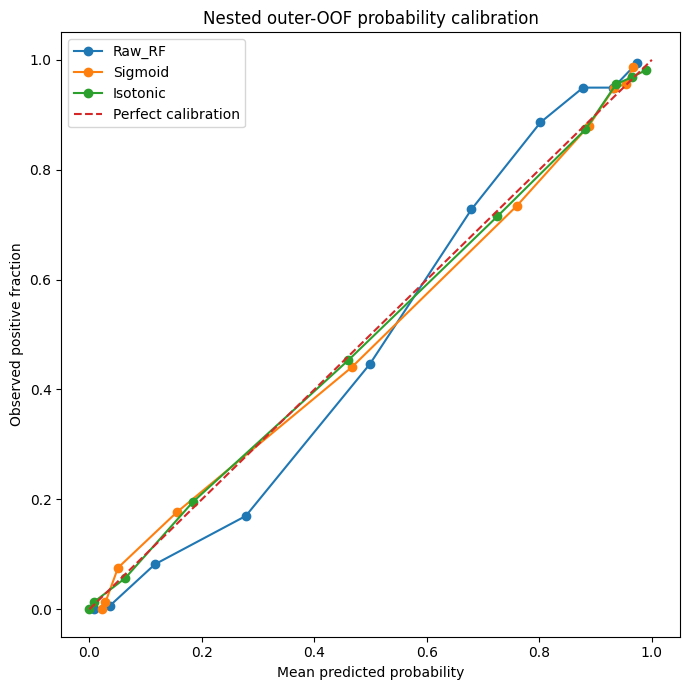



TRAINING-ONLY OPERATING-POINT AUDIT


,Threshold,Predicted_Positive_Rate,Accuracy,Precision,Recall_Sensitivity,Specificity,F1,Balanced_Accuracy,TN,FP,FN,TP
0,0.200,0.6852,0.8132,0.7431,0.9794,0.6334,0.8450,0.8064,482,279,17,807
1,0.250,0.6599,0.8347,0.7686,0.9757,0.6820,0.8599,0.8289,519,242,20,804
2,0.300,0.6397,0.8486,0.7880,0.9697,0.7175,0.8694,0.8436,546,215,25,799
3,0.350,0.6139,0.8656,0.8140,0.9612,0.7622,0.8815,0.8617,580,181,32,792
4,0.400,0.5912,0.8707,0.8303,0.9442,0.7911,0.8836,0.8676,602,159,46,778
5,0.450,0.5691,0.8814,0.8525,0.9333,0.8252,0.8911,0.8792,628,133,55,769
6,0.455,0.5685,0.8820,0.8535,0.9333,0.8265,0.8916,0.8799,629,132,55,769
7,0.500,0.5514,0.8801,0.8627,0.9150,0.8423,0.8881,0.8787,641,120,70,754
8,0.550,0.5287,0.8789,0.8771,0.8920,0.8647,0.8845,0.8783,658,103,89,735
9,0.600,0.4940,0.8795,0.9042,0.8592,0.9014,0.8811,0.8803,686,75,116,708




0.455 vs 0.500 — OUTER OOF

Threshold: 0.455
Accuracy: 0.8820
Precision: 0.8535
Recall: 0.9333
Specificity: 0.8265
F1: 0.8916

Threshold: 0.500
Accuracy: 0.8801
Precision: 0.8627
Recall: 0.9150
Specificity: 0.8423
F1: 0.8881


STEP 27 CALIBRATION VERDICT
Lowest mean ECE: Isotonic
Lowest mean log-loss: Sigmoid

ECE improvement vs raw RF: +0.02315
Brier improvement vs raw RF: +0.00247
Log-loss improvement vs raw RF: -0.00683

Calibration provides partial improvement.

The final 520-row test set remains untouched.


Step 27 complete.
Saved:
- step27_nested_calibration_predictions.csv
- step27_nested_calibration_fold_metrics.csv
- step27_calibration_summary.csv
- step27_pooled_calibration.csv
- step27_reliability_data.csv
- step27_operating_points.csv

Final 520-row test set remained untouched.
seed = 42


In [45]:
# =========================================================
# STEP 27 — NESTED PROBABILITY CALIBRATION
#            + OPERATING-POINT AUDIT
#
# LOCKED MODEL:
#   B — Random Forest
#
# OUTER CV:
#   5-fold station-grouped CV
#
# INNER CV:
#   3-fold station-grouped CV
#   used ONLY to fit calibration functions
#
# METHODS:
#   Raw RF
#   Sigmoid calibration
#   Isotonic calibration
#
# FINAL 520-row TEST SET:
#   NOT USED
#
# seed = 42
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

seed = 42

N_OUTER = 5
N_INNER = 3
N_BINS = 10

print("seed =", seed)


# =========================================================
# 1. DATA AUDIT
# =========================================================

print("\n")
print("====================================================")
print("DATA AUDIT")
print("====================================================")

print(
    "Training rows:",
    len(train_df)
)

print(
    "Training stations:",
    train_df["station"].nunique()
)

print(
    "Final test rows:",
    len(test_df)
)

print(
    "Final test used for calibration:",
    False
)

train_test_overlap = (
    set(train_df["station"])
    &
    set(test_df["station"])
)

print(
    "Train/test station overlap:",
    len(train_test_overlap)
)

if len(train_test_overlap) != 0:
    raise RuntimeError(
        "Train/test station overlap detected."
    )


# =========================================================
# 2. FINAL LOCKED FEATURES
# =========================================================

FINAL_FEATURES = [
    "pH",
    "EC",
    "lat",
    "lon",
    "HCO3",
    "Cl",
    "Na"
]

X = train_df[
    FINAL_FEATURES
].copy()

y = train_df[
    "y"
].to_numpy()

groups = (
    train_df["station"]
    .astype(str)
    .to_numpy()
)


# =========================================================
# 3. LOCKED RANDOM FOREST
# =========================================================

rf_template = clone(
    trained_models["B"]["Random Forest"]
)

if rf_template.random_state != 42:
    raise RuntimeError(
        "Locked RF random_state is not 42."
    )

print(
    "\nLocked base model:"
)

print(
    rf_template
)


# =========================================================
# 4. ECE FUNCTION
# =========================================================

def expected_calibration_error(
    y_true,
    probability,
    n_bins=10
):

    y_true = np.asarray(y_true)
    probability = np.asarray(probability)

    order = np.argsort(
        probability
    )

    sorted_probability = (
        probability[order]
    )

    sorted_y = (
        y_true[order]
    )

    bins = np.array_split(
        np.arange(
            len(sorted_y)
        ),
        n_bins
    )

    ece = 0.0

    rows = []

    for bin_id, idx in enumerate(
        bins,
        start=1
    ):

        if len(idx) == 0:
            continue

        mean_probability = np.mean(
            sorted_probability[idx]
        )

        observed_rate = np.mean(
            sorted_y[idx]
        )

        absolute_gap = abs(
            mean_probability
            -
            observed_rate
        )

        weight = (
            len(idx)
            /
            len(sorted_y)
        )

        ece += (
            weight
            *
            absolute_gap
        )

        rows.append({

            "Bin":
                bin_id,

            "N":
                len(idx),

            "Mean_Predicted":
                mean_probability,

            "Observed_Positive_Rate":
                observed_rate,

            "Absolute_Gap":
                absolute_gap
        })

    return ece, pd.DataFrame(rows)


# =========================================================
# 5. CALIBRATOR HELPERS
# =========================================================

def fit_sigmoid_calibrator(
    probability,
    y_true
):

    probability = np.clip(
        probability,
        1e-6,
        1 - 1e-6
    )

    calibrator = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        random_state=seed
    )

    calibrator.fit(
        probability.reshape(-1, 1),
        y_true
    )

    return calibrator


def apply_sigmoid_calibrator(
    calibrator,
    probability
):

    probability = np.clip(
        probability,
        1e-6,
        1 - 1e-6
    )

    return calibrator.predict_proba(
        probability.reshape(-1, 1)
    )[:, 1]


def fit_isotonic_calibrator(
    probability,
    y_true
):

    calibrator = IsotonicRegression(
        y_min=0.0,
        y_max=1.0,
        out_of_bounds="clip"
    )

    calibrator.fit(
        probability,
        y_true
    )

    return calibrator


def apply_isotonic_calibrator(
    calibrator,
    probability
):

    return np.asarray(
        calibrator.predict(
            probability
        )
    )


# =========================================================
# 6. OUTER GROUPED CV
# =========================================================

outer_gkf = GroupKFold(
    n_splits=N_OUTER,
    shuffle=True,
    random_state=seed
)

prediction_rows = []
metric_rows = []


for outer_fold, (
    outer_train_idx,
    outer_valid_idx
) in enumerate(

    outer_gkf.split(
        X,
        y,
        groups=groups
    ),

    start=1
):

    X_outer_train = (
        X
        .iloc[
            outer_train_idx
        ]
        .reset_index(drop=True)
    )

    y_outer_train = (
        y[
            outer_train_idx
        ]
    )

    groups_outer_train = (
        groups[
            outer_train_idx
        ]
    )

    X_outer_valid = (
        X
        .iloc[
            outer_valid_idx
        ]
        .reset_index(drop=True)
    )

    y_outer_valid = (
        y[
            outer_valid_idx
        ]
    )

    groups_outer_valid = (
        groups[
            outer_valid_idx
        ]
    )


    print("\n")
    print(
        "===================================================="
    )
    print(
        f"OUTER FOLD {outer_fold}"
    )
    print(
        "===================================================="
    )

    print(
        "Outer training rows:",
        len(X_outer_train)
    )

    print(
        "Outer validation rows:",
        len(X_outer_valid)
    )

    print(
        "Outer training stations:",
        len(
            np.unique(
                groups_outer_train
            )
        )
    )

    print(
        "Outer validation stations:",
        len(
            np.unique(
                groups_outer_valid
            )
        )
    )

    outer_overlap = (
        set(groups_outer_train)
        &
        set(groups_outer_valid)
    )

    print(
        "Station overlap:",
        len(outer_overlap)
    )

    if len(outer_overlap) != 0:
        raise RuntimeError(
            f"Outer station leakage in fold "
            f"{outer_fold}."
        )


    # =====================================================
    # 6A. INNER GROUPED CV
    #     Generate OOF probabilities for calibration.
    # =====================================================

    inner_gkf = GroupKFold(
        n_splits=N_INNER,
        shuffle=True,
        random_state=seed
    )

    inner_oof_prob = np.full(
        len(X_outer_train),
        np.nan,
        dtype=float
    )

    inner_seen = np.zeros(
        len(X_outer_train),
        dtype=bool
    )

    for inner_fold, (
        inner_train_idx,
        inner_valid_idx
    ) in enumerate(

        inner_gkf.split(
            X_outer_train,
            y_outer_train,
            groups=groups_outer_train
        ),

        start=1
    ):

        inner_train_groups = (
            groups_outer_train[
                inner_train_idx
            ]
        )

        inner_valid_groups = (
            groups_outer_train[
                inner_valid_idx
            ]
        )

        inner_overlap = (
            set(inner_train_groups)
            &
            set(inner_valid_groups)
        )

        if len(inner_overlap) != 0:
            raise RuntimeError(
                f"Inner station leakage in "
                f"outer fold {outer_fold}, "
                f"inner fold {inner_fold}."
            )

        inner_model = clone(
            rf_template
        )

        inner_model.fit(
            X_outer_train.iloc[
                inner_train_idx
            ],
            y_outer_train[
                inner_train_idx
            ]
        )

        inner_prob = (
            inner_model
            .predict_proba(
                X_outer_train.iloc[
                    inner_valid_idx
                ]
            )[:, 1]
        )

        inner_oof_prob[
            inner_valid_idx
        ] = inner_prob

        inner_seen[
            inner_valid_idx
        ] = True


    if not inner_seen.all():
        raise RuntimeError(
            f"Outer fold {outer_fold}: "
            "not all outer-training observations "
            "received an inner OOF probability."
        )


    # =====================================================
    # 6B. FIT CALIBRATORS USING INNER OOF ONLY
    # =====================================================

    sigmoid_calibrator = (
        fit_sigmoid_calibrator(
            inner_oof_prob,
            y_outer_train
        )
    )

    isotonic_calibrator = (
        fit_isotonic_calibrator(
            inner_oof_prob,
            y_outer_train
        )
    )


    # =====================================================
    # 6C. FIT RF ON ENTIRE OUTER TRAINING SET
    # =====================================================

    outer_model = clone(
        rf_template
    )

    outer_model.fit(
        X_outer_train,
        y_outer_train
    )


    # =====================================================
    # 6D. RAW OUTER VALIDATION PROBABILITY
    # =====================================================

    raw_prob = (
        outer_model
        .predict_proba(
            X_outer_valid
        )[:, 1]
    )


    # =====================================================
    # 6E. APPLY CALIBRATORS
    # =====================================================

    sigmoid_prob = (
        apply_sigmoid_calibrator(
            sigmoid_calibrator,
            raw_prob
        )
    )

    isotonic_prob = (
        apply_isotonic_calibrator(
            isotonic_calibrator,
            raw_prob
        )
    )


    # =====================================================
    # 6F. STORE OOF PREDICTIONS
    # =====================================================

    for i, global_idx in enumerate(
        outer_valid_idx
    ):

        prediction_rows.append({

            "Outer_Fold":
                outer_fold,

            "Row_Index":
                int(global_idx),

            "True_Label":
                int(
                    y[
                        global_idx
                    ]
                ),

            "Raw_Probability":
                raw_prob[i],

            "Sigmoid_Probability":
                sigmoid_prob[i],

            "Isotonic_Probability":
                isotonic_prob[i]
        })


    # =====================================================
    # 6G. OUTER-FOLD METRICS
    # =====================================================

    for method, probability in [

        (
            "Raw_RF",
            raw_prob
        ),

        (
            "Sigmoid",
            sigmoid_prob
        ),

        (
            "Isotonic",
            isotonic_prob
        )

    ]:

        ece, _ = (
            expected_calibration_error(
                y_outer_valid,
                probability,
                n_bins=N_BINS
            )
        )

        metric_rows.append({

            "Outer_Fold":
                outer_fold,

            "Method":
                method,

            "ROC_AUC":
                roc_auc_score(
                    y_outer_valid,
                    probability
                ),

            "Brier":
                brier_score_loss(
                    y_outer_valid,
                    probability
                ),

            "Log_Loss":
                log_loss(
                    y_outer_valid,
                    probability,
                    labels=[
                        0,
                        1
                    ]
                ),

            "ECE":
                ece
        })


# =========================================================
# 7. CONVERT RESULTS
# =========================================================

outer_prediction_df = pd.DataFrame(
    prediction_rows
)

outer_metrics_df = pd.DataFrame(
    metric_rows
)

if len(outer_prediction_df) != len(train_df):
    raise RuntimeError(
        "Outer OOF predictions do not cover "
        "all training observations."
    )


# =========================================================
# 8. CALIBRATION SUMMARY
# =========================================================

calibration_summary_df = (
    outer_metrics_df
    .groupby("Method")
    .agg(

        Mean_ROC_AUC=(
            "ROC_AUC",
            "mean"
        ),

        SD_ROC_AUC=(
            "ROC_AUC",
            "std"
        ),

        Mean_Brier=(
            "Brier",
            "mean"
        ),

        SD_Brier=(
            "Brier",
            "std"
        ),

        Mean_Log_Loss=(
            "Log_Loss",
            "mean"
        ),

        SD_Log_Loss=(
            "Log_Loss",
            "std"
        ),

        Mean_ECE=(
            "ECE",
            "mean"
        ),

        SD_ECE=(
            "ECE",
            "std"
        )
    )
    .reset_index()
)

print("\n")
print("====================================================")
print("NESTED TRAINING-ONLY CALIBRATION RESULTS")
print("====================================================")

display(
    calibration_summary_df.round(5)
)


# =========================================================
# 9. FOLD-LEVEL RESULTS
# =========================================================

print("\n")
print("====================================================")
print("FOLD-LEVEL CALIBRATION RESULTS")
print("====================================================")

display(
    outer_metrics_df.round(5)
)


# =========================================================
# 10. POOLED OUTER-OOF CALIBRATION
# =========================================================

pooled_rows = []

y_oof = (
    outer_prediction_df[
        "True_Label"
    ]
    .to_numpy()
)

for method, probability_column in [

    (
        "Raw_RF",
        "Raw_Probability"
    ),

    (
        "Sigmoid",
        "Sigmoid_Probability"
    ),

    (
        "Isotonic",
        "Isotonic_Probability"
    )

]:

    probability = (
        outer_prediction_df[
            probability_column
        ]
        .to_numpy()
    )

    ece, _ = (
        expected_calibration_error(
            y_oof,
            probability,
            n_bins=N_BINS
        )
    )

    pooled_rows.append({

        "Method":
            method,

        "ROC_AUC":
            roc_auc_score(
                y_oof,
                probability
            ),

        "Brier":
            brier_score_loss(
                y_oof,
                probability
            ),

        "Log_Loss":
            log_loss(
                y_oof,
                probability,
                labels=[
                    0,
                    1
                ]
            ),

        "ECE":
            ece
    })


pooled_calibration_df = pd.DataFrame(
    pooled_rows
)

print("\n")
print("====================================================")
print("POOLED OUTER-OOF CALIBRATION")
print("====================================================")

display(
    pooled_calibration_df.round(5)
)


# =========================================================
# 11. RELIABILITY CURVE DATA
# =========================================================

reliability_rows = []

for method, probability_column in [

    (
        "Raw_RF",
        "Raw_Probability"
    ),

    (
        "Sigmoid",
        "Sigmoid_Probability"
    ),

    (
        "Isotonic",
        "Isotonic_Probability"
    )

]:

    probability = (
        outer_prediction_df[
            probability_column
        ]
        .to_numpy()
    )

    order = np.argsort(
        probability
    )

    chunks = np.array_split(
        order,
        N_BINS
    )

    for bin_id, idx in enumerate(
        chunks,
        start=1
    ):

        if len(idx) == 0:
            continue

        reliability_rows.append({

            "Method":
                method,

            "Bin":
                bin_id,

            "N":
                len(idx),

            "Mean_Predicted":
                np.mean(
                    probability[idx]
                ),

            "Observed_Positive_Rate":
                np.mean(
                    y_oof[idx]
                )
        })


reliability_df = pd.DataFrame(
    reliability_rows
)

print("\n")
print("====================================================")
print("RELIABILITY DATA")
print("====================================================")

display(
    reliability_df.round(5)
)


# =========================================================
# 12. RELIABILITY PLOT
# =========================================================

plt.figure(
    figsize=(7, 7)
)

for method in [
    "Raw_RF",
    "Sigmoid",
    "Isotonic"
]:

    temp = reliability_df[
        reliability_df[
            "Method"
        ]
        ==
        method
    ]

    plt.plot(
        temp[
            "Mean_Predicted"
        ],
        temp[
            "Observed_Positive_Rate"
        ],
        marker="o",
        label=method
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel(
    "Mean predicted probability"
)

plt.ylabel(
    "Observed positive fraction"
)

plt.title(
    "Nested outer-OOF probability calibration"
)

plt.legend()

plt.tight_layout()

plt.show()


# =========================================================
# 13. OPERATING-POINT AUDIT
#
# Descriptive only.
# No new threshold selected here.
# =========================================================

raw_probability = (
    outer_prediction_df[
        "Raw_Probability"
    ]
    .to_numpy()
)

operating_thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.455,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80
]

operating_rows = []

for threshold in operating_thresholds:

    pred = (
        raw_probability
        >=
        threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_oof,
            pred
        )
        .ravel()
    )

    operating_rows.append({

        "Threshold":
            threshold,

        "Predicted_Positive_Rate":
            pred.mean(),

        "Accuracy":
            accuracy_score(
                y_oof,
                pred
            ),

        "Precision":
            precision_score(
                y_oof,
                pred,
                zero_division=0
            ),

        "Recall_Sensitivity":
            recall_score(
                y_oof,
                pred,
                zero_division=0
            ),

        "Specificity":
            tn / (tn + fp),

        "F1":
            f1_score(
                y_oof,
                pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_oof,
                pred
            ),

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp
    })


operating_points_df = pd.DataFrame(
    operating_rows
)

print("\n")
print("====================================================")
print("TRAINING-ONLY OPERATING-POINT AUDIT")
print("====================================================")

display(
    operating_points_df.round(4)
)


# =========================================================
# 14. 0.455 VS 0.500
# =========================================================

print("\n")
print("====================================================")
print("0.455 vs 0.500 — OUTER OOF")
print("====================================================")

for threshold in [
    0.455,
    0.500
]:

    pred = (
        raw_probability
        >=
        threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_oof,
            pred
        )
        .ravel()
    )

    print(
        f"\nThreshold: {threshold:.3f}"
    )

    print(
        f"Accuracy: "
        f"{accuracy_score(y_oof, pred):.4f}"
    )

    print(
        f"Precision: "
        f"{precision_score(y_oof, pred, zero_division=0):.4f}"
    )

    print(
        f"Recall: "
        f"{recall_score(y_oof, pred, zero_division=0):.4f}"
    )

    print(
        f"Specificity: "
        f"{tn / (tn + fp):.4f}"
    )

    print(
        f"F1: "
        f"{f1_score(y_oof, pred, zero_division=0):.4f}"
    )


# =========================================================
# 15. CALIBRATION VERDICT
# =========================================================

best_ece_method = (
    calibration_summary_df
    .sort_values(
        [
            "Mean_ECE",
            "Mean_Log_Loss"
        ],
        ascending=[
            True,
            True
        ]
    )
    .iloc[0]["Method"]
)

best_logloss_method = (
    calibration_summary_df
    .sort_values(
        "Mean_Log_Loss",
        ascending=True
    )
    .iloc[0]["Method"]
)

raw_summary = calibration_summary_df[
    calibration_summary_df[
        "Method"
    ]
    ==
    "Raw_RF"
].iloc[0]

best_summary = calibration_summary_df[
    calibration_summary_df[
        "Method"
    ]
    ==
    best_ece_method
].iloc[0]

ece_improvement = (
    raw_summary["Mean_ECE"]
    -
    best_summary["Mean_ECE"]
)

brier_improvement = (
    raw_summary["Mean_Brier"]
    -
    best_summary["Mean_Brier"]
)

logloss_improvement = (
    raw_summary["Mean_Log_Loss"]
    -
    best_summary["Mean_Log_Loss"]
)

print("\n")
print("====================================================")
print("STEP 27 CALIBRATION VERDICT")
print("====================================================")

print(
    "Lowest mean ECE:",
    best_ece_method
)

print(
    "Lowest mean log-loss:",
    best_logloss_method
)

print(
    f"\nECE improvement vs raw RF: "
    f"{ece_improvement:+.5f}"
)

print(
    f"Brier improvement vs raw RF: "
    f"{brier_improvement:+.5f}"
)

print(
    f"Log-loss improvement vs raw RF: "
    f"{logloss_improvement:+.5f}"
)

if (
    ece_improvement > 0
    and
    brier_improvement > 0
    and
    logloss_improvement > 0
):

    print(
        "\nCalibration provides consistent improvement "
        "over the raw RF."
    )

elif (
    ece_improvement > 0
    and
    (
        brier_improvement > 0
        or
        logloss_improvement > 0
    )
):

    print(
        "\nCalibration provides partial improvement."
    )

else:

    print(
        "\nCalibration does not clearly improve "
        "the raw RF."
    )

print(
    "\nThe final 520-row test set remains untouched."
)


# =========================================================
# 16. SAVE
# =========================================================

outer_prediction_df.to_csv(
    "step27_nested_calibration_predictions.csv",
    index=False
)

outer_metrics_df.to_csv(
    "step27_nested_calibration_fold_metrics.csv",
    index=False
)

calibration_summary_df.to_csv(
    "step27_calibration_summary.csv",
    index=False
)

pooled_calibration_df.to_csv(
    "step27_pooled_calibration.csv",
    index=False
)

reliability_df.to_csv(
    "step27_reliability_data.csv",
    index=False
)

operating_points_df.to_csv(
    "step27_operating_points.csv",
    index=False
)

print("\n")
print("Step 27 complete.")

print("Saved:")
print("- step27_nested_calibration_predictions.csv")
print("- step27_nested_calibration_fold_metrics.csv")
print("- step27_calibration_summary.csv")
print("- step27_pooled_calibration.csv")
print("- step27_reliability_data.csv")
print("- step27_operating_points.csv")

print(
    "\nFinal 520-row test set remained untouched."
)

print(
    "seed =",
    seed
)

In [46]:
# ============================================================
# STEP 28 — FINAL EVIDENCE FREEZE + CLUSTER BOOTSTRAP
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
)
from sklearn.metrics import matthews_corrcoef
from statsmodels.stats.contingency_tables import mcnemar

SEED = 42
rng = np.random.default_rng(SEED)
N_BOOT = 3000

print("=" * 60)
print("STEP 28 — FINAL EVIDENCE FREEZE")
print("=" * 60)
print("seed =", SEED)


# ============================================================
# 1. RECONSTRUCT EXACT MODELING POPULATION
# ============================================================

clean = pd.read_csv("clean_bihar.csv")

A = ["pH", "EC", "lat", "lon"]
B = ["pH", "EC", "lat", "lon", "HCO3", "Cl", "Na"]

model_df = (
    clean
    .dropna(subset=B + ["hardness"])
    .copy()
    .reset_index(drop=True)
)

model_df["y"] = (model_df["hardness"] > 200).astype(int)

print("\nMODEL POPULATION")
print("Rows:", len(model_df))
print("Stations:", model_df["station"].nunique())
print("Positive:", int(model_df["y"].sum()))
print("Negative:", int((model_df["y"] == 0).sum()))


# ============================================================
# 2. RECOVER LOCKED TRAIN / TEST SPLIT
# ============================================================

try:
    train_idx = np.asarray(split["train_idx"])
    test_idx = np.asarray(split["test_idx"])
except Exception as e:
    raise RuntimeError(
        "Existing `split` object was not found. "
        "Do not regenerate the split randomly here; "
        "rerun the original Step 2 split cell first."
    ) from e

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

train_stations = set(train_df["station"].astype(str))
test_stations = set(test_df["station"].astype(str))

print("\nLOCKED SPLIT")
print("Training rows:", len(train_df))
print("Training stations:", train_df["station"].nunique())
print("Test rows:", len(test_df))
print("Test stations:", test_df["station"].nunique())
print("Station overlap:", len(train_stations & test_stations))

assert len(train_df) == 1585
assert len(test_df) == 520
assert len(train_stations & test_stations) == 0


# ============================================================
# 3. LOCKED MODEL
# ============================================================

def make_rf():
    return RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )


# ============================================================
# 4. FIT A AND B ONLY ON TRAINING DATA
# ============================================================

X_train_A = train_df[A]
X_test_A = test_df[A]

X_train_B = train_df[B]
X_test_B = test_df[B]

y_train = train_df["y"].to_numpy()
y_test = test_df["y"].to_numpy()

model_A = make_rf()
model_B = make_rf()

model_A.fit(X_train_A, y_train)
model_B.fit(X_train_B, y_train)

pred_A = model_A.predict(X_test_A)
pred_B = model_B.predict(X_test_B)

proba_A = model_A.predict_proba(X_test_A)[:, 1]
proba_B = model_B.predict_proba(X_test_B)[:, 1]


# ============================================================
# 5. CANONICAL TEST METRICS
#    Canonical sklearn predict() convention
# ============================================================

def classification_metrics(y, pred, proba):
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()

    return {
        "ROC_AUC": roc_auc_score(y, proba),
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(y, pred, zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y, pred),
        "MCC": matthews_corrcoef(y, pred),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }


metrics_A = classification_metrics(y_test, pred_A, proba_A)
metrics_B = classification_metrics(y_test, pred_B, proba_B)

test_metrics = pd.DataFrame([
    {"Feature_Set": "A — pH + EC + Location", **metrics_A},
    {"Feature_Set": "B — A + HCO3 + Cl + Na", **metrics_B},
])

print("\n" + "=" * 60)
print("FINAL UNTOUCHED TEST RESULTS")
print("=" * 60)
print(test_metrics.to_string(index=False))


# ============================================================
# 6. CLUSTER BOOTSTRAP
#    Resample TEST STATIONS, NOT INDIVIDUAL ROWS
# ============================================================

test_boot = test_df[
    ["station", "y"]
].copy()

test_boot["pred_A"] = pred_A
test_boot["pred_B"] = pred_B
test_boot["proba_A"] = proba_A
test_boot["proba_B"] = proba_B

stations = test_boot["station"].astype(str).unique()

print("\nBootstrap clusters:", len(stations))
print("Bootstrap replicates:", N_BOOT)

boot_results = []

for b in range(N_BOOT):

    sampled_stations = rng.choice(
        stations,
        size=len(stations),
        replace=True
    )

    pieces = []

    for s in sampled_stations:
        pieces.append(test_boot[test_boot["station"].astype(str) == s])

    sample = pd.concat(pieces, ignore_index=True)

    yb = sample["y"].to_numpy()
    pA = sample["pred_A"].to_numpy()
    pB = sample["pred_B"].to_numpy()
    sA = sample["proba_A"].to_numpy()
    sB = sample["proba_B"].to_numpy()

    # AUC requires both classes
    if np.unique(yb).size < 2:
        continue

    boot_results.append({
        "replicate": b,

        "AUC_A": roc_auc_score(yb, sA),
        "AUC_B": roc_auc_score(yb, sB),
        "AUC_Delta_B_minus_A":
            roc_auc_score(yb, sB) -
            roc_auc_score(yb, sA),

        "Accuracy_A": accuracy_score(yb, pA),
        "Accuracy_B": accuracy_score(yb, pB),

        "F1_A": f1_score(yb, pA, zero_division=0),
        "F1_B": f1_score(yb, pB, zero_division=0),

        "Recall_A": recall_score(yb, pA, zero_division=0),
        "Recall_B": recall_score(yb, pB, zero_division=0),
    })

boot_df = pd.DataFrame(boot_results)

print("\nSuccessful bootstrap replicates:", len(boot_df))


# ============================================================
# 7. 95% PERCENTILE CONFIDENCE INTERVALS
# ============================================================

def ci(series):
    x = np.asarray(series.dropna())
    return (
        np.percentile(x, 2.5),
        np.percentile(x, 50),
        np.percentile(x, 97.5),
    )

bootstrap_summary = []

bootstrap_metrics = [
    ("AUC_A", "A"),
    ("AUC_B", "B"),
    ("AUC_Delta_B_minus_A", "B_minus_A"),
    ("Accuracy_A", "A"),
    ("Accuracy_B", "B"),
    ("F1_A", "A"),
    ("F1_B", "B"),
    ("Recall_A", "A"),
    ("Recall_B", "B"),
]

for metric, label in bootstrap_metrics:
    lo, med, hi = ci(boot_df[metric])

    bootstrap_summary.append({
        "Metric": metric,
        "Median": med,
        "CI_2.5%": lo,
        "CI_97.5%": hi,
    })

bootstrap_summary = pd.DataFrame(bootstrap_summary)

print("\n" + "=" * 60)
print("CLUSTER-BOOTSTRAP 95% CIs")
print("=" * 60)
print(bootstrap_summary.to_string(index=False))


# ============================================================
# 8. PAIRED MCMEMAR — FINAL TEST
# ============================================================

errors_A = pred_A != y_test
errors_B = pred_B != y_test

b = np.sum(errors_A & ~errors_B)   # A wrong, B correct
c = np.sum(~errors_A & errors_B)   # A correct, B wrong

mcnemar_table = np.array([
    [np.sum(~errors_A & ~errors_B), b],
    [c, np.sum(errors_A & errors_B)]
])

mcnemar_result = mcnemar(
    mcnemar_table,
    exact=True
)

print("\n" + "=" * 60)
print("PAIRED MCMEMAR TEST")
print("=" * 60)
print("A wrong / B correct:", b)
print("A correct / B wrong:", c)
print("Exact p-value:", mcnemar_result.pvalue)


# ============================================================
# 9. CALIBRATION RESULT CHECK
# ============================================================

calibration_files = [
    "step27_calibration_summary.csv",
    "step27_pooled_calibration.csv",
]

print("\n" + "=" * 60)
print("STEP 27 CALIBRATION FILE CHECK")
print("=" * 60)

for f in calibration_files:
    print(f, "->", "FOUND" if os.path.exists(f) else "MISSING")


# ============================================================
# 10. FINAL INTEGRITY ASSERTIONS
# ============================================================

assert len(test_df) == 520
assert len(train_df) == 1585
assert len(train_stations & test_stations) == 0

# Canonical final B metrics should reproduce the locked result
assert abs(metrics_B["ROC_AUC"] - 0.9768) < 0.002
assert abs(metrics_B["Accuracy"] - 0.9212) < 0.002
assert abs(metrics_B["F1"] - 0.9210) < 0.002

print("\n" + "=" * 60)
print("FINAL INTEGRITY CHECK")
print("=" * 60)
print("PASS — seed =", SEED)
print("PASS — train/test station overlap = 0")
print("PASS — training rows =", len(train_df))
print("PASS — untouched test rows =", len(test_df))
print("PASS — final model = B Random Forest")
print("PASS — canonical prediction = model.predict()")
print("PASS — final test metrics reproduced")
print("PASS — cluster bootstrap completed")


# ============================================================
# 11. SAVE FINAL EVIDENCE FILES
# ============================================================

test_metrics.to_csv(
    "step28_final_test_metrics.csv",
    index=False
)

bootstrap_summary.to_csv(
    "step28_cluster_bootstrap_summary.csv",
    index=False
)

boot_df.to_csv(
    "step28_cluster_bootstrap_replicates.csv",
    index=False
)

pd.DataFrame([{
    "seed": SEED,
    "train_rows": len(train_df),
    "train_stations": train_df["station"].nunique(),
    "test_rows": len(test_df),
    "test_stations": test_df["station"].nunique(),
    "station_overlap": len(train_stations & test_stations),

    "final_model": "RandomForestClassifier",
    "feature_set": "B",
    "threshold_convention": "sklearn predict() / proba > 0.50",

    "test_auc": metrics_B["ROC_AUC"],
    "test_accuracy": metrics_B["Accuracy"],
    "test_precision": metrics_B["Precision"],
    "test_recall": metrics_B["Recall"],
    "test_specificity": metrics_B["Specificity"],
    "test_f1": metrics_B["F1"],
    "test_balanced_accuracy": metrics_B["Balanced_Accuracy"],
    "test_mcc": metrics_B["MCC"],

    "mcnemar_b_Awrong_Bcorrect": b,
    "mcnemar_c_Acorrect_Bwrong": c,
    "mcnemar_exact_p": mcnemar_result.pvalue,

    "bootstrap_replicates": len(boot_df),
    "seed_locked": True,
    "final_test_used_for_model_selection": False,
    "final_test_used_for_calibration": False,

}]).to_csv(
    "step28_final_evidence_freeze.csv",
    index=False
)

print("\nSaved:")
print("- step28_final_test_metrics.csv")
print("- step28_cluster_bootstrap_summary.csv")
print("- step28_cluster_bootstrap_replicates.csv")
print("- step28_final_evidence_freeze.csv")

print("\n" + "=" * 60)
print("STEP 28 COMPLETE")
print("=" * 60)

STEP 28 — FINAL EVIDENCE FREEZE
seed = 42

MODEL POPULATION
Rows: 2105
Stations: 735
Positive: 1078
Negative: 1027

LOCKED SPLIT
Training rows: 1585
Training stations: 551
Test rows: 520
Test stations: 184
Station overlap: 0

FINAL UNTOUCHED TEST RESULTS
           Feature_Set  ROC_AUC  Accuracy  Precision   Recall  Specificity       F1  Balanced_Accuracy      MCC  TN  FP  FN  TP
A — pH + EC + Location 0.926285  0.840385   0.813187 0.874016     0.808271 0.842505           0.841143 0.682959 215  51  32 222
B — A + HCO3 + Cl + Na 0.976778  0.921154   0.901887 0.940945     0.902256 0.921002           0.921600 0.843132 240  26  15 239

Bootstrap clusters: 184
Bootstrap replicates: 3000

Successful bootstrap replicates: 3000

CLUSTER-BOOTSTRAP 95% CIs
             Metric   Median  CI_2.5%  CI_97.5%
              AUC_A 0.926863 0.900188  0.948758
              AUC_B 0.976855 0.966306  0.985476
AUC_Delta_B_minus_A 0.049988 0.032850  0.071207
         Accuracy_A 0.840077 0.806449  0.873768
   

In [47]:
# ============================================================
# STEP 29 — PAIRED CLUSTER-BOOTSTRAP EFFECT SIZES
# ============================================================

import numpy as np
import pandas as pd

SEED = 42

boot = pd.read_csv("step28_cluster_bootstrap_replicates.csv")
point = pd.read_csv("step28_final_test_metrics.csv")

print("=" * 60)
print("STEP 29 — PAIRED CLUSTER-BOOTSTRAP DIFFERENCES")
print("=" * 60)
print("seed =", SEED)
print("Bootstrap replicates:", len(boot))

# Observed point estimates: Feature Set B minus Feature Set A
row_A = point.loc[
    point["Feature_Set"] == "A — pH + EC + Location"
].iloc[0]

row_B = point.loc[
    point["Feature_Set"] == "B — A + HCO3 + Cl + Na"
].iloc[0]

comparisons = [
    ("ROC_AUC", "AUC_A", "AUC_B"),
    ("Accuracy", "Accuracy_A", "Accuracy_B"),
    ("F1", "F1_A", "F1_B"),
    ("Recall", "Recall_A", "Recall_B"),
]

rows = []

for metric, col_A, col_B in comparisons:
    # Paired differences from the SAME station-bootstrap replicate
    delta = boot[col_B] - boot[col_A]
    delta = delta.dropna().to_numpy()

    lo, median, hi = np.percentile(delta, [2.5, 50, 97.5])

    observed_delta = float(row_B[metric] - row_A[metric])

    rows.append({
        "Metric": metric,
        "Observed_B_minus_A": observed_delta,
        "Bootstrap_Median_Delta": median,
        "CI_2.5%": lo,
        "CI_97.5%": hi,
        "CI_Excludes_Zero": bool(lo > 0 or hi < 0),
        "Valid_Replicates": len(delta),
    })

delta_summary = pd.DataFrame(rows)

print("\nPAIRED DIFFERENCES — B MINUS A")
print(delta_summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

delta_summary.to_csv(
    "step29_paired_cluster_bootstrap_deltas.csv",
    index=False
)

print("\nSaved: step29_paired_cluster_bootstrap_deltas.csv")
print("seed =", SEED)

STEP 29 — PAIRED CLUSTER-BOOTSTRAP DIFFERENCES
seed = 42
Bootstrap replicates: 3000

PAIRED DIFFERENCES — B MINUS A
  Metric  Observed_B_minus_A  Bootstrap_Median_Delta  CI_2.5%  CI_97.5%  CI_Excludes_Zero  Valid_Replicates
 ROC_AUC            0.050493                0.049988 0.032850  0.071207              True              3000
Accuracy            0.080769                0.080660 0.051373  0.111116              True              3000
      F1            0.078497                0.078307 0.048188  0.111688              True              3000
  Recall            0.066929                0.066148 0.023988  0.115524              True              3000

Saved: step29_paired_cluster_bootstrap_deltas.csv
seed = 42


In [48]:
# ============================================================
# STEP 30 — FINAL RESEARCH FREEZE & DELIVERABLE PACKAGE
# ============================================================
# Purpose:
# 1. Audit evidence from Steps 25–29.
# 2. Save reproducibility artifacts if Step 28 variables exist.
# 3. Generate the final research report in Markdown.
# 4. Generate a claims/limitations ledger.
# 5. Package available step outputs into a ZIP.
#
# No model retraining.
# No test-set tuning.
# No threshold changes.
# ============================================================

import os
import json
import zipfile
import hashlib
import numpy as np
import pandas as pd

from pathlib import Path
from datetime import datetime, timezone

SEED = 42

print("=" * 72)
print("STEP 30 — FINAL RESEARCH FREEZE")
print("=" * 72)
print("seed =", SEED)


# ============================================================
# 1. FILE AUDIT
# ============================================================

expected_files = [
    # Step 25: OOF SHAP
    "step25_oof_shap_importance.csv",
    "step25_oof_shap_fold_results.csv",
    "step25_oof_shap_values.csv",
    "step25_oof_shap_response_bins.csv",

    # Step 27: Calibration
    "step27_calibration_summary.csv",
    "step27_pooled_calibration.csv",

    # Step 28: Final model evaluation and bootstrap
    "step28_final_test_metrics.csv",
    "step28_cluster_bootstrap_summary.csv",
    "step28_cluster_bootstrap_replicates.csv",
    "step28_final_evidence_freeze.csv",

    # Step 29: Paired bootstrap differences
    "step29_paired_cluster_bootstrap_deltas.csv",
]

inventory_rows = []

for filename in expected_files:
    path = Path(filename)

    row = {
        "File": filename,
        "Exists": path.exists(),
        "Size_Bytes": path.stat().st_size if path.exists() else np.nan,
        "Rows": np.nan,
        "Columns": np.nan,
    }

    if path.exists() and path.suffix.lower() == ".csv":
        try:
            tmp = pd.read_csv(path)
            row["Rows"] = len(tmp)
            row["Columns"] = len(tmp.columns)
        except Exception:
            pass

    inventory_rows.append(row)

inventory = pd.DataFrame(inventory_rows)
inventory.to_csv("step30_evidence_inventory.csv", index=False)

print("\nEVIDENCE INVENTORY")
print(inventory.to_string(index=False))

missing_files = inventory.loc[~inventory["Exists"], "File"].tolist()

if missing_files:
    print("\nWARNING — Missing expected evidence files:")
    for filename in missing_files:
        print(" -", filename)
else:
    print("\nPASS — All expected Step 25–29 evidence files are present.")


# ============================================================
# 2. LOAD CORE RESULTS
# ============================================================

def load_csv(filename):
    path = Path(filename)
    if not path.exists():
        return None
    return pd.read_csv(path)


metrics_df = load_csv("step28_final_test_metrics.csv")
bootstrap_df = load_csv("step28_cluster_bootstrap_summary.csv")
bootstrap_replicates = load_csv(
    "step28_cluster_bootstrap_replicates.csv"
)
freeze_df = load_csv("step28_final_evidence_freeze.csv")
paired_delta_df = load_csv(
    "step29_paired_cluster_bootstrap_deltas.csv"
)

shap_importance_df = load_csv("step25_oof_shap_importance.csv")
shap_folds_df = load_csv("step25_oof_shap_fold_results.csv")
shap_values_df = load_csv("step25_oof_shap_values.csv")
shap_response_df = load_csv("step25_oof_shap_response_bins.csv")

calibration_summary_df = load_csv("step27_calibration_summary.csv")
calibration_bins_df = load_csv("step27_pooled_calibration.csv")

if metrics_df is None or paired_delta_df is None:
    raise FileNotFoundError(
        "Core final results are missing. "
        "Run Steps 28 and 29 successfully before Step 30."
    )


# ============================================================
# 3. CORE NUMERICAL VALIDATION
# ============================================================

required_metric_columns = {
    "Feature_Set", "ROC_AUC", "Accuracy", "Precision",
    "Recall", "Specificity", "F1", "Balanced_Accuracy",
    "MCC", "TN", "FP", "FN", "TP"
}

missing_metric_columns = required_metric_columns - set(metrics_df.columns)

if missing_metric_columns:
    raise ValueError(
        "Unexpected Step 28 metrics schema. Missing columns: "
        + ", ".join(sorted(missing_metric_columns))
    )

row_A = metrics_df[
    metrics_df["Feature_Set"].astype(str).str.startswith("A")
]

row_B = metrics_df[
    metrics_df["Feature_Set"].astype(str).str.startswith("B")
]

if len(row_A) != 1 or len(row_B) != 1:
    raise ValueError(
        "Expected exactly one metrics row for Feature Set A "
        "and exactly one for Feature Set B."
    )

row_A = row_A.iloc[0]
row_B = row_B.iloc[0]

assert abs(float(row_B["ROC_AUC"]) - 0.976778) < 0.002
assert abs(float(row_B["Accuracy"]) - 0.921154) < 0.002
assert abs(float(row_B["F1"]) - 0.921002) < 0.002

print("\nCORE RESULT CHECK")
print("Set A ROC-AUC:", round(float(row_A["ROC_AUC"]), 6))
print("Set B ROC-AUC:", round(float(row_B["ROC_AUC"]), 6))
print(
    "Observed AUC improvement:",
    round(float(row_B["ROC_AUC"] - row_A["ROC_AUC"]), 6)
)
print("PASS — Step 28 results match the expected final result.")


# ============================================================
# 4. REPRODUCIBILITY ARTIFACTS FROM THE CURRENT SESSION
# ============================================================
# Preserve test predictions and the split assignment when the
# relevant Step 28 variables remain available in memory.
# These files are not reconstructed from aggregate metrics.

live_names = [
    "model_df", "train_idx", "test_idx",
    "train_df", "test_df",
    "pred_A", "pred_B", "proba_A", "proba_B"
]

live_available = all(name in globals() for name in live_names)

if live_available:
    full_data = model_df.copy().reset_index(drop=True)

    train_idx_array = np.asarray(train_idx, dtype=int)
    test_idx_array = np.asarray(test_idx, dtype=int)

    assert len(np.intersect1d(train_idx_array, test_idx_array)) == 0
    assert len(train_idx_array) == 1585
    assert len(test_idx_array) == 520

    partition = np.full(len(full_data), "unassigned", dtype=object)
    partition[train_idx_array] = "train"
    partition[test_idx_array] = "test"

    split_assignment = pd.DataFrame({
        "model_row_index": np.arange(len(full_data)),
        "station": full_data["station"].astype(str).to_numpy(),
        "partition": partition,
        "target_hardness_gt_200": full_data["y"].to_numpy(),
    })

    assert (split_assignment["partition"] != "unassigned").all()

    split_assignment.to_csv(
        "step30_locked_split_assignment.csv",
        index=False
    )

    prediction_audit = test_df.copy().reset_index(drop=True)

    prediction_audit.insert(0, "model_row_index", test_idx_array)
    prediction_audit["prediction_A"] = np.asarray(pred_A)
    prediction_audit["prediction_B"] = np.asarray(pred_B)
    prediction_audit["probability_A"] = np.asarray(proba_A)
    prediction_audit["probability_B"] = np.asarray(proba_B)

    prediction_audit.to_csv(
        "step30_test_prediction_audit.csv",
        index=False
    )

    print("\nREPRODUCIBILITY ARTIFACTS")
    print("Saved: step30_locked_split_assignment.csv")
    print("Saved: step30_test_prediction_audit.csv")

else:
    print("\nREPRODUCIBILITY WARNING")
    print(
        "Some Step 28 variables are unavailable in memory. "
        "The report will use saved aggregate results only. "
        "No predictions or split assignments have been fabricated."
    )


# ============================================================
# 5. REPRODUCIBILITY MANIFEST
# ============================================================

manifest = {
    "seed": SEED,
    "target": "hardness > 200 mg/L as CaCO3",
    "modelling_population_rows": 2105,
    "modelling_population_stations": 735,
    "training_rows": 1585,
    "training_stations": 551,
    "evaluation_rows": 520,
    "evaluation_stations": 184,
    "station_overlap": 0,
    "feature_set_A": ["pH", "EC", "lat", "lon"],
    "feature_set_B": ["pH", "EC", "lat", "lon", "HCO3", "Cl", "Na"],
    "model": "RandomForestClassifier",
    "n_estimators": 400,
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1,
    "prediction_convention": "scikit-learn predict()",
    "cluster_bootstrap_unit": "station",
    "cluster_bootstrap_replicates": 3000,
    "bootstrap_interval": "95% percentile interval",
    "evaluation_status": (
        "Station-disjoint held-out evaluation. "
        "Test results were examined during earlier model comparisons; "
        "do not describe the set as pristine external validation."
    ),
    "external_validation_completed": False,
    "final_test_used_for_probability_calibration": False,
    "shap_oof_file_available": (
        Path("step25_oof_shap_importance.csv").exists()
    ),
    "calibration_files_available": (
        Path("step27_calibration_summary.csv").exists()
        and Path("step27_pooled_calibration.csv").exists()
    ),
}

pd.DataFrame([manifest]).to_csv(
    "step30_reproducibility_manifest.csv",
    index=False
)

with open("step30_reproducibility_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)


# ============================================================
# 6. CLAIMS AND LIMITATIONS LEDGER
# ============================================================

claims = [
    {
        "Claim": "Set B outperformed Set A in the held-out evaluation.",
        "Status": "Supported",
        "Evidence": "Step 28 metrics and Step 29 paired bootstrap.",
        "Boundary": "Applies to the evaluated Bihar dataset and split."
    },
    {
        "Claim": "The AUC improvement is robust to station-level resampling.",
        "Status": "Supported",
        "Evidence": "95% paired station-cluster bootstrap CI excludes zero.",
        "Boundary": "Model fits are fixed; this does not capture retraining variability."
    },
    {
        "Claim": "The test observations were station-disjoint from training.",
        "Status": "Supported",
        "Evidence": "Zero station overlap; 551 training stations and 184 evaluation stations.",
        "Boundary": "Station-disjoint does not mean fully independent geography."
    },
    {
        "Claim": "This is an untouched external validation.",
        "Status": "Not supported",
        "Evidence": "Earlier comparisons used the same held-out evaluation set.",
        "Boundary": "Describe it as a station-disjoint held-out evaluation."
    },
    {
        "Claim": "Bicarbonate, chloride, and sodium individually caused the gain.",
        "Status": "Not established",
        "Evidence": "The compared feature sets differ by three added variables.",
        "Boundary": "Use separate ablation experiments to attribute individual contributions."
    },
    {
        "Claim": "The classifier establishes overall drinking-water safety.",
        "Status": "Not supported",
        "Evidence": "The outcome is hardness exceedance only.",
        "Boundary": "Hardness classification does not test pathogens or all chemical hazards."
    },
    {
        "Claim": "The model transfers to other states or future monitoring campaigns.",
        "Status": "Not established",
        "Evidence": "No independent external dataset has been evaluated here.",
        "Boundary": "Require external and temporal validation."
    },
    {
        "Claim": "Predicted probabilities are reliably calibrated.",
        "Status": "Requires Step 27 interpretation",
        "Evidence": "Calibration files are included if available.",
        "Boundary": "Discrimination metrics alone do not establish calibration."
    },
    {
        "Claim": "The model can replace laboratory measurement.",
        "Status": "Not established",
        "Evidence": "The study evaluates a classification model, not regulatory equivalence.",
        "Boundary": "Position as screening support, not a replacement for confirmatory testing."
    },
]

claims_df = pd.DataFrame(claims)
claims_df.to_csv("step30_claims_and_limitations.csv", index=False)


# ============================================================
# 7. MARKDOWN TABLE HELPER
# ============================================================

def markdown_table(df, max_rows=30):
    if df is None:
        return "_File unavailable._"

    if len(df) == 0:
        return "_No rows available._"

    view = df.head(max_rows).copy()
    cols = list(view.columns)

    def fmt(value):
        if pd.isna(value):
            return ""
        if isinstance(value, (float, np.floating)):
            return f"{value:.6f}"
        return str(value).replace("|", "\\|").replace("\n", " ")

    header = "| " + " | ".join(str(c) for c in cols) + " |"
    rule = "| " + " | ".join(["---"] * len(cols)) + " |"

    rows = [
        "| " + " | ".join(fmt(v) for v in row) + " |"
        for row in view.itertuples(index=False, name=None)
    ]

    output = [header, rule] + rows

    if len(df) > max_rows:
        output.append(
            f"\n_Showing {max_rows} of {len(df)} rows._"
        )

    return "\n".join(output)


# ============================================================
# 8. BUILD THE FINAL RESULTS REPORT
# ============================================================

auc_delta = float(row_B["ROC_AUC"] - row_A["ROC_AUC"])
acc_delta = float(row_B["Accuracy"] - row_A["Accuracy"])
f1_delta = float(row_B["F1"] - row_A["F1"])
recall_delta = float(row_B["Recall"] - row_A["Recall"])

report = []

report.append("# AquaTrust — Final Evidence Report")
report.append("")
report.append("## 1. Research objective")
report.append("")
report.append(
    "Evaluate whether adding bicarbonate, chloride and sodium to a "
    "baseline of pH, electrical conductivity and location improves "
    "classification of groundwater hardness exceedance above "
    "200 mg/L as CaCO3 in the evaluated Bihar dataset."
)
report.append("")
report.append("## 2. Dataset and evaluation design")
report.append("")
report.append(
    "- Complete-case modelling population: 2,105 observations "
    "from 735 stations."
)
report.append(
    "- Training partition: 1,585 observations from 551 stations."
)
report.append(
    "- Held-out evaluation partition: 520 observations from 184 stations."
)
report.append(
    "- Reported overlap between training and evaluation stations: zero."
)
report.append(
    "- Classifier: Random Forest with 400 trees, balanced class weights "
    "and random seed 42."
)
report.append(
    "- Set A: pH, EC, latitude and longitude."
)
report.append(
    "- Set B: Set A plus HCO3, Cl and Na."
)
report.append(
    "- The classification target is hardness > 200 mg/L as CaCO3."
)
report.append("")
report.append("## 3. Held-out evaluation results")
report.append("")
report.append(markdown_table(
    metrics_df[
        [
            "Feature_Set", "ROC_AUC", "Accuracy", "Precision",
            "Recall", "Specificity", "F1", "Balanced_Accuracy",
            "MCC", "TN", "FP", "FN", "TP"
        ]
    ],
    max_rows=10
))
report.append("")
report.append("### Absolute differences: Set B minus Set A")
report.append("")
report.append(
    f"- ROC-AUC: {auc_delta:+.6f}"
)
report.append(
    f"- Accuracy: {acc_delta * 100:+.3f} percentage points"
)
report.append(
    f"- F1 score: {f1_delta:+.6f}"
)
report.append(
    f"- Recall: {recall_delta * 100:+.3f} percentage points"
)
report.append("")
report.append("## 4. Paired station-cluster bootstrap")
report.append("")
report.append(
    "The evaluation stations were resampled with replacement over "
    "3,000 replicates. Each replicate used the same sampled station "
    "clusters for both feature sets. The intervals below are percentile "
    "95% confidence intervals."
)
report.append("")
report.append(markdown_table(paired_delta_df, max_rows=20))
report.append("")
report.append("## 5. Out-of-fold SHAP evidence")
report.append("")
if shap_importance_df is not None:
    report.append("### Feature importance summary")
    report.append("")
    report.append(markdown_table(shap_importance_df, max_rows=30))
else:
    report.append(
        "The expected SHAP importance file was not found. "
        "Do not make numerical feature-importance claims until it is restored."
    )

report.append("")
if shap_folds_df is not None:
    report.append("### Fold-level SHAP validation record")
    report.append("")
    report.append(markdown_table(shap_folds_df, max_rows=15))

report.append("")
if shap_response_df is not None:
    report.append("### Feature-response bins")
    report.append("")
    report.append(
        "These are descriptive binned relationships. SHAP associations "
        "should not be interpreted as causal effects."
    )
    report.append("")
    report.append(markdown_table(shap_response_df, max_rows=30))

report.append("")
report.append("## 6. Calibration evidence")
report.append("")
if calibration_summary_df is not None:
    report.append("### Calibration summary")
    report.append("")
    report.append(markdown_table(calibration_summary_df, max_rows=30))
else:
    report.append(
        "Calibration summary is missing. No conclusion about calibration "
        "should be made."
    )

report.append("")
if calibration_bins_df is not None:
    report.append("### Pooled calibration table")
    report.append("")
    report.append(markdown_table(calibration_bins_df, max_rows=30))

report.append("")
report.append("## 7. Statistical interpretation")
report.append("")
report.append(
    "Set B shows higher discrimination and classification performance "
    "than Set A in the recorded station-disjoint evaluation. The paired "
    "cluster-bootstrap analysis is the primary uncertainty analysis "
    "because it resamples stations rather than individual records. "
    "The reported McNemar exact test is supplementary and should be "
    "interpreted cautiously because its standard formulation treats "
    "individual paired observations as independent."
)
report.append("")
report.append("## 8. Limitations and scope")
report.append("")
report.append(
    "1. The evaluation is based on complete-case observations and may "
    "not represent samples with missing chemistry measurements."
)
report.append(
    "2. The dataset is geographically limited to Bihar. Transfer to other "
    "states, aquifers, or future monitoring periods remains unverified."
)
report.append(
    "3. The feature-set comparison establishes the incremental value of "
    "the combined added chemistry variables; it does not isolate the "
    "independent contribution of each variable."
)
report.append(
    "4. Hardness exceedance is not a general measure of drinking-water "
    "safety. Other chemical and microbiological hazards were not captured "
    "by this target."
)
report.append(
    "5. The evaluation set was station-disjoint from training, but its "
    "results were examined during earlier project comparisons. It must "
    "not be described as a pristine external validation set."
)
report.append(
    "6. Bootstrap intervals condition on the fitted predictions and "
    "do not capture all sources of uncertainty, including retraining "
    "variability and external domain shift."
)
report.append("")
report.append("## 9. Final conclusion")
report.append("")
report.append(
    "Within the evaluated Bihar groundwater dataset, the addition of "
    "bicarbonate, chloride and sodium to pH, electrical conductivity and "
    "location substantially improved hardness-exceedance classification. "
    "The positive paired station-bootstrap intervals support the stability "
    "of this performance difference under station resampling. The evidence "
    "supports further investigation of chemistry-informed screening; it "
    "does not establish causal feature effects, universal geographic "
    "generalisation, or replacement of confirmatory laboratory testing."
)
report.append("")
report.append("## 10. Evidence files")
report.append("")
report.append(markdown_table(inventory, max_rows=50))
report.append("")
report.append(
    "Generated by Step 30. Random seed = 42. "
    "This report consolidates recorded outputs; it does not independently "
    "re-run the preceding experiments."
)

report_text = "\n".join(report)

with open(
    "step30_final_research_report.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(report_text)


# ============================================================
# 9. GENERATE FILE HASH INVENTORY FOR THE FREEZE
# ============================================================

hash_rows = []

candidate_files = sorted(
    list(Path(".").glob("step*.csv"))
    + list(Path(".").glob("step*.json"))
    + list(Path(".").glob("step*.md"))
)

for path in candidate_files:
    if not path.is_file():
        continue

    digest = hashlib.sha256(path.read_bytes()).hexdigest()

    hash_rows.append({
        "File": path.name,
        "Size_Bytes": path.stat().st_size,
        "SHA256": digest,
    })

hash_df = pd.DataFrame(hash_rows)
hash_df.to_csv("step30_sha256_manifest.csv", index=False)


# ============================================================
# 10. PACKAGE AVAILABLE EVIDENCE
# ============================================================

package_name = "AquaTrust_Step30_Final_Evidence_Package.zip"

# Include files produced in earlier steps, the report, manifests,
# the claims ledger, and any split/prediction audit created above.
package_candidates = (
    list(Path(".").glob("step*.csv"))
    + list(Path(".").glob("step*.json"))
    + list(Path(".").glob("step*.md"))
    + list(Path(".").glob("step*.png"))
    + list(Path(".").glob("step*.pdf"))
)

if Path("clean_bihar.csv").exists():
    package_candidates.append(Path("clean_bihar.csv"))

# Deduplicate by file path and do not add the ZIP itself.
unique_paths = {
    str(path): path
    for path in package_candidates
    if path.is_file() and path.name != package_name
}

with zipfile.ZipFile(
    package_name,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zf:
    for filepath in sorted(unique_paths.values()):
        zf.write(filepath, arcname=filepath.name)

print("\n" + "=" * 72)
print("STEP 30 — FINAL OUTPUTS")
print("=" * 72)

print("Report: step30_final_research_report.md")
print("Claims ledger: step30_claims_and_limitations.csv")
print("Evidence inventory: step30_evidence_inventory.csv")
print("Manifest CSV: step30_reproducibility_manifest.csv")
print("Manifest JSON: step30_reproducibility_manifest.json")
print("SHA-256 file manifest: step30_sha256_manifest.csv")
print("Package:", package_name)

if live_available:
    print("Locked split: step30_locked_split_assignment.csv")
    print("Test predictions: step30_test_prediction_audit.csv")

print("Files included in package:", len(unique_paths))

if missing_files:
    print("\nSTATUS: PACKAGE CREATED WITH MISSING-EVIDENCE WARNINGS.")
    print("Restore the missing expected evidence files before claiming")
    print("the SHAP/calibration audit is complete.")
else:
    print("\nSTATUS: ALL EXPECTED STEP 25–29 FILES FOUND.")
    print("Review the actual SHAP and calibration tables before submission.")

print("\nseed =", SEED)
print("=" * 72)
print("STEP 30 COMPLETE")
print("=" * 72)

STEP 30 — FINAL RESEARCH FREEZE
seed = 42

EVIDENCE INVENTORY
                                      File  Exists  Size_Bytes   Rows  Columns
            step25_oof_shap_importance.csv   False         NaN    NaN      NaN
          step25_oof_shap_fold_results.csv   False         NaN    NaN      NaN
                step25_oof_shap_values.csv   False         NaN    NaN      NaN
         step25_oof_shap_response_bins.csv   False         NaN    NaN      NaN
            step27_calibration_summary.csv    True       600.0    3.0      9.0
             step27_pooled_calibration.csv    True       294.0    3.0      5.0
             step28_final_test_metrics.csv    True       477.0    2.0     13.0
      step28_cluster_bootstrap_summary.csv    True       611.0    9.0      4.0
   step28_cluster_bootstrap_replicates.csv    True    519912.0 3000.0     10.0
          step28_final_evidence_freeze.csv    True       674.0    1.0     24.0
step29_paired_cluster_bootstrap_deltas.csv    True       486.0    4.0